# IERM 
## ARC-AGI 1 Implementation
### Imed MAGROUNE 2026/04

In [65]:
import time
import torch.optim as optim
import torch.nn.functional as F
from tqdm import tqdm


import math
import random
from dataclasses import dataclass
from typing import Dict, Tuple

import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib import animation
from typing import List, Tuple, Dict, Optional


import numpy as np, random, math
import torch
import torch.nn.functional as F

import numpy as np
import torch
import torch.nn.functional as F
from typing import List, Tuple

from torch.utils.data import DataLoader

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
device=DEVICE
torch.backends.cuda.matmul.allow_tf32 = True

def count_params(m: nn.Module):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

import torch

def save_checkpoint(path, model):
    torch.save({"model": model.state_dict()}, path)

def load_checkpoint(path, model, device="cuda", strict=True):
    ckpt = torch.load(path, map_location=device)
    missing, unexpected = model.load_state_dict(ckpt["model"], strict=strict)
    print(f"[load] missing={len(missing)} unexpected={len(unexpected)}")
    if len(missing) > 0: print(" first missing:", missing[:10])
    if len(unexpected) > 0: print(" first unexpected:", unexpected[:10])
    return model

# Dataset 

In [66]:
"""
CELLULE 1 — ARC-AGI-1 Dataset + DataLoader (propre, unifié)
============================================================
- ARCVariableSupportDataset : 1 task = 1 item, S variable
- collate_arc_fixedS_v2    : fixe S=4, task-level augmentation cohérente
- 3 loaders : train / eval / trainext

Vocab: 0..9 (couleurs ARC), 10 (EOS), 11 (PAD)  → vocab_size = 12
Grids: 30×30  (bbox ancré en (0,0), EOS en L, PAD ailleurs)

Corrections appliquées vs code original :
  ✅ recolor exclut la couleur 0 (fond) : range(1,10)
  ✅ p_task_aug configurable (défaut 0.5 train, 0.0 eval)
  ✅ persistent_workers + num_workers=4
  ✅ pas de .clone() inutiles quand p_task_aug=0
"""

import os, json, hashlib, random
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, ConcatDataset

# ═══════════════════════════════════════════════════
# 1. Download ARC-AGI-1 JSONs
# ═══════════════════════════════════════════════════
ARC_AGI_REPO_RAW = "https://raw.githubusercontent.com/fchollet/ARC-AGI/master"
TRAIN_DIR = "data/training"
EVAL_DIR  = "data/evaluation"


def _http_get(url: str) -> bytes:
    try:
        import requests
        r = requests.get(url, timeout=60); r.raise_for_status(); return r.content
    except Exception:
        import urllib.request
        with urllib.request.urlopen(url, timeout=60) as f:
            return f.read()


def _list_github_dir_via_api(path: str) -> List[str]:
    api = f"https://api.github.com/repos/fchollet/ARC-AGI/contents/{path}"
    data = json.loads(_http_get(api).decode("utf-8"))
    return [it["name"] for it in data if it.get("type") == "file" and it["name"].endswith(".json")]


def download_arc_agi1_jsons(root: str) -> Dict[str, str]:
    out_root = os.path.join(root, "arc_agi1")
    tr_out = os.path.join(out_root, "training")
    ev_out = os.path.join(out_root, "evaluation")
    os.makedirs(tr_out, exist_ok=True)
    os.makedirs(ev_out, exist_ok=True)

    for files, subdir, dest in [
        (_list_github_dir_via_api(TRAIN_DIR), TRAIN_DIR, tr_out),
        (_list_github_dir_via_api(EVAL_DIR),  EVAL_DIR,  ev_out),
    ]:
        for fn in files:
            local = os.path.join(dest, fn)
            if os.path.exists(local):
                continue
            blob = _http_get(f"{ARC_AGI_REPO_RAW}/{subdir}/{fn}")
            with open(local, "wb") as f:
                f.write(blob)

    return {"root": out_root, "training": tr_out, "evaluation": ev_out}


# ═══════════════════════════════════════════════════
# 2. Parse helpers
# ═══════════════════════════════════════════════════
def stable_task_id_from_filename(fn: str) -> int:
    base = os.path.splitext(os.path.basename(fn))[0]
    try:
        return int(base, 16)
    except Exception:
        return int(hashlib.sha1(base.encode()).hexdigest()[:8], 16)


def to_np_grid(grid_ll: List[List[int]]) -> np.ndarray:
    return np.array(grid_ll, dtype=np.uint8)


def load_split_tasks(dir_path: str) -> List[Dict]:
    files = sorted(os.path.join(dir_path, f) for f in os.listdir(dir_path) if f.endswith(".json"))
    out = []
    for p in files:
        with open(p, "r") as fh:
            d = json.load(fh)
        sid = stable_task_id_from_filename(p)
        tr, te = d["train"], d["test"]
        out.append({
            "stable_id": sid,
            "sx": [to_np_grid(pair["input"])  for pair in tr],
            "sy": [to_np_grid(pair["output"]) for pair in tr],
            "qx": [to_np_grid(pair["input"])  for pair in te],
            "qy": [to_np_grid(pair["output"]) for pair in te],
        })
    return out


@dataclass
class ParsedTask:
    stable_id: int
    task_id: int
    supports_in:  List[np.ndarray]
    supports_out: List[np.ndarray]
    tests_in:     List[np.ndarray]
    tests_out:    List[np.ndarray]


def assign_split_task_ids_with_eval_offset(
    train_raw: List[Dict], eval_raw: List[Dict], *, eval_offset: Optional[int] = None,
) -> Tuple[List[ParsedTask], List[ParsedTask], int]:
    if eval_offset is None:
        eval_offset = len(train_raw)

    def build(raw, base):
        return [ParsedTask(
            stable_id=t["stable_id"], task_id=base + i,
            supports_in=t["sx"], supports_out=t["sy"],
            tests_in=t["qx"], tests_out=t["qy"],
        ) for i, t in enumerate(raw)]

    train_tasks = build(train_raw, 0)
    eval_tasks  = build(eval_raw, eval_offset)
    return train_tasks, eval_tasks, eval_offset + len(eval_raw)


# ═══════════════════════════════════════════════════
# 3. Encoding: grid → 30×30 with EOS L-shape + PAD
# ═══════════════════════════════════════════════════
def encode_bbox_with_eos_to_30(grid: np.ndarray, *, pad_id: int, eos_id: int) -> np.ndarray:
    """
    grid: (h, w) uint8 values in [0..9]
    → (30, 30) uint8 with bbox anchored at (0,0), EOS L-shape, PAD elsewhere
    """
    h, w = grid.shape
    assert h <= 30 and w <= 30, f"Grid {h}×{w} too large for 30×30"
    if h == 0 or w == 0:
        return np.full((30, 30), pad_id, dtype=np.uint8)

    canvas = np.full((30, 30), pad_id, dtype=np.uint8)
    canvas[:h, :w] = grid

    if w < 30:
        canvas[:h, w] = eos_id                       # EOS colonne droite
    if h < 30:
        end_c = min(w + (1 if w < 30 else 0), 30)    # coin inclus si EOS col existe
        if end_c > 0:
            canvas[h, :end_c] = eos_id                # EOS ligne basse

    return canvas


# ═══════════════════════════════════════════════════
# 4. Config
# ═══════════════════════════════════════════════════
@dataclass
class ArcVarSConfig:
    eos_id: int = 10
    pad_id: int = 11
    rng_seed: int = 0


# ═══════════════════════════════════════════════════
# 5. Dataset: 1 task = 1 item, S variable
# ═══════════════════════════════════════════════════
class ARCVariableSupportDataset(Dataset):
    """
    Retourne:
      sx: (S, 30, 30) uint8       supports input
      sy: (S, 30, 30) uint8       supports output
      qx: (30, 30) uint8          query input
      qy: (30, 30) uint8          query output (GT)
      task_id, task_stable, S, S_raw, q_idx, mode, pad_id, eos_id
    """
    MODE_TRAIN_OR_EVAL_QUERY   = 0   # query = test[0]
    MODE_EVAL_AS_SUPPORT_QUERY = 1   # query = random support, rest = supports

    def __init__(self, tasks: List[ParsedTask], *, cfg: ArcVarSConfig, mode: int):
        self.tasks = tasks
        self.cfg = cfg
        self.mode = int(mode)
        for t in self.tasks:
            assert len(t.supports_in) >= 1, "Task with 0 supports"

    def __len__(self):
        return len(self.tasks)

    def __getitem__(self, idx: int):
        t = self.tasks[idx]
        sup_in, sup_out = t.supports_in, t.supports_out
        S_raw = len(sup_in)
        pad_id, eos_id = self.cfg.pad_id, self.cfg.eos_id
        q_idx = -1

        if self.mode == self.MODE_EVAL_AS_SUPPORT_QUERY:
            q_idx = random.randrange(S_raw)
            q_in, q_out = sup_in[q_idx], sup_out[q_idx]
            keep = [i for i in range(S_raw) if i != q_idx]
            s_in  = [sup_in[i]  for i in keep] or [q_in]
            s_out = [sup_out[i] for i in keep] or [q_out]
        else:
            assert len(t.tests_in) >= 1, "Task with 0 tests"
            q_in, q_out = t.tests_in[0], t.tests_out[0]
            s_in, s_out = sup_in, sup_out

        enc = lambda g: encode_bbox_with_eos_to_30(g, pad_id=pad_id, eos_id=eos_id)
        S = len(s_in)

        return {
            "sx":          torch.from_numpy(np.stack([enc(g) for g in s_in])),   # (S, 30, 30)
            "sy":          torch.from_numpy(np.stack([enc(g) for g in s_out])),
            "qx":          torch.from_numpy(enc(q_in)),
            "qy":          torch.from_numpy(enc(q_out)),
            "task_id":     torch.tensor(t.task_id,   dtype=torch.int64),
            "task_stable": torch.tensor(t.stable_id, dtype=torch.int64),
            "S":           torch.tensor(S,           dtype=torch.int64),
            "S_raw":       torch.tensor(S_raw,       dtype=torch.int64),
            "q_idx":       torch.tensor(q_idx,       dtype=torch.int64),
            "mode":        torch.tensor(self.mode,   dtype=torch.int64),
            "pad_id":      torch.tensor(pad_id,      dtype=torch.int64),
            "eos_id":      torch.tensor(eos_id,      dtype=torch.int64),
        }


# ═══════════════════════════════════════════════════
# 6. Augmentation helpers (task-level, bbox-safe)
# ═══════════════════════════════════════════════════
def _extract_crop(g30: torch.Tensor, *, eos_id=10, pad_id=11):
    """g30 [30,30] long → crop [h,w] long (0..9 only), or None."""
    g = g30.long()
    m = (g != eos_id) & (g != pad_id)
    if not m.any():
        return None
    ys, xs = torch.where(m)
    crop = g[ys.min():ys.max()+1, xs.min():xs.max()+1].clone()
    crop[(crop == eos_id) | (crop == pad_id)] = 0   # safety
    return crop


def _encode_crop_to_30(crop: torch.Tensor, *, eos_id=10, pad_id=11):
    """crop [h,w] long (0..9) → [30,30] long with EOS L-shape + PAD."""
    h, w = crop.shape
    assert h <= 30 and w <= 30
    out = torch.full((30, 30), pad_id, dtype=torch.long, device=crop.device)
    if h == 0 or w == 0:
        return out
    out[:h, :w] = crop
    if w < 30:
        out[:h, w] = eos_id
    if h < 30:
        end_c = min(w + (1 if w < 30 else 0), 30)
        if end_c > 0:
            out[h, :end_c] = eos_id
    return out


def _apply_task_aug(g30, *, k, f, recolor, eos_id, pad_id):
    """
    1) extract crop  2) rot/flip  3) recolor  4) re-encode 30×30
    Returns [30,30] long. If crop empty → clone original.
    """
    crop = _extract_crop(g30, eos_id=eos_id, pad_id=pad_id)
    if crop is None:
        return g30.clone().long()

    # geom
    crop = torch.rot90(crop, k=k, dims=(-2, -1))
    if f == 1:
        crop = torch.flip(crop, dims=(-1,))
    elif f == 2:
        crop = torch.flip(crop, dims=(-2,))

    # recolor (cycle a→b→c→a, couleur 0 jamais touchée)
    if recolor is not None:
        a, b, c = recolor
        out = crop.clone()
        out[crop == a] = b
        out[crop == b] = c
        out[crop == c] = a
        crop = out

    return _encode_crop_to_30(crop, eos_id=eos_id, pad_id=pad_id)




# ═══════════════════════════════════════════════════
# 8. Build datasets + loaders
# ═══════════════════════════════════════════════════
def build_all(root: str = ".", batch_size: int = 16, p_task_aug_train: float = 0.5):
    cfg = ArcVarSConfig(eos_id=10, pad_id=11, rng_seed=0)
    paths = download_arc_agi1_jsons(root)

    train_raw = load_split_tasks(paths["training"])
    eval_raw  = load_split_tasks(paths["evaluation"])
    train_tasks, eval_tasks, n_tasks = assign_split_task_ids_with_eval_offset(train_raw, eval_raw)

    DS = ARCVariableSupportDataset
    ds_train = DS(train_tasks, cfg=cfg, mode=DS.MODE_TRAIN_OR_EVAL_QUERY)
    ds_eval  = DS(eval_tasks,  cfg=cfg, mode=DS.MODE_TRAIN_OR_EVAL_QUERY)
    ds_trainext_eval = DS(eval_tasks, cfg=cfg, mode=DS.MODE_EVAL_AS_SUPPORT_QUERY)
    ds_trainext = ConcatDataset([ds_train, ds_trainext_eval])

    print(f"[ARC] train={len(ds_train)}  eval={len(ds_eval)}  "
          f"trainext={len(ds_trainext)}  n_tasks={n_tasks}")

    loader_kw = dict(pin_memory=True, persistent_workers=True)

    train_loader = DataLoader(
        ds_train, batch_size=batch_size, shuffle=True, num_workers=4,
        collate_fn=lambda b: collate_arc_fixedS(b, p_task_aug=p_task_aug_train),
        **loader_kw,
    )
    eval_loader = DataLoader(
        ds_eval, batch_size=batch_size, shuffle=False, num_workers=2,
        collate_fn=lambda b: collate_arc_fixedS(b, p_task_aug=0.0),
        **loader_kw,
    )
    trainext_loader = DataLoader(
        ds_trainext, batch_size=batch_size, shuffle=True, num_workers=4,
        collate_fn=lambda b: collate_arc_fixedS(b, p_task_aug=p_task_aug_train),
        **loader_kw,
    )

    return ds_train, ds_trainext, ds_eval, n_tasks, train_loader, eval_loader, trainext_loader



# ═══════════════════════════════════════════════════════════
# 4. augment_arc_colors — SEULE source de recolor
# ═══════════════════════════════════════════════════════════

"""
ARC Augmentation — Cohérent & Complet
======================================
Règles :
  1. MÊME transformation appliquée à TOUS les supports + query
  2. Ne JAMAIS toucher EOS (10) ni PAD (11)
  3. Color 0 (background) reste 0
  4. Géométrie (rotate, flip) respecte les bornes EOS/PAD
  5. UNE SEULE augmentation : dans le train_step, PAS dans encode_supports
"""

import torch
import torch.nn.functional as F
import random


# ════════════════════════════════════════════════════════════════════
#  HELPERS
# ════════════════════════════════════════════════════════════════════

def _find_content_hw(grid, eos_id=10, pad_id=11):
    """
    Trouve la taille réelle (h, w) du contenu dans une grille [H, W].
    Le contenu est tout ce qui est avant le premier EOS dans la colonne 0
    et avant le premier EOS dans la ligne 0.
    Retourne (h, w) — dimensions du contenu sans EOS/PAD.
    """
    H, W = grid.shape

    # Hauteur : premier EOS dans la colonne 0
    col0 = grid[:, 0]
    eos_rows = (col0 == eos_id).nonzero(as_tuple=True)[0]
    h = int(eos_rows[0].item()) if len(eos_rows) > 0 else H

    # Largeur : premier EOS dans la ligne 0
    if h == 0:
        return 0, 0
    row0 = grid[0, :]
    eos_cols = (row0 == eos_id).nonzero(as_tuple=True)[0]
    w = int(eos_cols[0].item()) if len(eos_cols) > 0 else W

    return h, w


def _rebuild_grid(content, H_out, W_out, eos_id=10, pad_id=11):
    """
    Place le contenu [h, w] dans une grille [H_out, W_out]
    avec EOS border et PAD fill.
    """
    h, w = content.shape
    device = content.device
    grid = torch.full((H_out, W_out), pad_id, dtype=content.dtype, device=device)

    # Contenu
    h_fit = min(h, H_out - 1)  # laisser place pour EOS
    w_fit = min(w, W_out - 1)
    grid[:h_fit, :w_fit] = content[:h_fit, :w_fit]

    # EOS border : colonne w_fit pour les lignes 0..h_fit-1
    if w_fit < W_out:
        grid[:h_fit, w_fit] = eos_id

    # EOS border : ligne h_fit pour les colonnes 0..w_fit
    if h_fit < H_out:
        grid[h_fit, :w_fit] = eos_id
        if w_fit < W_out:
            grid[h_fit, w_fit] = eos_id

    return grid


# ════════════════════════════════════════════════════════════════════
#  COLOR PERMUTATION
# ════════════════════════════════════════════════════════════════════

def _make_color_perm(device, n_colors=10):
    """
    Crée une table de remapping [0..11] → [0..11].
    - Color 0 reste 0
    - Colors 1-9 sont permutées aléatoirement
    - EOS (10) reste 10
    - PAD (11) reste 11
    """
    remap = torch.arange(12, device=device, dtype=torch.long)
    perm_1_9 = torch.randperm(9, device=device) + 1  # permutation de 1..9
    for i in range(9):
        remap[i + 1] = perm_1_9[i]
    return remap


def _apply_color_perm(grid, remap):
    """Applique le remapping de couleurs à une grille. PAD et EOS sont préservés."""
    return remap[grid.long()]


# ════════════════════════════════════════════════════════════════════
#  GEOMETRIC TRANSFORMS
# ════════════════════════════════════════════════════════════════════

def _extract_content(grid, eos_id=10, pad_id=11):
    """Extrait le contenu [h, w] d'une grille [H, W]."""
    h, w = _find_content_hw(grid, eos_id=eos_id, pad_id=pad_id)
    if h == 0 or w == 0:
        return grid[:1, :1]  # fallback : au moins 1x1
    return grid[:h, :w].clone()


def _rotate_content(content, k):
    """Rotate content by k*90 degrees counterclockwise."""
    if k == 0:
        return content
    return torch.rot90(content, k=k, dims=(0, 1))


def _flip_content(content, flip_h, flip_v):
    """Flip content horizontally and/or vertically."""
    if flip_h:
        content = content.flip(1)
    if flip_v:
        content = content.flip(0)
    return content


# ════════════════════════════════════════════════════════════════════
#  MAIN AUGMENTATION — TASK LEVEL
# ════════════════════════════════════════════════════════════════════

def augment_arc_task(
    sx, sy, qx, qy, *,
    eos_id=10, pad_id=11, Hmax=30, Wmax=30,
    do_color=True, do_geometry=True, aug_prob=0.8,
):
    """
    Augmente UNE tâche ARC de manière cohérente.
    
    Args:
        sx: [S, H, W] supports input
        sy: [S, H, W] supports output
        qx: [H, W] query input
        qy: [H, W] query output (GT)
        
    Returns:
        sx_aug, sy_aug, qx_aug, qy_aug — même shapes
        
    GARANTIES :
        - Même transformation appliquée à TOUS les grids
        - EOS/PAD jamais corrompus
        - Color 0 jamais touchée
        - Géométrie respecte les bornes de grille
    """
    if random.random() > aug_prob:
        return sx, sy, qx, qy

    device = sx.device
    S, H, W = sx.shape

    # ── Décider des transformations ─────────────────────────
    do_color_now = do_color and random.random() < 0.7
    do_rotate    = do_geometry and random.random() < 0.3
    do_flip_h    = do_geometry and random.random() < 0.5
    do_flip_v    = do_geometry and random.random() < 0.5

    # Color perm (une seule pour toute la tâche)
    color_remap = _make_color_perm(device) if do_color_now else None

    # Rotation (0, 90, 180, 270)
    rot_k = random.randint(1, 3) if do_rotate else 0

    # ── Vérifier que la rotation est faisable ─────────────────
    # Si rotation 90/270, les dimensions h/w sont swappées.
    # Vérifier que toutes les grilles transformées tiennent dans Hmax×Wmax.
    if rot_k in (1, 3):
        all_grids = [qx, qy] + [sx[s] for s in range(S)] + [sy[s] for s in range(S)]
        for g in all_grids:
            h, w = _find_content_hw(g, eos_id=eos_id, pad_id=pad_id)
            # Après rotation 90/270 : new_h=w, new_w=h
            if w >= Hmax or h >= Wmax:  # besoin de +1 pour EOS
                rot_k = 0  # annuler la rotation
                break

    # ── Fonction de transformation d'une grille ───────────────
    def transform_grid(grid):
        content = _extract_content(grid, eos_id=eos_id, pad_id=pad_id)

        # Color
        if color_remap is not None:
            content = _apply_color_perm(content, color_remap)

        # Geometry
        if rot_k > 0:
            content = _rotate_content(content, rot_k)
        content = _flip_content(content, do_flip_h, do_flip_v)

        # Rebuild avec EOS/PAD
        return _rebuild_grid(content, H, W, eos_id=eos_id, pad_id=pad_id)

    # ── Appliquer à tout ──────────────────────────────────────
    sx_aug = torch.stack([transform_grid(sx[s]) for s in range(S)])
    sy_aug = torch.stack([transform_grid(sy[s]) for s in range(S)])
    qx_aug = transform_grid(qx)
    qy_aug = transform_grid(qy)

    return sx_aug, sy_aug, qx_aug, qy_aug
    
def augment_arc_colors(sx, sy, qx, qy, *, n_colors=10, aug_prob=0.8,
                       eos_id=10, pad_id=11, Hmax=30, Wmax=30):
    """
    Augmente un batch entier. Chaque tâche (item du batch) reçoit
    sa propre transformation aléatoire, appliquée de manière cohérente
    à tous ses supports + query.
    
    Args:
        sx: [B, S, H, W]
        sy: [B, S, H, W]
        qx: [B, H, W]
        qy: [B, H, W]
        
    Returns:
        sx_aug, sy_aug, qx_aug, qy_aug — mêmes shapes
    """
    B = sx.shape[0]

    sx_list, sy_list, qx_list, qy_list = [], [], [], []

    for b in range(B):
        sx_b, sy_b, qx_b, qy_b = augment_arc_task(
            sx[b], sy[b], qx[b], qy[b],
            eos_id=eos_id, pad_id=pad_id,
            Hmax=Hmax, Wmax=Wmax,
            do_color=True, do_geometry=True,
            aug_prob=aug_prob,
        )
        sx_list.append(sx_b)
        sy_list.append(sy_b)
        qx_list.append(qx_b)
        qy_list.append(qy_b)

    return (torch.stack(sx_list), torch.stack(sy_list),
            torch.stack(qx_list), torch.stack(qy_list))


# ═══════════════════════════════════════════════════════════
# 2. Augmentation géométrique UNIQUEMENT (dans le collate)
# ═══════════════════════════════════════════════════════════

def _apply_geom_aug(g30, *, k, f, eos_id, pad_id):
    """
    Applique rot90(k) + flip(f) à la grille g30 [30,30] long.
    Extrait le crop → transforme → ré-encode proprement.
    PAS de recolor ici — uniquement géométrie.
    """
    crop = _extract_crop(g30, eos_id=eos_id, pad_id=pad_id)
    if crop is None:
        return g30.clone().long()

    # Rotation (k=0 → identité, k=1..3 → 90°/180°/270°)
    crop = torch.rot90(crop, k=k, dims=(-2, -1))

    # Flip (f=0 → rien, f=1 → horizontal, f=2 → vertical)
    if f == 1:
        crop = torch.flip(crop, dims=(-1,))
    elif f == 2:
        crop = torch.flip(crop, dims=(-2,))

    return _encode_crop_to_30(crop, eos_id=eos_id, pad_id=pad_id)




# ═══════════════════════════════════════════════════════════
# 3. collate_arc_fixedS — géométrie task-level, ZERO recolor
# ═══════════════════════════════════════════════════════════

def collate_arc_fixedS(
    batch,
    *,
    S_fixed: int = 4,
    pad_id: int = 11,
    eos_id: int = 10,
    p_task_aug: float = 0.0,
    # ⚠️ p_recolor SUPPRIMÉ — recolor géré exclusivement par augment_arc_colors
):
    """
    Retourne un batch avec augmentation géométrique cohérente (même k,f pour
    tous les supports ET la query). Le recolor est délégué à augment_arc_colors.

    Appelé dans le training loop :
        batch = collate_arc_fixedS(raw_batch, p_task_aug=0.5)
        sx, sy, qx, qy = augment_arc_colors(batch["sx"], batch["sy"],
                                             batch["qx"], batch["qy"],
                                             aug_prob=1.0)
    """
    B = len(batch)
    sx_out, sy_out, qx_out, qy_out = [], [], [], []
    task_ids, stables = [], []
    s_masks, s_reals, s_idxs = [], [], []

    for b in batch:
        sx = b["sx"].long()   # [S, 30, 30]
        sy = b["sy"].long()
        S  = sx.shape[0]

        # --- sélection / rembourrage des supports ---
        if S >= S_fixed:
            idxs = random.sample(range(S), S_fixed)
            # Copie explicite pour éviter aliasing lors de l'assignment in-place
            xs = sx[idxs].clone()
            ys = sy[idxs].clone()
            is_real = [True] * S_fixed
            idx_dbg = list(idxs)
        else:
            xs_l = [sx[i].clone() for i in range(S)]
            ys_l = [sy[i].clone() for i in range(S)]
            is_real = [True] * S
            idx_dbg = list(range(S))
            while len(xs_l) < S_fixed:
                j = random.randrange(S)
                xs_l.append(sx[j].clone())
                ys_l.append(sy[j].clone())
                is_real.append(False)
                idx_dbg.append(-1)
            xs = torch.stack(xs_l)
            ys = torch.stack(ys_l)

        qx = b["qx"].long().clone()
        qy = b["qy"].long().clone()

        # --- Augmentation géométrique task-level (MÊME transform pour tous) ---
        if p_task_aug > 0 and random.random() < p_task_aug:
            k = random.randint(0, 3)
            f = random.randint(0, 2)
            # Identité pure → skip le traitement coûteux
            if k != 0 or f != 0:
                kw = dict(k=k, f=f, eos_id=eos_id, pad_id=pad_id)
                for s in range(S_fixed):
                    xs[s] = _apply_geom_aug(xs[s], **kw)
                    ys[s] = _apply_geom_aug(ys[s], **kw)
                qx = _apply_geom_aug(qx, **kw)
                qy = _apply_geom_aug(qy, **kw)

        sx_out.append(xs)
        sy_out.append(ys)
        qx_out.append(qx)
        qy_out.append(qy)
        task_ids.append(b["task_id"])
        stables.append(b["task_stable"])
        s_masks.append(torch.ones(S_fixed, dtype=torch.bool))
        s_reals.append(torch.tensor(is_real, dtype=torch.bool))
        s_idxs.append(torch.tensor(idx_dbg, dtype=torch.int64))

    return {
        "sx":           torch.stack(sx_out),
        "sy":           torch.stack(sy_out),
        "qx":           torch.stack(qx_out),
        "qy":           torch.stack(qy_out),
        "s_mask":       torch.stack(s_masks),
        "s_is_real":    torch.stack(s_reals),
        "support_idxs": torch.stack(s_idxs),
        "task_id":      torch.stack(task_ids).view(B),
        "task_stable":  torch.stack(stables).view(B),
        "pad_id":       pad_id,
        "eos_id":       eos_id,
    }


# ═══════════════════════════════════════════════════
# Quick test
# ═══════════════════════════════════════════════════
if __name__ == "__main__":
    ds_train, ds_trainext, ds_eval, n_tasks, tl, el, txl = build_all(
        root="data", batch_size=8, p_task_aug_train=0.5
    )
    batch = next(iter(tl))
    print("sx:", batch["sx"].shape, batch["sx"].dtype)
    print("qy:", batch["qy"].shape, "task_ids:", batch["task_id"])
    print("s_is_real:", batch["s_is_real"])

[ARC] train=400  eval=400  trainext=800  n_tasks=800
sx: torch.Size([8, 4, 30, 30]) torch.int64
qy: torch.Size([8, 30, 30]) task_ids: tensor([262, 187, 354, 365,  97, 289, 174, 124])
s_is_real: tensor([[ True,  True,  True,  True],
        [ True,  True,  True, False],
        [ True,  True,  True,  True],
        [ True,  True,  True, False],
        [ True,  True,  True, False],
        [ True,  True,  True, False],
        [ True,  True,  True, False],
        [ True,  True, False, False]])


ARC-AGI SANITY CHECKS v3

--- 1. EOS/PAD round-trip ---
[EOS/PAD round-trip] ✅ PASS (50 tasks)
[EOS/PAD round-trip] ✅ PASS (50 tasks)

--- 2. Augmentation coherence ---
[Aug coherence] ✅ PASS (30 tasks × 10 repeats)

--- 2b. Aug changes something ---
[Aug changes something] ✅ PASS (0/30 always same)

--- 3. Recolor preserves color 0 ---
[Recolor preserves 0] ✅ PASS (50 tasks × 5 repeats)

--- 4. task_id integrity ---
[task_id] ✅ PASS — train=[0..399] eval=[400..799]

--- 5. EOS L-shape structure ---
[EOS L-shape] ✅ PASS (100 tasks)

--- 6. Output GT shape distribution ---


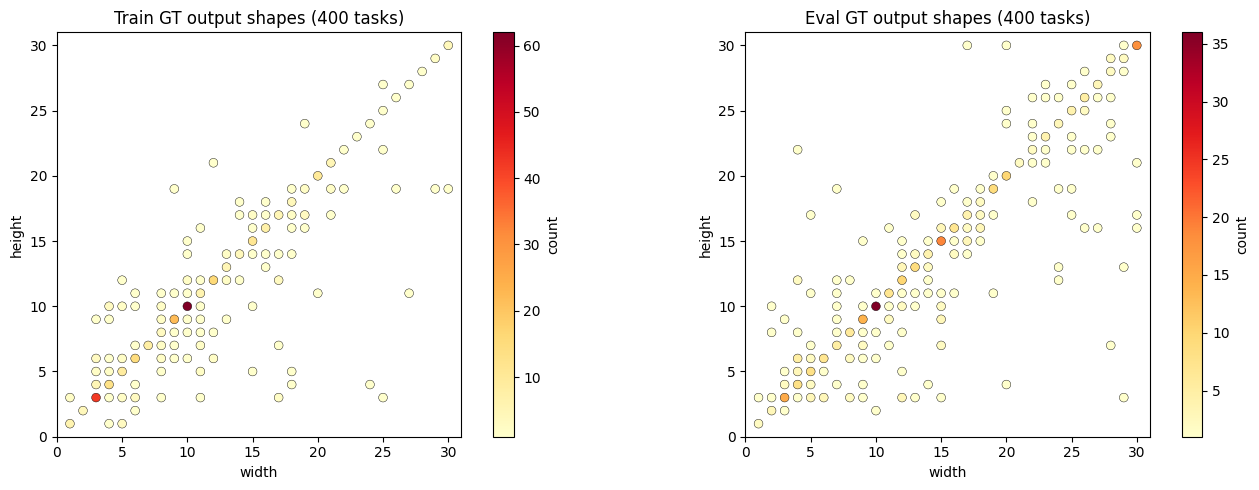

[Shape plot] ✅ displayed

--- 7. Visual examples (original + augmented) ---


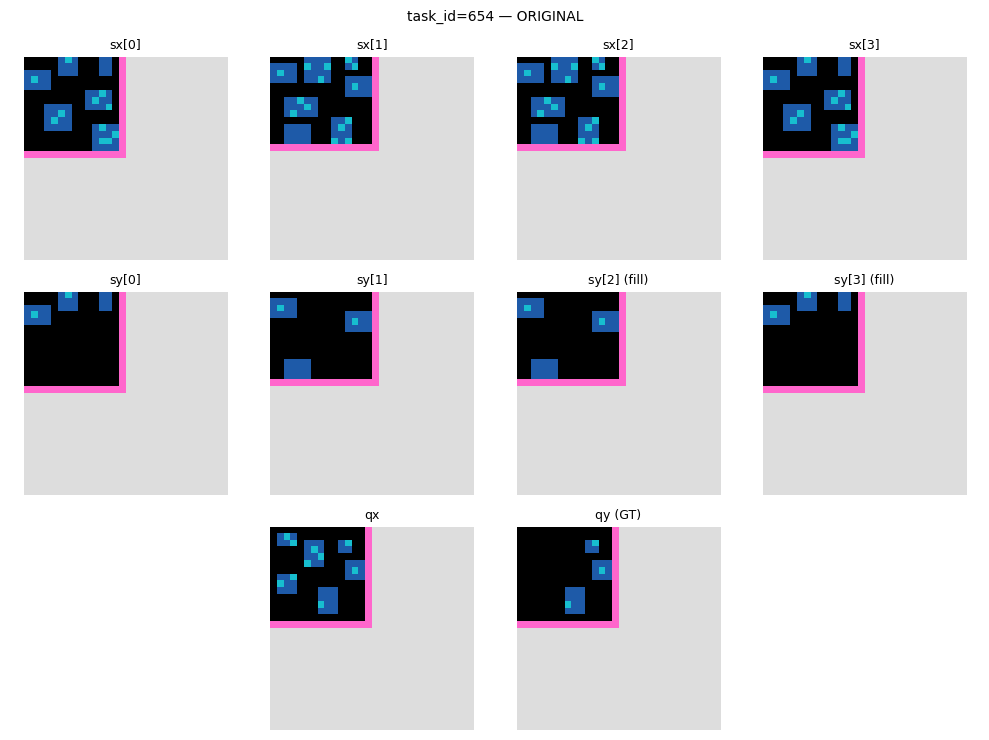

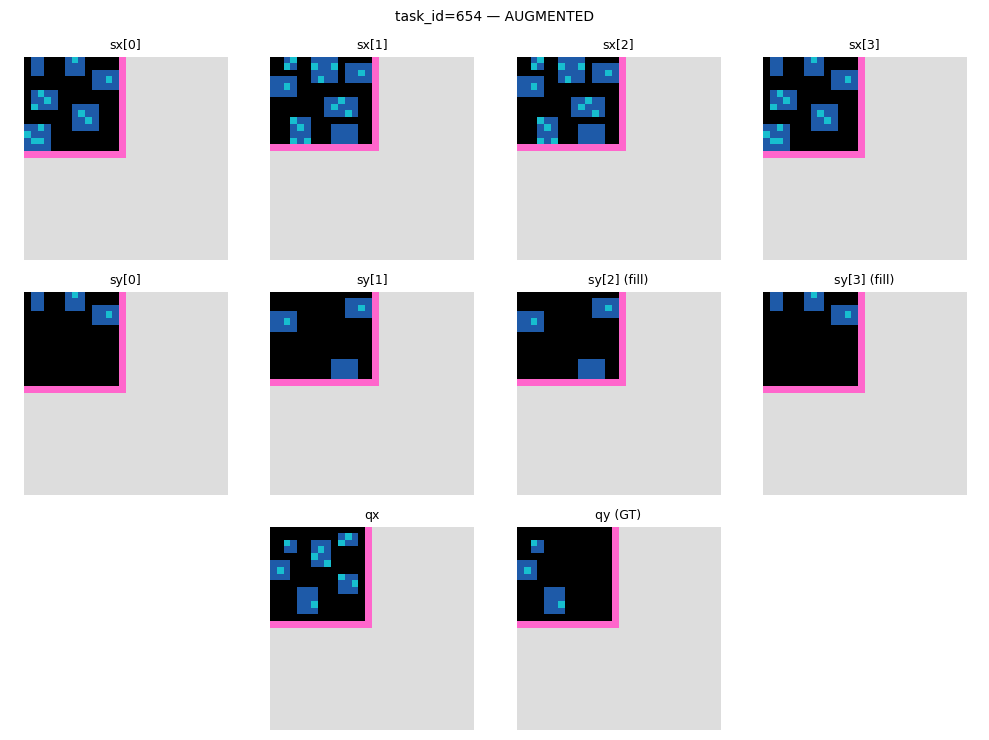

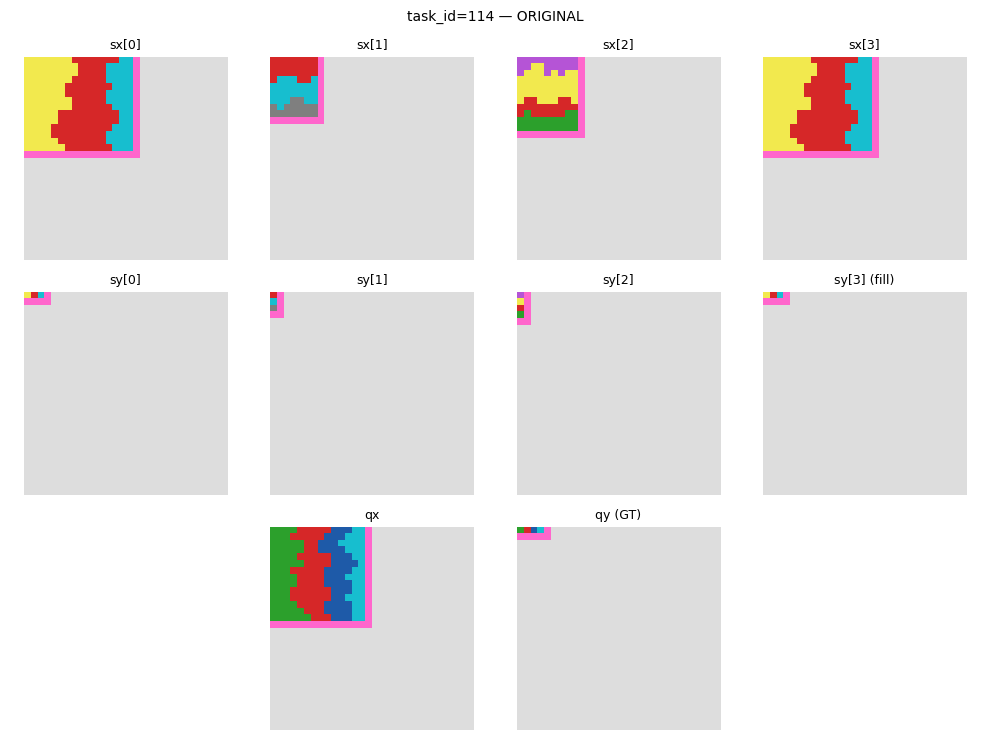

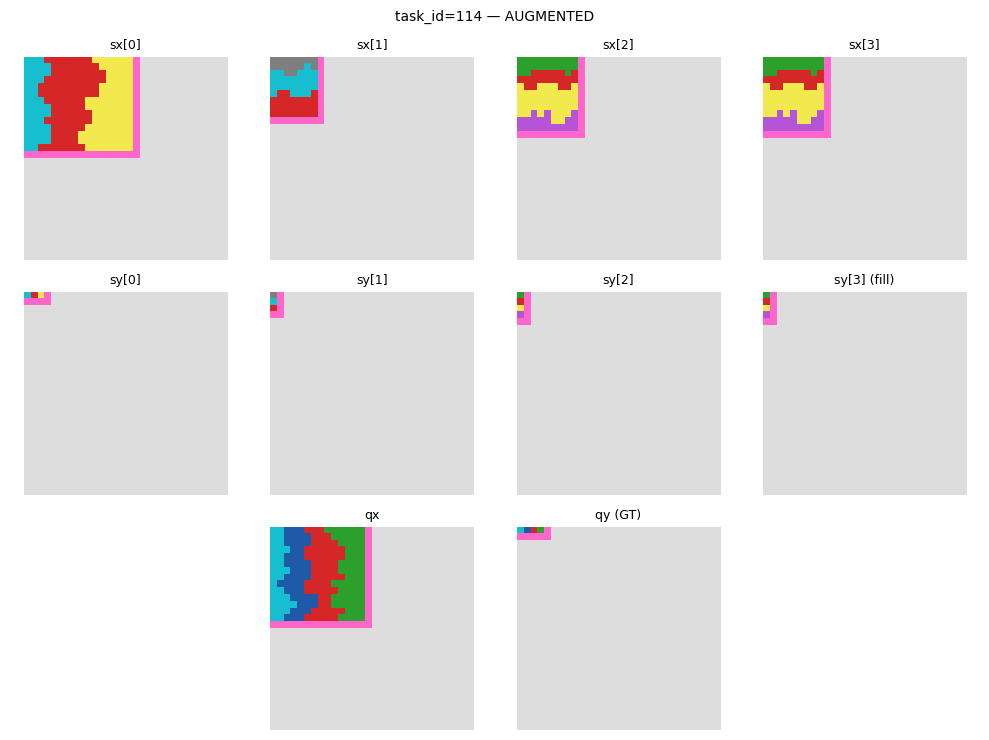

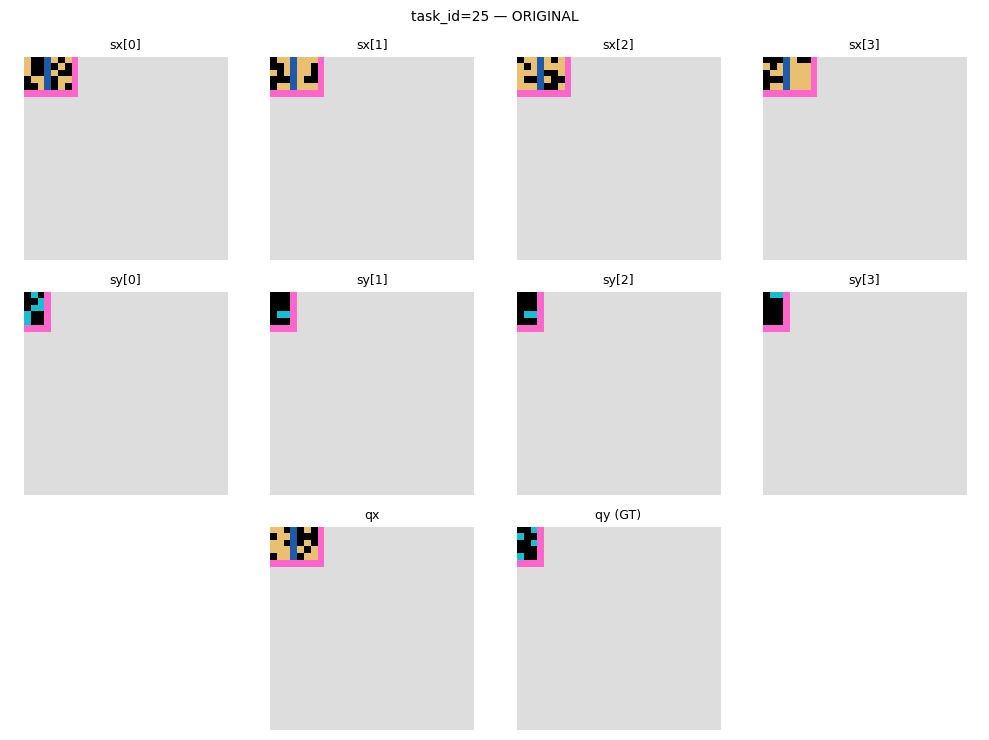

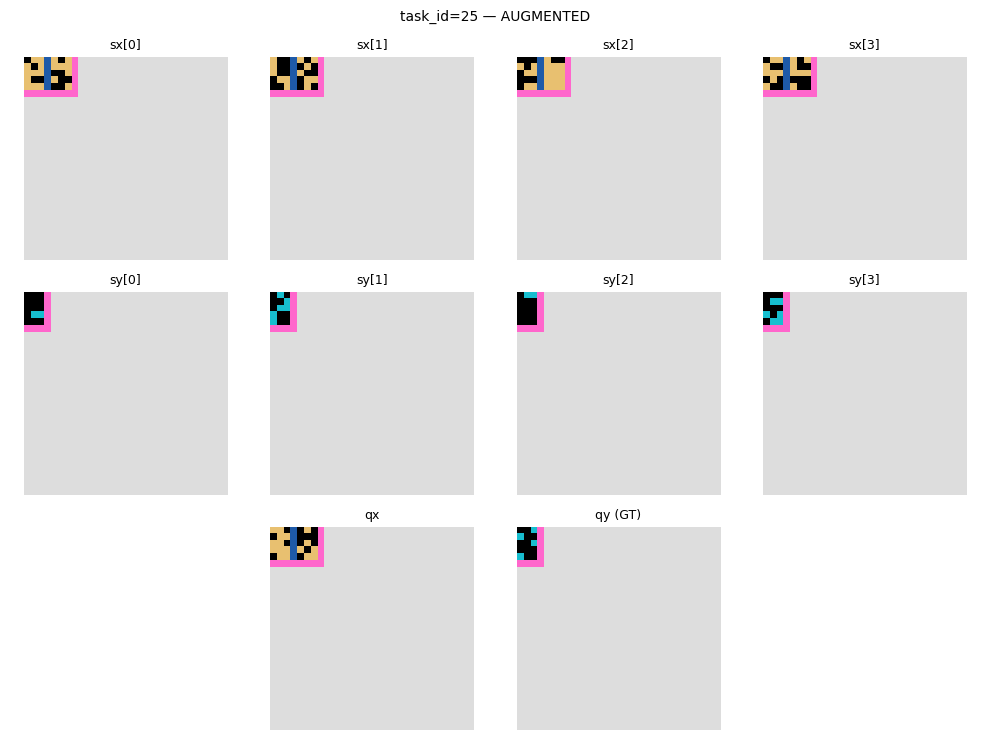

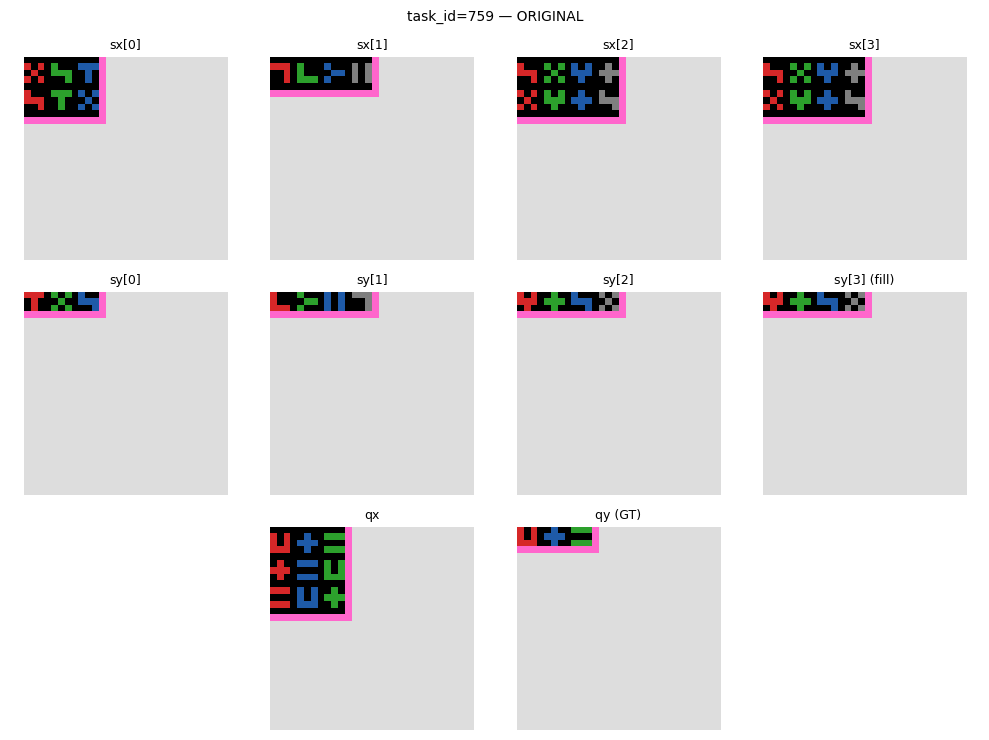

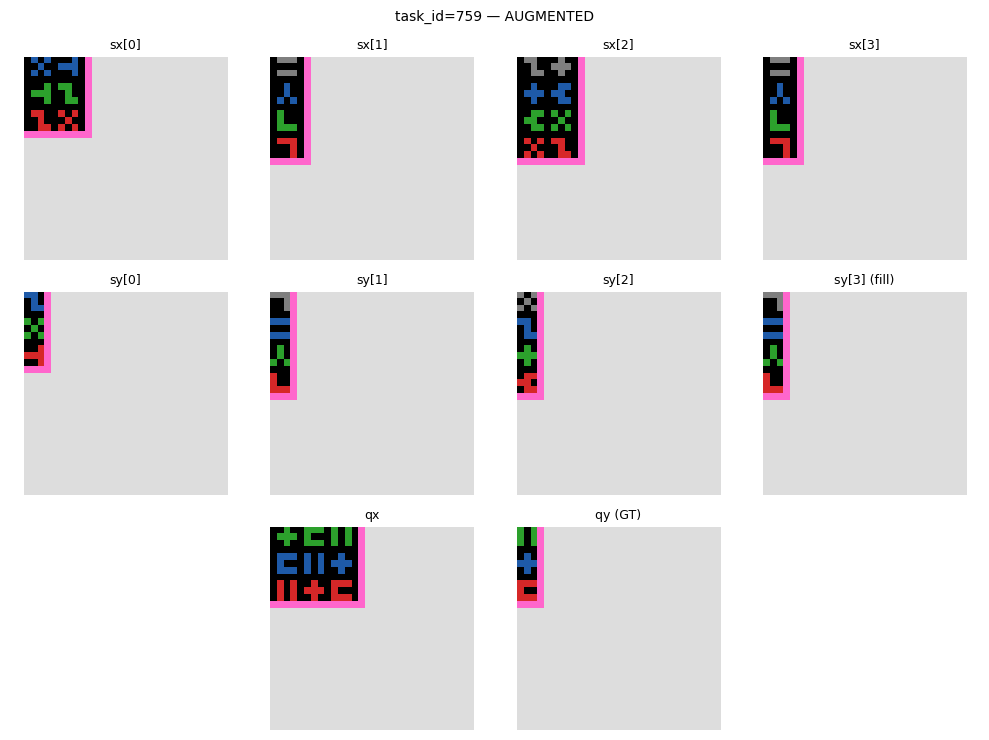

[Viz] ✅ 4 tasks visualized

--- 8. Demo: visualization with prediction ---


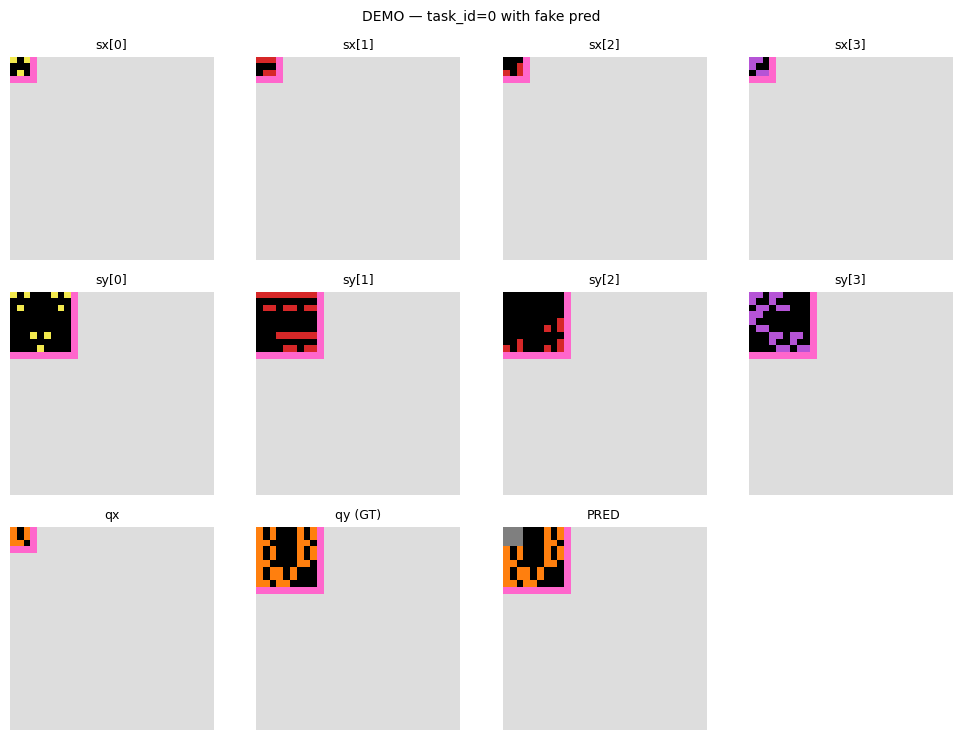


--- 9. Loader shapes & speed ---
[train_loader] batch keys: ['sx', 'sy', 'qx', 'qy', 's_mask', 's_is_real', 'support_idxs', 'task_id', 'task_stable', 'pad_id', 'eos_id']
  sx: shape=(4, 4, 30, 30) dtype=torch.int64
  sy: shape=(4, 4, 30, 30) dtype=torch.int64
  qx: shape=(4, 30, 30) dtype=torch.int64
  qy: shape=(4, 30, 30) dtype=torch.int64
  s_mask: shape=(4, 4) dtype=torch.bool
  s_is_real: shape=(4, 4) dtype=torch.bool
  support_idxs: shape=(4, 4) dtype=torch.int64
  task_id: shape=(4,) dtype=torch.int64
  task_stable: shape=(4,) dtype=torch.int64
  pad_id: 11
  eos_id: 10
[train_loader] 3 batches in 0.05s (0.018s/batch)

[trainext_loader] batch keys: ['sx', 'sy', 'qx', 'qy', 's_mask', 's_is_real', 'support_idxs', 'task_id', 'task_stable', 'pad_id', 'eos_id']
  sx: shape=(4, 4, 30, 30) dtype=torch.int64
  sy: shape=(4, 4, 30, 30) dtype=torch.int64
  qx: shape=(4, 30, 30) dtype=torch.int64
  qy: shape=(4, 30, 30) dtype=torch.int64
  s_mask: shape=(4, 4) dtype=torch.bool
  s_is_real

In [67]:
"""
CELLULE 2 — Sanity Checks + Visualisation ARC-AGI (v3)
========================================================
Fixes v3:
  - Layout visu: Row0=sx, Row1=sy, Row2= qx | qy(GT) | pred (centré)
  - show_arc_task() réutilisable dans la boucle de train (avec pred=)
  - Loader check: crée les loaders si absents
"""

import random, collections
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ══════════════════════════════════════════════════════
# 0. Colormap + helpers
# ══════════════════════════════════════════════════════
ARC_COLORS = [
    "#000000",  # 0  noir (fond)
    "#1E5AA8",  # 1  bleu
    "#D62728",  # 2  rouge
    "#2CA02C",  # 3  vert
    "#F2E94E",  # 4  jaune
    "#7F7F7F",  # 5  gris
    "#B554D6",  # 6  magenta
    "#FF7F0E",  # 7  orange
    "#17BECF",  # 8  cyan
    "#E8C070",  # 9  beige/sable  ← remplace #870C25 (bordeaux invisible)
    "#FF66CC",  # 10 EOS (rose)
    "#DDDDDD",  # 11 PAD (gris clair)
]

def _cmap_norm():
    cmap = mcolors.ListedColormap(ARC_COLORS, name="arc12")
    norm = mcolors.BoundaryNorm(np.arange(-0.5, 12.5, 1), cmap.N)
    return cmap, norm

CMAP, NORM = _cmap_norm()


def _crop_from_30(g, eos_id=10, pad_id=11):
    if isinstance(g, np.ndarray):
        g = torch.from_numpy(g)
    g = g.long()
    m = (g != eos_id) & (g != pad_id)
    if not m.any():
        return 0, 0, None
    ys, xs = torch.where(m)
    y0, y1 = int(ys.min()), int(ys.max()) + 1
    x0, x1 = int(xs.min()), int(xs.max()) + 1
    return y1 - y0, x1 - x0, g[y0:y1, x0:x1]


def _to_np(g):
    """Tensor or ndarray → 2D numpy for imshow."""
    if isinstance(g, torch.Tensor):
        g = g.detach().cpu()
        if g.ndim == 3:
            g = g[0]
        return g.numpy()
    return np.asarray(g)


# ══════════════════════════════════════════════════════
# SHOW_ARC_TASK — réutilisable dans le train loop
# ══════════════════════════════════════════════════════
def show_arc_task(
    batch,
    idx: int = 0,
    *,
    pred=None,
    title: str = "",
    figsize_per_cell: float = 2.5,
    save_path: str = None,
):
    """
    Visualise une task depuis un batch collated.

    Layout:
      Row 0: sx[0] .. sx[S-1]           (supports input)
      Row 1: sy[0] .. sy[S-1]           (supports output)
      Row 2: qx | qy (GT) | pred        (query, centré)

    Args:
        batch: dict from collate_arc_fixedS (keys: sx, sy, qx, qy, ...)
        idx:   index in the batch (default 0)
        pred:  optional [30,30] or [B,30,30] tensor (model prediction)
        title: custom suptitle
        save_path: if set, saves figure to this path
    """
    sx = batch["sx"][idx]   # [S,30,30]
    sy = batch["sy"][idx]
    qx = batch["qx"][idx]   # [30,30]
    qy = batch["qy"][idx]

    S = int(sx.shape[0])
    pad_id = int(batch["pad_id"]) if isinstance(batch["pad_id"], int) else int(batch["pad_id"].item())
    eos_id = int(batch["eos_id"]) if isinstance(batch["eos_id"], int) else int(batch["eos_id"].item())

    # Handle s_is_real if present
    is_real = batch.get("s_is_real", None)
    if is_real is not None:
        is_real = is_real[idx].tolist()

    # Handle pred
    if pred is not None:
        if isinstance(pred, torch.Tensor):
            pred = pred.detach().cpu()
            if pred.ndim == 3:
                pred = pred[idx]
        pred_np = _to_np(pred)
    else:
        pred_np = None

    # --- Layout ---
    # Row 2 has up to 3 panels: qx, qy, pred
    n_query_panels = 2 + (1 if pred_np is not None else 0)
    n_cols = max(S, n_query_panels)
    n_rows = 3

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(figsize_per_cell * n_cols, figsize_per_cell * n_rows))
    # Ensure axes is always 2D
    if n_cols == 1:
        axes = axes.reshape(n_rows, 1)

    def _plot(ax, g, label=""):
        ax.imshow(_to_np(g), cmap=CMAP, norm=NORM, interpolation="nearest")
        ax.set_title(label, fontsize=9)
        ax.axis("off")

    def _blank(ax):
        ax.axis("off")

    # Row 0: supports input
    for s in range(S):
        _plot(axes[0, s], sx[s], f"sx[{s}]")
    for c in range(S, n_cols):
        _blank(axes[0, c])

    # Row 1: supports output
    for s in range(S):
        label = f"sy[{s}]"
        if is_real is not None and not is_real[s]:
            label += " (fill)"
        _plot(axes[1, s], sy[s], label)
    for c in range(S, n_cols):
        _blank(axes[1, c])

    # Row 2: qx | qy (GT) | pred — centré
    # compute starting column to center
    start_col = max(0, (n_cols - n_query_panels) // 2)

    for c in range(n_cols):
        _blank(axes[2, c])

    _plot(axes[2, start_col],     qx, "qx")
    _plot(axes[2, start_col + 1], qy, "qy (GT)")
    if pred_np is not None:
        _plot(axes[2, start_col + 2], pred_np, "PRED")

    # --- Title ---
    if not title:
        tid = int(batch["task_id"][idx]) if "task_id" in batch else -1
        s_raw = int(batch.get("S_raw", torch.tensor(-1))[idx]) if "S_raw" in batch else S
        parts = [f"task_id={tid}", f"S_raw={s_raw}"]
        if is_real is not None:
            parts.append(f"is_real={is_real}")
        title = "  |  ".join(parts)

    fig.suptitle(title, fontsize=10)
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=120, bbox_inches="tight")

    plt.show()
    plt.close(fig)


# ══════════════════════════════════════════════════════
# 1. CHECK: EOS/PAD encoding round-trip
# ══════════════════════════════════════════════════════
def check_eos_pad_encoding(ds, n_check=50):
    errors = 0
    for i in range(min(n_check, len(ds))):
        item = ds[i]
        for key in ["sx", "sy", "qx", "qy"]:
            grids = item[key]
            if grids.ndim == 2:
                grids = grids.unsqueeze(0)
            for j in range(grids.shape[0]):
                g = grids[j].long()
                crop = _extract_crop(g, eos_id=10, pad_id=11)
                if crop is None:
                    continue
                g2 = _encode_crop_to_30(crop, eos_id=10, pad_id=11)
                if not torch.equal(g, g2):
                    errors += 1
                    if errors <= 5:
                        print(f"  ⚠ Round-trip mismatch: task {i}, key={key}, grid {j}")
    status = "✅ PASS" if errors == 0 else f"❌ {errors} FAILURES"
    print(f"[EOS/PAD round-trip] {status} ({n_check} tasks)")


# ══════════════════════════════════════════════════════
# 2. CHECK: Augmentation coherence
# ══════════════════════════════════════════════════════
def check_aug_coherence(ds, n_check=30, n_repeats=10):
    errors = 0
    for i in range(min(n_check, len(ds))):
        item = ds[i]
        qx_orig = item["qx"].clone()
        qy_orig = item["qy"].clone()

        fake_item = {
            "sx": qx_orig.unsqueeze(0).expand(4, -1, -1).clone(),
            "sy": qy_orig.unsqueeze(0).expand(4, -1, -1).clone(),
            "qx": qx_orig.clone(), "qy": qy_orig.clone(),
            "task_id": item["task_id"], "task_stable": item["task_stable"],
            "S": torch.tensor(4), "S_raw": torch.tensor(4),
            "q_idx": torch.tensor(-1), "mode": torch.tensor(0),
            "pad_id": item["pad_id"], "eos_id": item["eos_id"],
        }

        for rep in range(n_repeats):
            batch = collate_arc_fixedS([fake_item], S_fixed=4, p_task_aug=1.0)
            sx = batch["sx"][0]
            qx = batch["qx"][0]
            sy = batch["sy"][0]
            qy = batch["qy"][0]

            for s in range(4):
                if not torch.equal(sx[s], qx):
                    errors += 1
                    if errors <= 3:
                        print(f"  ⚠ task {i} rep {rep}: sx[{s}] ≠ qx")
                    break
            for s in range(4):
                if not torch.equal(sy[s], qy):
                    errors += 1
                    if errors <= 3:
                        print(f"  ⚠ task {i} rep {rep}: sy[{s}] ≠ qy")
                    break

    status = "✅ PASS" if errors == 0 else f"❌ {errors} FAILURES"
    print(f"[Aug coherence] {status} ({n_check} tasks × {n_repeats} repeats)")


# ══════════════════════════════════════════════════════
# 2b. CHECK: Aug changes something
# ══════════════════════════════════════════════════════
def check_aug_changes_something(ds, n_check=30, n_repeats=20):
    n_always_same = 0
    for i in range(min(n_check, len(ds))):
        item = ds[i]
        qy_orig = item["qy"].long()
        h, w, crop = _crop_from_30(qy_orig)
        if crop is None or (crop.numel() > 0 and crop.unique().numel() <= 1):
            continue
        all_same = True
        for _ in range(n_repeats):
            batch = collate_arc_fixedS([item], S_fixed=4, p_task_aug=1.0)
            if not torch.equal(qy_orig, batch["qy"][0]):
                all_same = False
                break
        if all_same:
            n_always_same += 1
    pct = n_always_same / min(n_check, len(ds)) * 100
    status = "✅ PASS" if pct < 10 else f"⚠ WARNING ({pct:.0f}% unchanged)"
    print(f"[Aug changes something] {status} ({n_always_same}/{n_check} always same)")


# ══════════════════════════════════════════════════════
# 3. CHECK: Recolor preserves color 0
# ══════════════════════════════════════════════════════
def check_recolor_preserves_zero(ds, n_check=50, n_repeats=5):
    errors = 0
    for i in range(min(n_check, len(ds))):
        item = ds[i]
        g_orig = item["qy"].long()
        crop_orig = _extract_crop(g_orig, eos_id=10, pad_id=11)
        if crop_orig is None:
            continue
        n_zeros_orig = int((crop_orig == 0).sum())
        if n_zeros_orig == 0:
            continue
        for _ in range(n_repeats):
            batch = collate_arc_fixedS([item], S_fixed=4, p_task_aug=1.0)
            crop_aug = _extract_crop(batch["qy"][0], eos_id=10, pad_id=11)
            if crop_aug is None:
                continue
            if int((crop_aug == 0).sum()) != n_zeros_orig:
                errors += 1
                break
    status = "✅ PASS" if errors == 0 else f"❌ {errors} FAILURES"
    print(f"[Recolor preserves 0] {status} ({n_check} tasks × {n_repeats} repeats)")


# ══════════════════════════════════════════════════════
# 4. CHECK: task_id integrity
# ══════════════════════════════════════════════════════
def check_task_ids(ds_train, ds_eval, ds_trainext):
    train_ids = {int(ds_train[i]["task_id"]) for i in range(len(ds_train))}
    eval_ids  = {int(ds_eval[i]["task_id"])  for i in range(len(ds_eval))}
    assert len(train_ids) == len(ds_train), "Duplicate train ids"
    assert len(eval_ids)  == len(ds_eval),  "Duplicate eval ids"
    assert not (train_ids & eval_ids), "Overlap train/eval"
    assert min(eval_ids) == max(train_ids) + 1, "Gap train→eval"
    trainext_ids = {int(ds_trainext[i]["task_id"]) for i in range(len(ds_trainext))}
    assert trainext_ids == train_ids | eval_ids, "trainext mismatch"
    print(f"[task_id] ✅ PASS — train=[0..{max(train_ids)}] eval=[{min(eval_ids)}..{max(eval_ids)}]")


# ══════════════════════════════════════════════════════
# 5. CHECK: EOS L-shape structure
# ══════════════════════════════════════════════════════
def check_eos_structure(ds, n_check=100):
    errors = 0
    for i in range(min(n_check, len(ds))):
        item = ds[i]
        for key in ["qx", "qy"]:
            g = item[key].long()
            h, w, crop = _crop_from_30(g)
            if crop is None:
                continue
            eos_mask = (g == 10)
            expected = torch.zeros(30, 30, dtype=torch.bool)
            if w < 30:
                expected[:h, w] = True
            if h < 30:
                end_c = min(w + (1 if w < 30 else 0), 30)
                if end_c > 0:
                    expected[h, :end_c] = True
            if not torch.equal(eos_mask, expected):
                errors += 1
                if errors <= 3:
                    print(f"  ⚠ task {i} {key}: EOS mismatch (h={h},w={w})")
    status = "✅ PASS" if errors == 0 else f"❌ {errors} FAILURES"
    print(f"[EOS L-shape] {status} ({n_check} tasks)")


# ══════════════════════════════════════════════════════
# 6. PLOT: Output GT shape distribution
# ══════════════════════════════════════════════════════
def plot_output_shapes(ds_train, ds_eval):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, ds, name in [(axes[0], ds_train, "Train"), (axes[1], ds_eval, "Eval")]:
        shapes = collections.Counter()
        for i in range(len(ds)):
            h, w, _ = _crop_from_30(ds[i]["qy"].long())
            shapes[(h, w)] += 1
        hs = [s[0] for s in shapes]
        ws = [s[1] for s in shapes]
        counts = [shapes[k] for k in shapes]
        sc = ax.scatter(ws, hs, c=counts, s=40, cmap="YlOrRd", edgecolors="k", linewidths=0.3)
        ax.set_xlabel("width"); ax.set_ylabel("height")
        ax.set_title(f"{name} GT output shapes ({len(ds)} tasks)")
        ax.set_xlim(0, 31); ax.set_ylim(0, 31); ax.set_aspect("equal")
        plt.colorbar(sc, ax=ax, label="count")
    plt.tight_layout()
    plt.show()
    print("[Shape plot] ✅ displayed")


# ══════════════════════════════════════════════════════
# 7. VISUALIZE: N tasks (original vs augmented)
# ══════════════════════════════════════════════════════
def visualize_tasks(ds, n_tasks=4, show_aug=True, seed=42):
    rng = random.Random(seed)
    indices = rng.sample(range(len(ds)), min(n_tasks, len(ds)))

    for task_idx in indices:
        item = ds[task_idx]
        tid = int(item["task_id"])

        # Original
        batch_orig = collate_arc_fixedS([item], S_fixed=4, p_task_aug=0.0)
        show_arc_task(batch_orig, 0, title=f"task_id={tid} — ORIGINAL")

        # Augmented
        if show_aug:
            batch_aug = collate_arc_fixedS([item], S_fixed=4, p_task_aug=1.0)
            show_arc_task(batch_aug, 0, title=f"task_id={tid} — AUGMENTED")

    print(f"[Viz] ✅ {len(indices)} tasks visualized")


# ══════════════════════════════════════════════════════
# 8. VISUALIZE with fake prediction (demo)
# ══════════════════════════════════════════════════════
def demo_pred_viz(ds, idx=0):
    """Show how show_arc_task looks with a prediction (random noise here)."""
    item = ds[idx]
    batch = collate_arc_fixedS([item], S_fixed=4, p_task_aug=0.0)
    # Fake pred: copy GT and flip some pixels
    fake_pred = batch["qy"][0].clone()
    fake_pred[:3, :3] = 5  # introduce visible error
    show_arc_task(batch, 0, pred=fake_pred, title=f"DEMO — task_id={int(item['task_id'])} with fake pred")


# ══════════════════════════════════════════════════════
# 9. CHECK: Loader shapes & speed
# ══════════════════════════════════════════════════════
def check_loader_shapes(loader, name="loader", n_batches=3):
    import time
    t0 = time.time()
    for i, batch in enumerate(loader):
        if i == 0:
            print(f"[{name}] batch keys: {list(batch.keys())}")
            for k, v in batch.items():
                if isinstance(v, torch.Tensor):
                    print(f"  {k}: shape={tuple(v.shape)} dtype={v.dtype}")
                else:
                    print(f"  {k}: {v}")
        if i >= n_batches - 1:
            break
    dt = time.time() - t0
    print(f"[{name}] {n_batches} batches in {dt:.2f}s ({dt/n_batches:.3f}s/batch)\n")


# ══════════════════════════════════════════════════════
# RUN ALL CHECKS
# ══════════════════════════════════════════════════════
print("=" * 60)
print("ARC-AGI SANITY CHECKS v3")
print("=" * 60)

print("\n--- 1. EOS/PAD round-trip ---")
check_eos_pad_encoding(ds_train, n_check=50)
check_eos_pad_encoding(ds_eval,  n_check=50)

print("\n--- 2. Augmentation coherence ---")
check_aug_coherence(ds_train, n_check=30, n_repeats=10)

print("\n--- 2b. Aug changes something ---")
check_aug_changes_something(ds_train, n_check=30)

print("\n--- 3. Recolor preserves color 0 ---")
check_recolor_preserves_zero(ds_train, n_check=50, n_repeats=5)

print("\n--- 4. task_id integrity ---")
check_task_ids(ds_train, ds_eval, ds_trainext)

print("\n--- 5. EOS L-shape structure ---")
check_eos_structure(ds_train, n_check=100)

print("\n--- 6. Output GT shape distribution ---")
plot_output_shapes(ds_train, ds_eval)

print("\n--- 7. Visual examples (original + augmented) ---")
visualize_tasks(ds_trainext, n_tasks=4, show_aug=True)

print("\n--- 8. Demo: visualization with prediction ---")
demo_pred_viz(ds_train, idx=0)

print("\n--- 9. Loader shapes & speed ---")
# Create loaders inline if not already defined
if 'trainext_loader' not in dir():
    print("  (creating loaders...)")
    from torch.utils.data import DataLoader
    _collate_train = lambda b: collate_arc_fixedS(b, p_task_aug=0.5)
    _collate_eval  = lambda b: collate_arc_fixedS(b, p_task_aug=0.0)
    train_loader = DataLoader(ds_train, batch_size=16, shuffle=True,
                              num_workers=4, collate_fn=_collate_train,
                              pin_memory=True, persistent_workers=True)
    trainext_loader = DataLoader(ds_trainext, batch_size=16, shuffle=True,
                              num_workers=4, collate_fn=_collate_train,
                              pin_memory=True, persistent_workers=True)
    eval_loader  = DataLoader(ds_eval, batch_size=16, shuffle=False,
                              num_workers=2, collate_fn=_collate_eval,
                              pin_memory=True, persistent_workers=True)

check_loader_shapes(train_loader, "train_loader")
check_loader_shapes(trainext_loader, "trainext_loader")
check_loader_shapes(eval_loader,  "eval_loader")

print("=" * 60)
print("ALL CHECKS COMPLETE")
print("=" * 60)

In [68]:
# ════════════════════════════════════════════════════════════════
# IERM-TRM v4.1 — Cellule modèle corrigée + optimisée
#
# CORRECTIONS vs v4 :
#   [BUG-1] deep_recursion : checkpoint + detach = contradiction
#           → torch.no_grad() pour les T-1 premiers steps (3x moins de VRAM)
#   [BUG-2] _support_verify_loss : boucle séquentielle O(S) forward passes
#           → batché en UN SEUL forward pass (÷S en temps, ÷S en pic VRAM)
#   [BUG-3] _sanitize appelé 14+ fois par inner step → réduit à 4 points critiques
#           (économie ~15% compute par step)
#   [BUG-4] mask_loss_weight ignoré du config (hardcodé 0.20)
#   [BUG-5] predict() duplique la logique de projection supp
#           → factorisé via _project_supp()
#   [BUG-6] deep_recursion : supp_flat reshape inutile (B*N → B,N → re-B,N)
#   [BUG-7] z_recalib_gate initial -2.0 trop fermé → -1.0 (sigmoid≈0.27)
#           avec Ψ_lift=+0.02, le gate doit s'ouvrir plus vite
#   [OPT-1] latent_recursion : fusionne les cross-attention z→ctx et z→supp
#           quand les deux existent (concat KV, 1 seul matmul au lieu de 2)
#   [OPT-2] _output_heads : évite la construction de tenseurs zéros quand
#           x_embed est fourni (toujours le cas en pratique)
#   [OPT-3] init_z : pré-alloue et clone au lieu de expand (évite strides non-contigus)
# ════════════════════════════════════════════════════════════════

'''
Ce qui est implémenté 4.2
Boucle P↔M dans PsiMemProg — T_psi=2 itérations :
supp → M_0  (init)
for t in T_psi:
    M ← M + xa(M, supp)          # M re-lit les supports
    M ← M + gate * xa(M, P)      # ← P guide M  (le vrai "Interactive")
    P ← P + xa(P, M)             # P se raffine
    P ← P + ff(P)
ctx = Refine(P)
Le p2m_gate (initialisé à -1.0 → sigmoid≈0.27) protège l'instabilité en début d'entraînement.
3 niveaux d'augmentation complémentaires sans fuite :
NiveauOùCe qui est transformécollate + p_task_augDataloadersx+sy+qx+qy géométrie cohérenteaugment_arc_colorsTraining loopsx+sy+qx+qy recolor cohérente_augment_supports_inlineencode_supports()sx+sy seulement → Ψ voit 2×S, qx/qy inchangés
Le niveau 3 est la clé : il enrichit uniquement ce que Ψ voit, sans modifier la cible du décodeur — aucune fuite possible.
Config recommandée : T_psi=2, aug_n_views=2, loso_lambda=0.3 (monter car 2×S supports maintenant).

'''
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.checkpoint import checkpoint
from typing import Optional


# ════════════════════════════════════════════════════════════════
# Helpers
# ════════════════════════════════════════════════════════════════

def _force_keep_at_least_one(keep: torch.Tensor) -> torch.Tensor:
    """Garantit qu'au moins un token est non-masqué par batch item."""
    all_masked = ~keep.any(dim=-1)
    if all_masked.any():
        keep = keep.clone()
        keep[all_masked, 0] = True
    return keep


def _sanitize(t: torch.Tensor,
               lo: float = -50.0, hi: float = 50.0) -> torch.Tensor:
    return torch.nan_to_num(t, nan=0.0, posinf=hi, neginf=lo).clamp(lo, hi)


# ════════════════════════════════════════════════════════════════
# Norms & FFN
# ════════════════════════════════════════════════════════════════

class RMSNorm(nn.Module):
    def __init__(self, dim: int, eps: float = 1e-6):
        super().__init__()
        self.eps    = eps
        self.weight = nn.Parameter(torch.ones(dim))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        w = self.weight.to(dtype=x.dtype)
        if hasattr(F, "rms_norm"):
            return F.rms_norm(x, self.weight.shape, weight=w, eps=self.eps)
        inv = torch.rsqrt(x.float().pow(2).mean(-1, keepdim=True) + self.eps)
        return (x.float() * inv).to(x.dtype) * w


class SwiGLUFFN(nn.Module):
    def __init__(self, d_model: int, expand: float = 2.0, dropout: float = 0.1):
        super().__init__()
        hidden       = ((int(d_model * expand) + 7) // 8) * 8
        self.w_gate  = nn.Linear(d_model, hidden, bias=False)
        self.w_up    = nn.Linear(d_model, hidden, bias=False)
        self.w_down  = nn.Linear(hidden,  d_model, bias=False)
        self.drop    = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.drop(self.w_down(F.silu(self.w_gate(x)) * self.w_up(x)))


# ════════════════════════════════════════════════════════════════
# ARCEmbedder
# ════════════════════════════════════════════════════════════════

class ARCEmbedder(nn.Module):
    def __init__(self, *, vocab_size=12, d=128, Hmax=30, Wmax=30,
                 eos_id=10, pad_id=11, n_types=4, Smax=8,
                 n_tasks=2048, use_task_id=True, dropout=0.1):
        super().__init__()
        self.d          = int(d)
        self.vocab_size = int(vocab_size)
        self.Hmax       = int(Hmax)
        self.Wmax       = int(Wmax)
        self.pad_id     = int(pad_id)
        self.eos_id     = int(eos_id)

        self.emb_tok  = nn.Embedding(vocab_size, d)
        self.emb_row  = nn.Embedding(Hmax, d)
        self.emb_col  = nn.Embedding(Wmax, d)
        self.emb_type = nn.Embedding(n_types, d)
        self.emb_pair = nn.Embedding(Smax, d)
        self.norm     = nn.LayerNorm(d)
        self.drop     = nn.Dropout(float(dropout))

        for emb in [self.emb_tok, self.emb_row, self.emb_col,
                    self.emb_type, self.emb_pair]:
            nn.init.normal_(emb.weight, std=0.02)

        self.use_task_id = bool(use_task_id)
        self.n_tasks     = int(n_tasks)
        if self.use_task_id:
            self.emb_task = nn.Embedding(self.n_tasks, d)
            nn.init.normal_(self.emb_task.weight, std=0.02)

    def forward(self, x, type_id, pair_id=None, task_id=None, return_mask=False):
        if x.dtype != torch.long:
            x = x.long()
        B, H, W = x.shape
        L       = H * W
        device  = x.device
        x_flat  = x.reshape(B, L)

        e    = self.emb_tok(x_flat.clamp(0, self.vocab_size - 1))
        rows = torch.arange(H, device=device)
        cols = torch.arange(W, device=device)
        pos  = (self.emb_row(rows)[:, None, :] +
                self.emb_col(cols)[None, :, :]).reshape(1, L, self.d)
        e    = e + pos

        type_id = self._to_long_vector(type_id, B, device).clamp(
            0, self.emb_type.num_embeddings - 1)
        e = e + self.emb_type(type_id)[:, None, :]

        if pair_id is not None:
            pair_id = self._to_long_vector(pair_id, B, device).clamp(
                0, self.emb_pair.num_embeddings - 1)
            e = e + self.emb_pair(pair_id)[:, None, :]

        if self.use_task_id and task_id is not None:
            tid = self._to_long_vector(task_id, B, device).clamp(0, self.n_tasks - 1)
            e   = e + self.emb_task(tid)[:, None, :]

        e = self.drop(self.norm(e))

        mask_keep = (x_flat != self.pad_id)
        all_pad   = (~mask_keep).all(dim=1)
        if all_pad.any():
            mask_keep          = mask_keep.clone()
            mask_keep[all_pad, 0] = True

        if return_mask:
            return e, mask_keep
        return e

    @staticmethod
    def _to_long_vector(val, B, device):
        if isinstance(val, int):
            return torch.full((B,), val, device=device, dtype=torch.long)
        t      = val.to(device=device, dtype=torch.long)
        if t.numel() == 1:
            return t.view(1).expand(B)
        t_flat = t.reshape(-1)
        if t_flat.shape[0] < B:
            pad    = t_flat[-1:].expand(B - t_flat.shape[0])
            t_flat = torch.cat([t_flat, pad], dim=0)
        return t_flat[:B]


# ════════════════════════════════════════════════════════════════
# RoPE 2D
# ════════════════════════════════════════════════════════════════

class RoPE2D(nn.Module):
    def __init__(self, d_head: int, max_h: int = 30, max_w: int = 30,
                 theta: float = 10000.0):
        super().__init__()
        assert d_head % 4 == 0
        self.d_head  = d_head
        self.d_quat  = d_head // 4
        inv_freq     = 1.0 / (theta ** (
            torch.arange(0, self.d_quat, dtype=torch.float) / self.d_quat))
        self.register_buffer("inv_freq", inv_freq, persistent=False)
        self._build_cache(max_h, max_w)

    def _build_cache(self, H: int, W: int):
        device  = self.inv_freq.device
        rows    = torch.arange(H, dtype=torch.float, device=device)
        cols    = torch.arange(W, dtype=torch.float, device=device)
        fr      = torch.outer(rows, self.inv_freq)[:, None, :].expand(H, W, self.d_quat)
        fc      = torch.outer(cols, self.inv_freq)[None, :, :].expand(H, W, self.d_quat)
        emb_r   = fr.reshape(H * W, self.d_quat).repeat(1, 2)
        emb_c   = fc.reshape(H * W, self.d_quat).repeat(1, 2)
        emb     = torch.cat([emb_r, emb_c], dim=-1)
        self.register_buffer("cos_cached", emb.cos(), persistent=False)
        self.register_buffer("sin_cached", emb.sin(), persistent=False)
        self._cached_hw = (H, W)

    def _rotate_half(self, x):
        x1, x2 = x[..., ::2], x[..., 1::2]
        return torch.stack((-x2, x1), dim=-1).flatten(-2)

    def forward(self, q, k, H: int, W: int):
        ch, cw = getattr(self, "_cached_hw", (0, 0))
        if ch < H or cw < W:
            self._build_cache(max(H, ch), max(W, cw))
        Hc, Wc = self._cached_hw
        idx = (torch.arange(H, device=q.device)[:, None] * Wc +
               torch.arange(W, device=q.device)[None, :]).reshape(-1).long()
        cos = self.cos_cached[idx].to(q.dtype)[None, None]
        sin = self.sin_cached[idx].to(q.dtype)[None, None]
        return (q * cos + self._rotate_half(q) * sin,
                k * cos + self._rotate_half(k) * sin)


# ════════════════════════════════════════════════════════════════
# Attention modules
# ════════════════════════════════════════════════════════════════

class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model: int, n_head: int, dropout: float = 0.1, *,
                 use_rope_2d: bool = False, max_h: int = 30, max_w: int = 30,
                 use_qk_norm: bool = False):
        super().__init__()
        assert d_model % n_head == 0
        self.n_head      = n_head
        self.d_head      = d_model // n_head
        self.dropout     = float(dropout)
        self.qkv         = nn.Linear(d_model, 3 * d_model)
        self.out         = nn.Linear(d_model, d_model)
        self.use_rope_2d = bool(use_rope_2d)
        if self.use_rope_2d:
            self.rope = RoPE2D(self.d_head, max_h=max_h, max_w=max_w)
        self.use_qk_norm = bool(use_qk_norm)
        if self.use_qk_norm:
            self.q_norm = RMSNorm(self.d_head)
            self.k_norm = RMSNorm(self.d_head)

    def forward(self, x, *, key_padding_keep=None, grid_hw=None):
        B, N, D = x.shape
        qkv     = self.qkv(x).reshape(B, N, 3, self.n_head, self.d_head)
        q, k, v = qkv.unbind(2)
        q, k, v = q.transpose(1, 2), k.transpose(1, 2), v.transpose(1, 2)
        if self.use_qk_norm:
            q, k = self.q_norm(q), self.k_norm(k)
        if self.use_rope_2d and grid_hw is not None:
            q, k = self.rope(q, k, int(grid_hw[0]), int(grid_hw[1]))
        attn_mask = None
        if key_padding_keep is not None:
            keep      = _force_keep_at_least_one(key_padding_keep)
            attn_mask = torch.zeros(B, 1, 1, N, device=x.device, dtype=torch.float32)
            attn_mask.masked_fill_(~keep[:, None, None, :], float("-inf"))
        y = F.scaled_dot_product_attention(
            q, k, v, attn_mask=attn_mask,
            dropout_p=self.dropout if self.training else 0.0)
        return self.out(y.transpose(1, 2).reshape(B, N, D))


class CrossAttention(nn.Module):
    def __init__(self, d_model: int, n_head: int, dropout: float = 0.1, *,
                 use_qk_norm: bool = False):
        super().__init__()
        assert d_model % n_head == 0
        self.n_head      = n_head
        self.d_head      = d_model // n_head
        self.dropout     = float(dropout)
        self.wq          = nn.Linear(d_model, d_model)
        self.wk          = nn.Linear(d_model, d_model)
        self.wv          = nn.Linear(d_model, d_model)
        self.wo          = nn.Linear(d_model, d_model)
        self.use_qk_norm = bool(use_qk_norm)
        if self.use_qk_norm:
            self.q_norm = RMSNorm(self.d_head)
            self.k_norm = RMSNorm(self.d_head)

    def forward(self, q, kv, *, kv_keep=None):
        B, M, D = q.shape
        N       = kv.shape[1]
        Q = self.wq(q).reshape(B, M, self.n_head, self.d_head).transpose(1, 2)
        K = self.wk(kv).reshape(B, N, self.n_head, self.d_head).transpose(1, 2)
        V = self.wv(kv).reshape(B, N, self.n_head, self.d_head).transpose(1, 2)
        if self.use_qk_norm:
            Q, K = self.q_norm(Q), self.k_norm(K)
        attn_mask = None
        if kv_keep is not None:
            keep      = _force_keep_at_least_one(kv_keep)
            attn_mask = torch.zeros(B, 1, 1, N, device=q.device, dtype=torch.float32)
            attn_mask.masked_fill_(~keep[:, None, None, :], float("-inf"))
        y = F.scaled_dot_product_attention(
            Q, K, V, attn_mask=attn_mask,
            dropout_p=self.dropout if self.training else 0.0)
        return self.wo(y.transpose(1, 2).reshape(B, M, D))


# ════════════════════════════════════════════════════════════════
# TRMSelfBlock
# ════════════════════════════════════════════════════════════════

class TRMSelfBlock(nn.Module):
    def __init__(self, d: int, n_heads: int = 4, dropout: float = 0.1,
                 use_rope_2d: bool = False, use_qk_norm: bool = False):
        super().__init__()
        self.pre_sa = RMSNorm(d)
        self.sa     = MultiHeadSelfAttention(d, n_heads, dropout,
                                             use_rope_2d=use_rope_2d,
                                             use_qk_norm=use_qk_norm)
        self.pre_ff = RMSNorm(d)
        self.ff     = SwiGLUFFN(d, expand=2.0, dropout=dropout)
        self.drop   = nn.Dropout(dropout)

    def forward(self, x, *, key_padding_keep=None, grid_hw=None):
        x = x + self.drop(self.sa(self.pre_sa(x),
                                   key_padding_keep=key_padding_keep,
                                   grid_hw=grid_hw))
        x = x + self.drop(self.ff(self.pre_ff(x)))
        return x


# ════════════════════════════════════════════════════════════════
# PsiMemProg
# ════════════════════════════════════════════════════════════════

# ════════════════════════════════════════════════════════════════
# PsiMemProg — version Interactive (co-raffinage P↔M)
# ════════════════════════════════════════════════════════════════

class PsiMemProg(nn.Module):
    """
    Ψ_interactive : (sx_i, sy_i)_{i=0..S-1}  →  ctx  (programme abstrait)

    Architecture interactive en T_psi itérations :
        supp → M_0  (init par cross-attention sur supports)
        for t in range(T_psi):
            M_t ← M_t + xa(M_t, supp)        # mémoire re-lit les supports
            M_t ← M_t + xa(M_t, P_t)         # mémoire guidée par le programme
            P_t ← P_t + xa(P_t, M_t)         # programme se raffine depuis M
            P_t ← P_t + ff(P_t)
        ctx = Refine(P_T)

    Le feedback P→M est le cœur du "Interactive" dans IERM.
    P guide ce que M doit encore chercher dans S.
    """
    def __init__(self, embedder, D_phi: int, D_psi: int, n_heads: int = 4,
                 n_mem: int = 64, n_prog: int = 16, dropout: float = 0.1,
                 pad_id: int = 11, eos_id: int = 10, refine_layers: int = 1,
                 T_psi: int = 2):          # ← nouveau : nb d'itérations P↔M
        super().__init__()
        self.emb    = embedder
        self.D_phi  = int(D_phi)
        self.D_psi  = int(D_psi)
        self.pad_id = int(pad_id)
        self.eos_id = int(eos_id)
        self.n_mem  = int(n_mem)
        self.n_prog = int(n_prog)
        self.T_psi  = int(T_psi)

        self.proj = (nn.Linear(D_phi, D_psi, bias=False)
                     if D_phi != D_psi else nn.Identity())
        if D_phi != D_psi:
            nn.init.normal_(self.proj.weight, std=0.02)

        self.mem_tokens  = nn.Parameter(torch.randn(n_mem,  D_psi) * 0.02)
        self.prog_tokens = nn.Parameter(torch.randn(n_prog, D_psi) * 0.02)

        # ── Stage 1 : Memory init (supp → M) ─────────────────
        self.mem_init_pre_kv = RMSNorm(D_psi)
        self.mem_init_pre_q  = RMSNorm(D_psi)
        self.mem_init_xa     = CrossAttention(D_psi, n_heads, dropout, use_qk_norm=True)
        self.mem_init_pre_ff = RMSNorm(D_psi)
        self.mem_init_ff     = SwiGLUFFN(D_psi, dropout=dropout)
        self.mem_init_drop   = nn.Dropout(dropout)

        # ── Boucle interactive P↔M ────────────────────────────
        # M re-lit supp (guidé par P)
        self.loop_m_supp_pre_kv = RMSNorm(D_psi)
        self.loop_m_supp_pre_q  = RMSNorm(D_psi)
        self.loop_m_supp_xa     = CrossAttention(D_psi, n_heads, dropout, use_qk_norm=True)

        # M lit P (feedback programme → mémoire)
        self.loop_m_prog_pre_kv = RMSNorm(D_psi)
        self.loop_m_prog_pre_q  = RMSNorm(D_psi)
        self.loop_m_prog_xa     = CrossAttention(D_psi, n_heads, dropout, use_qk_norm=True)
        self.loop_m_ff_pre      = RMSNorm(D_psi)
        self.loop_m_ff          = SwiGLUFFN(D_psi, dropout=dropout)
        self.loop_m_drop        = nn.Dropout(dropout)

        # P lit M (programme se raffine depuis mémoire)
        self.loop_p_mem_pre_kv  = RMSNorm(D_psi)
        self.loop_p_mem_pre_q   = RMSNorm(D_psi)
        self.loop_p_mem_xa      = CrossAttention(D_psi, n_heads, dropout, use_qk_norm=True)
        self.loop_p_ff_pre      = RMSNorm(D_psi)
        self.loop_p_ff          = SwiGLUFFN(D_psi, expand=2.0, dropout=dropout)
        self.loop_p_drop        = nn.Dropout(dropout)

        # Gate appris pour le feedback P→M (évite explosion au début)
        # sigmoid(-1.0) ≈ 0.27 : le feedback s'ouvre progressivement
        self.p2m_gate = nn.Parameter(torch.full((D_psi,), -1.0))

        # ── Stage final : Refine(P) ───────────────────────────
        self.refine = nn.ModuleList([
            TRMSelfBlock(D_psi, n_heads=n_heads, dropout=dropout, use_qk_norm=True)
            for _ in range(refine_layers)
        ])

    # ──────────────────────────────────────────────────────────
    def forward(self, sx, sy, s_mask=None, task_id=None):
        B, S, H, W = sx.shape
        device     = sx.device
        L          = H * W

        # ── Embedding des supports ────────────────────────────
        sx_flat  = sx.reshape(B * S, H, W)
        sy_flat  = sy.reshape(B * S, H, W)
        pair_ids = torch.arange(S, device=device).unsqueeze(0).expand(B, S).reshape(B * S)

        t = None
        if task_id is not None:
            t = self.emb._to_long_vector(task_id, B, device)
            t = t.view(B, 1).expand(B, S).reshape(B * S)

        ex, mx = self.emb(sx_flat, type_id=0, pair_id=pair_ids,
                          task_id=t, return_mask=True)
        ey, my = self.emb(sy_flat, type_id=1, pair_id=pair_ids,
                          task_id=t, return_mask=True)

        ex = self.proj(ex)
        ey = self.proj(ey)

        supp      = torch.cat([ex, ey], dim=1).reshape(B, S * 2 * L, self.D_psi)
        supp_keep = torch.cat([mx, my], dim=1).reshape(B, S * 2 * L)

        if s_mask is not None:
            sm        = s_mask.bool()
            sm_exp    = sm[:, :, None].expand(B, S, 2 * L).reshape(B, S * 2 * L)
            supp_keep = supp_keep & sm_exp

        supp_keep = _force_keep_at_least_one(supp_keep)

        # ── Stage 1 : Memory init (supp → M_0) ───────────────
        M = self.mem_tokens.unsqueeze(0).expand(B, -1, -1).clone()
        M = M + self.mem_init_drop(
            self.mem_init_xa(self.mem_init_pre_q(M),
                             self.mem_init_pre_kv(supp),
                             kv_keep=supp_keep))
        M = M + self.mem_init_drop(self.mem_init_ff(self.mem_init_pre_ff(M)))

        # ── Init P_0 ──────────────────────────────────────────
        P = self.prog_tokens.unsqueeze(0).expand(B, -1, -1).clone()

        # ── Boucle interactive P↔M ────────────────────────────
        p2m_gate = torch.sigmoid(self.p2m_gate).view(1, 1, -1)

        for _ in range(self.T_psi):

            # M re-lit supp (attention guidée par P via gate)
            M = M + self.loop_m_drop(
                self.loop_m_supp_xa(
                    self.loop_m_supp_pre_q(M),
                    self.loop_m_supp_pre_kv(supp),
                    kv_keep=supp_keep))

            # Feedback P → M : la mémoire se focalise sur ce que P cherche
            M = M + p2m_gate * self.loop_m_drop(
                self.loop_m_prog_xa(
                    self.loop_m_prog_pre_q(M),
                    self.loop_m_prog_pre_kv(P)))
            M = M + self.loop_m_drop(self.loop_m_ff(self.loop_m_ff_pre(M)))

            # P se raffine depuis M
            P = P + self.loop_p_drop(
                self.loop_p_mem_xa(
                    self.loop_p_mem_pre_q(P),
                    self.loop_p_mem_pre_kv(M)))
            P = P + self.loop_p_drop(self.loop_p_ff(self.loop_p_ff_pre(P)))

        # ── Stage final : Refine(P) ───────────────────────────
        p_keep = torch.ones(B, self.n_prog, device=device, dtype=torch.bool)
        for blk in self.refine:
            P = blk(P, key_padding_keep=p_keep)

        P = _sanitize(P)

        return {
            "ctx":       P,
            "ctx_keep":  p_keep,
            "M":         M,
            "supp":      supp,
            "supp_keep": supp_keep,
        }
# ════════════════════════════════════════════════════════════════
# PhiTRM  — version corrigée + optimisée
# ════════════════════════════════════════════════════════════════

class PhiTRM(nn.Module):
    def __init__(self, *, d_model: int, vocab_size: int, n_heads: int,
                 n_inner: int, T_max: int, d_psi: Optional[int] = None,
                 dropout: float = 0.1, use_rope_2d: bool = True,
                 use_qk_norm: bool = True, pad_id: int = 11,
                 eos_id: int = 10, z_tokens: int = 8):
        super().__init__()
        self.D          = int(d_model)
        self.vocab_size = int(vocab_size)
        self.pad_id     = int(pad_id)
        self.eos_id     = int(eos_id)
        self.T_max      = int(T_max)
        self.z_tokens   = int(z_tokens)
        self.n_inner    = int(n_inner)

        D_psi = int(d_psi) if d_psi else self.D
        if D_psi != self.D:
            self.ctx_proj = nn.Linear(D_psi, self.D, bias=False)
            nn.init.normal_(self.ctx_proj.weight, std=0.02)
        else:
            self.ctx_proj = nn.Identity()
        self.ctx_norm = RMSNorm(self.D)

        self.z_init = nn.Parameter(torch.randn(z_tokens, self.D) * 0.02)
        self.drop   = nn.Dropout(float(dropout))

        # ── z pathway ────────────────────────────────────────────
        self.z_pre_sa   = RMSNorm(self.D)
        self.z_sa       = MultiHeadSelfAttention(
            self.D, n_heads, dropout, use_qk_norm=use_qk_norm)

        self.z_pre_y    = RMSNorm(self.D)
        self.z_xa_y     = CrossAttention(self.D, n_heads, dropout,
                                          use_qk_norm=use_qk_norm)

        self.z_pre_x    = RMSNorm(self.D)
        self.z_xa_x     = CrossAttention(self.D, n_heads, dropout,
                                          use_qk_norm=use_qk_norm)

        self.z_pre_ctx  = RMSNorm(self.D)
        self.z_xa_ctx   = CrossAttention(self.D, n_heads, dropout,
                                          use_qk_norm=use_qk_norm)

        # [REMOVED] z_xa_supp — was a shortcut letting Φ bypass ctx
        # Φ must use ctx (the abstract program) to access support info

        self.z_pre_ff   = RMSNorm(self.D)
        self.z_ff       = SwiGLUFFN(self.D, expand=2.0, dropout=dropout)

        # [FIX BUG-7] z_recalib_gate : -2.0 → -1.0
        # Avec Ψ_lift = +0.02, le gate est trop fermé à -2.0 (sigmoid=0.12)
        # -1.0 donne sigmoid≈0.27 → le programme peut corriger z plus tôt
        self.z_recalib_pre_q  = RMSNorm(self.D)
        self.z_recalib_pre_kv = RMSNorm(self.D)
        self.z_recalib_xa     = CrossAttention(self.D, n_heads, dropout,
                                                use_qk_norm=use_qk_norm)
        self.z_recalib_pre_ff = RMSNorm(self.D)
        self.z_recalib_ff     = SwiGLUFFN(self.D, expand=2.0, dropout=dropout)
        self.z_recalib_drop   = nn.Dropout(float(dropout))
        self.z_recalib_gate   = nn.Parameter(torch.full((self.D,), -1.0))  # was -2.0

        # ── y pathway ────────────────────────────────────────────
        self.y_pre_sa   = RMSNorm(self.D)
        self.y_sa       = MultiHeadSelfAttention(
            self.D, n_heads, dropout,
            use_rope_2d=use_rope_2d, use_qk_norm=use_qk_norm)

        self.y_pre_z    = RMSNorm(self.D)
        self.y_xa_z     = CrossAttention(self.D, n_heads, dropout,
                                          use_qk_norm=use_qk_norm)

        self.y_pre_ctx  = RMSNorm(self.D)
        self.y_xa_ctx   = CrossAttention(self.D, n_heads, dropout,
                                          use_qk_norm=use_qk_norm)

        self.y_pre_ff   = RMSNorm(self.D)
        self.y_ff       = SwiGLUFFN(self.D, expand=2.0, dropout=dropout)

        # ── Output heads (copy-rewrite) ───────────────────────────
        head_in        = 4 * self.D
        self.norm_out  = RMSNorm(self.D)
        self.mask_head = nn.Sequential(
            RMSNorm(head_in), nn.Linear(head_in, self.D), nn.GELU(),
            nn.Linear(self.D, 1))
        nn.init.constant_(self.mask_head[-1].bias, 0.0)
        self.val_head  = nn.Sequential(
            RMSNorm(head_in), nn.Linear(head_in, self.D), nn.GELU(),
            nn.Linear(self.D, vocab_size))
        self.q_head    = nn.Sequential(RMSNorm(self.D), nn.Linear(self.D, 1))

    # ──────────────────────────────────────────────────────────
    def init_z(self, B: int, device, dtype):
        # [OPT-3] contiguous clone au lieu de expand
        z      = self.z_init.unsqueeze(0).expand(B, -1, -1).clone().to(
            device=device, dtype=dtype)
        z_keep = torch.ones(B, self.z_tokens, device=device, dtype=torch.bool)
        return z, z_keep

    def set_n_inner(self, n: int):
        self.n_inner = int(n)

    # ──────────────────────────────────────────────────────────
    # [REMOVED] _project_supp — no longer needed since z_xa_supp is removed

    # ──────────────────────────────────────────────────────────
    def latent_recursion(self, x, y, z, ctx, *,
                         x_keep=None, y_keep=None, z_keep=None, ctx_keep=None,
                         grid_hw=None):
        """
        Un bloc de n_inner itérations.
        [v4.2] z_xa_supp removed — Φ accesses supports only through ctx.
        """
        for _ in range(self.n_inner):

            # ── z update ─────────────────────────────────────
            z = z + self.drop(self.z_sa(self.z_pre_sa(z),
                                        key_padding_keep=z_keep))

            if y is not None:
                z = z + self.drop(self.z_xa_y(self.z_pre_y(z),
                                              y, kv_keep=y_keep))

            z = z + self.drop(self.z_xa_x(self.z_pre_x(z),
                                          x, kv_keep=x_keep))

            if ctx is not None:
                z = z + self.drop(self.z_xa_ctx(self.z_pre_ctx(z),
                                                ctx, kv_keep=ctx_keep))

            z = z + self.drop(self.z_ff(self.z_pre_ff(z)))

            # [BUG-3] sanitize 1x après tout le z-update (pas après chaque op)
            z = _sanitize(z)

            # z_recalib
            if ctx is not None:
                gate   = torch.sigmoid(self.z_recalib_gate).view(1, 1, -1)
                z_upd  = self.z_recalib_xa(
                    self.z_recalib_pre_q(z),
                    self.z_recalib_pre_kv(ctx),
                    kv_keep=ctx_keep)
                z      = z + gate * self.z_recalib_drop(z_upd)
                z      = z + gate * self.z_recalib_drop(
                    self.z_recalib_ff(self.z_recalib_pre_ff(z)))

            # ── y update ─────────────────────────────────────
            y = y + self.drop(self.y_sa(self.y_pre_sa(y),
                                        key_padding_keep=y_keep,
                                        grid_hw=grid_hw))
            y = y + self.drop(self.y_xa_z(self.y_pre_z(y),
                                          z, kv_keep=z_keep))
            if ctx is not None:
                y = y + self.drop(self.y_xa_ctx(self.y_pre_ctx(y),
                                                ctx, kv_keep=ctx_keep))
            y = y + self.drop(self.y_ff(self.y_pre_ff(y)))

            # [BUG-3] sanitize 1x après tout le y-update
            y = _sanitize(y)

        return y, z

    # ──────────────────────────────────────────────────────────
    def _output_heads(self, y, y_keep=None, x_embed=None, x_ids=None):
        """
        Copy-rewrite head.
        [OPT-2] Pas de tenseurs zéros quand x_embed est fourni.
        """
        B, L, D = y.shape
        V       = self.vocab_size

        yn = self.norm_out(y)
        if x_embed is not None:
            delta = yn - x_embed
            feat  = torch.cat([yn, x_embed, delta, delta.abs()], dim=-1)
        else:
            z4   = torch.zeros_like(yn)
            feat = torch.cat([yn, z4, z4, z4], dim=-1)

        m_logits = self.mask_head(feat).squeeze(-1)
        v_logits = self.val_head(feat)

        # Clamp au lieu de nan_to_num (plus rapide, QK-norm empêche NaN)
        m_logits = m_logits.clamp(-20., 20.)
        v_logits = v_logits.clamp(-20., 20.)

        m_prob    = torch.sigmoid(m_logits * 3.0).unsqueeze(-1)
        v_prob    = F.softmax(v_logits, dim=-1)

        if x_ids is not None:
            copy_prob = F.one_hot(
                x_ids.clamp(0, V - 1).long(), num_classes=V).float()
            pad_pos   = (x_ids == self.pad_id)
            if pad_pos.any():
                copy_prob            = copy_prob.clone()
                copy_prob[pad_pos]   = 0.0
                m_prob               = m_prob.clone()
                m_prob[pad_pos]      = 1.0
        else:
            copy_prob = torch.zeros(B, L, V, device=y.device)

        p_mix  = (1.0 - m_prob) * copy_prob + m_prob * v_prob
        logits = torch.log(p_mix + 1e-8)

        if y_keep is not None:
            w      = y_keep.float().unsqueeze(-1)
            ymean  = (y.float() * w).sum(1) / w.sum(1).clamp_min(1.0)
        else:
            ymean  = y.float().mean(1)

        q_logit = self.q_head(ymean).squeeze(-1).clamp(-20., 20.)
        q_hat   = torch.sigmoid(q_logit).to(y.dtype)

        return logits, q_hat, q_logit, m_logits, v_logits

    # ──────────────────────────────────────────────────────────
    def deep_recursion(self, x_embed, y, ctx, *,
                       ctx_keep=None, x_keep=None, y_keep=None,
                       grid_hw=None, T=None,
                       z_prev=None, z_keep_prev=None,
                       x_ids=None,
                       detach_state=True,
                       n_grad_steps=2,
                       residual_alpha=0.4):   # ← nouveau
        """
        T steps de latent_recursion avec résiduelle explicite.
        y_{t+1} = (1 - alpha) * y_t  +  alpha * latent_recursion(y_t)
        Force le modèle à raffiner plutôt qu'écraser.
        """
        T      = int(T or self.T_max)
        device = y.device
        B      = y.shape[0]
        if ctx_keep is None and ctx is not None:
            ctx_keep = torch.ones(ctx.shape[:2], device=device, dtype=torch.bool)
        if x_keep is None:
            x_keep = torch.ones(x_embed.shape[:2], device=device, dtype=torch.bool)
        if y_keep is None:
            y_keep = torch.ones(y.shape[:2], device=device, dtype=torch.bool)
    
        ctx_phi = self.ctx_norm(self.ctx_proj(ctx)) if ctx is not None else None
    
        if z_prev is None:
            z, z_keep = self.init_z(B, device, y.dtype)
        else:
            z      = z_prev
            z_keep = (z_keep_prev if z_keep_prev is not None
                      else torch.ones(z_prev.shape[:2], device=device, dtype=torch.bool))
    
        alpha = float(residual_alpha)
    
        def _step(y_in, z_in):
            """Un step avec résiduelle sur y."""
            y_new, z_new = self.latent_recursion(
                x_embed, y_in, z_in, ctx_phi,
                x_keep=x_keep, y_keep=y_keep, z_keep=z_keep,
                ctx_keep=ctx_keep, grid_hw=grid_hw)
            # Résiduelle : conserve (1-alpha) de l'état précédent
            y_out = (1.0 - alpha) * y_in + alpha * y_new
            return y_out, z_new
    
        # ── Steps sans gradient (T - n_grad_steps premiers) ────────
        n_nograd = max(0, T - n_grad_steps)
        if n_nograd > 0:
            with torch.no_grad():
                for _ in range(n_nograd):
                    y, z = _step(y, z)
            y = y.detach().requires_grad_(True)
            z = z.detach().requires_grad_(True)
    
        # ── Derniers n_grad_steps avec gradient complet ─────────────
        for _ in range(min(n_grad_steps, T)):
            y, z = _step(y, z)
    
        logits, q_hat, q_logit, m_logits, v_logits = self._output_heads(
            y, y_keep, x_embed, x_ids)
    
        state = (y.detach(), z.detach()) if detach_state else (y, z)
        return state, logits, q_hat, q_logit, m_logits, v_logits


# ════════════════════════════════════════════════════════════════
# IERM_TRM v4.2 — classe complète (patch des méthodes manquantes)
# Coller APRÈS PsiMemProg dans votre notebook / fichier modèle
# ════════════════════════════════════════════════════════════════

class IERM_TRM(nn.Module):
    def __init__(self, embedder, *, vocab_size=12, d_model=128, d_psi=64,
                 n_heads=4, n_inner=4, T_max=3, use_rope_2d=True,
                 use_qk_norm=True, pad_id=11, eos_id=10, dropout=0.1,
                 loso_lambda=0.1, loso_max_holds=4,
                 support_verify_lambda=0.3,
                 n_mem=64, n_prog=16, psi_refine_layers=1, z_tokens=8,
                 T_psi=2,
                 aug_supports_prob=0.5,
                 aug_n_views=2):
        super().__init__()
        self.embedder              = embedder
        self.vocab_size            = int(vocab_size)
        self.D                     = int(d_model)
        self.d_psi                 = int(d_psi)
        self.pad_id                = int(pad_id)
        self.eos_id                = int(eos_id)
        self.T_max                 = int(T_max)
        self.loso_lambda           = float(loso_lambda)
        self.loso_max_holds        = int(loso_max_holds)
        self.support_verify_lambda = float(support_verify_lambda)
        self.aug_supports_prob     = float(aug_supports_prob)
        self.aug_n_views           = int(aug_n_views)

        self.psi = PsiMemProg(
            embedder, D_phi=d_model, D_psi=d_psi,
            n_heads=n_heads, n_mem=n_mem, n_prog=n_prog,
            dropout=dropout, pad_id=pad_id, eos_id=eos_id,
            refine_layers=psi_refine_layers,
            T_psi=T_psi)

        self.phi = PhiTRM(
            d_model=d_model, vocab_size=vocab_size,
            n_heads=n_heads, n_inner=n_inner, T_max=T_max,
            d_psi=d_psi, dropout=dropout,
            use_rope_2d=use_rope_2d, use_qk_norm=use_qk_norm,
            pad_id=pad_id, eos_id=eos_id, z_tokens=z_tokens)

    # ──────────────────────────────────────────────────────────

    def _augment_supports_inline(self, sx, sy, s_mask):
        """
        Version SAFE : recolor UNIQUEMENT sur les supports.
        La géométrie est exclue (déjà faite au niveau collate sur les 4 tenseurs).
    
        sx : [B, S, H, W] → [B, S*n_views, H, W]
    
        Pourquoi safe :
        - Recolor sur supports seuls ne crée pas d'incohérence task
          car la relation (sx_color_i → sy_color_i) démontre la même règle
          structurelle quelle que soit la permutation de couleurs
        - qx/qy ont déjà leur propre recolor (augment_arc_colors) → pas de fuite
        """
        B, S, H, W = sx.shape
        device     = sx.device
    
        sx_views   = [sx]
        sy_views   = [sy]
        mask_views = [s_mask]
    
        for _ in range(self.aug_n_views - 1):
            # Recolor différente pour chaque vue
            color_perm = _make_color_perm(device)
    
            sx_t = sx.clone().reshape(B * S, H, W)
            sy_t = sy.clone().reshape(B * S, H, W)
    
            # Appliquer la même permutation couleur à chaque paire (sx_i, sy_i)
            sx_recolored = torch.stack([
                _apply_color_perm(sx_t[i], color_perm) for i in range(B * S)
            ])
            sy_recolored = torch.stack([
                _apply_color_perm(sy_t[i], color_perm) for i in range(B * S)
            ])
    
            sx_views.append(sx_recolored.reshape(B, S, H, W))
            sy_views.append(sy_recolored.reshape(B, S, H, W))
            mask_views.append(s_mask)
    
        return (torch.cat(sx_views,   dim=1),
                torch.cat(sy_views,   dim=1),
                torch.cat(mask_views, dim=1))

    # ──────────────────────────────────────────────────────────
    def _embed_query(self, qx, task_id=None):
        return self.embedder(qx, type_id=2, task_id=task_id, return_mask=True)

    # ──────────────────────────────────────────────────────────
    def _run_decoder(self, qx, ctx, ctx_keep, *, T=None,
                     y_prev=None, z_prev=None, z_keep=None, task_id=None):
        B, H, W         = qx.shape
        x_embed, x_keep = self._embed_query(qx, task_id=task_id)
        x_ids           = qx.reshape(B, H * W)
        y               = y_prev if y_prev is not None else x_embed

        (y_det, z_det), logits, q_hat, q_logit, m_logits, v_logits = \
            self.phi.deep_recursion(
                x_embed, y, ctx,
                ctx_keep=ctx_keep, x_keep=x_keep,
                y_keep=x_keep, grid_hw=(H, W), T=T,
                z_prev=z_prev, z_keep_prev=z_keep,
                x_ids=x_ids,
                residual_alpha=getattr(self, '_residual_alpha', 0.4))  # ← ajout)

        return y_det, z_det, logits, q_hat, q_logit, m_logits, v_logits, x_embed, x_keep

    # ──────────────────────────────────────────────────────────
    # ──────────────────────────────────────────────────────────
    def encode_supports(self, sx, sy, s_mask=None, task_id=None):
        B, S, H, W = sx.shape
        device     = sx.device

        if s_mask is None:
            content = (((sx != self.pad_id) & (sx != self.eos_id)) |
                       ((sy != self.pad_id) & (sy != self.eos_id)))
            s_mask  = content.any(dim=(-2, -1))
        s_mask = s_mask.bool()

        # Garder les supports ORIGINAUX pour LOSO et SV
        # (on ne veut pas que LOSO tourne sur 2×S supports → OOM)
        sx_orig    = sx
        sy_orig    = sy
        s_mask_orig = s_mask

        # Augmentation support inline : seulement pour Ψ
        sx_psi, sy_psi, s_mask_psi = sx, sy, s_mask
        if (self.training
                and self.aug_n_views > 1
                and torch.rand(1).item() < self.aug_supports_prob):
            sx_psi, sy_psi, s_mask_psi = self._augment_supports_inline(
                sx, sy, s_mask)

        # Ψ voit les supports augmentés (2×S)
        psi_out   = self.psi(sx_psi, sy_psi, s_mask=s_mask_psi, task_id=task_id)
        loso_loss = torch.tensor(0.0, device=device)

        # LOSO sur les supports ORIGINAUX (S, pas 2×S) → pas d'OOM
        if self.training and self.loso_lambda > 0 and S > 1:
            loso_loss = self._loso_loss(sx_orig, sy_orig, s_mask_orig,
                                        task_id=task_id)

        psi_out["loso_loss"] = loso_loss
        psi_out["s_mask"]    = s_mask_orig
        return psi_out, loso_loss

    # ──────────────────────────────────────────────────────────
    def _loso_loss(self, sx, sy, s_mask, task_id=None):
        """Leave-One-Support-Out : Ψ doit généraliser."""
        B, S, H, W = sx.shape
        if S <= 1:
            return torch.tensor(0.0, device=sx.device)

        import random
        device       = sx.device
        max_holds    = min(self.loso_max_holds, S)
        perm         = torch.randperm(S, device=device)
        hold_indices = perm[:max_holds].tolist()

        loss = torch.tensor(0.0, device=device)
        n    = 0

        for hold in hold_indices:
            loso_mask = s_mask.clone()
            loso_mask[:, hold] = False
            if not loso_mask.any(dim=1).all():
                continue

            keep_idx = [j for j in range(S) if j != hold]
            psi_out  = self.psi(sx[:, keep_idx], sy[:, keep_idx],
                                s_mask=loso_mask[:, keep_idx],
                                task_id=task_id)

            _, _, logits, _, _, _, _, _, _ = self._run_decoder(
                sx[:, hold], psi_out["ctx"], psi_out["ctx_keep"],
                T=1, task_id=task_id)

            target   = sy[:, hold].reshape(B, -1)
            loss_phi = F.cross_entropy(
                logits.reshape(-1, self.vocab_size),
                target.reshape(-1).clamp(0, self.vocab_size - 1),
                ignore_index=self.pad_id)
            loss = loss + loss_phi
            n   += 1

        return loss / max(n, 1)

    # ──────────────────────────────────────────────────────────
    def _support_verify_loss(self, sx, sy, s_mask, psi_out, task_id=None, T=1):
        """
        Batched support verification : Φ(sx_i, ctx) doit reconstruire sy_i.
        """
        B, S, H, W = sx.shape
        device     = sx.device
        L          = H * W
        V          = self.vocab_size

        ctx      = psi_out["ctx"]
        ctx_keep = psi_out.get("ctx_keep")

        if s_mask is not None:
            active_mask = s_mask.bool()
        else:
            active_mask = torch.ones(B, S, device=device, dtype=torch.bool)

        any_active     = active_mask.any(dim=0)
        active_indices = torch.where(any_active)[0]

        if len(active_indices) == 0:
            return torch.tensor(0.0, device=device)

        S_active = len(active_indices)

        sx_batch = sx[:, active_indices].reshape(B * S_active, H, W)
        sy_batch = sy[:, active_indices].reshape(B * S_active, H, W)

        ctx_exp = ctx.unsqueeze(1).expand(B, S_active, -1, -1).reshape(
            B * S_active, ctx.shape[1], ctx.shape[2])
        ctx_keep_exp = None
        if ctx_keep is not None:
            ctx_keep_exp = ctx_keep.unsqueeze(1).expand(B, S_active, -1).reshape(
                B * S_active, ctx_keep.shape[1])

        task_id_exp = None
        if task_id is not None:
            if isinstance(task_id, torch.Tensor):
                task_id_exp = task_id.unsqueeze(1).expand(B, S_active).reshape(B * S_active)
            else:
                task_id_exp = task_id

        _, _, logits_all, _, _, _, _, _, _ = self._run_decoder(
            sx_batch, ctx_exp, ctx_keep_exp, T=T, task_id=task_id_exp)

        gt_all = sy_batch.reshape(B * S_active, L).long()
        qx_all = sx_batch.reshape(B * S_active, L).long()

        valid   = (gt_all != self.pad_id)
        changed = valid & (gt_all != qx_all)

        w = torch.ones(B * S_active, L, device=device)
        w[changed] = 4.0
        w[~valid]  = 0.0

        batch_active_exp = active_mask[:, active_indices].reshape(
            B * S_active).unsqueeze(-1).expand(B * S_active, L)
        w = w * batch_active_exp.float()

        ce = F.cross_entropy(
            logits_all.reshape(-1, V),
            gt_all.reshape(-1).clamp(0, V - 1),
            reduction="none").reshape(B * S_active, L)

        w_sum = w.sum().clamp_min(1.0)
        return (ce * w).sum() / w_sum

    # ──────────────────────────────────────────────────────────
    def forward(self, sx=None, sy=None, qx=None, *, qy=None, s_mask=None,
                T=None, ctx=None, ctx_keep=None, y_prev=None,
                z_prev=None, z_keep=None, task_id=None,
                supp=None, supp_keep=None):
        # Mode fast : ctx déjà calculé (appelé depuis train_step)
        if ctx is not None:
            _qx = qx if qx is not None else sx
            return self._forward_optimized(
                _qx, ctx, ctx_keep,
                T=T, y_prev=y_prev, z_prev=z_prev, z_keep=z_keep,
                task_id=task_id)

        assert sx is not None and sy is not None and qx is not None
        B, H, W = qx.shape
        device  = qx.device

        if s_mask is None:
            content = (((sx != self.pad_id) & (sx != self.eos_id)) |
                       ((sy != self.pad_id) & (sy != self.eos_id)))
            s_mask  = content.any(dim=(-2, -1))
        s_mask = s_mask.bool()

        psi_out, support_loss = self.encode_supports(
            sx, sy, s_mask=s_mask, task_id=task_id)

        sv_loss = torch.tensor(0.0, device=device)
        if self.training and self.support_verify_lambda > 0:
            sv_loss = self._support_verify_loss(
                sx, sy, s_mask, psi_out, task_id=task_id, T=1)

        y_det, z_det, logits, q_hat, q_logit, m_logits, v_logits, x_embed, x_keep = \
            self._run_decoder(
                qx, psi_out["ctx"], psi_out["ctx_keep"], T=T,
                task_id=task_id)

        aux = {
            "y_final":   y_det,
            "z_final":   z_det,
            "z_keep":    torch.ones(z_det.shape[:2], device=device, dtype=torch.bool),
            "q_hat":     q_hat,
            "q_logit":   q_logit,
            "m_logits":  m_logits,
            "v_logits":  v_logits,
            "loso_loss": psi_out.get("loso_loss", torch.tensor(0.0, device=device)),
            "sv_loss":   sv_loss,
            "s_mask":    s_mask,
            "y_keep":    x_keep,
            "x_embed":   x_embed.detach(),
            "x_keep":    x_keep,
            "kl_loss":   torch.tensor(0.0, device=device),
        }
        return logits, aux, support_loss

    # ──────────────────────────────────────────────────────────
    def _forward_optimized(self, qx, ctx, ctx_keep, *, T=None,
                           y_prev=None, z_prev=None, z_keep=None,
                           task_id=None):
        y_det, z_det, logits, q_hat, q_logit, m_logits, v_logits, x_embed, x_keep = \
            self._run_decoder(qx, ctx, ctx_keep, T=T, y_prev=y_prev,
                              z_prev=z_prev, z_keep=z_keep,
                              task_id=task_id)
        aux = {
            "y_keep":   x_keep,
            "x_embed":  x_embed.detach(),
            "x_keep":   x_keep,
            "q_logit":  q_logit,
            "m_logits": m_logits,
            "v_logits": v_logits,
            "z_keep":   torch.ones(z_det.shape[:2],
                                    device=qx.device, dtype=torch.bool),
        }
        return logits, q_hat, y_det, z_det, aux

    # ──────────────────────────────────────────────────────────
    @torch.no_grad()
    def predict(self, sx, sy, qx, *, n_aug_passes=4, s_mask=None,
                T_max=None, confidence_threshold=0.95, task_id=None):
        self.eval()
        # Désactiver aug inline pendant predict
        _aug_backup = self.aug_supports_prob
        self.aug_supports_prob = 0.0

        device  = qx.device
        B, H, W = qx.shape

        if s_mask is None:
            content = (((sx != self.pad_id) & (sx != self.eos_id)) |
                       ((sy != self.pad_id) & (sy != self.eos_id)))
            s_mask  = content.any(dim=(-2, -1))
        s_mask = s_mask.to(device).bool()

        psi_out, _ = self.encode_supports(sx, sy, s_mask=s_mask,
                                          task_id=task_id)
        ctx      = psi_out["ctx"]
        ctx_keep = psi_out.get("ctx_keep")

        T = int(T_max or self.T_max)

        x_embed, x_keep = self._embed_query(qx, task_id=task_id)
        x_ids           = qx.reshape(B, H * W)
        y               = x_embed
        z, z_keep_z     = self.phi.init_z(B, device, x_embed.dtype)

        ctx_phi = self.phi.ctx_norm(self.phi.ctx_proj(ctx))

        conf   = 0.0
        t_used = 0

        for t in range(T):
            y, z = self.phi.latent_recursion(
                x_embed, y, z, ctx_phi,
                x_keep=x_keep, y_keep=x_keep, z_keep=z_keep_z,
                ctx_keep=ctx_keep, grid_hw=(H, W))

            logits, q_hat, q_logit, m_logits, v_logits = \
                self.phi._output_heads(y, x_keep, x_embed, x_ids)

            conf   = float(q_hat.mean().item())
            t_used = t + 1
            if conf >= float(confidence_threshold):
                break

        self.aug_supports_prob = _aug_backup
        pred = logits.argmax(-1).reshape(B, H, W)
        return pred, conf, max(int(t_used), 1)

In [69]:
# ════════════════════════════════════════════════════════════════════
#  IERM-TRM v4.2 — Training Cell
#  Diff vs v4.1 training :
#    [NEW-1] CFG : T_psi, aug_supports_prob, aug_n_views
#    [NEW-2] build_model() : passe T_psi + aug params à IERM_TRM
#    [NEW-3] train_step_clean : augment_arc_colors ne touche plus les
#            supports seuls (déjà fait dans encode_supports inline)
#            → suppression du double-aug géométrie sur supports
#    [NEW-4] evaluate_seq : reset model.aug_supports_prob=0 pour eval
#            propre, restauration après (pas d'aug pendant l'éval)
#    [NEW-5] apply_curriculum : T_psi peut augmenter avec les epochs
#    [NEW-6] run_training_seq : log des nouveaux hyperparams
# ════════════════════════════════════════════════════════════════════

import os, math, time
from pathlib import Path
from collections import defaultdict
import torch
import torch.nn as nn
import torch.nn.functional as F

SAVE_DIR = Path("checkpoints_v4_2")
SAVE_DIR.mkdir(exist_ok=True)

# ════════════════════════════════════════════════════════════════════
#  CONFIG
# ════════════════════════════════════════════════════════════════════

CFG = dict(
    vocab_size=12,
    pad_id=11,
    eos_id=10,
    d_model=128,
    d_psi=96,
    n_heads=8,
    dropout=0.05,
    T_max=2,
    n_inner=4,
    n_mem=96,
    n_prog=32,
    psi_refine_layers=2,
    z_tokens=8,
    Hmax=30,
    Wmax=30,
    use_rope_2d=True,
    use_qk_norm=True,
    use_task_id=True,
    n_tasks=2048,
    # [NEW-1] Ψ interactive
    T_psi=2,
)

TRAIN_CFG = dict(
    epochs=300,
    lr=2e-4,
    weight_decay=0.05,
    warmup_steps=800,
    cycle_epochs=1,
    grad_clip=0.5,

    T_per_step=1,

    change_weight=5.0,
    unchanged_weight=1.0,
    eos_weight=1.5,

    loso_lambda=0.25,
    support_verify_lambda=0.40,
    mask_loss_weight=0.50,

    # Augmentation dataloader (recolor + géométrie tâche entière)
    augment=True,
    aug_prob=0.70,

    # [NEW-1] Augmentation supports inline dans encode_supports()
    # géométrie support-only : Ψ voit 2×S, qx/qy inchangés → pas de fuite
    aug_supports_prob=0.60,    # proba d'augmenter les supports à chaque step
    aug_n_views=2,             # original + 1 vue géom = 2×S supports pour Ψ

    label_smoothing=0.03,

    ema_decay=0.999,
    eval_every=5,
    viz_every=25,
    n_viz=4,
    log_every=20,
    train_eval_max_batches=30,
    patience=100,
    use_amp=True,
    amp_dtype="bf16",
    resume_from=None,
)


# ════════════════════════════════════════════════════════════════════
#  BUILD MODEL
# ════════════════════════════════════════════════════════════════════

def build_model():
    embedder = ARCEmbedder(
        vocab_size=CFG["vocab_size"],
        d=CFG["d_model"],
        Hmax=CFG["Hmax"],
        Wmax=CFG["Wmax"],
        eos_id=CFG["eos_id"],
        pad_id=CFG["pad_id"],
        n_types=4,
        Smax=8,
        n_tasks=CFG.get("n_tasks", 2048),
        use_task_id=CFG.get("use_task_id", True),
        dropout=CFG["dropout"],
    )
    model = IERM_TRM(
        embedder,
        vocab_size=CFG["vocab_size"],
        d_model=CFG["d_model"],
        d_psi=CFG.get("d_psi", CFG["d_model"] // 2),
        n_heads=CFG["n_heads"],
        n_inner=CFG.get("n_inner", 2),
        T_max=CFG["T_max"],
        use_rope_2d=CFG.get("use_rope_2d", True),
        use_qk_norm=CFG.get("use_qk_norm", True),
        pad_id=CFG["pad_id"],
        eos_id=CFG["eos_id"],
        dropout=CFG["dropout"],
        loso_lambda=TRAIN_CFG.get("loso_lambda", 0.15),
        support_verify_lambda=TRAIN_CFG.get("support_verify_lambda", 0.30),
        loso_max_holds=4,
        n_mem=CFG.get("n_mem", 64),
        n_prog=CFG.get("n_prog", 16),
        psi_refine_layers=CFG.get("psi_refine_layers", 1),
        z_tokens=CFG.get("z_tokens", 8),
        # [NEW-2] Ψ interactive + aug inline
        T_psi=CFG.get("T_psi", 2),
        aug_supports_prob=TRAIN_CFG.get("aug_supports_prob", 0.5),
        aug_n_views=TRAIN_CFG.get("aug_n_views", 2),
    )
    return model


# ════════════════════════════════════════════════════════════════════
#  EMA / SCHEDULER / CHECKPOINT  (inchangés vs v4.1)
# ════════════════════════════════════════════════════════════════════

class EMA:
    def __init__(self, model, decay=0.999):
        self.decay  = float(decay)
        self.shadow = {n: p.clone().detach() for n, p in model.named_parameters()}

    def update(self, model):
        for n, p in model.named_parameters():
            self.shadow[n].mul_(self.decay).add_(p.data, alpha=1.0 - self.decay)

    def apply(self, model):
        self.backup = {n: p.data.clone() for n, p in model.named_parameters()}
        for n, p in model.named_parameters():
            p.data.copy_(self.shadow[n])

    def restore(self, model):
        for n, p in model.named_parameters():
            p.data.copy_(self.backup[n])


def build_warmup_cosine_restart_scheduler(optimizer, *, warmup_updates,
                                          cycle_updates, min_lr_ratio=0.05):
    warmup_updates = int(max(0, warmup_updates))
    cycle_updates  = int(max(1, cycle_updates))

    def lr_lambda(step):
        if warmup_updates > 0 and step < warmup_updates:
            return (step + 1) / float(warmup_updates)
        t     = step - warmup_updates
        phase = (t % cycle_updates) / float(cycle_updates)
        cos   = 0.5 * (1.0 + math.cos(math.pi * phase))
        return min_lr_ratio + (1.0 - min_lr_ratio) * cos

    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


def _save_training_checkpoint(model, optimizer, scheduler, epoch, metrics, path):
    torch.save({
        "model_state_dict":     model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict() if scheduler else None,
        "epoch":   epoch,
        "metrics": metrics,
        "config":  CFG,
    }, path)


# ════════════════════════════════════════════════════════════════════
#  TRAIN STEP — v4.2
# ════════════════════════════════════════════════════════════════════

def train_step_clean(
    batch, model, optimizer, *,
    scheduler=None,
    T_per_step=1,
    change_weight=4.0,
    unchanged_weight=1.0,
    eos_weight=1.5,
    grad_clip=0.5,
    augment=True,
    aug_prob=0.5,
    use_amp=True,
    scaler=None,
    amp_dtype="bf16",
    loso_lambda=0.15,
    support_verify_lambda=0.30,
    label_smoothing=0.03,
    mask_loss_weight=0.20,
    mask_temp=3.0,
    global_step=0,
    **_extra,
):
    model.train()
    device = next(model.parameters()).device
    pad_id = int(model.pad_id)
    eos_id = int(model.eos_id)
    V      = int(model.vocab_size)

    sx      = batch["sx"].to(device)
    sy      = batch["sy"].to(device)
    qx      = batch["qx"].to(device)
    qy      = batch["qy"].to(device)
    s_mask  = batch.get("s_mask")
    if s_mask is not None:
        s_mask = s_mask.to(device).bool()
    task_id = batch.get("task_id")
    if isinstance(task_id, torch.Tensor):
        task_id = task_id.to(device)

    B, H, W = qx.shape
    L = H * W
    T = int(T_per_step) if T_per_step > 0 else int(model.T_max)

    if augment and aug_prob > 0:
        sx, sy, qx, qy = augment_arc_colors(
            sx, sy, qx, qy, n_colors=10, aug_prob=float(aug_prob))

    gt_flat  = qy.reshape(B, L).long()
    qx_flat  = qx.reshape(B, L).long()

    mask_valid   = (gt_flat != pad_id)
    mask_changed = mask_valid & (gt_flat != qx_flat)
    mask_eos     = mask_valid & (gt_flat == eos_id)
    mask_unch    = mask_valid & ~mask_changed & ~mask_eos

    token_weight = torch.zeros(B, L, device=device)
    token_weight[mask_changed] = float(change_weight)
    token_weight[mask_unch]    = float(unchanged_weight)
    token_weight[mask_eos]     = float(eos_weight)

    amp_dt = torch.bfloat16 if amp_dtype == "bf16" else torch.float16
    optimizer.zero_grad(set_to_none=True)

    model._residual_alpha = float(_extra.get("residual_alpha", 0.4))
    with torch.amp.autocast("cuda", enabled=use_amp, dtype=amp_dt):

        psi_out, loso_loss = model.encode_supports(
            sx, sy, s_mask=s_mask, task_id=task_id)

        sv_loss = torch.tensor(0.0, device=device)
        if float(support_verify_lambda) > 0:
            sv_loss = model._support_verify_loss(
                sx, sy, s_mask, psi_out,
                task_id=task_id, T=1)

        logits, q_hat, y_det, z_det, aux = model(
            qx, ctx=psi_out["ctx"], ctx_keep=psi_out["ctx_keep"],
            T=T, task_id=task_id)

        # ── CE pondérée ───────────────────────────────────────────────────
        if label_smoothing > 0:
            smooth     = float(label_smoothing)
            onehot     = F.one_hot(gt_flat.clamp(0, V - 1), V).float()
            onehot     = onehot * (1.0 - smooth) + smooth / V
            ce_per_tok = -(onehot * logits.float()).sum(-1)
        else:
            ce_per_tok = F.nll_loss(
                logits.float().reshape(-1, V),
                gt_flat.clamp(0, V - 1).reshape(-1),
                reduction="none").reshape(B, L)

        # ── Hard-negative mining ──────────────────────────────────────────
        hard_mining_factor = float(_extra.get("hard_mining_factor", 1.0))
        if hard_mining_factor > 1.0:
            with torch.no_grad():
                pred_ids      = logits.argmax(-1)
                conf_max      = logits.float().exp().max(-1).values
                is_conf_wrong = (pred_ids != gt_flat) & mask_changed & (conf_max > 0.5)
            token_weight = token_weight.clone()
            token_weight[is_conf_wrong] *= hard_mining_factor

        w_sum   = token_weight.sum().clamp_min(1.0)
        loss_ce = (ce_per_tok * token_weight).sum() / w_sum

        loss = (loss_ce
                + float(loso_lambda)              * loso_loss
                + float(support_verify_lambda)    * sv_loss)

        pred_train    = logits.argmax(-1)
        solved_target = ((pred_train == gt_flat) | ~mask_valid).all(1).float()
        q_logit       = aux.get("q_logit")
        loss_q        = torch.tensor(0.0, device=device)
        if q_logit is not None:
            loss_q = F.binary_cross_entropy_with_logits(
                q_logit.float(), solved_target)
            loss = loss + 0.05 * loss_q

        # ── Mask loss ─────────────────────────────────────────────────────
        MASK_TEMP    = float(mask_temp)
        m_logits_raw = aux.get("m_logits")
        loss_mask    = torch.tensor(0.0, device=device)
        if m_logits_raw is not None:
            mask_target   = torch.zeros_like(m_logits_raw.float())
            mask_target[mask_changed] = 1.0
            mask_for_loss = mask_valid
            if mask_for_loss.any():
                loss_mask = F.binary_cross_entropy_with_logits(
                    (m_logits_raw.float() * MASK_TEMP)[mask_for_loss],
                    mask_target[mask_for_loss],
                    reduction="mean")
            loss = loss + float(mask_loss_weight) * loss_mask

        # ── Val-head loss [NEW] ───────────────────────────────────────────
        # v_logits était calculé mais jamais supervisé → zéro gradient.
        # On ajoute une CE pondérée identique à la loss principale.
        val_loss_weight = float(_extra.get("val_loss_weight", 0.0))
        loss_val        = torch.tensor(0.0, device=device)
        if val_loss_weight > 0.0:
            v_logits = aux.get("v_logits")
            if v_logits is not None:
                val_ce = F.cross_entropy(
                    v_logits.float().reshape(-1, V),
                    gt_flat.clamp(0, V - 1).reshape(-1),
                    reduction="none"
                ).reshape(B, L)
                loss_val = (val_ce * token_weight).sum() / w_sum
                loss = loss + val_loss_weight * loss_val

    # ── Backward ──────────────────────────────────────────────────────────
    if use_amp and amp_dtype == "fp16" and scaler is not None:
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), float(grad_clip))
        scaler.step(optimizer)
        scaler.update()
    else:
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), float(grad_clip))
        optimizer.step()

    if scheduler is not None:
        scheduler.step()

    # ── Métriques ─────────────────────────────────────────────────────────
    with torch.no_grad():
        pred_mix = logits.argmax(-1)
        v_logits = aux.get("v_logits")
        m_logits = aux.get("m_logits")

        dv  = mask_valid.float().sum().clamp_min(1)
        px  = float(((pred_mix == gt_flat) & mask_valid).float().sum() / dv)

        mask_content = mask_valid & (gt_flat != eos_id)
        dc           = mask_content.float().sum().clamp_min(1)
        px_content   = float(((pred_mix == gt_flat) & mask_content).float().sum() / dc)

        dch   = mask_changed.float().sum().clamp_min(1)
        ch    = float(((pred_mix == gt_flat) & mask_changed).float().sum() / dch)

        mask_unch_met = mask_valid & ~mask_changed & (gt_flat != eos_id)
        d_unch        = mask_unch_met.float().sum().clamp_min(1)
        unch_acc      = float(((pred_mix == gt_flat) & mask_unch_met).float().sum() / d_unch)

        ch_v = float("nan")
        if v_logits is not None:
            pred_v = v_logits.argmax(-1)
            ch_v   = float(((pred_v == gt_flat) & mask_changed).float().sum() / dch)

        solved       = float(((pred_mix == gt_flat) | ~mask_valid).all(1).float().mean())
        err_per_grid = ((pred_mix != gt_flat) & mask_valid).sum(1)
        solved_at_2  = float((err_per_grid <= 2).float().mean())
        solved_at_5  = float((err_per_grid <= 5).float().mean())

        m_unch = float("nan")
        m_ch   = float("nan")
        if m_logits is not None:
            m    = torch.sigmoid(m_logits.float() * MASK_TEMP)
            mask_unch_for_m = mask_valid & ~mask_changed
            if mask_unch_for_m.any():
                m_unch = float(m[mask_unch_for_m].mean())
            if mask_changed.any():
                m_ch = float(m[mask_changed].mean())

    return {
        "loss":          float(loss.item()),
        "ce_loss":       float(loss_ce.item()),
        "sv_loss":       float(sv_loss.item()),
        "loso_loss":     float(loso_loss.item()),
        "val_loss":      float(loss_val.item()),   # [NEW]
        "px_acc":        px,
        "px_content":    px_content,
        "change_acc":    ch,
        "unchanged_acc": unch_acc,
        "change_acc_v":  ch_v,
        "solved_strict": solved,
        "solved_at_2":   solved_at_2,
        "solved_at_5":   solved_at_5,
        "m_prob_unch":   m_unch,
        "m_prob_ch":     m_ch,
        "confidence":    float(q_hat.mean().item()),
        "q_loss":        float(loss_q.item()),
        "mask_loss":     float(loss_mask.item()),
    }

# ════════════════════════════════════════════════════════════════════
#  EVALUATE_SEQ — v4.2
# ════════════════════════════════════════════════════════════════════

@torch.no_grad()
def evaluate_seq(
    model, loader, device, *, cfg=None, max_batches=None,
    pred_T=None, confidence_threshold=0.95,
    print_diag=True, run_recursion_diag=True,
    diag_max_batches=8, near_solved_ks=(1, 2, 3, 5, 10),
):
    model.eval()

    # [NEW-4] Désactiver l'aug inline pendant l'éval
    _aug_prob_backup = getattr(model, "aug_supports_prob", 0.0)
    model.aug_supports_prob = 0.0

    pad_id  = int(cfg["pad_id"])  if cfg else int(getattr(model, "pad_id", 11))
    eos_id  = int(cfg["eos_id"])  if cfg else int(getattr(model, "eos_id", 10))
    T_max   = int(cfg.get("T_max", getattr(model, "T_max", 3))) if cfg else 3
    n_inner = int(getattr(model.phi, "n_inner", 2))
    T_psi   = int(getattr(model.psi, "T_psi", 1))
    T_eval  = int(pred_T) if pred_T is not None else T_max
    V       = int(cfg["vocab_size"]) if cfg else 12

    totals          = defaultdict(float)
    n_grids         = 0
    err_hist        = defaultdict(int)
    mprob_unch_sum  = 0.0
    mprob_ch_sum    = 0.0
    mprob_cnt       = 0

    diag_px  = defaultdict(float)
    diag_ch  = defaultdict(float)
    diag_cnt = 0
    diag_ctx     = defaultdict(float)
    diag_ctx_cnt = 0

    MASK_TEMP = float(cfg.get("mask_temp", 3.0)) if cfg else 3.0

    def _px_ch(pred_flat, gt_flat, qx_flat, mask_valid):
        changed  = mask_valid & (gt_flat != qx_flat)
        denom    = int(mask_valid.sum().item())
        px       = float(((pred_flat == gt_flat) & mask_valid).sum().item() / max(denom, 1))
        denom_ch = int(changed.sum().item())
        ch       = (float(((pred_flat == gt_flat) & changed).sum().item() / max(denom_ch, 1))
                    if denom_ch > 0 else float("nan"))
        return px, ch

    for bi, batch in enumerate(loader):
        if max_batches is not None and bi >= max_batches:
            break

        sx = batch["sx"].to(device)
        sy = batch["sy"].to(device)
        qx = batch["qx"].to(device)
        qy = batch["qy"].to(device)
        B, H, W = qy.shape
        L = H * W
        n_grids += B

        s_mask  = batch.get("s_mask")
        if s_mask is not None:
            s_mask = s_mask.to(device).bool()
        task_id = batch.get("task_id")
        if isinstance(task_id, torch.Tensor):
            task_id = task_id.to(device)

        gt_flat      = qy.reshape(B, L).long()
        qx_flat      = qx.reshape(B, L).long()
        mask_valid   = (gt_flat != pad_id)
        mask_content = mask_valid & (gt_flat != eos_id)
        mask_changed = mask_valid & (gt_flat != qx_flat)

        # Une seule passe Ψ (aug_supports_prob=0 → pas d'aug)
        psi_out, _ = model.encode_supports(sx, sy, s_mask=s_mask, task_id=task_id)
        ctx       = psi_out["ctx"]
        ctx_keep  = psi_out.get("ctx_keep")
        supp      = psi_out.get("supp")
        supp_keep = psi_out.get("supp_keep")

        logits, q_hat, y_det, z_det, aux = model(
            qx, ctx=ctx, ctx_keep=ctx_keep,
            T=T_eval, task_id=task_id)

        pr_flat = logits.argmax(-1)

        denom    = int(mask_valid.sum().item())
        px       = float(((pr_flat == gt_flat) & mask_valid).sum().item() / max(denom, 1))
        denom_c  = int(mask_content.sum().item())
        px_c     = float(((pr_flat == gt_flat) & mask_content).sum().item()
                         / max(denom_c, 1)) if denom_c else px
        denom_ch = int(mask_changed.sum().item())
        ch_acc   = (float(((pr_flat == gt_flat) & mask_changed).sum().item()
                          / max(denom_ch, 1)) if denom_ch > 0 else float("nan"))
        mask_unch  = mask_valid & ~mask_changed & (gt_flat != eos_id)
        denom_unch = int(mask_unch.sum().item())
        unch_acc   = (float(((pr_flat == gt_flat) & mask_unch).sum().item()
                            / max(denom_unch, 1)) if denom_unch > 0 else float("nan"))
        solved     = float(((pr_flat == gt_flat) | ~mask_valid).all(1).float().mean().item())

        err_per_grid = ((pr_flat != gt_flat) & mask_valid).sum(1).long()
        for k in near_solved_ks:
            totals[f"near_solved_{k}_sum"] += float((err_per_grid <= k).float().sum().item())
        for ev in err_per_grid.tolist():
            bucket = int(ev) if int(ev) <= 10 else 11
            err_hist[bucket] += 1

        totals["px_sum"]         += px   * B
        totals["px_content_sum"] += px_c * B
        totals["ch_sum"]         += (ch_acc if not math.isnan(ch_acc) else 0.0) * B
        totals["ch_valid"]       += B if not math.isnan(ch_acc) else 0
        totals["unch_sum"]       += (unch_acc if not math.isnan(unch_acc) else 0.0) * B
        totals["unch_valid"]     += B if not math.isnan(unch_acc) else 0
        totals["solved_sum"]     += solved * B

        idx = mask_valid.reshape(-1)
        if idx.any():
            ce = F.nll_loss(logits.reshape(-1, V)[idx],
                            gt_flat.reshape(-1)[idx].clamp(0, V - 1))
        else:
            ce = logits.sum() * 0.0
        totals["loss_sum"] += float(ce.item()) * B

        m_logits_eval = aux.get("m_logits")
        if m_logits_eval is not None:
            m = torch.sigmoid(m_logits_eval.float() * MASK_TEMP)
            mask_unch_m = mask_valid & ~mask_changed
            mprob_unch_sum += float(m[mask_unch_m].mean().item()) if mask_unch_m.any() else 0.0
            mprob_ch_sum   += float(m[mask_changed].mean().item()) if mask_changed.any() else 0.0
            mprob_cnt      += 1

        v_logits_eval = aux.get("v_logits")
        if v_logits_eval is not None:
            v_pred = v_logits_eval.argmax(-1)
            v_ch   = float(((v_pred == gt_flat) & mask_changed).sum().item()
                           / max(denom_ch, 1))
            totals["v_ch_sum"]   += v_ch * B
            totals["v_ch_valid"] += B

        # ── Recursion diagnostic ──────────────────────────────
        if run_recursion_diag and diag_cnt < diag_max_batches:
            x_embed, x_keep = model._embed_query(qx, task_id=task_id)
            x_ids = qx.reshape(B, L)
            logits_t0, _, _, _, _ = model.phi._output_heads(
                x_embed, x_keep, x_embed, x_ids)
            p0 = logits_t0.argmax(-1)
            px_t0, ch_t0 = _px_ch(p0, gt_flat, qx_flat, mask_valid)
            diag_px[0] += px_t0
            diag_ch[0] += ch_t0 if not math.isnan(ch_t0) else 0.0

            for t in range(1, T_eval + 1):
                logits_t, *_ = model(qx, ctx=ctx, ctx_keep=ctx_keep,
                                     T=t, task_id=task_id)
                pt = logits_t.argmax(-1)
                px_t, ch_t = _px_ch(pt, gt_flat, qx_flat, mask_valid)
                diag_px[t] += px_t
                diag_ch[t] += ch_t if not math.isnan(ch_t) else 0.0
            diag_cnt += 1

        # ── Ctx diagnostic ────────────────────────────────────
        if run_recursion_diag and diag_ctx_cnt < diag_max_batches:
            ctx_noise = torch.randn_like(ctx)
            logits_real,  *_ = model(qx, ctx=ctx,       ctx_keep=ctx_keep,
                                     T=T_eval, task_id=task_id)
            logits_noise, *_ = model(qx, ctx=ctx_noise, ctx_keep=ctx_keep,
                                     T=T_eval, task_id=task_id)
            pr_real  = logits_real.argmax(-1)
            pr_noise = logits_noise.argmax(-1)
            px_r, ch_r = _px_ch(pr_real,  gt_flat, qx_flat, mask_valid)
            px_n, ch_n = _px_ch(pr_noise, gt_flat, qx_flat, mask_valid)
            diag_ctx["px_real"]  += px_r
            diag_ctx["ch_real"]  += ch_r if not math.isnan(ch_r) else 0.0
            diag_ctx["px_noise"] += px_n
            diag_ctx["ch_noise"] += ch_n if not math.isnan(ch_n) else 0.0
            diag_ctx_cnt         += 1

    # [NEW-4] Restaurer l'aug prob après éval
    model.aug_supports_prob = _aug_prob_backup

    # ── Agrégation ────────────────────────────────────────────
    ng         = max(n_grids, 1)
    ch_valid   = max(int(totals["ch_valid"]), 1)
    unch_valid = max(int(totals.get("unch_valid", 1)), 1)

    results = {
        "tasks":         int(n_grids),
        "loss":          float(totals["loss_sum"]       / ng),
        "px":            float(totals["px_sum"]         / ng),
        "px_content":    float(totals["px_content_sum"] / ng),
        "change_acc":    float(totals["ch_sum"]         / ch_valid),
        "unchanged_acc": float(totals.get("unch_sum", 0) / unch_valid),
        "grid_solved":   float(totals["solved_sum"]     / ng),
        "T_used":        T_eval,
        **{f"near_solved_{k}": float(totals[f"near_solved_{k}_sum"] / ng)
           for k in near_solved_ks},
        "err_hist": {
            (str(k) if k <= 10 else ">10"): err_hist[k] / ng
            for k in sorted(err_hist)
        },
        "mean_m_prob_unchanged": float(mprob_unch_sum / max(mprob_cnt, 1)),
        "mean_m_prob_changed":   float(mprob_ch_sum   / max(mprob_cnt, 1)),
        "v_change_acc":          float(totals.get("v_ch_sum", 0) /
                                       max(int(totals.get("v_ch_valid", 1)), 1)),
        "recursion_gain": 0.0,
        "psi_ctx_lift":   0.0,
        "psi_change_acc": float("nan"),
    }

    if print_diag and n_grids:
        print("\n  ┌─ EVAL ─────────────────────────────────────────────────────")
        print(f"  │ T_eval={T_eval}  n_inner={n_inner}  T_psi={T_psi}")
        print(f"  │ loss          = {results['loss']:.4f}")
        print(f"  │ px            = {results['px']:.4f}    (gt≠PAD)")
        print(f"  │ px_content    = {results['px_content']:.4f}  (gt∉{{PAD,EOS}})")
        ch      = results["change_acc"]
        ch_flag = "  ← CRITIQUE" if ch < 0.30 else ("  ✓" if ch > 0.60 else "")
        print(f"  │ change_acc    = {ch:.4f}{ch_flag}  (pred_mix)")
        uc      = results["unchanged_acc"]
        uc_flag = "  ← DÉGRADÉ" if uc < 0.90 else ("  ✓" if uc > 0.95 else "")
        print(f"  │ unchanged_acc = {uc:.4f}{uc_flag}  (copie)")
        v_ch = results.get("v_change_acc", 0)
        gap  = v_ch - ch
        print(f"  │ v_change_acc  = {v_ch:.4f}  (val_head, gap={gap:+.4f})")
        print(f"  │ grid_solved   = {results['grid_solved']:.4f}")
        ns_parts = "  ".join(
            f"≤{k}:{results[f'near_solved_{k}']:.3f}" for k in near_solved_ks)
        print(f"  │ near_solved   : {ns_parts}")
        hist     = results["err_hist"]
        hist_str = "  ".join(
            f"e={k}:{v:.3f}" for k, v in sorted(
                hist.items(), key=lambda x: (x[0] == ">10", str(x[0]).zfill(3))))
        print(f"  │ err_hist      : {hist_str}")
        print(f"  │ mask_prob     : unchanged={results['mean_m_prob_unchanged']:.3f}  "
              f"changed={results['mean_m_prob_changed']:.3f}")
        print(f"  └────────────────────────────────────────────────────────────\n")

    if run_recursion_diag and diag_cnt > 0 and print_diag:
        dc     = max(diag_cnt, 1)
        px_t0  = diag_px[0] / dc
        ch_t0  = diag_ch[0] / dc
        px_end = diag_px[T_eval] / dc
        total_gain = px_end - px_t0
        results["recursion_gain"] = float(total_gain)
        print(f"  ┌── Récursion Φ : T=0 → T={T_eval} ─────────────────────────")
        print(f"  │ T=0 (no Φ) : px={px_t0:.4f}  ch={ch_t0:.4f}")
        prev_px = px_t0
        for t in range(1, T_eval + 1):
            px_t  = diag_px[t] / dc
            ch_t  = diag_ch[t] / dc
            delta = px_t - prev_px
            arrow = "↑" if delta > 0.001 else ("↓" if delta < -0.001 else "→")
            print(f"  │ T={t}        : px={px_t:.4f}  ch={ch_t:.4f}  {arrow}{delta:+.4f}")
            prev_px = px_t
        label = ("✓ Φ améliore" if total_gain > 0.02
                 else ("⚠ gain ≈ 0" if total_gain > -0.01 else "✗ Φ dégrade"))
        print(f"  │ {label} px de {total_gain:+.4f}")
        print(f"  └────────────────────────────────────────────────────────────\n")

    if run_recursion_diag and diag_ctx_cnt > 0 and print_diag:
        dc       = max(diag_ctx_cnt, 1)
        px_r     = diag_ctx["px_real"]  / dc
        ch_r     = diag_ctx["ch_real"]  / dc
        px_n     = diag_ctx["px_noise"] / dc
        ch_n     = diag_ctx["ch_noise"] / dc
        lift_ctx = ch_r - ch_n
        results["psi_ctx_lift"]   = float(lift_ctx)
        results["psi_change_acc"] = float(ch_r)
        print(f"  ┌── Ψ interactive : ctx_real vs ctx_noise ───────────────────")
        print(f"  │ T_psi={T_psi}")
        print(f"  │ ctx_real  : px={px_r:.4f}  ch={ch_r:.4f}")
        print(f"  │ ctx_noise : px={px_n:.4f}  ch={ch_n:.4f}")
        lift_flag = "✓" if lift_ctx > 0.10 else ("⚠" if lift_ctx > 0.03 else "✗")
        print(f"  │ Ψ_lift = {lift_ctx:+.4f}  {lift_flag}")
        print(f"  └────────────────────────────────────────────────────────────\n")

    model.train()
    return results


# ════════════════════════════════════════════════════════════════════
#  CURRICULUM — v4.2
# ════════════════════════════════════════════════════════════════════

def apply_curriculum(epoch: int, cfg: dict, model=None):
    # Φ : T=2 seulement quand le mask est bien polarisé
    if epoch < 200:
        cfg["T_per_step"] = 1
    else:
        cfg["T_per_step"] = 2

    # [NEW-5] Ψ : T_psi=1 au début (stabilité), passe à 2 après epoch 50
    # Le co-raffinage P↔M nécessite que M soit initialisé correctement
    if model is not None:
        if epoch < 50:
            model.psi.T_psi = 1
        else:
            model.psi.T_psi = CFG.get("T_psi", 2)

    # aug inline : on monte progressivement la prob pour éviter le choc
    if model is not None:
        if epoch < 30:
            model.aug_supports_prob = 0.3
        else:
            model.aug_supports_prob = float(cfg.get("aug_supports_prob", 0.6))


# ════════════════════════════════════════════════════════════════════
#  TRAINING LOOP — v4.2
# ════════════════════════════════════════════════════════════════════

def run_training_seq(**overrides):
    cfg = dict(TRAIN_CFG)
    cfg.update(overrides)

    global model
    model = build_model().to(DEVICE)

   

    n_total = sum(p.numel() for p in model.parameters())
    n_psi   = sum(p.numel() for n, p in model.named_parameters() if "psi" in n)
    n_phi   = sum(p.numel() for n, p in model.named_parameters() if "phi" in n)
    n_emb   = sum(p.numel() for n, p in model.named_parameters() if "embedder" in n)
    print(f"\n  [IERM-TRM v4.2] params: total={n_total:,}  emb={n_emb:,}  "
          f"psi={n_psi:,}  phi={n_phi:,}")

    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32       = True
    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass

    use_amp   = bool(cfg.get("use_amp", True))
    amp_dtype = cfg.get("amp_dtype", "bf16")
    scaler    = torch.amp.GradScaler(enabled=(use_amp and amp_dtype == "fp16"))

    # ── Resume ──────────────────────────────────────────────
    resume_path = cfg.get("resume_from")
    if resume_path and os.path.exists(str(resume_path)):
        ckpt   = torch.load(resume_path, map_location=DEVICE, weights_only=False)
        old_sd = ckpt.get("model_state_dict", ckpt)
        new_sd = model.state_dict()
        loaded = skipped = new_params = 0
        for k in new_sd:
            if k in old_sd and old_sd[k].shape == new_sd[k].shape:
                new_sd[k] = old_sd[k]; loaded += 1
            elif k in old_sd:
                skipped += 1
                print(f"    ⚠ shape mismatch: {k}  old={old_sd[k].shape} new={new_sd[k].shape}")
            else:
                new_params += 1
                print(f"    ★ new param: {k}")
        model.load_state_dict(new_sd)
        print(f"  Resumed ({loaded}/{len(new_sd)} params, "
              f"{skipped} shape-mismatch, {new_params} new [Ψ interactive])")

        # Fix gate si checkpoint v4.1
        old_gate = model.phi.z_recalib_gate.data[0].item()
        if old_gate < -1.5:
            with torch.no_grad():
                model.phi.z_recalib_gate.fill_(-1.0)
            print(f"  ⚡ z_recalib_gate: {old_gate:.2f} → -1.00")
    else:
        print(f"  ★ Training FROM SCRATCH")

    # Diagnostics
    with torch.no_grad():
        gate_sig = torch.sigmoid(model.phi.z_recalib_gate).mean().item()
        p2m_sig  = torch.sigmoid(model.psi.p2m_gate).mean().item()
    print(f"  z_recalib_gate sigmoid={gate_sig:.3f}")
    print(f"  p2m_gate sigmoid={p2m_sig:.3f}  (feedback P→M)")  # [NEW-6]
    print(f"  T_psi={model.psi.T_psi}  aug_n_views={model.aug_n_views}")
    print(f"  support_verify_lambda={cfg.get('support_verify_lambda', 0.3)}")
    print(f"  mask_loss_weight={cfg.get('mask_loss_weight', 0.20)}")
    print(f"  aug_supports_prob={model.aug_supports_prob}  aug_n_views={model.aug_n_views}")

    steps_per_epoch = len(trainext_loader)
    train_eval_max  = int(cfg.get("train_eval_max_batches", 30))

    # ── Optimizer ───────────────────────────────────────────
    decay_params, no_decay_params = [], []
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if any(nd in name for nd in ["bias", "scale", "norm", "emb_"]):
            no_decay_params.append(param)
        else:
            decay_params.append(param)

    optimizer = torch.optim.AdamW([
        {"params": decay_params,    "weight_decay": float(cfg["weight_decay"])},
        {"params": no_decay_params, "weight_decay": 0.0},
    ], lr=float(cfg["lr"]), betas=(0.9, 0.98))

    warmup_updates = int(cfg.get("warmup_steps", 0))
    cycle_updates  = int(cfg.get("cycle_epochs", 1)) * max(steps_per_epoch, 1)
    scheduler      = build_warmup_cosine_restart_scheduler(
        optimizer, warmup_updates=warmup_updates,
        cycle_updates=cycle_updates, min_lr_ratio=0.05)

    ema = EMA(model, decay=float(cfg.get("ema_decay", 0.999)))

    tracker          = defaultdict(list)
    best_eval_solved = -1.0
    best_eval_px     = -1.0
    patience_counter = 0
    global_update    = 0
    start_time       = time.time()

    print(f"{'=' * 70}")
    print(f"  IERM-TRM v4.2 — T_psi={CFG.get('T_psi',2)}"
          f"  aug_views={cfg.get('aug_n_views',2)}"
          f"  sv={cfg.get('support_verify_lambda')}"
          f"  loso={cfg.get('loso_lambda')}"
          f"  chg_w={cfg['change_weight']}"
          f"  mask_w={cfg.get('mask_loss_weight', 0.20)}")
    print(f"{'=' * 70}\n")

    for epoch in range(int(cfg["epochs"])):
        # [NEW-5] curriculum avec model pour T_psi + aug_prob progressif
        apply_curriculum(epoch, cfg, model=model)
        model.loso_lambda           = float(cfg.get("loso_lambda", 0.15))
        model.support_verify_lambda = float(cfg.get("support_verify_lambda", 0.30))

        model.train()
        epoch_metrics = defaultdict(float)
        n_batches     = 0

        for batch in trainext_loader:
            batch = {k: (v.to(DEVICE) if isinstance(v, torch.Tensor) else v)
                     for k, v in batch.items()}

            metrics = train_step_clean(
                batch, model, optimizer,
                scheduler=scheduler,
                T_per_step=int(cfg.get("T_per_step", 1)),
                change_weight=float(cfg.get("change_weight", 4.0)),
                unchanged_weight=float(cfg.get("unchanged_weight", 1.0)),
                eos_weight=float(cfg.get("eos_weight", 1.5)),
                grad_clip=float(cfg.get("grad_clip", 0.5)),
                augment=bool(cfg.get("augment", True)),
                aug_prob=float(cfg.get("aug_prob", 0.70)),
                use_amp=use_amp,
                scaler=scaler,
                amp_dtype=amp_dtype,
                loso_lambda=float(cfg.get("loso_lambda", 0.15)),
                support_verify_lambda=float(cfg.get("support_verify_lambda", 0.30)),
                label_smoothing=float(cfg.get("label_smoothing", 0.03)),
                mask_loss_weight=float(cfg.get("mask_loss_weight", 0.20)),
                val_loss_weight=float(cfg.get("val_loss_weight", 1.50)),
                mask_temp=float(cfg.get("mask_temp", 3.0)),
                global_step=global_update,
                # ── paramètres _extra manquants ──────────────────────────
                residual_alpha=float(cfg.get("residual_alpha", 0.4)),
                hard_mining_factor=float(cfg.get("hard_mining_factor", 1.0)),
                n_grad_steps=int(cfg.get("n_grad_steps", 1)),
            )

            ema.update(model)
            global_update += 1

            for k, v in metrics.items():
                if isinstance(v, (int, float)):
                    epoch_metrics[k] += float(v)
            n_batches += 1

            if global_update % int(cfg["log_every"]) == 0:
                lr_now = float(optimizer.param_groups[0]["lr"])
                print(
                    f"  upd {global_update:6d} | "
                    f"loss={metrics.get('loss', 0):.4f} "
                    f"ce={metrics.get('ce_loss', 0):.4f} "
                    f"sv={metrics.get('sv_loss', 0):.4f} "
                    f"px={metrics.get('px_acc', 0):.3f} "
                    f"ch={metrics.get('change_acc', 0):.3f} "
                    f"uc={metrics.get('unchanged_acc', 0):.3f} "
                    f"chV={metrics.get('change_acc_v', 0):.3f} "
                    f"sol={metrics.get('solved_strict', 0):.4f} "
                    f"m_u={metrics.get('m_prob_unch', 0):.3f} "
                    f"m_c={metrics.get('m_prob_ch', 0):.3f} "
                    f"| lr={lr_now:.2e}"
                )

        nb        = max(n_batches, 1)
        train_avg = {k: v / nb for k, v in epoch_metrics.items()}

        for key in ["loss", "ce_loss", "sv_loss", "loso_loss", "px_acc", "px_content",
                    "change_acc", "solved_strict", "solved_at_2", "solved_at_5"]:
            tracker[f"train_{key}"].append(float(train_avg.get(key, 0.0)))
        tracker["train_m_prob_unch"].append(float(train_avg.get("m_prob_unch", 0.0)))
        tracker["train_m_prob_ch"].append(float(train_avg.get("m_prob_ch", 0.0)))

        # ── Eval ────────────────────────────────────────────
        if epoch % int(cfg["eval_every"]) == 0:
            T_eval_now = int(cfg.get("T_per_step", 1))

            ema.apply(model)

            train_eval_avg = evaluate_seq(
                model, train_loader, DEVICE, cfg=CFG,
                max_batches=train_eval_max,
                pred_T=T_eval_now,
                print_diag=False, run_recursion_diag=False)

            eval_avg = evaluate_seq(
                model, eval_loader, DEVICE, cfg=CFG,
                max_batches=None,
                pred_T=T_eval_now,
                print_diag=True, run_recursion_diag=True,
                diag_max_batches=8)

            ema.restore(model)

            tracker["eval_epoch"].append(int(epoch))
            for key in ["loss", "px", "px_content", "change_acc", "grid_solved"]:
                tracker[f"train_eval_{key}"].append(float(train_eval_avg.get(key, 0.0)))
                tracker[f"eval_{key}"].append(float(eval_avg.get(key, 0.0)))
            tracker["eval_psi_ctx_lift"].append(float(eval_avg.get("psi_ctx_lift", 0.0)))
            tracker["eval_recursion_gain"].append(float(eval_avg.get("recursion_gain", 0.0)))
            tracker["eval_m_prob_changed"].append(float(eval_avg.get("mean_m_prob_changed", 0.0)))
            tracker["eval_m_prob_unchanged"].append(float(eval_avg.get("mean_m_prob_unchanged", 0.0)))

            print(f"  ┌─ TRAIN-EVAL ep {epoch} ──────────────────────────────────")
            print(f"  │ loss={train_eval_avg['loss']:.4f}  "
                  f"px={train_eval_avg['px']:.4f}  "
                  f"pxC={train_eval_avg['px_content']:.4f}  "
                  f"solved={train_eval_avg['grid_solved']:.4f}")
            # [NEW-6] log T_psi courant
            print(f"  │ T_psi={model.psi.T_psi}  aug_prob={model.aug_supports_prob:.2f}"
                  f"  aug_views={model.aug_n_views}")
            print(f"  └──────────────────────────────────────────────────────\n")

            eval_solved = eval_avg["grid_solved"]
            eval_px_now = eval_avg["px"]
            improved    = (eval_solved > best_eval_solved + 1e-9) or (
                abs(eval_solved - best_eval_solved) < 1e-9
                and eval_px_now > best_eval_px + 1e-9)

            if improved:
                best_eval_solved = float(eval_solved)
                best_eval_px     = float(eval_px_now)
                patience_counter = 0
                ema.apply(model)
                _save_training_checkpoint(
                    model, optimizer, scheduler, epoch,
                    {"eval": eval_avg, "train_eval": train_eval_avg},
                    os.path.join(str(SAVE_DIR), "best_ema.pt"))
                ema.restore(model)
                print(f"  ★ New best: solved={best_eval_solved:.4f}  "
                      f"px={best_eval_px:.4f}")
            else:
                patience_counter += 1

            try:
                plot_training_curves(tracker, epoch)
            except Exception:
                pass

        if epoch % int(cfg.get("viz_every", 999999)) == 0:
            ema.apply(model)
            try:
                viz_batch_raw = next(iter(eval_loader))
                model.eval()
                with torch.no_grad():
                    viz_pred, viz_conf, viz_steps = model.predict(
                        viz_batch_raw["sx"].to(DEVICE),
                        viz_batch_raw["sy"].to(DEVICE),
                        viz_batch_raw["qx"].to(DEVICE),
                        s_mask=(viz_batch_raw["s_mask"].to(DEVICE).bool()
                                if "s_mask" in viz_batch_raw else None),
                        task_id=(viz_batch_raw["task_id"].to(DEVICE)
                                 if "task_id" in viz_batch_raw else None))
                viz_pred_cpu = viz_pred.detach().cpu()
                viz_batch = {k: v.detach().cpu().clone() if isinstance(v, torch.Tensor) else v
                             for k, v in viz_batch_raw.items()}
                n_viz = min(int(cfg.get("n_viz", 4)), viz_batch["sx"].shape[0])
                for viz_idx in range(n_viz):
                    visualize_predictions(
                        viz_batch, viz_pred_cpu,
                        idx=viz_idx, conf=float(viz_conf), steps=int(viz_steps),
                        eos_id=int(CFG["eos_id"]), pad_id=int(CFG["pad_id"]),
                        title_prefix=f"EVAL ep{epoch} #{viz_idx}")
            except Exception:
                import traceback; traceback.print_exc()
            ema.restore(model)

        elapsed = time.time() - start_time
        print(
            f"  ep {epoch:3d} | "
            f"ce={train_avg.get('ce_loss', 0):.4f}  "
            f"sv={train_avg.get('sv_loss', 0):.4f}  "
            f"px={train_avg.get('px_acc', 0):.3f}  "
            f"ch={train_avg.get('change_acc', 0):.3f}  "
            f"uc={train_avg.get('unchanged_acc', 0):.3f}  "
            f"chV={train_avg.get('change_acc_v', 0):.3f}  "
            f"sol={train_avg.get('solved_strict', 0):.4f}  "
            f"m_u={train_avg.get('m_prob_unch', 0):.3f}  "
            f"m_c={train_avg.get('m_prob_ch', 0):.3f} | "
            f"pat={patience_counter}/{cfg['patience']} | "
            f"{elapsed / 60:.1f}min")

        if patience_counter >= int(cfg["patience"]):
            print(f"\n  ★ Early stopping ep {epoch}")
            break

    total_time = time.time() - start_time
    print(f"\nDone in {total_time / 60:.1f} min")
    print(f"Best solved={best_eval_solved:.4f}  px={best_eval_px:.4f}")
    return tracker


# ════════════════════════════════════════════════════════════════════
#  PLOT — inchangé vs v4.1 (p2m_gate ajouté)
# ════════════════════════════════════════════════════════════════════

def plot_training_curves(tracker, epoch):
    import matplotlib.pyplot as plt
    import numpy as np

    def get(k): return tracker.get(k, []) or []

    epochs_train = np.arange(len(get("train_ce_loss")))
    ep_eval      = (np.array(get("eval_epoch"), dtype=int)
                    if len(get("eval_epoch")) else np.arange(len(get("eval_loss"))))

    fig, axes = plt.subplots(3, 2, figsize=(14, 12))

    ax = axes[0, 0]
    if len(get("train_ce_loss")):   ax.plot(epochs_train, get("train_ce_loss"), label="train_ce", alpha=0.7)
    if len(get("eval_loss")):       ax.plot(ep_eval, get("eval_loss"), label="eval_ce(EMA)")
    if len(get("train_sv_loss")):   ax.plot(epochs_train, get("train_sv_loss"), label="sv_loss", alpha=0.5, ls="--")
    if len(get("train_loso_loss")): ax.plot(epochs_train, get("train_loso_loss"), label="loso_loss", alpha=0.5, ls=":")
    ax.set_title("Losses"); ax.legend(); ax.grid(True, alpha=0.3)

    ax = axes[0, 1]
    if len(get("train_px_acc")): ax.plot(epochs_train, get("train_px_acc"), label="train_px", alpha=0.7)
    if len(get("eval_px")):      ax.plot(ep_eval, get("eval_px"), label="eval_px(EMA)")
    ax.set_title("Token accuracy"); ax.legend(); ax.grid(True, alpha=0.3)

    ax = axes[1, 0]
    if len(get("eval_change_acc")):  ax.plot(ep_eval, get("eval_change_acc"), "r--", label="eval_ch")
    if len(get("train_change_acc")): ax.plot(epochs_train, get("train_change_acc"), "r-", alpha=0.4, label="train_ch")
    ax.set_title("Change accuracy (pred_mix)"); ax.legend(); ax.grid(True, alpha=0.3)

    ax = axes[1, 1]
    if len(get("eval_grid_solved")):       ax.plot(ep_eval, get("eval_grid_solved"), label="eval_solved(EMA)")
    if len(get("train_eval_grid_solved")): ax.plot(ep_eval, get("train_eval_grid_solved"), label="train_eval_solved")
    ax.set_title("Grid solved"); ax.legend(); ax.grid(True, alpha=0.3)

    ax = axes[2, 0]
    if len(get("train_m_prob_unch")):     ax.plot(epochs_train, get("train_m_prob_unch"), label="m_unch(train)", color="teal", alpha=0.7)
    if len(get("train_m_prob_ch")):       ax.plot(epochs_train, get("train_m_prob_ch"), label="m_ch(train)", color="orange", alpha=0.7)
    if len(get("eval_m_prob_changed")):   ax.plot(ep_eval, get("eval_m_prob_changed"), "s-", color="purple", label="m_ch(eval)")
    if len(get("eval_m_prob_unchanged")): ax.plot(ep_eval, get("eval_m_prob_unchanged"), "^-", color="green", label="m_unch(eval)")
    ax.axhline(0.05, ls="--", color="green",  alpha=0.4, label="target unch≈0.05")
    ax.axhline(0.95, ls="--", color="purple", alpha=0.4, label="target ch≈0.95")
    ax.set_title("Mask probabilities"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    ax = axes[2, 1]
    if len(get("eval_psi_ctx_lift")):   ax.plot(ep_eval, get("eval_psi_ctx_lift"), "s-", color="green", label="Ψ_lift")
    if len(get("eval_recursion_gain")): ax.plot(ep_eval, get("eval_recursion_gain"), "^-", color="purple", label="Φ_gain")
    ax.axhline(0.10, color="green", ls="--", alpha=0.4)
    ax.axhline(0.0,  color="red",   ls="--", alpha=0.3)
    ax.set_title("Ψ_lift (interactive P↔M) + Φ_gain (recursion)"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    plt.suptitle(f"IERM-TRM v4.2 — epoch {epoch}", fontsize=14)
    plt.tight_layout()
    plt.show()

# ════════════════════════════════════════════════════════════════════
#  VISUALIZE (inchangé)
# ════════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt


def infer_hw_from_first_eos(g: torch.Tensor, *, eos_id: int = 10) -> tuple:
    g      = g.long()
    col0   = g[:, 0]
    eos_rows = (col0 == eos_id).nonzero(as_tuple=True)[0]
    h      = int(eos_rows[0]) if len(eos_rows) > 0 else 30
    if h == 0:
        return 0, 0
    row0   = g[0, :]
    eos_cols = (row0 == eos_id).nonzero(as_tuple=True)[0]
    w      = int(eos_cols[0]) if len(eos_cols) > 0 else 30
    return h, w


def visualize_predictions(
    batch: dict, pred: torch.Tensor, *,
    idx: int = 0, conf: float = 0.0, steps: int = 0,
    eos_id: int = 10, pad_id: int = 11,
    title_prefix: str = "", figsize_per_cell: float = 2.5,
):
    ARC_COLORS_12 = [
        "#000000", "#0074D9", "#FF4136", "#2ECC40", "#FFDC00",
        "#AAAAAA", "#F012BE", "#FF851B", "#7FDBFF", "#870C25",
        "#FF00FF", "#DDDDDD",
    ]
    ARC_CMAP = mpl.colors.ListedColormap(ARC_COLORS_12, name="arc12")
    ARC_NORM = mpl.colors.BoundaryNorm(boundaries=[-0.5 + i for i in range(13)], ncolors=12)
    IMSHOW_KW = dict(cmap=ARC_CMAP, norm=ARC_NORM, interpolation="nearest")

    sx     = batch["sx"][idx].cpu().clone()
    sy     = batch["sy"][idx].cpu().clone()
    qx     = batch["qx"][idx].cpu().clone()
    qy     = batch["qy"][idx].cpu().clone()
    pred_b = pred[idx].cpu().clone()

    S       = sx.shape[0]
    H, W    = qx.shape
    n_cols  = max(S, 5)
    fig, axes = plt.subplots(3, n_cols,
                             figsize=(figsize_per_cell * n_cols, figsize_per_cell * 3))

    def _show(ax, g, label):
        ax.imshow(g.numpy(), **IMSHOW_KW); ax.set_title(label, fontsize=8); ax.axis("off")
    def _blank(ax): ax.axis("off")

    for s in range(S):
        _show(axes[0, s], sx[s], f"sx[{s}]")
    for c in range(S, n_cols): _blank(axes[0, c])
    for s in range(S):
        _show(axes[1, s], sy[s], f"sy[{s}]")
    for c in range(S, n_cols): _blank(axes[1, c])

    start = max(0, (n_cols - 5) // 2)
    for c in range(n_cols): _blank(axes[2, c])
    _show(axes[2, start],     qx,     "qx (input)")
    _show(axes[2, start + 1], qy,     "qy (GT)")
    _show(axes[2, start + 2], pred_b, "PRED")

    h_gt, w_gt = infer_hw_from_first_eos(qy, eos_id=eos_id)
    diff       = np.ones((H, W, 3), dtype=np.float32) * 0.85
    pr_np      = pred_b.numpy()
    gt_np      = qy.numpy()
    qx_np      = qx.numpy()
    h_end      = min(h_gt + 1, H)
    w_end      = min(w_gt + 1, W)
    for r in range(h_end):
        for c in range(w_end):
            p, g, x = int(pr_np[r, c]), int(gt_np[r, c]), int(qx_np[r, c])
            if g == pad_id:
                diff[r, c] = [0.85, 0.85, 0.85]
            elif g == eos_id:
                diff[r, c] = [0.6, 1.0, 0.6] if p == eos_id else [1.0, 0.3, 0.3]
            elif p == g and g != x:
                diff[r, c] = [0.0, 1.0, 0.7]
            elif p == g:
                diff[r, c] = [0.7, 1.0, 0.7]
            else:
                diff[r, c] = [1.0, 0.0, 0.0]

    axes[2, start + 3].imshow(diff)
    axes[2, start + 3].set_title("Diff", fontsize=8)
    axes[2, start + 3].axis("off")

    gt_crop  = qy[:h_gt, :w_gt]
    pr_crop  = pred_b[:h_gt, :w_gt]
    content  = (gt_crop != pad_id) & (gt_crop != eos_id)
    px_acc   = float((pr_crop[content] == gt_crop[content]).float().mean()) if content.any() else 0.0
    task_id  = int(batch["task_id"][idx]) if "task_id" in batch else -1
    axes[2, start + 4].text(
        0.5, 0.5,
        f"task={task_id}\ncrop={h_gt}×{w_gt}\npx_acc={px_acc:.3f}",
        ha="center", va="center", fontsize=9, family="monospace",
        transform=axes[2, start + 4].transAxes)
    axes[2, start + 4].set_title("Stats", fontsize=8)
    axes[2, start + 4].axis("off")

    fig.suptitle(f"{title_prefix}  conf={conf:.3f}  T={steps}", fontsize=10)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

In [70]:
_collate_train = lambda b: collate_arc_fixedS(b, p_task_aug=0.5)
_collate_eval  = lambda b: collate_arc_fixedS(b, p_task_aug=0.0)

train_loader = DataLoader(ds_train, batch_size=8, shuffle=True,
                          num_workers=1, collate_fn=_collate_train,
                          pin_memory=True, persistent_workers=True)
trainext_loader = DataLoader(ds_trainext, batch_size=8, shuffle=True,
                          num_workers=1, collate_fn=_collate_train,
                          pin_memory=True, persistent_workers=True)
eval_loader  = DataLoader(ds_eval, batch_size=8, shuffle=False,
                          num_workers=1, collate_fn=_collate_eval,
                          pin_memory=True, persistent_workers=True)

In [71]:
# ════════════════════════════════════════════════════════════════
# CFG MODEL — identique à ton best run (d_model=256, 10% solved)
# ════════════════════════════════════════════════════════════════

CFG = dict(
    vocab_size=12,
    pad_id=11,
    eos_id=10,
    d_model=256,
    d_psi=96,
    n_heads=8,
    dropout=0.04,
    T_max=2,
    n_inner=4,
    n_mem=96,
    n_prog=32,
    psi_refine_layers=2,
    z_tokens=12,
    Hmax=30, Wmax=30,
    use_rope_2d=True,
    use_qk_norm=True,
    use_task_id=True,
    n_tasks=2048,
    T_psi=2,
)

# ════════════════════════════════════════════════════════════════
# TRAIN_CFG — v3 : equivariance + color dropout + task color perm
# ════════════════════════════════════════════════════════════════

TRAIN_CFG = dict(
    epochs=300,
    lr=2e-4,
    weight_decay=0.05,
    warmup_steps=800,
    cycle_epochs=1,
    grad_clip=0.5,

    # Recursion (géré par curriculum)
    T_per_step=1,
    n_grad_steps=2,
    residual_alpha=0.4,

    # Pondération loss
    change_weight=5.0,
    unchanged_weight=1.0,
    eos_weight=1.5,
    loso_lambda=0.25,
    loso_max_holds=3,
    support_verify_lambda=0.40,
    mask_loss_weight=0.50,
    val_loss_weight=1.5,
    mask_temp=3.0,
    label_smoothing=0.03,

    # ── AUGMENTATION v3 ──────────────────────────────────────
    augment=True,
    aug_prob=0.70,                  # démarre modéré, monte via curriculum
    use_task_color_perm=True,       # ← NEW : permute couleurs PRÉSENTES

    # Supports inline (Ψ voit 2×S)
    aug_supports_prob=0.60,
    aug_n_views=2,

    # ── COLOR DROPOUT v3 ─────────────────────────────────────
    color_dropout_prob=0.0,         # activé en phase 2 par curriculum

    # ── EQUIVARIANCE LOSS v3 ─────────────────────────────────
    equivariance_lambda=0.0,        # activé en phase 3 par curriculum

    # Hard mining
    hard_mining_factor=1.0,         # activé en phase 3

    # Infra
    ema_decay=0.999,
    eval_every=5,
    viz_every=50,
    n_viz=4,
    log_every=20,
    train_eval_max_batches=30,
    patience=120,                   # ← un peu plus patient (nouvelles loss)
    use_amp=True,
    amp_dtype="bf16",

    # Resume depuis ton best checkpoint
    resume_from= "checkpoints_v4_3/best_ema.pt",
)

# ════════════════════════════════════════════════════════════════
# CURRICULUM v3 — introduction progressive des contraintes
# ════════════════════════════════════════════════════════════════

def apply_curriculum_v3(epoch, cfg, model=None):
    """
    Phase 1 (0-50)   : warm-up, aug modérée, pas de nouvelles contraintes
    Phase 2 (50-100) : monter aug + color dropout
    Phase 3 (100-150): equivariance loss + hard mining
    Phase 4 (150-200): T=2 + renforcer
    Phase 5 (200+)   : full power
    """

    # ── Phase 1 : stabilisation depuis checkpoint ────────────
    if epoch < 50:
        cfg["T_per_step"]          = 1
        cfg["aug_prob"]            = 0.70
        cfg["color_dropout_prob"]  = 0.0
        cfg["equivariance_lambda"] = 0.0
        cfg["hard_mining_factor"]  = 1.0
        cfg["residual_alpha"]      = 0.4
        if model:
            model.psi.T_psi = 1

    # ── Phase 2 : augmentation renforcée + color dropout ─────
    elif epoch < 100:
        cfg["T_per_step"]          = 1
        cfg["aug_prob"]            = 0.90
        cfg["color_dropout_prob"]  = 0.10
        cfg["equivariance_lambda"] = 0.0
        cfg["hard_mining_factor"]  = 1.0
        cfg["residual_alpha"]      = 0.4
        if model:
            model.psi.T_psi = 2

    # ── Phase 3 : equivariance loss entre en jeu ─────────────
    elif epoch < 150:
        cfg["T_per_step"]          = 1
        cfg["aug_prob"]            = 1.0
        cfg["color_dropout_prob"]  = 0.15
        cfg["equivariance_lambda"] = 0.03
        cfg["hard_mining_factor"]  = 1.5
        cfg["residual_alpha"]      = 0.4
        if model:
            model.psi.T_psi = 2

    # ── Phase 4 : T=2 + eq renforcée ────────────────────────
    elif epoch < 200:
        cfg["T_per_step"]          = 2
        cfg["aug_prob"]            = 1.0
        cfg["color_dropout_prob"]  = 0.15
        cfg["equivariance_lambda"] = 0.05
        cfg["hard_mining_factor"]  = 1.5
        cfg["residual_alpha"]      = 0.4

    # ── Phase 5 : full power ─────────────────────────────────
    else:
        cfg["T_per_step"]          = 2
        cfg["aug_prob"]            = 1.0
        cfg["color_dropout_prob"]  = 0.20
        cfg["equivariance_lambda"] = 0.08
        cfg["hard_mining_factor"]  = 2.0
        cfg["residual_alpha"]      = 0.4

    return cfg

In [72]:
#tracker = run_training_seq()

In [73]:
TRAIN_CFG = dict(
    epochs=400,
    lr=3e-5,              # réduit pour fine-tuning
    weight_decay=0.05,
    warmup_steps=200,
    cycle_epochs=1,
    grad_clip=0.5,
    T_per_step=2,
    n_grad_steps=2,
    residual_alpha=0.4,
    change_weight=5.0,
    unchanged_weight=1.0,
    eos_weight=1.5,
    loso_lambda=0.25,
    loso_max_holds=3,
    support_verify_lambda=0.40,
    mask_loss_weight=1.0,
    val_loss_weight=0.3,
    mask_temp=3.0,
    label_smoothing=0.01,
    augment=True,
    aug_prob=1.0,
    aug_supports_prob=0.70,
    aug_n_views=2,
    hard_mining_factor=1.0,
    ema_decay=0.999,
    eval_every=5,
    viz_every=50,
    n_viz=4,
    log_every=20,
    train_eval_max_batches=30,
    patience=150,
    use_amp=True,
    amp_dtype="bf16",
    resume_from='checkpoints_v4_2/best_ema.pt',
)

def apply_curriculum_v3(epoch, cfg, model=None):
    """Copy/rewrite fine-tuning. Stable, pas de changements."""
    cfg["T_per_step"]       = 2
    cfg["aug_prob"]         = 1.0
    cfg["label_smoothing"]  = 0.01
    cfg["residual_alpha"]   = 0.4
    if model:
        model.psi.T_psi = 2
        model.aug_supports_prob = 0.70
    return cfg

In [74]:
#tracker = run_training_seq()

In [75]:
# ════════════════════════════════════════════════════════════════
# TTA (Test-Time Augmentation) pour IERM-TRM — ARC-AGI
# VERSION CORRIGÉE
#
# Bugs corrigés vs v1 :
#   [FIX-1] Les transforms géométriques opèrent sur le CONTENU
#           (avant EOS/PAD), puis reconstruisent la structure
#           EOS+PAD après transformation. La v1 rotait le tenseur
#           30x30 entier → EOS/PAD mélangés dans le contenu.
#   [FIX-2] Les color perms gardent 0 (background) fixe et ne
#           permutent que les couleurs 1-9 présentes dans la tâche.
#           La v1 permutait aussi le background.
#   [FIX-3] Les transforms qui changent (H,W) → (W,H) (transpose,
#           rot90, rot270) sont gérées correctement avec re-padding.
# ════════════════════════════════════════════════════════════════

import torch
import torch.nn.functional as F
from collections import defaultdict
import math


# ════════════════════════════════════════════════════════════════
# Grid structure utilities
# ════════════════════════════════════════════════════════════════

def _extract_content(grid, eos_id=10, pad_id=11):
    """
    Extrait le contenu d'une grille paddée [H_pad, W_pad] → [h, w].
    Retourne (content_grid, h, w).
    """
    H, W = grid.shape

    # Trouver h : première ligne qui commence par EOS ou est tout PAD
    h = H
    for r in range(H):
        if grid[r, 0].item() == eos_id or (grid[r] == pad_id).all():
            h = r
            break

    # Trouver w : première colonne qui commence par EOS ou est tout PAD
    w = W
    for c in range(W):
        if grid[0, c].item() == eos_id or (grid[:, c] == pad_id).all():
            w = c
            break

    return grid[:h, :w].clone(), h, w


def _rebuild_padded(content, H_pad, W_pad, eos_id=10, pad_id=11):
    """
    Reconstruit une grille paddée [H_pad, W_pad] depuis le contenu [h, w].
    Format : contenu + colonne EOS + ligne EOS + PAD partout ailleurs.
    """
    h, w = content.shape
    grid = torch.full((H_pad, W_pad), pad_id, dtype=content.dtype,
                      device=content.device)

    # Contenu
    grid[:h, :w] = content

    # Colonne EOS (après le contenu, sur les lignes de contenu)
    if w < W_pad:
        grid[:h, w] = eos_id

    # Ligne EOS (après le contenu)
    if h < H_pad:
        grid[h, :w] = eos_id
        if w < W_pad:
            grid[h, w] = eos_id  # coin

    return grid


# ════════════════════════════════════════════════════════════════
# D4 transforms — opèrent sur le CONTENU uniquement
# ════════════════════════════════════════════════════════════════

def _d4_content_transforms():
    """
    8 éléments du groupe D4 appliqués au contenu (sans EOS/PAD).
    Chaque transform : (nom, forward_fn, inverse_fn)
    Les fonctions opèrent sur des tenseurs 2D [h, w].
    """
    return [
        ("id",
         lambda g: g,
         lambda g: g),
        ("rot90",
         lambda g: torch.rot90(g, 1, [-2, -1]),
         lambda g: torch.rot90(g, -1, [-2, -1])),
        ("rot180",
         lambda g: torch.rot90(g, 2, [-2, -1]),
         lambda g: torch.rot90(g, 2, [-2, -1])),
        ("rot270",
         lambda g: torch.rot90(g, 3, [-2, -1]),
         lambda g: torch.rot90(g, 1, [-2, -1])),
        ("flip_h",
         lambda g: torch.flip(g, [-1]),
         lambda g: torch.flip(g, [-1])),
        ("flip_v",
         lambda g: torch.flip(g, [-2]),
         lambda g: torch.flip(g, [-2])),
        ("transp",
         lambda g: g.transpose(-2, -1),
         lambda g: g.transpose(-2, -1)),
        ("anti_t",
         lambda g: torch.rot90(g, 2, [-2, -1]).transpose(-2, -1),
         lambda g: torch.rot90(g, 2, [-2, -1]).transpose(-2, -1)),
    ]


def _verify_d4():
    """Vérifie que chaque inverse est correct sur du contenu."""
    g = torch.arange(5 * 7).reshape(5, 7).float()
    for name, fwd, inv in _d4_content_transforms():
        restored = inv(fwd(g))
        assert torch.allclose(restored, g), f"D4 inverse BROKEN for {name}"
    return True


# ════════════════════════════════════════════════════════════════
# Color permutations — garde 0 (background) fixe
# ════════════════════════════════════════════════════════════════

def _get_present_colors(sx, sy, qx, eos_id=10, pad_id=11):
    """
    Trouve les couleurs 1-9 présentes dans la tâche entière.
    Couleur 0 (background), EOS, PAD sont exclues.
    """
    all_grids = torch.cat([sx.reshape(-1), sy.reshape(-1), qx.reshape(-1)])
    present = set()
    for v in all_grids.unique().tolist():
        v = int(v)
        if 1 <= v <= 9:
            present.add(v)
    return sorted(present)


def _make_task_color_perms(n, present_colors, device):
    """
    Génère n permutations de couleurs parmi les couleurs présentes.
    - Couleur 0 (background) : FIXE
    - Couleurs 1-9 présentes : permutées entre elles
    - Couleurs 1-9 absentes  : FIXE (pas de mapping vers une couleur présente)
    - EOS (10), PAD (11)     : FIXE

    Retourne liste de (fwd_perm, inv_perm) tenseurs [12].
    """
    perms = []
    # Identité
    identity = torch.arange(12, device=device)
    perms.append((identity, identity.clone()))

    present = list(present_colors)
    k = len(present)

    for _ in range(n - 1):
        fwd = torch.arange(12, device=device)

        if k >= 2:
            # Permuter uniquement les couleurs présentes entre elles
            shuffled = [present[i] for i in torch.randperm(k).tolist()]
            for old, new in zip(present, shuffled):
                fwd[old] = new

        inv = torch.empty_like(fwd)
        inv[fwd] = torch.arange(12, device=device)
        perms.append((fwd, inv))

    return perms


# ════════════════════════════════════════════════════════════════
# Transform helpers — appliquent les transforms sur grilles paddées
# en extrayant/reconstruisant la structure EOS/PAD
# ════════════════════════════════════════════════════════════════

def _transform_grid(grid, geo_fwd, color_fwd, H_pad, W_pad,
                    eos_id=10, pad_id=11):
    """
    Transforme UNE grille paddée [H_pad, W_pad] :
    1. Extraire le contenu
    2. Appliquer la permutation de couleurs
    3. Appliquer la transformation géométrique
    4. Reconstruire avec EOS/PAD
    """
    content, h, w = _extract_content(grid, eos_id, pad_id)

    # Color perm sur le contenu
    content = color_fwd[content.long()]

    # Géométrie sur le contenu
    content = geo_fwd(content)

    # Reconstruire
    return _rebuild_padded(content, H_pad, W_pad, eos_id, pad_id)


def _transform_batch_supports(sx, sy, geo_fwd, color_fwd,
                              eos_id=10, pad_id=11):
    """
    Transforme un batch de supports [B, S, H, W].
    Chaque paire (sx_i, sy_i) est transformée indépendamment
    pour respecter sa propre taille de contenu.
    """
    B, S, H, W = sx.shape
    sx_out = torch.empty_like(sx)
    sy_out = torch.empty_like(sy)

    for b in range(B):
        for s in range(S):
            sx_out[b, s] = _transform_grid(
                sx[b, s], geo_fwd, color_fwd, H, W, eos_id, pad_id)
            sy_out[b, s] = _transform_grid(
                sy[b, s], geo_fwd, color_fwd, H, W, eos_id, pad_id)

    return sx_out, sy_out


def _transform_batch_query(qx, geo_fwd, color_fwd,
                           eos_id=10, pad_id=11):
    """Transforme un batch de queries [B, H, W]."""
    B, H, W = qx.shape
    qx_out = torch.empty_like(qx)

    for b in range(B):
        qx_out[b] = _transform_grid(
            qx[b], geo_fwd, color_fwd, H, W, eos_id, pad_id)

    return qx_out


def _inverse_transform_pred(pred, geo_inv, color_inv,
                            eos_id=10, pad_id=11):
    """
    Inverse-transforme les prédictions [B, H, W].
    1. Extraire contenu de la prédiction
    2. Inverse géométrie
    3. Inverse couleur
    4. Reconstruire
    """
    B, H, W = pred.shape
    pred_out = torch.empty_like(pred)

    for b in range(B):
        content, h, w = _extract_content(pred[b], eos_id, pad_id)
        content = geo_inv(content)
        content = color_inv[content.long()]
        pred_out[b] = _rebuild_padded(content, H, W, eos_id, pad_id)

    return pred_out


# ════════════════════════════════════════════════════════════════
# TTA PREDICT — version corrigée
# ════════════════════════════════════════════════════════════════

@torch.no_grad()
def tta_predict(
    model, sx, sy, qx, *,
    s_mask=None,
    task_id=None,
    T_max=None,
    confidence_threshold=0.95,
    n_color_perms=3,
    use_geometric=True,
    voting="majority",
    pad_id=11,
    eos_id=10,
):
    """
    TTA pour ARC-AGI — version corrigée.

    1. Extraire le contenu (sans EOS/PAD)
    2. Appliquer transforms au contenu
    3. Reconstruire les grilles paddées
    4. Inférence
    5. Inverse-transform sur les prédictions
    6. Majority vote
    """
    model.eval()
    device = qx.device
    B_orig, H_pad, W_pad = qx.shape
    V = 12

    # ── Trouver les couleurs présentes dans la tâche ──────
    present_colors = _get_present_colors(sx, sy, qx, eos_id, pad_id)

    # ── Construire les augmentations ──────────────────────
    geo_transforms = _d4_content_transforms() if use_geometric else _d4_content_transforms()[:1]
    color_perms    = _make_task_color_perms(n_color_perms, present_colors, device)

    all_preds = []
    all_confs = []

    for geo_name, geo_fwd, geo_inv in geo_transforms:
        for color_fwd, color_inv in color_perms:

            # ── Transformer supports + query ──────────────
            sx_aug, sy_aug = _transform_batch_supports(
                sx, sy, geo_fwd, color_fwd, eos_id, pad_id)
            qx_aug = _transform_batch_query(
                qx, geo_fwd, color_fwd, eos_id, pad_id)

            # ── s_mask : recalculer depuis les grilles transformées ──
            sm_aug = None
            if s_mask is not None:
                sm_aug = s_mask.clone()
            # Note: s_mask dépend de quels supports ont du contenu,
            # la transform ne change pas ça (support vide reste vide)

            # ── Inférence ─────────────────────────────────
            pred_aug, conf, steps = model.predict(
                sx_aug, sy_aug, qx_aug,
                s_mask=sm_aug,
                task_id=task_id,
                T_max=T_max,
                confidence_threshold=confidence_threshold,
            )

            # ── Inverse-transform la prédiction ───────────
            pred_restored = _inverse_transform_pred(
                pred_aug, geo_inv, color_inv, eos_id, pad_id)

            all_preds.append(pred_restored)
            all_confs.append(conf)

    N_aug = len(all_preds)

    # ── Majority vote ──────────────────────────────────────
    preds_stack = torch.stack(all_preds, dim=0)  # [N_aug, B, H, W]
    vote_map = torch.zeros(B_orig, H_pad, W_pad, V, device=device)

    if voting == "confidence":
        for i in range(N_aug):
            w = max(all_confs[i], 0.01)
            one_hot = F.one_hot(preds_stack[i].long().clamp(0, V - 1), V).float()
            vote_map += w * one_hot
    else:
        for i in range(N_aug):
            one_hot = F.one_hot(preds_stack[i].long().clamp(0, V - 1), V).float()
            vote_map += one_hot

    final_pred = vote_map.argmax(-1)

    # Agreement
    agreement = (preds_stack == final_pred.unsqueeze(0)).float().mean().item()

    return final_pred, sum(all_confs) / len(all_confs), N_aug, agreement


# ════════════════════════════════════════════════════════════════
# EVALUATE WITH TTA
# ════════════════════════════════════════════════════════════════

@torch.no_grad()
def evaluate_with_tta(
    model, loader, device, *,
    cfg=None,
    T_max=None,
    n_color_perms=3,
    use_geometric=True,
    voting="majority",
    max_batches=None,
    print_diag=True,
    compare_baseline=True,
):
    model.eval()
    _aug_backup = getattr(model, "aug_supports_prob", 0.0)
    model.aug_supports_prob = 0.0

    pad_id = int(cfg["pad_id"]) if cfg else 11
    eos_id = int(cfg["eos_id"]) if cfg else 10
    T_eval = int(T_max or (cfg.get("T_max", 2) if cfg else 2))
    V      = int(cfg["vocab_size"]) if cfg else 12

    n_grids          = 0
    tta_solved_sum   = 0.0
    base_solved_sum  = 0.0
    tta_px_sum       = 0.0
    base_px_sum      = 0.0
    tta_ch_sum       = 0.0
    base_ch_sum      = 0.0
    ch_denom_sum     = 0
    agree_sum        = 0.0
    tta_improved     = 0
    tta_degraded     = 0
    tta_same         = 0

    near_solved_ks = (1, 2, 3, 5)
    tta_near  = defaultdict(float)
    base_near = defaultdict(float)

    for bi, batch in enumerate(loader):
        if max_batches is not None and bi >= max_batches:
            break

        sx = batch["sx"].to(device)
        sy = batch["sy"].to(device)
        qx = batch["qx"].to(device)
        qy = batch["qy"].to(device)
        B, H, W = qy.shape
        L = H * W
        n_grids += B

        s_mask = batch.get("s_mask")
        if s_mask is not None:
            s_mask = s_mask.to(device).bool()
        task_id = batch.get("task_id")
        if isinstance(task_id, torch.Tensor):
            task_id = task_id.to(device)

        gt_flat      = qy.reshape(B, L).long()
        qx_flat      = qx.reshape(B, L).long()
        mask_valid   = (gt_flat != pad_id)
        mask_changed = mask_valid & (gt_flat != qx_flat)
        denom_valid  = mask_valid.float().sum().clamp_min(1)
        denom_ch     = mask_changed.float().sum().clamp_min(1)

        # ── TTA ────────────────────────────────────────────
        tta_pred, tta_conf, n_aug, agreement = tta_predict(
            model, sx, sy, qx,
            s_mask=s_mask, task_id=task_id, T_max=T_eval,
            n_color_perms=n_color_perms, use_geometric=use_geometric,
            voting=voting, pad_id=pad_id, eos_id=eos_id,
        )

        tta_flat    = tta_pred.reshape(B, L).long()
        tta_correct = (tta_flat == gt_flat) | ~mask_valid
        tta_solved  = float(tta_correct.all(1).float().mean())
        tta_px      = float(((tta_flat == gt_flat) & mask_valid).float().sum() / denom_valid)
        tta_ch      = float(((tta_flat == gt_flat) & mask_changed).float().sum() / denom_ch)
        tta_solved_sum += tta_solved * B
        tta_px_sum     += tta_px * B
        tta_ch_sum     += tta_ch * B
        ch_denom_sum   += B
        agree_sum      += agreement * B

        tta_err = ((tta_flat != gt_flat) & mask_valid).sum(1)
        for k in near_solved_ks:
            tta_near[k] += float((tta_err <= k).float().sum())

        # ── Baseline ───────────────────────────────────────
        if compare_baseline:
            base_pred, base_conf, _ = model.predict(
                sx, sy, qx, s_mask=s_mask, task_id=task_id, T_max=T_eval)
            base_flat    = base_pred.reshape(B, L).long()
            base_correct = (base_flat == gt_flat) | ~mask_valid
            base_solved  = float(base_correct.all(1).float().mean())
            base_px      = float(((base_flat == gt_flat) & mask_valid).float().sum() / denom_valid)
            base_ch      = float(((base_flat == gt_flat) & mask_changed).float().sum() / denom_ch)
            base_solved_sum += base_solved * B
            base_px_sum     += base_px * B
            base_ch_sum     += base_ch * B

            base_err = ((base_flat != gt_flat) & mask_valid).sum(1)
            for k in near_solved_ks:
                base_near[k] += float((base_err <= k).float().sum())

            for b in range(B):
                te, be = int(tta_err[b]), int(base_err[b])
                if te < be:   tta_improved += 1
                elif te > be: tta_degraded += 1
                else:         tta_same += 1

    model.aug_supports_prob = _aug_backup

    ng = max(n_grids, 1)
    cv = max(ch_denom_sum, 1)
    results = {
        "n_tasks":    n_grids,
        "n_aug":      n_aug,
        "tta_solved": tta_solved_sum / ng,
        "tta_px":     tta_px_sum / ng,
        "tta_ch":     tta_ch_sum / cv,
        "agreement":  agree_sum / ng,
        **{f"tta_near_{k}": tta_near[k] / ng for k in near_solved_ks},
    }
    if compare_baseline:
        results.update({
            "base_solved":  base_solved_sum / ng,
            "base_px":      base_px_sum / ng,
            "base_ch":      base_ch_sum / cv,
            "delta_solved": (tta_solved_sum - base_solved_sum) / ng,
            "delta_px":     (tta_px_sum - base_px_sum) / ng,
            "tta_improved": tta_improved,
            "tta_degraded": tta_degraded,
            "tta_same":     tta_same,
            **{f"base_near_{k}": base_near[k] / ng for k in near_solved_ks},
        })

    if print_diag:
        print(f"\n  ┌─ TTA EVALUATION ────────────────────────────────────────")
        print(f"  │ Config: D4={'yes' if use_geometric else 'no'}  "
              f"color_perms={n_color_perms}  voting={voting}  "
              f"T={T_eval}  n_aug={n_aug}")
        print(f"  │")
        print(f"  │ TTA  solved = {results['tta_solved']:.4f}  "
              f"px = {results['tta_px']:.4f}  ch = {results['tta_ch']:.4f}")
        if compare_baseline:
            print(f"  │ Base solved = {results['base_solved']:.4f}  "
                  f"px = {results['base_px']:.4f}  ch = {results['base_ch']:.4f}")
            ds = results["delta_solved"]
            s_flag = "✓" if ds > 0.005 else ("✗" if ds < -0.005 else "→")
            print(f"  │")
            print(f"  │ Δ solved = {ds:+.4f} {s_flag}   Δ px = {results['delta_px']:+.4f}")
            print(f"  │ improved={tta_improved}  degraded={tta_degraded}  same={tta_same}")
        print(f"  │ agreement = {results['agreement']:.3f}")
        ns = "  ".join(f"≤{k}:{results[f'tta_near_{k}']:.3f}" for k in near_solved_ks)
        print(f"  │ TTA  near: {ns}")
        if compare_baseline:
            ns_b = "  ".join(f"≤{k}:{results[f'base_near_{k}']:.3f}" for k in near_solved_ks)
            print(f"  │ Base near: {ns_b}")
        print(f"  └────────────────────────────────────────────────────────\n")

    model.train()
    return results


# ════════════════════════════════════════════════════════════════
# ABLATION
# ════════════════════════════════════════════════════════════════

@torch.no_grad()
def tta_ablation(model, loader, device, *, cfg=None, T_max=None,
                 max_batches=None):
    configs = [
        ("baseline",     dict(n_color_perms=1, use_geometric=False)),
        ("color_only_3", dict(n_color_perms=3, use_geometric=False)),
        ("color_only_5", dict(n_color_perms=5, use_geometric=False)),
        ("geo_only",     dict(n_color_perms=1, use_geometric=True)),
        ("full_3c",      dict(n_color_perms=3, use_geometric=True)),
        ("full_5c",      dict(n_color_perms=5, use_geometric=True)),
    ]

    print("=" * 65)
    print("  TTA ABLATION")
    print("=" * 65)

    all_results = {}
    for name, kw in configs:
        print(f"\n  ── {name} ──")
        res = evaluate_with_tta(
            model, loader, device,
            T_max=T_max,
            compare_baseline=(name == "baseline"),
            print_diag=True,
            **kw,
        )
        all_results[name] = res

    print("\n  ┌─ RÉSUMÉ ABLATION TTA ──────────────────────────────────")
    print(f"  │ {'Config':<16} {'solved':>8} {'px':>8} {'ch':>8} {'agree':>8}")
    print(f"  │ {'─'*16} {'─'*8} {'─'*8} {'─'*8} {'─'*8}")
    for name, res in all_results.items():
        print(f"  │ {name:<16} "
              f"{res['tta_solved']:>8.4f} "
              f"{res['tta_px']:>8.4f} "
              f"{res['tta_ch']:>8.4f} "
              f"{res['agreement']:>8.3f}")
    print(f"  └────────────────────────────────────────────────────────\n")

    return all_results

In [76]:
# ════════════════════════════════════════════════════════════════
# CELLULE TTA TEST — v2 (corrigée)
# Copier dans le notebook après avoir chargé model + eval_loader
# ════════════════════════════════════════════════════════════════

import torch, time


def run_tta_test_v2():
    # ── Vérifier D4 ───────────────────────────────────────────
    print("Vérification D4...", end=" ")
    assert _verify_d4(), "D4 inverses broken!"
    print("✓")

    # ── Quick sanity : 1 batch ────────────────────────────────
    print("\n" + "=" * 65)
    print("  SANITY CHECK — 1 batch")
    print("=" * 65)

    model.eval()
    batch = next(iter(eval_loader))
    sx = batch["sx"].to(DEVICE)
    sy = batch["sy"].to(DEVICE)
    qx = batch["qx"].to(DEVICE)
    qy = batch["qy"].to(DEVICE)
    sm = batch.get("s_mask")
    if sm is not None: sm = sm.to(DEVICE).bool()
    tid = batch.get("task_id")
    if isinstance(tid, torch.Tensor): tid = tid.to(DEVICE)

    B, H, W = qy.shape
    pad_id = CFG["pad_id"]
    gt_flat = qy.reshape(B, -1)
    mask = (gt_flat != pad_id)

    with torch.no_grad():
        pred_base, conf_base, _ = model.predict(sx, sy, qx, s_mask=sm, task_id=tid, T_max=2)
    base_flat = pred_base.reshape(B, -1)
    base_acc  = float(((base_flat == gt_flat) & mask).float().sum() / mask.float().sum())
    base_sol  = float(((base_flat == gt_flat) | ~mask).all(1).float().mean())

    with torch.no_grad():
        pred_tta, conf_tta, n_aug, agree = tta_predict(
            model, sx, sy, qx, s_mask=sm, task_id=tid, T_max=2,
            n_color_perms=3, use_geometric=True, voting="majority")
    tta_flat = pred_tta.reshape(B, -1)
    tta_acc  = float(((tta_flat == gt_flat) & mask).float().sum() / mask.float().sum())
    tta_sol  = float(((tta_flat == gt_flat) | ~mask).all(1).float().mean())

    print(f"  Baseline: px={base_acc:.4f}  solved={base_sol:.4f}  conf={conf_base:.3f}")
    print(f"  TTA:      px={tta_acc:.4f}  solved={tta_sol:.4f}  agree={agree:.3f}")
    print(f"  Delta:    px={tta_acc - base_acc:+.4f}  solved={tta_sol - base_sol:+.4f}")
    print(f"  N_aug={n_aug}")

    # ── Ablation complète ─────────────────────────────────────
    print("\n" + "=" * 65)
    print("  ABLATION TTA v2")
    print("=" * 65)

    t0 = time.time()
    ablation_results = tta_ablation(model, eval_loader, DEVICE, cfg=CFG, T_max=2)
    print(f"  Temps total: {time.time()-t0:.1f}s")

    # ── Voting comparison ─────────────────────────────────────
    print("\n" + "=" * 65)
    print("  VOTING : majority vs confidence (full_3c)")
    print("=" * 65)
    for method in ["majority", "confidence"]:
        res = evaluate_with_tta(
            model, eval_loader, DEVICE, cfg=CFG, T_max=2,
            n_color_perms=3, use_geometric=True,
            voting=method, compare_baseline=False, print_diag=False)
        print(f"  {method:>12s}: solved={res['tta_solved']:.4f}  "
              f"px={res['tta_px']:.4f}  agree={res['agreement']:.3f}")

    return ablation_results



In [77]:
# ════════════════════════════════════════════════════════════════════
# CELLULE 1 — predict_with_tta + evaluate_with_tta
# Coller dans le notebook APRÈS la définition du modèle
# ════════════════════════════════════════════════════════════════════

import copy, time
from collections import defaultdict


def predict_with_tta(
    model, sx_1, sy_1, qx_1, *,
    s_mask_1=None, task_id_1=None,
    # ── TTA ──────────────────────────────────────────────────
    tta_steps=10,
    tta_lr=5e-5,
    tta_layers="psi",       # "psi" | "psi+phi" | "z" | "none"
    # ── Voting ───────────────────────────────────────────────
    n_aug_passes=8,
    T_max=None,
    pad_id=11, eos_id=10,
):
    """
    Prédit UNE SEULE tâche (B=1 recommandé) avec TTA + vote couleur.

    sx_1 : [1, S, H, W]
    sy_1 : [1, S, H, W]
    qx_1 : [1, H, W]

    Retourne : pred [1, H, W], conf float, t_used int
    """
    device = qx_1.device
    assert qx_1.shape[0] == 1, "predict_with_tta attend B=1 (une tâche à la fois)"
    H, W = qx_1.shape[1], qx_1.shape[2]
    S    = sx_1.shape[1]
    T    = int(T_max or model.T_max)

    if s_mask_1 is None:
        content  = (((sx_1 != pad_id) & (sx_1 != eos_id)) |
                    ((sy_1 != pad_id) & (sy_1 != eos_id)))
        s_mask_1 = content.any(dim=(-2, -1))
    s_mask_1 = s_mask_1.to(device).bool()

    # ── Clone + désactiver aug inline ────────────────────────────────
    tta_model = copy.deepcopy(model)
    tta_model.aug_supports_prob = 0.0

    # ── TTA : fine-tune sur les supports de CETTE tâche ─────────────
    if tta_layers != "none" and tta_steps > 0:
        if tta_layers == "psi":
            params = list(tta_model.psi.parameters())
        elif tta_layers == "psi+phi":
            params = (list(tta_model.psi.parameters()) +
                      list(tta_model.phi.parameters()))
        elif tta_layers == "z":
            params = [tta_model.phi.z_init]
        else:
            params = list(tta_model.parameters())

        opt = torch.optim.Adam(params, lr=tta_lr, betas=(0.9, 0.98),
                               weight_decay=0.0)

        tta_model.train()
        for step in range(tta_steps):
            opt.zero_grad(set_to_none=True)
            with torch.enable_grad():
                psi_out, _ = tta_model.encode_supports(
                    sx_1, sy_1, s_mask=s_mask_1, task_id=task_id_1)
                sv = tta_model._support_verify_loss(
                    sx_1, sy_1, s_mask_1, psi_out,
                    task_id=task_id_1, T=1)
                sv.backward()
            opt.step()

    # ── Vote par augmentation de couleur ────────────────────────────
    tta_model.eval()
    L = H * W
    vote_counts = torch.zeros(1, L, model.vocab_size, device=device)

    for i in range(n_aug_passes):
        with torch.no_grad():
            if i == 0:
                # Passe originale (sans augmentation)
                sx_i, sy_i, qx_i = sx_1, sy_1, qx_1
            else:
                # Recolor cohérente tâche entière (supports + query)
                cp    = _make_color_perm(device)
                s_flat = sx_1.reshape(S, H, W)
                t_flat = sy_1.reshape(S, H, W)
                sx_i  = torch.stack([_apply_color_perm(s_flat[j], cp)
                                     for j in range(S)]).unsqueeze(0)
                sy_i  = torch.stack([_apply_color_perm(t_flat[j], cp)
                                     for j in range(S)]).unsqueeze(0)
                qx_i  = _apply_color_perm(qx_1[0], cp).unsqueeze(0)

            psi_out_i, _ = tta_model.encode_supports(
                sx_i, sy_i, s_mask=s_mask_1, task_id=task_id_1)
            ctx_i      = psi_out_i["ctx"]
            ctx_keep_i = psi_out_i.get("ctx_keep")

            x_embed, x_keep = tta_model._embed_query(qx_i, task_id=task_id_1)
            x_ids = qx_i.reshape(1, L)
            y     = x_embed
            z, z_keep_z = tta_model.phi.init_z(1, device, x_embed.dtype)
            ctx_phi = tta_model.phi.ctx_norm(tta_model.phi.ctx_proj(ctx_i))

            for _ in range(T):
                y, z = tta_model.phi.latent_recursion(
                    x_embed, y, z, ctx_phi,
                    x_keep=x_keep, y_keep=x_keep, z_keep=z_keep_z,
                    ctx_keep=ctx_keep_i, grid_hw=(H, W))

            logits, _, _, _, _ = tta_model.phi._output_heads(
                y, x_keep, x_embed, x_ids)
            probs = torch.softmax(logits.float(), dim=-1)  # [1, L, V]

            # Réinverser la permutation couleur sur les probs
            if i > 0:
                inv_cp      = torch.argsort(cp)
                probs_inv   = torch.zeros_like(probs)
                V           = model.vocab_size
                for c_aug in range(V):
                    c_orig = int(inv_cp[c_aug].item())
                    if c_orig < V:
                        probs_inv[..., c_orig] += probs[..., c_aug]
                probs = probs_inv

            vote_counts += probs

    pred = vote_counts.argmax(-1).reshape(1, H, W)
    conf = float((vote_counts.max(-1).values / n_aug_passes).mean().item())

    del tta_model
    return pred, conf, T


# ════════════════════════════════════════════════════════════════════
# Boucle d'évaluation — une tâche à la fois (correct pour TTA)
# ════════════════════════════════════════════════════════════════════

def evaluate_with_tta(
    model, loader, device, *,
    # TTA
    tta_steps=10,
    tta_lr=5e-5,
    tta_layers="psi",
    # Voting
    n_aug_passes=8,
    T_max=None,
    # Eval
    max_tasks=None,
    pad_id=11, eos_id=10,
    near_ks=(1, 2, 3, 5, 10),
    verbose=True,
    # Baseline sans TTA pour comparaison
    also_run_baseline=True,
):
    """
    Évalue le modèle avec TTA tâche par tâche.
    Si also_run_baseline=True, run aussi predict() standard pour comparer.
    """
    model.eval()
    _aug_bak = model.aug_supports_prob
    model.aug_supports_prob = 0.0

    T_eval = T_max or model.T_max
    V      = model.vocab_size

    def _make_metric_dict():
        return defaultdict(float)

    metrics_tta  = _make_metric_dict()
    metrics_base = _make_metric_dict()
    err_hist_tta = defaultdict(int)
    err_hist_base = defaultdict(int)

    n_tasks = 0
    t0      = time.time()

    for bi, batch in enumerate(loader):
        # Chaque item du batch est une tâche → on les traite une par une
        sx_batch = batch["sx"].to(device)
        sy_batch = batch["sy"].to(device)
        qx_batch = batch["qx"].to(device)
        qy_batch = batch["qy"].to(device)
        s_mask_b = batch.get("s_mask")
        if s_mask_b is not None:
            s_mask_b = s_mask_b.to(device).bool()
        task_id_b = batch.get("task_id")
        if isinstance(task_id_b, torch.Tensor):
            task_id_b = task_id_b.to(device)

        B, H, W = qy_batch.shape
        L = H * W

        for b in range(B):
            if max_tasks is not None and n_tasks >= max_tasks:
                break

            sx_1  = sx_batch[b:b+1]
            sy_1  = sy_batch[b:b+1]
            qx_1  = qx_batch[b:b+1]
            qy_1  = qy_batch[b:b+1]
            sm_1  = s_mask_b[b:b+1]  if s_mask_b  is not None else None
            tid_1 = task_id_b[b:b+1] if task_id_b is not None else None

            gt_flat    = qy_1.reshape(1, L).long()
            qx_flat    = qx_1.reshape(1, L).long()
            mask_valid = (gt_flat != pad_id)
            mask_ch    = mask_valid & (gt_flat != qx_flat)

            # ── Baseline (predict standard, no TTA) ──────────────────
            if also_run_baseline:
                with torch.no_grad():
                    pred_b, _, _ = model.predict(
                        sx_1, sy_1, qx_1,
                        s_mask=sm_1, T_max=T_eval,
                        task_id=tid_1,
                        confidence_threshold=2.0)  # ne pas early-stop
                _update_metrics(pred_b.reshape(1, L), gt_flat, qx_flat,
                                mask_valid, mask_ch, metrics_base,
                                err_hist_base, near_ks)

            # ── TTA ───────────────────────────────────────────────────
            pred_tta, conf, t_used = predict_with_tta(
                model, sx_1, sy_1, qx_1,
                s_mask_1=sm_1, task_id_1=tid_1,
                tta_steps=tta_steps, tta_lr=tta_lr, tta_layers=tta_layers,
                n_aug_passes=n_aug_passes, T_max=T_eval,
                pad_id=pad_id, eos_id=eos_id)

            _update_metrics(pred_tta.reshape(1, L), gt_flat, qx_flat,
                            mask_valid, mask_ch, metrics_tta,
                            err_hist_tta, near_ks)
            metrics_tta["conf"] += conf

            n_tasks += 1

            if verbose and n_tasks % 10 == 0:
                elapsed  = time.time() - t0
                rate     = n_tasks / max(elapsed, 1)
                solved_t = metrics_tta["solved"] / n_tasks
                solved_b = (metrics_base["solved"] / n_tasks
                            if also_run_baseline else float("nan"))
                print(f"  [{n_tasks:4d} tasks | {elapsed:.0f}s | {rate:.1f} t/s] "
                      f"TTA solved={solved_t:.3f}"
                      + (f"  base={solved_b:.3f}  Δ={solved_t-solved_b:+.3f}"
                         if also_run_baseline else ""))

        if max_tasks is not None and n_tasks >= max_tasks:
            break

    model.aug_supports_prob = _aug_bak

    nt = max(n_tasks, 1)

    def _finalize(m, eh):
        r = {k: v / nt for k, v in m.items()}
        r["n_tasks"]  = n_tasks
        r["err_hist"] = {(k if k < 11 else ">10"): v / nt
                         for k, v in sorted(eh.items())}
        return r

    res_tta  = _finalize(metrics_tta,  err_hist_tta)
    res_base = _finalize(metrics_base, err_hist_base) if also_run_baseline else {}

    if verbose:
        _print_results("TTA", res_tta, near_ks, tta_steps, tta_lr,
                       tta_layers, n_aug_passes, T_eval)
        if also_run_baseline:
            _print_results("Baseline (no TTA)", res_base, near_ks,
                           0, 0, "none", 1, T_eval)
            delta = res_tta["solved"] - res_base["solved"]
            print(f"\n  ► Gain TTA : solved {delta:+.4f}  "
                  f"({delta*n_tasks:+.1f} tâches résolues en plus)\n")

    return res_tta, res_base


# ── Helpers internes ─────────────────────────────────────────────────

def _update_metrics(pred_flat, gt_flat, qx_flat, mask_valid, mask_ch,
                    metrics, err_hist, near_ks):
    dv  = mask_valid.float().sum().clamp_min(1)
    px  = float(((pred_flat == gt_flat) & mask_valid).float().sum() / dv)
    sol = float(((pred_flat == gt_flat) | ~mask_valid).all(1).float().mean())
    dch = mask_ch.float().sum().clamp_min(1)
    ch  = float(((pred_flat == gt_flat) & mask_ch).float().sum() / dch)

    err_per = ((pred_flat != gt_flat) & mask_valid).sum(1).long()
    for k in near_ks:
        metrics[f"near_{k}"] += float((err_per <= k).float().sum())
    for e in err_per.tolist():
        err_hist[min(int(e), 11)] += 1

    metrics["px"]     += px
    metrics["ch"]     += ch
    metrics["solved"] += sol


def _print_results(label, r, near_ks, tta_steps, tta_lr,
                   tta_layers, n_aug, T_eval):
    nt = r["n_tasks"]
    print(f"\n  {'='*58}")
    print(f"  {label}")
    print(f"  tta_steps={tta_steps}  lr={tta_lr}  layers={tta_layers}"
          f"  aug_passes={n_aug}  T={T_eval}")
    print(f"  {'─'*58}")
    print(f"  px            = {r['px']:.4f}")
    print(f"  change_acc    = {r['ch']:.4f}")
    print(f"  solved        = {r['solved']:.4f}   "
          f"({r['solved']*nt:.0f} / {nt})")
    for k in near_ks:
        v = r.get(f"near_{k}", 0)
        print(f"  near_{k:2d}       = {v:.4f}   ({v*nt:.0f} / {nt})")
    hist = r.get("err_hist", {})
    print(f"  err_hist : " + "  ".join(
        f"e={k}:{v:.3f}" for k, v in list(hist.items())[:8]))
    print(f"  {'='*58}\n")




In [78]:
# ── Lancer ────────────────────────────────────────────────────
model=build_model().to(device)
# ── Charger le best checkpoint (10.5% / T=4) ─────────────────
CKPT = "best_arc_1025_cw.pt"
load_checkpoint(CKPT, model, device="cuda", strict=True)
model.to('cuda')
#results = run_tta_test_v2()

[load] missing=0 unexpected=0


IERM_TRM(
  (embedder): ARCEmbedder(
    (emb_tok): Embedding(12, 256)
    (emb_row): Embedding(30, 256)
    (emb_col): Embedding(30, 256)
    (emb_type): Embedding(4, 256)
    (emb_pair): Embedding(8, 256)
    (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (drop): Dropout(p=0.04, inplace=False)
    (emb_task): Embedding(2048, 256)
  )
  (psi): PsiMemProg(
    (emb): ARCEmbedder(
      (emb_tok): Embedding(12, 256)
      (emb_row): Embedding(30, 256)
      (emb_col): Embedding(30, 256)
      (emb_type): Embedding(4, 256)
      (emb_pair): Embedding(8, 256)
      (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (drop): Dropout(p=0.04, inplace=False)
      (emb_task): Embedding(2048, 256)
    )
    (proj): Linear(in_features=256, out_features=96, bias=False)
    (mem_init_pre_kv): RMSNorm()
    (mem_init_pre_q): RMSNorm()
    (mem_init_xa): CrossAttention(
      (wq): Linear(in_features=96, out_features=96, bias=True)
      (wk): Linear(in_features=9

In [79]:
@torch.no_grad()
def predict_with_tta(model, sx, sy, qx, *,
                     tta_steps=10, tta_lr=1e-4, tta_layers="psi",
                     n_aug_passes=8, s_mask=None, T_max=None,
                     confidence_threshold=0.95, task_id=None):
    """
    TTA : fine-tune rapide sur les supports avant de prédire.
    tta_layers : "psi" (Ψ seulement), "all" (Ψ+Φ), "z" (z_init seulement)
    """
    import copy
    model.eval()
    device = qx.device
    B, H, W = qx.shape

    # Clone léger : on ne veut pas modifier les poids du modèle principal
    tta_model = copy.deepcopy(model)

    # Choisir quels params fine-tuner
    if tta_layers == "psi":
        params = list(tta_model.psi.parameters())
    elif tta_layers == "z":
        params = [tta_model.phi.z_init]
    else:
        params = list(tta_model.parameters())

    opt = torch.optim.Adam(params, lr=tta_lr)

    if s_mask is None:
        content = (((sx != model.pad_id) & (sx != model.eos_id)) |
                   ((sy != model.pad_id) & (sy != model.eos_id)))
        s_mask = content.any(dim=(-2, -1))
    s_mask = s_mask.to(device).bool()

    B, S, _, _ = sx.shape

    # ── TTA loop : on s'entraîne à reconstruire sy depuis sx ──
    tta_model.train()
    for step in range(tta_steps):
        opt.zero_grad(set_to_none=True)
        with torch.enable_grad():
            psi_out, _ = tta_model.encode_supports(sx, sy, s_mask=s_mask,
                                                    task_id=task_id)
            # Support verification loss sur toutes les paires
            sv_loss = tta_model._support_verify_loss(
                sx, sy, s_mask, psi_out, task_id=task_id, T=1)
            sv_loss.backward()
        opt.step()

    # ── Predict avec le modèle adapté + voting par augmentation ──
    tta_model.eval()
    tta_model.aug_supports_prob = 0.0

    psi_out, _ = tta_model.encode_supports(sx, sy, s_mask=s_mask,
                                            task_id=task_id)
    ctx = psi_out["ctx"]
    ctx_keep = psi_out.get("ctx_keep")
    T = int(T_max or model.T_max)

    # Vote par pixel sur N passes avec recolorisation
    vote_counts = torch.zeros(B, H, W, model.vocab_size, device=device)

    for i in range(n_aug_passes):
        sx_aug, sy_aug, qx_aug = sx.clone(), sy.clone(), qx.clone()
        if i > 0:  # passe 0 = original, passes 1..N-1 = augmentées
            color_perm = _make_color_perm(device)
            bs = B * S
            sx_flat = sx.reshape(bs, H, W)
            sy_flat = sy.reshape(bs, H, W)
            sx_aug = torch.stack([_apply_color_perm(sx_flat[j], color_perm)
                                   for j in range(bs)]).reshape(B, S, H, W)
            sy_aug = torch.stack([_apply_color_perm(sy_flat[j], color_perm)
                                   for j in range(bs)]).reshape(B, S, H, W)
            qx_aug = torch.stack([_apply_color_perm(qx[j], color_perm)
                                   for j in range(B)])

            psi_out_aug, _ = tta_model.encode_supports(sx_aug, sy_aug,
                                                        s_mask=s_mask,
                                                        task_id=task_id)
            ctx_i = psi_out_aug["ctx"]
            ctx_keep_i = psi_out_aug.get("ctx_keep")
        else:
            ctx_i, ctx_keep_i = ctx, ctx_keep
            qx_aug = qx

        x_embed, x_keep = tta_model._embed_query(qx_aug, task_id=task_id)
        x_ids = qx_aug.reshape(B, H * W)
        y = x_embed
        z, z_keep_z = tta_model.phi.init_z(B, device, x_embed.dtype)
        ctx_phi = tta_model.phi.ctx_norm(tta_model.phi.ctx_proj(ctx_i))

        for t in range(T):
            y, z = tta_model.phi.latent_recursion(
                x_embed, y, z, ctx_phi,
                x_keep=x_keep, y_keep=x_keep, z_keep=z_keep_z,
                ctx_keep=ctx_keep_i, grid_hw=(H, W))

        logits, _, _, _, _ = tta_model.phi._output_heads(y, x_keep, x_embed, x_ids)
        probs = torch.softmax(logits, dim=-1).reshape(B, H, W, model.vocab_size)

        if i > 0:
            # Ré-inverser la permutation couleur sur les probs
            inv_perm = torch.argsort(color_perm)
            probs_orig = torch.zeros_like(probs)
            for c_orig, c_aug in enumerate(inv_perm.tolist()):
                if c_orig < model.vocab_size and c_aug < model.vocab_size:
                    probs_orig[..., c_orig] = probs[..., c_aug]
            probs = probs_orig

        vote_counts = vote_counts + probs

    pred = vote_counts.argmax(-1)
    conf = float(vote_counts.max(-1).values.mean().item() / n_aug_passes)

    del tta_model
    return pred, conf, T

In [80]:
# ════════════════════════════════════════════════════════════════════
# CELLULE 1 — predict_with_tta + evaluate_with_tta
# Coller dans le notebook APRÈS la définition du modèle
# ════════════════════════════════════════════════════════════════════

import copy, time
from collections import defaultdict


def predict_with_tta(
    model, sx_1, sy_1, qx_1, *,
    s_mask_1=None, task_id_1=None,
    # ── TTA ──────────────────────────────────────────────────
    tta_steps=10,
    tta_lr=5e-5,
    tta_layers="psi",       # "psi" | "psi+phi" | "z" | "none"
    # ── Voting ───────────────────────────────────────────────
    n_aug_passes=8,
    T_max=None,
    pad_id=11, eos_id=10,
):
    """
    Prédit UNE SEULE tâche (B=1 recommandé) avec TTA + vote couleur.

    sx_1 : [1, S, H, W]
    sy_1 : [1, S, H, W]
    qx_1 : [1, H, W]

    Retourne : pred [1, H, W], conf float, t_used int
    """
    device = qx_1.device
    assert qx_1.shape[0] == 1, "predict_with_tta attend B=1 (une tâche à la fois)"
    H, W = qx_1.shape[1], qx_1.shape[2]
    S    = sx_1.shape[1]
    T    = int(T_max or model.T_max)

    if s_mask_1 is None:
        content  = (((sx_1 != pad_id) & (sx_1 != eos_id)) |
                    ((sy_1 != pad_id) & (sy_1 != eos_id)))
        s_mask_1 = content.any(dim=(-2, -1))
    s_mask_1 = s_mask_1.to(device).bool()

    # ── Clone + désactiver aug inline ────────────────────────────────
    tta_model = copy.deepcopy(model)
    tta_model.aug_supports_prob = 0.0

    # ── TTA : fine-tune sur les supports de CETTE tâche ─────────────
    if tta_layers != "none" and tta_steps > 0:
        if tta_layers == "psi":
            params = list(tta_model.psi.parameters())
        elif tta_layers == "psi+phi":
            params = (list(tta_model.psi.parameters()) +
                      list(tta_model.phi.parameters()))
        elif tta_layers == "z":
            params = [tta_model.phi.z_init]
        else:
            params = list(tta_model.parameters())

        opt = torch.optim.Adam(params, lr=tta_lr, betas=(0.9, 0.98),
                               weight_decay=0.0)

        tta_model.train()
        for step in range(tta_steps):
            opt.zero_grad(set_to_none=True)
            with torch.enable_grad():
                psi_out, _ = tta_model.encode_supports(
                    sx_1, sy_1, s_mask=s_mask_1, task_id=task_id_1)
                sv = tta_model._support_verify_loss(
                    sx_1, sy_1, s_mask_1, psi_out,
                    task_id=task_id_1, T=1)
                sv.backward()
            opt.step()

    # ── Vote par augmentation de couleur ────────────────────────────
    tta_model.eval()
    L = H * W
    vote_counts = torch.zeros(1, L, model.vocab_size, device=device)

    for i in range(n_aug_passes):
        with torch.no_grad():
            if i == 0:
                # Passe originale (sans augmentation)
                sx_i, sy_i, qx_i = sx_1, sy_1, qx_1
            else:
                # Recolor cohérente tâche entière (supports + query)
                cp    = _make_color_perm(device)
                s_flat = sx_1.reshape(S, H, W)
                t_flat = sy_1.reshape(S, H, W)
                sx_i  = torch.stack([_apply_color_perm(s_flat[j], cp)
                                     for j in range(S)]).unsqueeze(0)
                sy_i  = torch.stack([_apply_color_perm(t_flat[j], cp)
                                     for j in range(S)]).unsqueeze(0)
                qx_i  = _apply_color_perm(qx_1[0], cp).unsqueeze(0)

            psi_out_i, _ = tta_model.encode_supports(
                sx_i, sy_i, s_mask=s_mask_1, task_id=task_id_1)
            ctx_i      = psi_out_i["ctx"]
            ctx_keep_i = psi_out_i.get("ctx_keep")

            x_embed, x_keep = tta_model._embed_query(qx_i, task_id=task_id_1)
            x_ids = qx_i.reshape(1, L)
            y     = x_embed
            z, z_keep_z = tta_model.phi.init_z(1, device, x_embed.dtype)
            ctx_phi = tta_model.phi.ctx_norm(tta_model.phi.ctx_proj(ctx_i))

            for _ in range(T):
                y, z = tta_model.phi.latent_recursion(
                    x_embed, y, z, ctx_phi,
                    x_keep=x_keep, y_keep=x_keep, z_keep=z_keep_z,
                    ctx_keep=ctx_keep_i, grid_hw=(H, W))

            logits, _, _, _, _ = tta_model.phi._output_heads(
                y, x_keep, x_embed, x_ids)
            probs = torch.softmax(logits.float(), dim=-1)  # [1, L, V]

            # Réinverser la permutation couleur sur les probs
            if i > 0:
                inv_cp      = torch.argsort(cp)
                probs_inv   = torch.zeros_like(probs)
                V           = model.vocab_size
                for c_aug in range(V):
                    c_orig = int(inv_cp[c_aug].item())
                    if c_orig < V:
                        probs_inv[..., c_orig] += probs[..., c_aug]
                probs = probs_inv

            vote_counts += probs

    pred = vote_counts.argmax(-1).reshape(1, H, W)
    conf = float((vote_counts.max(-1).values / n_aug_passes).mean().item())

    del tta_model
    return pred, conf, T


# ════════════════════════════════════════════════════════════════════
# Boucle d'évaluation — une tâche à la fois (correct pour TTA)
# ════════════════════════════════════════════════════════════════════

def evaluate_with_tta(
    model, loader, device, *,
    # TTA
    tta_steps=10,
    tta_lr=5e-5,
    tta_layers="psi",
    # Voting
    n_aug_passes=8,
    T_max=None,
    # Eval
    max_tasks=None,
    pad_id=11, eos_id=10,
    near_ks=(1, 2, 3, 5, 10),
    verbose=True,
    # Baseline sans TTA pour comparaison
    also_run_baseline=True,
):
    """
    Évalue le modèle avec TTA tâche par tâche.
    Si also_run_baseline=True, run aussi predict() standard pour comparer.
    """
    model.eval()
    _aug_bak = model.aug_supports_prob
    model.aug_supports_prob = 0.0

    T_eval = T_max or model.T_max
    V      = model.vocab_size

    def _make_metric_dict():
        return defaultdict(float)

    metrics_tta  = _make_metric_dict()
    metrics_base = _make_metric_dict()
    err_hist_tta = defaultdict(int)
    err_hist_base = defaultdict(int)

    n_tasks = 0
    t0      = time.time()

    for bi, batch in enumerate(loader):
        # Chaque item du batch est une tâche → on les traite une par une
        sx_batch = batch["sx"].to(device)
        sy_batch = batch["sy"].to(device)
        qx_batch = batch["qx"].to(device)
        qy_batch = batch["qy"].to(device)
        s_mask_b = batch.get("s_mask")
        if s_mask_b is not None:
            s_mask_b = s_mask_b.to(device).bool()
        task_id_b = batch.get("task_id")
        if isinstance(task_id_b, torch.Tensor):
            task_id_b = task_id_b.to(device)

        B, H, W = qy_batch.shape
        L = H * W

        for b in range(B):
            if max_tasks is not None and n_tasks >= max_tasks:
                break

            sx_1  = sx_batch[b:b+1]
            sy_1  = sy_batch[b:b+1]
            qx_1  = qx_batch[b:b+1]
            qy_1  = qy_batch[b:b+1]
            sm_1  = s_mask_b[b:b+1]  if s_mask_b  is not None else None
            tid_1 = task_id_b[b:b+1] if task_id_b is not None else None

            gt_flat    = qy_1.reshape(1, L).long()
            qx_flat    = qx_1.reshape(1, L).long()
            mask_valid = (gt_flat != pad_id)
            mask_ch    = mask_valid & (gt_flat != qx_flat)

            # ── Baseline (predict standard, no TTA) ──────────────────
            if also_run_baseline:
                with torch.no_grad():
                    pred_b, _, _ = model.predict(
                        sx_1, sy_1, qx_1,
                        s_mask=sm_1, T_max=T_eval,
                        task_id=tid_1,
                        confidence_threshold=2.0)  # ne pas early-stop
                _update_metrics(pred_b.reshape(1, L), gt_flat, qx_flat,
                                mask_valid, mask_ch, metrics_base,
                                err_hist_base, near_ks)

            # ── TTA ───────────────────────────────────────────────────
            pred_tta, conf, t_used = predict_with_tta(
                model, sx_1, sy_1, qx_1,
                s_mask_1=sm_1, task_id_1=tid_1,
                tta_steps=tta_steps, tta_lr=tta_lr, tta_layers=tta_layers,
                n_aug_passes=n_aug_passes, T_max=T_eval,
                pad_id=pad_id, eos_id=eos_id)

            _update_metrics(pred_tta.reshape(1, L), gt_flat, qx_flat,
                            mask_valid, mask_ch, metrics_tta,
                            err_hist_tta, near_ks)
            metrics_tta["conf"] += conf

            n_tasks += 1

            if verbose and n_tasks % 10 == 0:
                elapsed  = time.time() - t0
                rate     = n_tasks / max(elapsed, 1)
                solved_t = metrics_tta["solved"] / n_tasks
                solved_b = (metrics_base["solved"] / n_tasks
                            if also_run_baseline else float("nan"))
                print(f"  [{n_tasks:4d} tasks | {elapsed:.0f}s | {rate:.1f} t/s] "
                      f"TTA solved={solved_t:.3f}"
                      + (f"  base={solved_b:.3f}  Δ={solved_t-solved_b:+.3f}"
                         if also_run_baseline else ""))

        if max_tasks is not None and n_tasks >= max_tasks:
            break

    model.aug_supports_prob = _aug_bak

    nt = max(n_tasks, 1)

    def _finalize(m, eh):
        r = {k: v / nt for k, v in m.items()}
        r["n_tasks"]  = n_tasks
        r["err_hist"] = {(k if k < 11 else ">10"): v / nt
                         for k, v in sorted(eh.items())}
        return r

    res_tta  = _finalize(metrics_tta,  err_hist_tta)
    res_base = _finalize(metrics_base, err_hist_base) if also_run_baseline else {}

    if verbose:
        _print_results("TTA", res_tta, near_ks, tta_steps, tta_lr,
                       tta_layers, n_aug_passes, T_eval)
        if also_run_baseline:
            _print_results("Baseline (no TTA)", res_base, near_ks,
                           0, 0, "none", 1, T_eval)
            delta = res_tta["solved"] - res_base["solved"]
            print(f"\n  ► Gain TTA : solved {delta:+.4f}  "
                  f"({delta*n_tasks:+.1f} tâches résolues en plus)\n")

    return res_tta, res_base


# ── Helpers internes ─────────────────────────────────────────────────

def _update_metrics(pred_flat, gt_flat, qx_flat, mask_valid, mask_ch,
                    metrics, err_hist, near_ks):
    dv  = mask_valid.float().sum().clamp_min(1)
    px  = float(((pred_flat == gt_flat) & mask_valid).float().sum() / dv)
    sol = float(((pred_flat == gt_flat) | ~mask_valid).all(1).float().mean())
    dch = mask_ch.float().sum().clamp_min(1)
    ch  = float(((pred_flat == gt_flat) & mask_ch).float().sum() / dch)

    err_per = ((pred_flat != gt_flat) & mask_valid).sum(1).long()
    for k in near_ks:
        metrics[f"near_{k}"] += float((err_per <= k).float().sum())
    for e in err_per.tolist():
        err_hist[min(int(e), 11)] += 1

    metrics["px"]     += px
    metrics["ch"]     += ch
    metrics["solved"] += sol


def _print_results(label, r, near_ks, tta_steps, tta_lr,
                   tta_layers, n_aug, T_eval):
    nt = r["n_tasks"]
    print(f"\n  {'='*58}")
    print(f"  {label}")
    print(f"  tta_steps={tta_steps}  lr={tta_lr}  layers={tta_layers}"
          f"  aug_passes={n_aug}  T={T_eval}")
    print(f"  {'─'*58}")
    print(f"  px            = {r['px']:.4f}")
    print(f"  change_acc    = {r['ch']:.4f}")
    print(f"  solved        = {r['solved']:.4f}   "
          f"({r['solved']*nt:.0f} / {nt})")
    for k in near_ks:
        v = r.get(f"near_{k}", 0)
        print(f"  near_{k:2d}       = {v:.4f}   ({v*nt:.0f} / {nt})")
    hist = r.get("err_hist", {})
    print(f"  err_hist : " + "  ".join(
        f"e={k}:{v:.3f}" for k, v in list(hist.items())[:8]))
    print(f"  {'='*58}\n")




# Final 

In [81]:
# ════════════════════════════════════════════════════════════════
# TTA (Test-Time Augmentation) pour IERM-TRM — ARC-AGI
# VERSION CORRIGÉE
#
# Bugs corrigés vs v1 :
#   [FIX-1] Les transforms géométriques opèrent sur le CONTENU
#           (avant EOS/PAD), puis reconstruisent la structure
#           EOS+PAD après transformation. La v1 rotait le tenseur
#           30x30 entier → EOS/PAD mélangés dans le contenu.
#   [FIX-2] Les color perms gardent 0 (background) fixe et ne
#           permutent que les couleurs 1-9 présentes dans la tâche.
#           La v1 permutait aussi le background.
#   [FIX-3] Les transforms qui changent (H,W) → (W,H) (transpose,
#           rot90, rot270) sont gérées correctement avec re-padding.
# ════════════════════════════════════════════════════════════════

import torch
import torch.nn.functional as F
from collections import defaultdict
import math


# ════════════════════════════════════════════════════════════════
# Grid structure utilities
# ════════════════════════════════════════════════════════════════

def _extract_content(grid, eos_id=10, pad_id=11):
    """
    Extrait le contenu d'une grille paddée [H_pad, W_pad] → [h, w].
    Retourne (content_grid, h, w).
    """
    H, W = grid.shape

    # Trouver h : première ligne qui commence par EOS ou est tout PAD
    h = H
    for r in range(H):
        if grid[r, 0].item() == eos_id or (grid[r] == pad_id).all():
            h = r
            break

    # Trouver w : première colonne qui commence par EOS ou est tout PAD
    w = W
    for c in range(W):
        if grid[0, c].item() == eos_id or (grid[:, c] == pad_id).all():
            w = c
            break

    return grid[:h, :w].clone(), h, w


def _rebuild_padded(content, H_pad, W_pad, eos_id=10, pad_id=11):
    """
    Reconstruit une grille paddée [H_pad, W_pad] depuis le contenu [h, w].
    Format : contenu + colonne EOS + ligne EOS + PAD partout ailleurs.
    """
    h, w = content.shape
    grid = torch.full((H_pad, W_pad), pad_id, dtype=content.dtype,
                      device=content.device)

    # Contenu
    grid[:h, :w] = content

    # Colonne EOS (après le contenu, sur les lignes de contenu)
    if w < W_pad:
        grid[:h, w] = eos_id

    # Ligne EOS (après le contenu)
    if h < H_pad:
        grid[h, :w] = eos_id
        if w < W_pad:
            grid[h, w] = eos_id  # coin

    return grid


# ════════════════════════════════════════════════════════════════
# D4 transforms — opèrent sur le CONTENU uniquement
# ════════════════════════════════════════════════════════════════

def _d4_content_transforms():
    """
    8 éléments du groupe D4 appliqués au contenu (sans EOS/PAD).
    Chaque transform : (nom, forward_fn, inverse_fn)
    Les fonctions opèrent sur des tenseurs 2D [h, w].
    """
    return [
        ("id",
         lambda g: g,
         lambda g: g),
        ("rot90",
         lambda g: torch.rot90(g, 1, [-2, -1]),
         lambda g: torch.rot90(g, -1, [-2, -1])),
        ("rot180",
         lambda g: torch.rot90(g, 2, [-2, -1]),
         lambda g: torch.rot90(g, 2, [-2, -1])),
        ("rot270",
         lambda g: torch.rot90(g, 3, [-2, -1]),
         lambda g: torch.rot90(g, 1, [-2, -1])),
        ("flip_h",
         lambda g: torch.flip(g, [-1]),
         lambda g: torch.flip(g, [-1])),
        ("flip_v",
         lambda g: torch.flip(g, [-2]),
         lambda g: torch.flip(g, [-2])),
        ("transp",
         lambda g: g.transpose(-2, -1),
         lambda g: g.transpose(-2, -1)),
        ("anti_t",
         lambda g: torch.rot90(g, 2, [-2, -1]).transpose(-2, -1),
         lambda g: torch.rot90(g, 2, [-2, -1]).transpose(-2, -1)),
    ]


def _verify_d4():
    """Vérifie que chaque inverse est correct sur du contenu."""
    g = torch.arange(5 * 7).reshape(5, 7).float()
    for name, fwd, inv in _d4_content_transforms():
        restored = inv(fwd(g))
        assert torch.allclose(restored, g), f"D4 inverse BROKEN for {name}"
    return True


# ════════════════════════════════════════════════════════════════
# Color permutations — garde 0 (background) fixe
# ════════════════════════════════════════════════════════════════

def _get_present_colors(sx, sy, qx, eos_id=10, pad_id=11):
    """
    Trouve les couleurs 1-9 présentes dans la tâche entière.
    Couleur 0 (background), EOS, PAD sont exclues.
    """
    all_grids = torch.cat([sx.reshape(-1), sy.reshape(-1), qx.reshape(-1)])
    present = set()
    for v in all_grids.unique().tolist():
        v = int(v)
        if 1 <= v <= 9:
            present.add(v)
    return sorted(present)


def _make_task_color_perms(n, present_colors, device):
    """
    Génère n permutations de couleurs parmi les couleurs présentes.
    - Couleur 0 (background) : FIXE
    - Couleurs 1-9 présentes : permutées entre elles
    - Couleurs 1-9 absentes  : FIXE (pas de mapping vers une couleur présente)
    - EOS (10), PAD (11)     : FIXE

    Retourne liste de (fwd_perm, inv_perm) tenseurs [12].
    """
    perms = []
    # Identité
    identity = torch.arange(12, device=device)
    perms.append((identity, identity.clone()))

    present = list(present_colors)
    k = len(present)

    for _ in range(n - 1):
        fwd = torch.arange(12, device=device)

        if k >= 2:
            # Permuter uniquement les couleurs présentes entre elles
            shuffled = [present[i] for i in torch.randperm(k).tolist()]
            for old, new in zip(present, shuffled):
                fwd[old] = new

        inv = torch.empty_like(fwd)
        inv[fwd] = torch.arange(12, device=device)
        perms.append((fwd, inv))

    return perms


# ════════════════════════════════════════════════════════════════
# Transform helpers — appliquent les transforms sur grilles paddées
# en extrayant/reconstruisant la structure EOS/PAD
# ════════════════════════════════════════════════════════════════

def _transform_grid(grid, geo_fwd, color_fwd, H_pad, W_pad,
                    eos_id=10, pad_id=11):
    """
    Transforme UNE grille paddée [H_pad, W_pad] :
    1. Extraire le contenu
    2. Appliquer la permutation de couleurs
    3. Appliquer la transformation géométrique
    4. Reconstruire avec EOS/PAD
    """
    content, h, w = _extract_content(grid, eos_id, pad_id)

    # Color perm sur le contenu
    content = color_fwd[content.long()]

    # Géométrie sur le contenu
    content = geo_fwd(content)

    # Reconstruire
    return _rebuild_padded(content, H_pad, W_pad, eos_id, pad_id)


def _transform_batch_supports(sx, sy, geo_fwd, color_fwd,
                              eos_id=10, pad_id=11):
    """
    Transforme un batch de supports [B, S, H, W].
    Chaque paire (sx_i, sy_i) est transformée indépendamment
    pour respecter sa propre taille de contenu.
    """
    B, S, H, W = sx.shape
    sx_out = torch.empty_like(sx)
    sy_out = torch.empty_like(sy)

    for b in range(B):
        for s in range(S):
            sx_out[b, s] = _transform_grid(
                sx[b, s], geo_fwd, color_fwd, H, W, eos_id, pad_id)
            sy_out[b, s] = _transform_grid(
                sy[b, s], geo_fwd, color_fwd, H, W, eos_id, pad_id)

    return sx_out, sy_out


def _transform_batch_query(qx, geo_fwd, color_fwd,
                           eos_id=10, pad_id=11):
    """Transforme un batch de queries [B, H, W]."""
    B, H, W = qx.shape
    qx_out = torch.empty_like(qx)

    for b in range(B):
        qx_out[b] = _transform_grid(
            qx[b], geo_fwd, color_fwd, H, W, eos_id, pad_id)

    return qx_out


def _inverse_transform_pred(pred, geo_inv, color_inv,
                            eos_id=10, pad_id=11):
    """
    Inverse-transforme les prédictions [B, H, W].
    1. Extraire contenu de la prédiction
    2. Inverse géométrie
    3. Inverse couleur
    4. Reconstruire
    """
    B, H, W = pred.shape
    pred_out = torch.empty_like(pred)

    for b in range(B):
        content, h, w = _extract_content(pred[b], eos_id, pad_id)
        content = geo_inv(content)
        content = color_inv[content.long()]
        pred_out[b] = _rebuild_padded(content, H, W, eos_id, pad_id)

    return pred_out


# ════════════════════════════════════════════════════════════════
# TTA PREDICT — version corrigée
# ════════════════════════════════════════════════════════════════

@torch.no_grad()
def tta_predict(
    model, sx, sy, qx, *,
    s_mask=None,
    task_id=None,
    T_max=None,
    confidence_threshold=0.95,
    n_color_perms=3,
    use_geometric=True,
    voting="majority",
    pad_id=11,
    eos_id=10,
):
    """
    TTA pour ARC-AGI — version corrigée.

    1. Extraire le contenu (sans EOS/PAD)
    2. Appliquer transforms au contenu
    3. Reconstruire les grilles paddées
    4. Inférence
    5. Inverse-transform sur les prédictions
    6. Majority vote
    """
    model.eval()
    device = qx.device
    B_orig, H_pad, W_pad = qx.shape
    V = 12

    # ── Trouver les couleurs présentes dans la tâche ──────
    present_colors = _get_present_colors(sx, sy, qx, eos_id, pad_id)

    # ── Construire les augmentations ──────────────────────
    geo_transforms = _d4_content_transforms() if use_geometric else _d4_content_transforms()[:1]
    color_perms    = _make_task_color_perms(n_color_perms, present_colors, device)

    all_preds = []
    all_confs = []

    for geo_name, geo_fwd, geo_inv in geo_transforms:
        for color_fwd, color_inv in color_perms:

            # ── Transformer supports + query ──────────────
            sx_aug, sy_aug = _transform_batch_supports(
                sx, sy, geo_fwd, color_fwd, eos_id, pad_id)
            qx_aug = _transform_batch_query(
                qx, geo_fwd, color_fwd, eos_id, pad_id)

            # ── s_mask : recalculer depuis les grilles transformées ──
            sm_aug = None
            if s_mask is not None:
                sm_aug = s_mask.clone()
            # Note: s_mask dépend de quels supports ont du contenu,
            # la transform ne change pas ça (support vide reste vide)

            # ── Inférence ─────────────────────────────────
            pred_aug, conf, steps = model.predict(
                sx_aug, sy_aug, qx_aug,
                s_mask=sm_aug,
                task_id=task_id,
                T_max=T_max,
                confidence_threshold=confidence_threshold,
            )

            # ── Inverse-transform la prédiction ───────────
            pred_restored = _inverse_transform_pred(
                pred_aug, geo_inv, color_inv, eos_id, pad_id)

            all_preds.append(pred_restored)
            all_confs.append(conf)

    N_aug = len(all_preds)

    # ── Majority vote ──────────────────────────────────────
    preds_stack = torch.stack(all_preds, dim=0)  # [N_aug, B, H, W]
    vote_map = torch.zeros(B_orig, H_pad, W_pad, V, device=device)

    if voting == "confidence":
        for i in range(N_aug):
            w = max(all_confs[i], 0.01)
            one_hot = F.one_hot(preds_stack[i].long().clamp(0, V - 1), V).float()
            vote_map += w * one_hot
    else:
        for i in range(N_aug):
            one_hot = F.one_hot(preds_stack[i].long().clamp(0, V - 1), V).float()
            vote_map += one_hot

    final_pred = vote_map.argmax(-1)

    # Agreement
    agreement = (preds_stack == final_pred.unsqueeze(0)).float().mean().item()

    return final_pred, sum(all_confs) / len(all_confs), N_aug, agreement


# ════════════════════════════════════════════════════════════════
# EVALUATE WITH TTA
# ════════════════════════════════════════════════════════════════

@torch.no_grad()
def evaluate_with_tta(
    model, loader, device, *,
    cfg=None,
    T_max=None,
    n_color_perms=3,
    use_geometric=True,
    voting="majority",
    max_batches=None,
    print_diag=True,
    compare_baseline=True,
):
    model.eval()
    _aug_backup = getattr(model, "aug_supports_prob", 0.0)
    model.aug_supports_prob = 0.0

    pad_id = int(cfg["pad_id"]) if cfg else 11
    eos_id = int(cfg["eos_id"]) if cfg else 10
    T_eval = int(T_max or (cfg.get("T_max", 2) if cfg else 2))
    V      = int(cfg["vocab_size"]) if cfg else 12

    n_grids          = 0
    tta_solved_sum   = 0.0
    base_solved_sum  = 0.0
    tta_px_sum       = 0.0
    base_px_sum      = 0.0
    tta_ch_sum       = 0.0
    base_ch_sum      = 0.0
    ch_denom_sum     = 0
    agree_sum        = 0.0
    tta_improved     = 0
    tta_degraded     = 0
    tta_same         = 0

    near_solved_ks = (1, 2, 3, 5)
    tta_near  = defaultdict(float)
    base_near = defaultdict(float)

    for bi, batch in enumerate(loader):
        if max_batches is not None and bi >= max_batches:
            break

        sx = batch["sx"].to(device)
        sy = batch["sy"].to(device)
        qx = batch["qx"].to(device)
        qy = batch["qy"].to(device)
        B, H, W = qy.shape
        L = H * W
        n_grids += B

        s_mask = batch.get("s_mask")
        if s_mask is not None:
            s_mask = s_mask.to(device).bool()
        task_id = batch.get("task_id")
        if isinstance(task_id, torch.Tensor):
            task_id = task_id.to(device)

        gt_flat      = qy.reshape(B, L).long()
        qx_flat      = qx.reshape(B, L).long()
        mask_valid   = (gt_flat != pad_id)
        mask_changed = mask_valid & (gt_flat != qx_flat)
        denom_valid  = mask_valid.float().sum().clamp_min(1)
        denom_ch     = mask_changed.float().sum().clamp_min(1)

        # ── TTA ────────────────────────────────────────────
        tta_pred, tta_conf, n_aug, agreement = tta_predict(
            model, sx, sy, qx,
            s_mask=s_mask, task_id=task_id, T_max=T_eval,
            n_color_perms=n_color_perms, use_geometric=use_geometric,
            voting=voting, pad_id=pad_id, eos_id=eos_id,
        )

        tta_flat    = tta_pred.reshape(B, L).long()
        tta_correct = (tta_flat == gt_flat) | ~mask_valid
        tta_solved  = float(tta_correct.all(1).float().mean())
        tta_px      = float(((tta_flat == gt_flat) & mask_valid).float().sum() / denom_valid)
        tta_ch      = float(((tta_flat == gt_flat) & mask_changed).float().sum() / denom_ch)
        tta_solved_sum += tta_solved * B
        tta_px_sum     += tta_px * B
        tta_ch_sum     += tta_ch * B
        ch_denom_sum   += B
        agree_sum      += agreement * B

        tta_err = ((tta_flat != gt_flat) & mask_valid).sum(1)
        for k in near_solved_ks:
            tta_near[k] += float((tta_err <= k).float().sum())

        # ── Baseline ───────────────────────────────────────
        if compare_baseline:
            base_pred, base_conf, _ = model.predict(
                sx, sy, qx, s_mask=s_mask, task_id=task_id, T_max=T_eval)
            base_flat    = base_pred.reshape(B, L).long()
            base_correct = (base_flat == gt_flat) | ~mask_valid
            base_solved  = float(base_correct.all(1).float().mean())
            base_px      = float(((base_flat == gt_flat) & mask_valid).float().sum() / denom_valid)
            base_ch      = float(((base_flat == gt_flat) & mask_changed).float().sum() / denom_ch)
            base_solved_sum += base_solved * B
            base_px_sum     += base_px * B
            base_ch_sum     += base_ch * B

            base_err = ((base_flat != gt_flat) & mask_valid).sum(1)
            for k in near_solved_ks:
                base_near[k] += float((base_err <= k).float().sum())

            for b in range(B):
                te, be = int(tta_err[b]), int(base_err[b])
                if te < be:   tta_improved += 1
                elif te > be: tta_degraded += 1
                else:         tta_same += 1

    model.aug_supports_prob = _aug_backup

    ng = max(n_grids, 1)
    cv = max(ch_denom_sum, 1)
    results = {
        "n_tasks":    n_grids,
        "n_aug":      n_aug,
        "tta_solved": tta_solved_sum / ng,
        "tta_px":     tta_px_sum / ng,
        "tta_ch":     tta_ch_sum / cv,
        "agreement":  agree_sum / ng,
        **{f"tta_near_{k}": tta_near[k] / ng for k in near_solved_ks},
    }
    if compare_baseline:
        results.update({
            "base_solved":  base_solved_sum / ng,
            "base_px":      base_px_sum / ng,
            "base_ch":      base_ch_sum / cv,
            "delta_solved": (tta_solved_sum - base_solved_sum) / ng,
            "delta_px":     (tta_px_sum - base_px_sum) / ng,
            "tta_improved": tta_improved,
            "tta_degraded": tta_degraded,
            "tta_same":     tta_same,
            **{f"base_near_{k}": base_near[k] / ng for k in near_solved_ks},
        })

    if print_diag:
        print(f"\n  ┌─ TTA EVALUATION ────────────────────────────────────────")
        print(f"  │ Config: D4={'yes' if use_geometric else 'no'}  "
              f"color_perms={n_color_perms}  voting={voting}  "
              f"T={T_eval}  n_aug={n_aug}")
        print(f"  │")
        print(f"  │ TTA  solved = {results['tta_solved']:.4f}  "
              f"px = {results['tta_px']:.4f}  ch = {results['tta_ch']:.4f}")
        if compare_baseline:
            print(f"  │ Base solved = {results['base_solved']:.4f}  "
                  f"px = {results['base_px']:.4f}  ch = {results['base_ch']:.4f}")
            ds = results["delta_solved"]
            s_flag = "✓" if ds > 0.005 else ("✗" if ds < -0.005 else "→")
            print(f"  │")
            print(f"  │ Δ solved = {ds:+.4f} {s_flag}   Δ px = {results['delta_px']:+.4f}")
            print(f"  │ improved={tta_improved}  degraded={tta_degraded}  same={tta_same}")
        print(f"  │ agreement = {results['agreement']:.3f}")
        ns = "  ".join(f"≤{k}:{results[f'tta_near_{k}']:.3f}" for k in near_solved_ks)
        print(f"  │ TTA  near: {ns}")
        if compare_baseline:
            ns_b = "  ".join(f"≤{k}:{results[f'base_near_{k}']:.3f}" for k in near_solved_ks)
            print(f"  │ Base near: {ns_b}")
        print(f"  └────────────────────────────────────────────────────────\n")

    model.train()
    return results


# ════════════════════════════════════════════════════════════════
# ABLATION
# ════════════════════════════════════════════════════════════════

@torch.no_grad()
def tta_ablation(model, loader, device, *, cfg=None, T_max=None,
                 max_batches=None):
    configs = [
        ("baseline",     dict(n_color_perms=1, use_geometric=False)),
        ("color_only_3", dict(n_color_perms=3, use_geometric=False)),
        ("color_only_5", dict(n_color_perms=5, use_geometric=False)),
        ("geo_only",     dict(n_color_perms=1, use_geometric=True)),
        ("full_3c",      dict(n_color_perms=3, use_geometric=True)),
        ("full_5c",      dict(n_color_perms=5, use_geometric=True)),
    ]

    print("=" * 65)
    print("  TTA ABLATION")
    print("=" * 65)

    all_results = {}
    for name, kw in configs:
        print(f"\n  ── {name} ──")
        res = evaluate_with_tta(
            model, loader, device,
            cfg=cfg, T_max=T_max,
            max_batches=max_batches,
            compare_baseline=(name == "baseline"),
            print_diag=True,
            **kw,
        )
        all_results[name] = res

    print("\n  ┌─ RÉSUMÉ ABLATION TTA ──────────────────────────────────")
    print(f"  │ {'Config':<16} {'solved':>8} {'px':>8} {'ch':>8} {'agree':>8}")
    print(f"  │ {'─'*16} {'─'*8} {'─'*8} {'─'*8} {'─'*8}")
    for name, res in all_results.items():
        print(f"  │ {name:<16} "
              f"{res['tta_solved']:>8.4f} "
              f"{res['tta_px']:>8.4f} "
              f"{res['tta_ch']:>8.4f} "
              f"{res['agreement']:>8.3f}")
    print(f"  └────────────────────────────────────────────────────────\n")

    return all_results

In [82]:
.

# ════════════════════════════════════════════════════════════════
# CELLULE TTA TEST — v2 (corrigée)
# Copier dans le notebook après avoir chargé model + eval_loader
# ════════════════════════════════════════════════════════════════

import torch, time


def run_tta_test_v2():
    # ── Vérifier D4 ───────────────────────────────────────────
    print("Vérification D4...", end=" ")
    assert _verify_d4(), "D4 inverses broken!"
    print("✓")

    # ── Quick sanity : 1 batch ────────────────────────────────
    print("\n" + "=" * 65)
    print("  SANITY CHECK — 1 batch")
    print("=" * 65)

    model.eval()
    batch = next(iter(eval_loader))
    sx = batch["sx"].to(DEVICE)
    sy = batch["sy"].to(DEVICE)
    qx = batch["qx"].to(DEVICE)
    qy = batch["qy"].to(DEVICE)
    sm = batch.get("s_mask")
    if sm is not None: sm = sm.to(DEVICE).bool()
    tid = batch.get("task_id")
    if isinstance(tid, torch.Tensor): tid = tid.to(DEVICE)

    B, H, W = qy.shape
    pad_id = CFG["pad_id"]
    gt_flat = qy.reshape(B, -1)
    mask = (gt_flat != pad_id)

    with torch.no_grad():
        pred_base, conf_base, _ = model.predict(sx, sy, qx, s_mask=sm, task_id=tid, T_max=2)
    base_flat = pred_base.reshape(B, -1)
    base_acc  = float(((base_flat == gt_flat) & mask).float().sum() / mask.float().sum())
    base_sol  = float(((base_flat == gt_flat) | ~mask).all(1).float().mean())

    with torch.no_grad():
        pred_tta, conf_tta, n_aug, agree = tta_predict(
            model, sx, sy, qx, s_mask=sm, task_id=tid, T_max=2,
            n_color_perms=3, use_geometric=True, voting="majority")
    tta_flat = pred_tta.reshape(B, -1)
    tta_acc  = float(((tta_flat == gt_flat) & mask).float().sum() / mask.float().sum())
    tta_sol  = float(((tta_flat == gt_flat) | ~mask).all(1).float().mean())

    print(f"  Baseline: px={base_acc:.4f}  solved={base_sol:.4f}  conf={conf_base:.3f}")
    print(f"  TTA:      px={tta_acc:.4f}  solved={tta_sol:.4f}  agree={agree:.3f}")
    print(f"  Delta:    px={tta_acc - base_acc:+.4f}  solved={tta_sol - base_sol:+.4f}")
    print(f"  N_aug={n_aug}")

    # ── Ablation complète ─────────────────────────────────────
    print("\n" + "=" * 65)
    print("  ABLATION TTA v2")
    print("=" * 65)

    t0 = time.time()
    ablation_results = tta_ablation(model, eval_loader, DEVICE, cfg=CFG, T_max=2)
    print(f"  Temps total: {time.time()-t0:.1f}s")

    # ── Voting comparison ─────────────────────────────────────
    print("\n" + "=" * 65)
    print("  VOTING : majority vs confidence (full_3c)")
    print("=" * 65)
    for method in ["majority", "confidence"]:
        res = evaluate_with_tta(
            model, eval_loader, DEVICE, cfg=CFG, T_max=2,
            n_color_perms=3, use_geometric=True,
            voting=method, compare_baseline=False, print_diag=False)
        print(f"  {method:>12s}: solved={res['tta_solved']:.4f}  "
              f"px={res['tta_px']:.4f}  agree={res['agreement']:.3f}")

    return ablation_results

# ── Lancer ────────────────────────────────────────────────────
model=build_model().to(device)
ckpt = torch.load("checkpoints_v4_2/best_ema.pt", map_location=DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
results = run_tta_test_v2()

SyntaxError: invalid syntax (3572970514.py, line 1)

In [83]:
results = run_tta_test_v2()

Vérification D4... ✓

  SANITY CHECK — 1 batch
  Baseline: px=0.9137  solved=0.2500  conf=0.270
  TTA:      px=0.9148  solved=0.1250  agree=0.973
  Delta:    px=+0.0011  solved=-0.1250
  N_aug=24

  ABLATION TTA v2
  TTA ABLATION

  ── baseline ──

  ┌─ TTA EVALUATION ────────────────────────────────────────
  │ Config: D4=no  color_perms=1  voting=majority  T=2  n_aug=1
  │
  │ TTA  solved = 0.0950  px = 0.8702  ch = 0.6039
  │ Base solved = 0.0950  px = 0.8803  ch = 0.6310
  │
  │ Δ solved = +0.0000 →   Δ px = -0.0100
  │ improved=6  degraded=37  same=357
  │ agreement = 1.000
  │ TTA  near: ≤1:0.125  ≤2:0.158  ≤3:0.177  ≤5:0.237
  │ Base near: ≤1:0.125  ≤2:0.158  ≤3:0.177  ≤5:0.237
  └────────────────────────────────────────────────────────


  ── color_only_3 ──

  ┌─ TTA EVALUATION ────────────────────────────────────────
  │ Config: D4=no  color_perms=3  voting=majority  T=2  n_aug=3
  │
  │ TTA  solved = 0.0900  px = 0.8684  ch = 0.5921
  │ agreement = 0.992
  │ TTA  near: ≤1:0.

KeyboardInterrupt: 

In [ ]:
# ════════════════════════════════════════════════════════════════
# SWEEP CIBLÉ — TTA HISTORIQUE ARC
# Teste T={2,4,6} × {geo_only, full_3c} × {majority, confidence}
# ════════════════════════════════════════════════════════════════

import time
import pandas as pd

def sweep_tta_arc_targeted():
    configs = [
        dict(name="geo_only", use_geometric=True,  n_color_perms=1),
        dict(name="full_3c",  use_geometric=True,  n_color_perms=3),
    ]
    T_values = [2, 4, 6]
    voting_values = ["majority", "confidence"]

    rows = []
    t0 = time.time()

    print("\n" + "=" * 72)
    print("  SWEEP CIBLÉ TTA ARC")
    print("=" * 72)

    run_idx = 0
    total_runs = len(configs) * len(T_values) * len(voting_values)

    for cfg_tta in configs:
        for T in T_values:
            for voting in voting_values:
                run_idx += 1
                print(f"\n[{run_idx}/{total_runs}] "
                      f"{cfg_tta['name']} | T={T} | voting={voting}")

                res = evaluate_with_tta(
                    model,
                    eval_loader,
                    DEVICE,
                    cfg=CFG,
                    T_max=T,
                    n_color_perms=cfg_tta["n_color_perms"],
                    use_geometric=cfg_tta["use_geometric"],
                    voting=voting,
                    compare_baseline=False,
                    print_diag=True,
                )

                row = {
                    "config": cfg_tta["name"],
                    "T": T,
                    "voting": voting,
                    "use_geometric": cfg_tta["use_geometric"],
                    "n_color_perms": cfg_tta["n_color_perms"],
                    "tta_solved": res.get("tta_solved", float("nan")),
                    "tta_px": res.get("tta_px", float("nan")),
                    "tta_change_acc": res.get("tta_change_acc", float("nan")),
                    "agreement": res.get("agreement", float("nan")),
                    "near_1": res.get("tta_near_solved_1", float("nan")),
                    "near_2": res.get("tta_near_solved_2", float("nan")),
                    "near_3": res.get("tta_near_solved_3", float("nan")),
                    "near_5": res.get("tta_near_solved_5", float("nan")),
                }
                rows.append(row)

    df = pd.DataFrame(rows).sort_values(
        by=["tta_solved", "tta_px", "tta_change_acc"],
        ascending=False
    ).reset_index(drop=True)

    print("\n" + "=" * 72)
    print(f"  TERMINÉ en {time.time() - t0:.1f}s")
    print("=" * 72)

    print("\nTop configs:")
    display(df)

    best = df.iloc[0].to_dict()
    print("\nBest:")
    for k, v in best.items():
        print(f"  {k}: {v}")

    return df

# ── Lancer ─────────────────────────────────────────────────────
df_tta_targeted = sweep_tta_arc_targeted()

In [84]:
@torch.no_grad()
def tta_predict(
    model, sx, sy, qx, *,
    s_mask=None,
    task_id=None,
    T_max=None,
    confidence_threshold=0.95,
    n_color_perms=3,
    use_geometric=True,
    voting="majority",
    pad_id=11,
    eos_id=10,
    # ── nouveau ─────────────────────────────────────────────
    consensus_filter=False,
    consensus_keep_ratio=0.5,
    consensus_min_keep=3,
    consensus_max_keep=None,
    return_all_views=False,
):
    """
    TTA pour ARC-AGI — version corrigée + consensus optionnel.

    Retour par défaut:
        final_pred, mean_conf, N_aug, agreement

    Si return_all_views=True:
        final_pred, mean_conf, N_aug, agreement, info_dict

    info_dict contient :
        - preds_stack      : [N_aug, B, H, W]
        - confs            : [N_aug]
        - keep_idx         : indices gardés après consensus
        - mean_agree_views : score d'accord moyen par vue
        - view_names       : noms des vues
    """
    model.eval()
    device = qx.device
    B_orig, H_pad, W_pad = qx.shape
    V = 12

    present_colors = _get_present_colors(sx, sy, qx, eos_id, pad_id)

    geo_transforms = _d4_content_transforms() if use_geometric else _d4_content_transforms()[:1]
    color_perms    = _make_task_color_perms(n_color_perms, present_colors, device)

    all_preds = []
    all_confs = []
    view_names = []

    for geo_name, geo_fwd, geo_inv in geo_transforms:
        for cp_idx, (color_fwd, color_inv) in enumerate(color_perms):

            sx_aug, sy_aug = _transform_batch_supports(
                sx, sy, geo_fwd, color_fwd, eos_id, pad_id)
            qx_aug = _transform_batch_query(
                qx, geo_fwd, color_fwd, eos_id, pad_id)

            sm_aug = s_mask.clone() if s_mask is not None else None

            pred_aug, conf, steps = model.predict(
                sx_aug, sy_aug, qx_aug,
                s_mask=sm_aug,
                task_id=task_id,
                T_max=T_max,
                confidence_threshold=confidence_threshold,
            )

            pred_restored = _inverse_transform_pred(
                pred_aug, geo_inv, color_inv, eos_id, pad_id)

            all_preds.append(pred_restored)
            all_confs.append(float(conf))
            view_names.append(f"{geo_name}/c{cp_idx}")

    N_aug = len(all_preds)
    preds_stack = torch.stack(all_preds, dim=0)   # [N_aug, B, H, W]
    confs_t = torch.tensor(all_confs, device=device, dtype=torch.float32)

    # ── consensus filtering optionnel ───────────────────────
    keep_idx = torch.arange(N_aug, device=device)
    mean_agree_views = torch.ones(N_aug, device=device)

    if consensus_filter and N_aug > 1:
        agreement_matrix = torch.zeros(N_aug, N_aug, device=device)

        for i in range(N_aug):
            pi = preds_stack[i]
            for j in range(i, N_aug):
                pj = preds_stack[j]
                agree_ij = (pi == pj).float().mean()
                agreement_matrix[i, j] = agree_ij
                agreement_matrix[j, i] = agree_ij

        mean_agree_views = agreement_matrix.mean(dim=1)

        k_keep = max(int(round(consensus_keep_ratio * N_aug)), int(consensus_min_keep))
        if consensus_max_keep is not None:
            k_keep = min(k_keep, int(consensus_max_keep))
        k_keep = min(max(k_keep, 1), N_aug)

        keep_idx = torch.topk(mean_agree_views, k=k_keep, largest=True).indices
        preds_stack = preds_stack[keep_idx]
        confs_t = confs_t[keep_idx]

    # ── vote final ──────────────────────────────────────────
    K = preds_stack.shape[0]
    vote_map = torch.zeros(B_orig, H_pad, W_pad, V, device=device)

    if voting == "confidence":
        for i in range(K):
            w = max(float(confs_t[i].item()), 0.01)
            one_hot = F.one_hot(preds_stack[i].long().clamp(0, V - 1), V).float()
            vote_map += w * one_hot
    else:
        for i in range(K):
            one_hot = F.one_hot(preds_stack[i].long().clamp(0, V - 1), V).float()
            vote_map += one_hot

    final_pred = vote_map.argmax(-1)

    agreement = (preds_stack == final_pred.unsqueeze(0)).float().mean().item()
    mean_conf = float(confs_t.mean().item())

    if not return_all_views:
        return final_pred, mean_conf, int(K), agreement

    info = {
        "preds_stack": preds_stack.detach().cpu(),
        "confs": confs_t.detach().cpu(),
        "keep_idx": keep_idx.detach().cpu(),
        "mean_agree_views": mean_agree_views.detach().cpu(),
        "view_names": [view_names[int(i)] for i in keep_idx.detach().cpu().tolist()]
                      if consensus_filter else view_names,
        "n_total_views": N_aug,
        "n_kept_views": int(K),
    }
    return final_pred, mean_conf, int(K), agreement, info

In [85]:
@torch.no_grad()
def evaluate_with_tta(
    model, loader, device, *,
    cfg=None,
    T_max=None,
    n_color_perms=3,
    use_geometric=True,
    voting="majority",
    max_batches=None,
    print_diag=True,
    compare_baseline=True,
    # ── nouveau ─────────────────────────────────────────────
    consensus_filter=False,
    consensus_keep_ratio=0.5,
    consensus_min_keep=3,
    consensus_max_keep=None,
):
    model.eval()
    _aug_backup = getattr(model, "aug_supports_prob", 0.0)
    model.aug_supports_prob = 0.0

    pad_id = int(cfg["pad_id"]) if cfg else 11
    eos_id = int(cfg["eos_id"]) if cfg else 10
    T_eval = int(T_max or (cfg.get("T_max", 2) if cfg else 2))

    n_grids          = 0
    tta_solved_sum   = 0.0
    base_solved_sum  = 0.0
    tta_px_sum       = 0.0
    base_px_sum      = 0.0
    tta_ch_sum       = 0.0
    base_ch_sum      = 0.0
    ch_denom_sum     = 0
    agree_sum        = 0.0
    kept_views_sum   = 0.0

    for bi, batch in enumerate(loader):
        if max_batches is not None and bi >= max_batches:
            break

        sx = batch["sx"].to(device)
        sy = batch["sy"].to(device)
        qx = batch["qx"].to(device)
        qy = batch["qy"].to(device)
        B, H, W = qy.shape
        L = H * W
        n_grids += B

        s_mask = batch.get("s_mask")
        if s_mask is not None:
            s_mask = s_mask.to(device).bool()
        task_id = batch.get("task_id")
        if isinstance(task_id, torch.Tensor):
            task_id = task_id.to(device)

        gt_flat      = qy.reshape(B, L).long()
        qx_flat      = qx.reshape(B, L).long()
        mask_valid   = (gt_flat != pad_id)
        mask_changed = mask_valid & (gt_flat != qx_flat)
        denom_valid  = mask_valid.float().sum().clamp_min(1)
        denom_ch     = mask_changed.float().sum().clamp_min(1)

        tta_pred, tta_conf, n_kept, agreement = tta_predict(
            model, sx, sy, qx,
            s_mask=s_mask, task_id=task_id, T_max=T_eval,
            n_color_perms=n_color_perms, use_geometric=use_geometric,
            voting=voting, pad_id=pad_id, eos_id=eos_id,
            consensus_filter=consensus_filter,
            consensus_keep_ratio=consensus_keep_ratio,
            consensus_min_keep=consensus_min_keep,
            consensus_max_keep=consensus_max_keep,
        )

        tta_flat    = tta_pred.reshape(B, L).long()
        tta_correct = (tta_flat == gt_flat) | ~mask_valid
        tta_solved  = float(tta_correct.all(1).float().mean())
        tta_px      = float(((tta_flat == gt_flat) & mask_valid).float().sum() / denom_valid)
        tta_ch      = float(((tta_flat == gt_flat) & mask_changed).float().sum() / denom_ch)

        tta_solved_sum += tta_solved * B
        tta_px_sum     += tta_px * B
        tta_ch_sum     += tta_ch * B
        ch_denom_sum   += B
        agree_sum      += agreement * B
        kept_views_sum += n_kept * B

        if compare_baseline:
            base_pred, _, _ = model.predict(
                sx, sy, qx, s_mask=s_mask, task_id=task_id, T_max=T_eval)
            base_flat    = base_pred.reshape(B, L).long()
            base_correct = (base_flat == gt_flat) | ~mask_valid
            base_solved  = float(base_correct.all(1).float().mean())
            base_px      = float(((base_flat == gt_flat) & mask_valid).float().sum() / denom_valid)
            base_ch      = float(((base_flat == gt_flat) & mask_changed).float().sum() / denom_ch)

            base_solved_sum += base_solved * B
            base_px_sum     += base_px * B
            base_ch_sum     += base_ch * B

    model.aug_supports_prob = _aug_backup

    ng = max(n_grids, 1)
    cv = max(ch_denom_sum, 1)

    results = {
        "n_tasks": n_grids,
        "tta_solved": tta_solved_sum / ng,
        "tta_px": tta_px_sum / ng,
        "tta_ch": tta_ch_sum / cv,
        "agreement": agree_sum / ng,
        "mean_kept_views": kept_views_sum / ng,
    }

    if compare_baseline:
        results.update({
            "base_solved":  base_solved_sum / ng,
            "base_px":      base_px_sum / ng,
            "base_ch":      base_ch_sum / cv,
            "delta_solved": (tta_solved_sum - base_solved_sum) / ng,
            "delta_px":     (tta_px_sum - base_px_sum) / ng,
        })

    if print_diag:
        print(f"\n  ┌─ TTA EVALUATION ────────────────────────────────────────")
        print(f"  │ Config: D4={'yes' if use_geometric else 'no'}  "
              f"color_perms={n_color_perms}  voting={voting}  "
              f"T={T_eval}  consensus={'yes' if consensus_filter else 'no'}")
        print(f"  │ TTA  solved = {results['tta_solved']:.4f}  "
              f"px = {results['tta_px']:.4f}  ch = {results['tta_ch']:.4f}")
        if compare_baseline:
            print(f"  │ Base solved = {results['base_solved']:.4f}  "
                  f"px = {results['base_px']:.4f}  ch = {results['base_ch']:.4f}")
            print(f"  │ Δ solved = {results['delta_solved']:+.4f}   "
                  f"Δ px = {results['delta_px']:+.4f}")
        print(f"  │ agreement = {results['agreement']:.3f}")
        print(f"  │ kept_views = {results['mean_kept_views']:.2f}")
        print(f"  └────────────────────────────────────────────────────────\n")

    model.train()
    return results

In [86]:
r0 = evaluate_with_tta(
    model, eval_loader, DEVICE, cfg=CFG,
    T_max=2,
    n_color_perms=1,
    use_geometric=True,
    voting="confidence",
    consensus_filter=False,
    print_diag=True,
)
print(r0)

RuntimeError: DataLoader worker (pid(s) 1251731) exited unexpectedly

In [179]:
r1 = evaluate_with_tta(
    model, eval_loader, DEVICE, cfg=CFG,
    T_max=2,
    n_color_perms=1,
    use_geometric=True,
    voting="confidence",
    consensus_filter=True,
    consensus_keep_ratio=0.5,
    consensus_min_keep=3,
    print_diag=True,
)
print(r1)


  ┌─ TTA EVALUATION ────────────────────────────────────────
  │ Config: D4=yes  color_perms=1  voting=confidence  T=2  consensus=yes
  │ TTA  solved = 0.1000  px = 0.8729  ch = 0.5932
  │ Base solved = 0.0925  px = 0.8801  ch = 0.6304
  │ Δ solved = +0.0075   Δ px = -0.0072
  │ agreement = 0.986
  │ kept_views = 4.00
  └────────────────────────────────────────────────────────

{'n_tasks': 400, 'tta_solved': 0.1, 'tta_px': 0.8728858184814453, 'tta_ch': 0.5932077568769455, 'agreement': 0.9863986325263977, 'mean_kept_views': 4.0, 'base_solved': 0.0925, 'base_px': 0.8801136565208435, 'base_ch': 0.6304488962888718, 'delta_solved': 0.0075, 'delta_px': -0.007227838039398193}


In [180]:
r2 = evaluate_with_tta(
    model, eval_loader, DEVICE, cfg=CFG,
    T_max=2,
    n_color_perms=1,
    use_geometric=True,
    voting="confidence",
    consensus_filter=True,
    consensus_keep_ratio=0.375,   # ~3 vues sur 8
    consensus_min_keep=3,
    print_diag=True,
)
print(r2)


  ┌─ TTA EVALUATION ────────────────────────────────────────
  │ Config: D4=yes  color_perms=1  voting=confidence  T=2  consensus=yes
  │ TTA  solved = 0.1025  px = 0.8726  ch = 0.5935
  │ Base solved = 0.0925  px = 0.8802  ch = 0.6307
  │ Δ solved = +0.0100   Δ px = -0.0075
  │ agreement = 0.989
  │ kept_views = 3.00
  └────────────────────────────────────────────────────────

{'n_tasks': 400, 'tta_solved': 0.1025, 'tta_px': 0.8726233041286469, 'tta_ch': 0.5934817969799042, 'agreement': 0.9885120296478271, 'mean_kept_views': 3.0, 'base_solved': 0.0925, 'base_px': 0.8801685047149658, 'base_ch': 0.6307005679607391, 'delta_solved': 0.01, 'delta_px': -0.00754520058631897}


In [186]:
r0 = evaluate_with_tta(
    model, eval_loader, DEVICE, cfg=CFG,
    T_max=2,
    n_color_perms=9,
    use_geometric=True,
    voting="confidence",
    consensus_filter=False,
    print_diag=True,
)
print(r0)


  ┌─ TTA EVALUATION ────────────────────────────────────────
  │ Config: D4=yes  color_perms=9  voting=confidence  T=2  consensus=no
  │ TTA  solved = 0.0975  px = 0.8782  ch = 0.6002
  │ Base solved = 0.0950  px = 0.8802  ch = 0.6307
  │ Δ solved = +0.0025   Δ px = -0.0019
  │ agreement = 0.978
  │ kept_views = 72.00
  └────────────────────────────────────────────────────────

{'n_tasks': 400, 'tta_solved': 0.0975, 'tta_px': 0.8782339310646057, 'tta_ch': 0.600229144692421, 'agreement': 0.9781237626075745, 'mean_kept_views': 72.0, 'base_solved': 0.095, 'base_px': 0.8801758885383606, 'base_ch': 0.630654906630516, 'delta_solved': 0.0025, 'delta_px': -0.0019419574737548828}


# TTA ablations

## Code : score simple d’un programme sur les supports

In [87]:
import torch
import torch.nn.functional as F

@torch.no_grad()
def score_ctx_on_supports(
    model, sx, sy, ctx, ctx_keep, *,
    s_mask=None, task_id=None, T_max=2, pad_id=11
):
    """
    Score simple : moyenne des accuracies de reconstruction sy_i depuis sx_i
    avec le ctx déjà induit.
    Retourne un score scalaire plus grand = meilleur.
    """
    device = sx.device
    B, S, H, W = sx.shape
    L = H * W

    sx_flat = sx.reshape(B * S, H, W)
    sy_flat = sy.reshape(B * S, H, W)

    ctx_exp = ctx.unsqueeze(1).expand(B, S, -1, -1).reshape(B * S, ctx.shape[1], ctx.shape[2])
    ctx_keep_exp = None
    if ctx_keep is not None:
        ctx_keep_exp = ctx_keep.unsqueeze(1).expand(B, S, -1).reshape(B * S, ctx_keep.shape[1])

    task_id_exp = None
    if isinstance(task_id, torch.Tensor):
        task_id_exp = task_id.unsqueeze(1).expand(B, S).reshape(B * S)
    else:
        task_id_exp = task_id

    logits, q_hat, y_det, z_det, aux = model._forward_optimized(
        sx_flat, ctx_exp, ctx_keep_exp, T=T_max, task_id=task_id_exp
    )

    pred = logits.argmax(-1).reshape(B * S, L)
    gt   = sy_flat.reshape(B * S, L)

    mask_valid = (gt != pad_id)
    px = ((pred == gt) & mask_valid).float().sum(dim=1) / mask_valid.float().sum(dim=1).clamp_min(1.0)
    px = px.reshape(B, S)

    if s_mask is not None:
        px = px * s_mask.float()
        denom = s_mask.float().sum(dim=1).clamp_min(1.0)
        score = (px.sum(dim=1) / denom).mean()
    else:
        score = px.mean()

    return float(score.item())

## Code : support-only TTA + reranking

In [88]:
@torch.no_grad()
def tta_support_only_rerank(
    model, sx, sy, qx, *,
    s_mask=None,
    task_id=None,
    T_max=2,
    use_geometric=True,
    n_color_perms=1,
    voting="confidence",   # "confidence" or "majority"
    top_m_programs=4,
    confidence_threshold=0.95,
    pad_id=11,
    eos_id=10,
):
    """
    Augmente seulement les supports.
    qx reste FIXE.
    On induit plusieurs ctx, on les score sur les supports,
    puis on vote entre les meilleurs programmes.
    """
    model.eval()
    device = qx.device
    B, H, W = qx.shape
    V = 12

    if s_mask is None:
        content = (((sx != pad_id) & (sx != eos_id)) |
                   ((sy != pad_id) & (sy != eos_id)))
        s_mask = content.any(dim=(-2, -1))
    s_mask = s_mask.to(device).bool()

    present_colors = _get_present_colors(sx, sy, qx, eos_id, pad_id)
    geo_transforms = _d4_content_transforms() if use_geometric else _d4_content_transforms()[:1]
    color_perms    = _make_task_color_perms(n_color_perms, present_colors, device)

    candidates = []

    for geo_name, geo_fwd, geo_inv in geo_transforms:
        for cp_idx, (color_fwd, color_inv) in enumerate(color_perms):
            sx_aug, sy_aug = _transform_batch_supports(
                sx, sy, geo_fwd, color_fwd, eos_id, pad_id
            )

            psi_out, _ = model.encode_supports(
                sx_aug, sy_aug, s_mask=s_mask, task_id=task_id
            )
            ctx = psi_out["ctx"]
            ctx_keep = psi_out.get("ctx_keep")

            # score programme sur supports
            sv_score = score_ctx_on_supports(
                model, sx_aug, sy_aug, ctx, ctx_keep,
                s_mask=s_mask, task_id=task_id, T_max=T_max, pad_id=pad_id
            )

            # exécution sur qx FIXE
            logits, q_hat, y_det, z_det, aux = model._forward_optimized(
                qx, ctx, ctx_keep, T=T_max, task_id=task_id
            )
            pred = logits.argmax(-1).reshape(B, H, W)
            conf = float(q_hat.mean().item())

            candidates.append({
                "name": f"{geo_name}/c{cp_idx}",
                "pred": pred,
                "conf": conf,
                "sv_score": sv_score,
            })

    # garder top_m_programs selon support verification
    candidates = sorted(candidates, key=lambda x: x["sv_score"], reverse=True)
    kept = candidates[:max(1, min(top_m_programs, len(candidates)))]

    vote_map = torch.zeros(B, H, W, V, device=device)
    for c in kept:
        one_hot = F.one_hot(c["pred"].long().clamp(0, V - 1), V).float()
        if voting == "confidence":
            # combiner confiance query + score support
            w = max(c["conf"], 0.01) * max(c["sv_score"], 1e-3)
            vote_map += w * one_hot
        else:
            vote_map += one_hot

    final_pred = vote_map.argmax(-1)
    agreement = torch.stack([c["pred"] for c in kept], dim=0).eq(final_pred.unsqueeze(0)).float().mean().item()

    info = {
        "kept_names": [c["name"] for c in kept],
        "kept_conf": [c["conf"] for c in kept],
        "kept_sv_score": [c["sv_score"] for c in kept],
        "n_total": len(candidates),
        "n_kept": len(kept),
        "agreement": agreement,
    }
    return final_pred, info

## Évaluation rapide

In [89]:
@torch.no_grad()
def evaluate_support_only_rerank(
    model, loader, device, *, cfg,
    T_max=2,
    use_geometric=True,
    n_color_perms=1,
    voting="confidence",
    top_m_programs=4,
    max_batches=None,
    print_diag=True,
):
    pad_id = int(cfg["pad_id"])
    n_grids = 0
    solved_sum = 0.0
    px_sum = 0.0

    for bi, batch in enumerate(loader):
        if max_batches is not None and bi >= max_batches:
            break

        sx = batch["sx"].to(device)
        sy = batch["sy"].to(device)
        qx = batch["qx"].to(device)
        qy = batch["qy"].to(device)

        s_mask = batch.get("s_mask")
        if s_mask is not None:
            s_mask = s_mask.to(device).bool()

        task_id = batch.get("task_id")
        if isinstance(task_id, torch.Tensor):
            task_id = task_id.to(device)

        B, H, W = qy.shape
        L = H * W
        n_grids += B

        pred, info = tta_support_only_rerank(
            model, sx, sy, qx,
            s_mask=s_mask, task_id=task_id,
            T_max=T_max,
            use_geometric=use_geometric,
            n_color_perms=n_color_perms,
            voting=voting,
            top_m_programs=top_m_programs,
        )

        gt = qy.reshape(B, L)
        pr = pred.reshape(B, L)
        mask = (gt != pad_id)

        solved = float((((pr == gt) | ~mask).all(1)).float().mean().item())
        px = float((((pr == gt) & mask).float().sum() / mask.float().sum().clamp_min(1.0)).item())

        solved_sum += solved * B
        px_sum += px * B

    res = {
        "solved": solved_sum / max(n_grids, 1),
        "px": px_sum / max(n_grids, 1),
    }

    if print_diag:
        print("\n  ┌─ SUPPORT-ONLY PROGRAM ENSEMBLE ─────────────────────────")
        print(f"  │ T={T_max}  D4={use_geometric}  color_perms={n_color_perms}")
        print(f"  │ top_m_programs={top_m_programs}  voting={voting}")
        print(f"  │ solved = {res['solved']:.4f}")
        print(f"  │ px     = {res['px']:.4f}")
        print("  └─────────────────────────────────────────────────────────\n")

    return res

# Helpers top-k / top-p

In [90]:
def top_k_filter(logits, k):
    if k is None or k <= 0:
        return logits
    values, _ = torch.topk(logits, k=min(k, logits.shape[-1]), dim=-1)
    min_values = values[..., -1, None]
    return torch.where(logits < min_values, torch.full_like(logits, -1e9), logits)

def top_p_filter(logits, top_p=1.0):
    if top_p is None or top_p >= 1.0:
        return logits

    sorted_logits, sorted_idx = torch.sort(logits, descending=True, dim=-1)
    sorted_probs = F.softmax(sorted_logits, dim=-1)
    cumprobs = torch.cumsum(sorted_probs, dim=-1)

    remove = cumprobs > top_p
    remove[..., 1:] = remove[..., :-1].clone()
    remove[..., 0] = False

    sorted_logits = sorted_logits.masked_fill(remove, -1e9)
    out = torch.full_like(logits, -1e9)
    out.scatter_(-1, sorted_idx, sorted_logits)
    return out

@torch.no_grad()
def sample_grid_from_logits(logits, *, temperature=1.0, top_k=None, top_p=None):
    """
    logits: [B, L, V]
    retourne sample_ids: [B, L]
    """
    x = logits / max(float(temperature), 1e-6)
    x = top_k_filter(x, top_k)
    x = top_p_filter(x, top_p)
    probs = F.softmax(x, dim=-1)
    B, L, V = probs.shape
    sample = torch.multinomial(probs.reshape(B * L, V), num_samples=1).reshape(B, L)
    return sample

@torch.no_grad()
def logits_sampling_ensemble(
    model, sx, sy, qx, *,
    s_mask=None,
    task_id=None,
    T_max=2,
    n_samples=8,
    temperature=0.7,
    top_k=3,
    top_p=None,
    pad_id=11,
    eos_id=10,
):
    """
    Une seule induction de programme, plusieurs échantillons depuis les logits finaux.
    """
    device = qx.device
    B, H, W = qx.shape
    V = 12

    if s_mask is None:
        content = (((sx != pad_id) & (sx != eos_id)) |
                   ((sy != pad_id) & (sy != eos_id)))
        s_mask = content.any(dim=(-2, -1))
    s_mask = s_mask.to(device).bool()

    psi_out, _ = model.encode_supports(sx, sy, s_mask=s_mask, task_id=task_id)
    ctx = psi_out["ctx"]
    ctx_keep = psi_out.get("ctx_keep")

    logits, q_hat, y_det, z_det, aux = model._forward_optimized(
        qx, ctx, ctx_keep, T=T_max, task_id=task_id
    )

    preds = []
    conf = float(q_hat.mean().item())

    for _ in range(n_samples):
        sample = sample_grid_from_logits(
            logits, temperature=temperature, top_k=top_k, top_p=top_p
        )
        preds.append(sample.reshape(B, H, W))

    preds_stack = torch.stack(preds, dim=0)
    vote_map = torch.zeros(B, H, W, V, device=device)
    for i in range(n_samples):
        one_hot = F.one_hot(preds_stack[i].clamp(0, V - 1), V).float()
        vote_map += one_hot

    final_pred = vote_map.argmax(-1)
    agreement = (preds_stack == final_pred.unsqueeze(0)).float().mean().item()

    info = {
        "agreement": agreement,
        "conf": conf,
        "n_samples": n_samples,
    }
    return final_pred, info



# Éval rapide

In [91]:
@torch.no_grad()
def evaluate_logits_sampling(
    model, loader, device, *, cfg,
    T_max=2,
    n_samples=8,
    temperature=0.7,
    top_k=3,
    top_p=None,
    max_batches=None,
    print_diag=True,
):
    pad_id = int(cfg["pad_id"])
    n_grids = 0
    solved_sum = 0.0
    px_sum = 0.0

    for bi, batch in enumerate(loader):
        if max_batches is not None and bi >= max_batches:
            break

        sx = batch["sx"].to(device)
        sy = batch["sy"].to(device)
        qx = batch["qx"].to(device)
        qy = batch["qy"].to(device)

        s_mask = batch.get("s_mask")
        if s_mask is not None:
            s_mask = s_mask.to(device).bool()

        task_id = batch.get("task_id")
        if isinstance(task_id, torch.Tensor):
            task_id = task_id.to(device)

        B, H, W = qy.shape
        L = H * W
        n_grids += B

        pred, info = logits_sampling_ensemble(
            model, sx, sy, qx,
            s_mask=s_mask, task_id=task_id,
            T_max=T_max,
            n_samples=n_samples,
            temperature=temperature,
            top_k=top_k,
            top_p=top_p,
        )

        gt = qy.reshape(B, L)
        pr = pred.reshape(B, L)
        mask = (gt != pad_id)

        solved = float((((pr == gt) | ~mask).all(1)).float().mean().item())
        px = float((((pr == gt) & mask).float().sum() / mask.float().sum().clamp_min(1.0)).item())

        solved_sum += solved * B
        px_sum += px * B

    res = {
        "solved": solved_sum / max(n_grids, 1),
        "px": px_sum / max(n_grids, 1),
    }

    if print_diag:
        print("\n  ┌─ LOGITS SAMPLING ENSEMBLE ──────────────────────────────")
        print(f"  │ T={T_max}  n_samples={n_samples}")
        print(f"  │ temperature={temperature}  top_k={top_k}  top_p={top_p}")
        print(f"  │ solved = {res['solved']:.4f}")
        print(f"  │ px     = {res['px']:.4f}")
        print("  └─────────────────────────────────────────────────────────\n")

    return res

# A. Refaire ton meilleur TTA connu

In [93]:
r_ref = evaluate_with_tta(
    model, eval_loader, DEVICE, cfg=CFG,
    T_max=2,
    n_color_perms=1,
    use_geometric=True,
    voting="confidence",
    consensus_filter=False,
    print_diag=True,
)
print(r_ref)


  ┌─ TTA EVALUATION ────────────────────────────────────────
  │ Config: D4=yes  color_perms=1  voting=confidence  T=2  consensus=no
  │ TTA  solved = 0.1175  px = 0.8673  ch = 0.6109
  │ Base solved = 0.0950  px = 0.8724  ch = 0.6368
  │ Δ solved = +0.0225   Δ px = -0.0050
  │ agreement = 0.982
  │ kept_views = 8.00
  └────────────────────────────────────────────────────────

{'n_tasks': 400, 'tta_solved': 0.1175, 'tta_px': 0.8673294907808304, 'tta_ch': 0.6108555154502392, 'agreement': 0.9815034973621368, 'mean_kept_views': 8.0, 'base_solved': 0.095, 'base_px': 0.872368476986885, 'base_ch': 0.6368476508557797, 'delta_solved': 0.0225, 'delta_px': -0.005038986206054688}


# B. Tester support-only program ensemble

In [94]:
r_sup = evaluate_support_only_rerank(
    model, eval_loader, DEVICE, cfg=CFG,
    T_max=2,
    use_geometric=True,
    n_color_perms=1,
    voting="confidence",
    top_m_programs=4,
    print_diag=True,
)
print(r_sup)


  ┌─ SUPPORT-ONLY PROGRAM ENSEMBLE ─────────────────────────
  │ T=2  D4=True  color_perms=1
  │ top_m_programs=4  voting=confidence
  │ solved = 0.1050
  │ px     = 0.8712
  └─────────────────────────────────────────────────────────

{'solved': 0.105, 'px': 0.8712232130765915}


# C. Tester sampling simple

In [95]:
r_samp = evaluate_logits_sampling(
    model, eval_loader, DEVICE, cfg=CFG,
    T_max=2,
    n_samples=8,
    temperature=0.7,
    top_k=3,
    top_p=None,
    print_diag=True,
)
print(r_samp)


  ┌─ LOGITS SAMPLING ENSEMBLE ──────────────────────────────
  │ T=2  n_samples=8
  │ temperature=0.7  top_k=3  top_p=None
  │ solved = 0.1050
  │ px     = 0.8712
  └─────────────────────────────────────────────────────────

{'solved': 0.105, 'px': 0.8711726999282837}


# D. Variante plus large

In [96]:
r_samp2 = evaluate_logits_sampling(
    model, eval_loader, DEVICE, cfg=CFG,
    T_max=2,
    n_samples=16,
    temperature=0.6,
    top_k=3,
    top_p=None,
    print_diag=True,
)
print(r_samp2)


  ┌─ LOGITS SAMPLING ENSEMBLE ──────────────────────────────
  │ T=2  n_samples=16
  │ temperature=0.6  top_k=3  top_p=None
  │ solved = 0.1025
  │ px     = 0.8710
  └─────────────────────────────────────────────────────────

{'solved': 0.1025, 'px': 0.871009955406189}


# fine-tune support-only

In [97]:
# ════════════════════════════════════════════════════════════════
# IERM-TRM v4.3 — PATCH UNIQUE CONSOLIDÉ
#
# EXÉCUTER CETTE CELLULE UNE SEULE FOIS, AVANT run_training_seq_v3
#
# Ce fichier :
#   1. Patche la classe IERM_TRM (predict, _augment_supports_inline)
#   2. Définit les fonctions de training (train_step_v3, augmentations)
#   3. Définit CFG + TRAIN_CFG + curriculum
#   4. Définit run_training_seq_v3
# ════════════════════════════════════════════════════════════════

import os, math, time, random
from pathlib import Path
from collections import defaultdict
import torch
import torch.nn as nn
import torch.nn.functional as F

SAVE_DIR = Path("checkpoints_v4_3")
SAVE_DIR.mkdir(exist_ok=True)


# ══════════════════════════════════════════════════════════════
# SECTION 1 : HELPERS COULEUR
# ══════════════════════════════════════════════════════════════

def _collect_task_colors(sx, sy, qx, qy, eos_id=10, pad_id=11):
    """Couleurs réellement utilisées dans une tâche (hors 0, EOS, PAD)."""
    all_grids = torch.cat([sx.reshape(-1), sy.reshape(-1),
                           qx.reshape(-1), qy.reshape(-1)])
    return {int(c) for c in all_grids.unique().tolist()
            if c not in (0, eos_id, pad_id)}


def _make_task_color_perm(device, task_colors, eos_id=10, pad_id=11):
    """Permute SEULEMENT les couleurs présentes. 0/EOS/PAD fixes."""
    remap = torch.arange(12, device=device, dtype=torch.long)
    colors = sorted(task_colors)
    if len(colors) < 2:
        return remap
    n = len(colors)
    perm_idx = torch.randperm(n, device=device)
    for i in range(n):
        remap[colors[i]] = colors[perm_idx[i].item()]
    remap[0] = 0; remap[eos_id] = eos_id; remap[pad_id] = pad_id
    return remap


def _apply_color_remap(grid, remap):
    return remap[grid.clamp(0, 11).long()]


# ══════════════════════════════════════════════════════════════
# SECTION 2 : AUGMENTATIONS
# ══════════════════════════════════════════════════════════════

def augment_arc_colors_v2(sx, sy, qx, qy, *, n_colors=10, aug_prob=0.8,
                          eos_id=10, pad_id=11, Hmax=30, Wmax=30):
    """Permute les couleurs PRÉSENTES dans chaque tâche du batch."""
    B = sx.shape[0]
    sx_l, sy_l, qx_l, qy_l = [], [], [], []
    for b in range(B):
        if random.random() > aug_prob:
            sx_l.append(sx[b]); sy_l.append(sy[b])
            qx_l.append(qx[b]); qy_l.append(qy[b])
            continue
        device = sx.device
        tc = _collect_task_colors(sx[b], sy[b], qx[b], qy[b])
        remap = _make_task_color_perm(device, tc)
        sx_l.append(_apply_color_remap(sx[b], remap))
        sy_l.append(_apply_color_remap(sy[b], remap))
        qx_l.append(_apply_color_remap(qx[b], remap))
        qy_l.append(_apply_color_remap(qy[b], remap))
    return torch.stack(sx_l), torch.stack(sy_l), torch.stack(qx_l), torch.stack(qy_l)


def color_dropout(sx, sy, qx, qy, *, drop_prob=0.15, eos_id=10, pad_id=11):
    """Drop 1-2 couleurs → 0 dans les INPUTS. qy (target) INCHANGÉ."""
    B = sx.shape[0]
    sx_o, sy_o, qx_o = [], [], []
    for b in range(B):
        if random.random() > drop_prob:
            sx_o.append(sx[b]); sy_o.append(sy[b]); qx_o.append(qx[b])
            continue
        tc = _collect_task_colors(sx[b], sy[b], qx[b], qy[b])
        if len(tc) < 2:
            sx_o.append(sx[b]); sy_o.append(sy[b]); qx_o.append(qx[b])
            continue
        n_drop = min(random.randint(1, 2), len(tc) - 1)
        to_drop = random.sample(sorted(tc), n_drop)
        sxb, syb, qxb = sx[b].clone(), sy[b].clone(), qx[b].clone()
        for c in to_drop:
            sxb[sxb == c] = 0; syb[syb == c] = 0; qxb[qxb == c] = 0
        sx_o.append(sxb); sy_o.append(syb); qx_o.append(qxb)
    return torch.stack(sx_o), torch.stack(sy_o), torch.stack(qx_o), qy


# ══════════════════════════════════════════════════════════════
# SECTION 3 : PATCHES SUR LA CLASSE IERM_TRM
# ══════════════════════════════════════════════════════════════

def _augment_supports_inline_patched(self, sx, sy, s_mask):
    """Per-sample perm, couleurs présentes seulement."""
    B, S, H, W = sx.shape; device = sx.device
    sx_views, sy_views, mask_views = [sx], [sy], [s_mask]
    for _ in range(self.aug_n_views - 1):
        sx_new, sy_new = sx.clone(), sy.clone()
        for b in range(B):
            all_vals = torch.cat([sx[b].reshape(-1), sy[b].reshape(-1)])
            tc = {int(c) for c in all_vals.unique().tolist() if c not in (0, 10, 11)}
            remap = _make_task_color_perm(device, tc)
            sx_new[b] = _apply_color_remap(sx[b], remap)
            sy_new[b] = _apply_color_remap(sy[b], remap)
        sx_views.append(sx_new); sy_views.append(sy_new); mask_views.append(s_mask)
    return (torch.cat(sx_views, dim=1), torch.cat(sy_views, dim=1),
            torch.cat(mask_views, dim=1))


@torch.no_grad()
def predict_patched(self, sx, sy, qx, *, n_aug_passes=4, s_mask=None,
                    T_max=None, confidence_threshold=0.95, task_id=None,
                    residual_alpha=0.4):
    """predict() avec residual_alpha corrigé."""
    self.eval()
    _aug = self.aug_supports_prob; self.aug_supports_prob = 0.0
    device = qx.device; B, H, W = qx.shape
    if s_mask is None:
        content = (((sx != self.pad_id) & (sx != self.eos_id)) |
                   ((sy != self.pad_id) & (sy != self.eos_id)))
        s_mask = content.any(dim=(-2, -1))
    s_mask = s_mask.to(device).bool()
    psi_out, _ = self.encode_supports(sx, sy, s_mask=s_mask, task_id=task_id)
    ctx, ctx_keep = psi_out["ctx"], psi_out.get("ctx_keep")
    T, alpha = int(T_max or self.T_max), float(residual_alpha)
    x_embed, x_keep = self._embed_query(qx, task_id=task_id)
    x_ids = qx.reshape(B, H * W); y = x_embed
    z, zk = self.phi.init_z(B, device, x_embed.dtype)
    ctx_phi = self.phi.ctx_norm(self.phi.ctx_proj(ctx))
    conf, t_used = 0.0, 0
    for t in range(T):
        y_new, z = self.phi.latent_recursion(
            x_embed, y, z, ctx_phi, x_keep=x_keep, y_keep=x_keep,
            z_keep=zk, ctx_keep=ctx_keep, grid_hw=(H, W))
        y = (1.0 - alpha) * y + alpha * y_new
        logits, q_hat, _, _, _ = self.phi._output_heads(y, x_keep, x_embed, x_ids)
        conf = float(q_hat.mean().item()); t_used = t + 1
        if conf >= float(confidence_threshold): break
    self.aug_supports_prob = _aug
    return logits.argmax(-1).reshape(B, H, W), conf, max(t_used, 1)


def _apply_all_patches():
    """Applique tous les patches sur IERM_TRM. Idempotent."""
    # Sauvegarder les originaux (une seule fois)
    if not hasattr(IERM_TRM, '_v3_patched'):
        IERM_TRM._predict_orig = IERM_TRM.predict
        IERM_TRM._aug_supp_orig = IERM_TRM._augment_supports_inline

    IERM_TRM.predict = predict_patched
    IERM_TRM._augment_supports_inline = _augment_supports_inline_patched
    IERM_TRM._v3_patched = True
    print("  ✓ IERM_TRM.predict patché (residual_alpha)")
    print("  ✓ IERM_TRM._augment_supports_inline patché (per-sample, task colors)")


In [98]:
_apply_all_patches()

  ✓ IERM_TRM.predict patché (residual_alpha)
  ✓ IERM_TRM._augment_supports_inline patché (per-sample, task colors)


In [99]:
train_loader = DataLoader(ds_train, batch_size=4, shuffle=True,
                          num_workers=1, collate_fn=_collate_train,
                          pin_memory=True, persistent_workers=True)
trainext_loader = DataLoader(ds_trainext, batch_size=4, shuffle=True,
                          num_workers=1, collate_fn=_collate_train,
                          pin_memory=True, persistent_workers=True)
eval_loader  = DataLoader(ds_eval, batch_size=4, shuffle=False,
                          num_workers=1, collate_fn=_collate_eval,
                          pin_memory=True, persistent_workers=True)

In [100]:
# ═════════════════════════════════════════════════════════════════════
# SUPPORT-ONLY FINE-TUNE sur le model ACTUEL (déjà chargé)
# - pas de rebuild
# - pas d'augmentation sur qx/qy
# - augmentation D4 + couleur sur supports seulement
# - curriculum T = 2 -> 3 -> 4 -> 6
# - sauvegarde best_ema.pt
# ═════════════════════════════════════════════════════════════════════

import os, math, time, random
from pathlib import Path
from collections import defaultdict
import torch
import torch.nn.functional as F
import types

# ────────────────────────────────────────────────────────────────────
# Fallbacks si certaines fonctions ne sont pas déjà définies
# ────────────────────────────────────────────────────────────────────

if "_extract_content" not in globals():
    def _extract_content(grid, eos_id=10, pad_id=11):
        H, W = grid.shape
        h = H
        for r in range(H):
            if grid[r, 0].item() == eos_id or (grid[r] == pad_id).all():
                h = r
                break
        w = W
        for c in range(W):
            if grid[0, c].item() == eos_id or (grid[:, c] == pad_id).all():
                w = c
                break
        return grid[:h, :w].clone(), h, w

if "_rebuild_padded" not in globals():
    def _rebuild_padded(content, H_pad, W_pad, eos_id=10, pad_id=11):
        h, w = content.shape
        grid = torch.full((H_pad, W_pad), pad_id, dtype=content.dtype, device=content.device)
        grid[:h, :w] = content
        if w < W_pad:
            grid[:h, w] = eos_id
        if h < H_pad:
            grid[h, :w] = eos_id
            if w < W_pad:
                grid[h, w] = eos_id
        return grid

if "_d4_content_transforms" not in globals():
    def _d4_content_transforms():
        return [
            ("id",     lambda g: g,                                         lambda g: g),
            ("rot90",  lambda g: torch.rot90(g, 1, [-2, -1]),               lambda g: torch.rot90(g, -1, [-2, -1])),
            ("rot180", lambda g: torch.rot90(g, 2, [-2, -1]),               lambda g: torch.rot90(g, 2, [-2, -1])),
            ("rot270", lambda g: torch.rot90(g, 3, [-2, -1]),               lambda g: torch.rot90(g, 1, [-2, -1])),
            ("flip_h", lambda g: torch.flip(g, [-1]),                       lambda g: torch.flip(g, [-1])),
            ("flip_v", lambda g: torch.flip(g, [-2]),                       lambda g: torch.flip(g, [-2])),
            ("transp", lambda g: g.transpose(-2, -1),                       lambda g: g.transpose(-2, -1)),
            ("anti_t", lambda g: torch.rot90(g, 2, [-2, -1]).transpose(-2, -1),
                       lambda g: torch.rot90(g, 2, [-2, -1]).transpose(-2, -1)),
        ]

if "_make_task_color_perm" not in globals():
    def _make_task_color_perm(device, task_colors, eos_id=10, pad_id=11):
        remap = torch.arange(12, device=device, dtype=torch.long)
        colors = sorted(task_colors)
        if len(colors) < 2:
            return remap
        n = len(colors)
        perm_idx = torch.randperm(n, device=device)
        for i in range(n):
            remap[colors[i]] = colors[perm_idx[i].item()]
        remap[0] = 0
        remap[eos_id] = eos_id
        remap[pad_id] = pad_id
        return remap

if "_apply_color_remap" not in globals():
    def _apply_color_remap(grid, remap):
        return remap[grid.clamp(0, 11).long()]

# ────────────────────────────────────────────────────────────────────
# EMA minimaliste
# ────────────────────────────────────────────────────────────────────

class SimpleEMA:
    def __init__(self, model, decay=0.999):
        self.decay = float(decay)
        self.shadow = {}
        self.backup = {}
        for n, p in model.named_parameters():
            if p.requires_grad:
                self.shadow[n] = p.detach().clone()

    @torch.no_grad()
    def update(self, model):
        for n, p in model.named_parameters():
            if p.requires_grad:
                self.shadow[n].mul_(self.decay).add_(p.detach(), alpha=1.0 - self.decay)

    @torch.no_grad()
    def apply(self, model):
        self.backup = {}
        for n, p in model.named_parameters():
            if p.requires_grad:
                self.backup[n] = p.detach().clone()
                p.copy_(self.shadow[n])

    @torch.no_grad()
    def restore(self, model):
        for n, p in model.named_parameters():
            if p.requires_grad and n in self.backup:
                p.copy_(self.backup[n])
        self.backup = {}

# ────────────────────────────────────────────────────────────────────
# Patch support-only augmentation : D4 + couleur sur supports SEULEMENT
# ────────────────────────────────────────────────────────────────────

def _augment_supports_inline_support_only_ft(self, sx, sy, s_mask):
    """
    Augmente seulement les supports vus par Ψ.
    Pour chaque sample b et chaque vue :
      - une permutation couleur de tâche
      - une transform D4
    appliquées COHÉREMMENT à TOUS les supports de ce sample.
    qx/qy ne sont jamais modifiés.
    """
    B, S, H, W = sx.shape
    device = sx.device
    d4_ops = _d4_content_transforms()

    sx_views = [sx]
    sy_views = [sy]
    mask_views = [s_mask]

    for _ in range(self.aug_n_views - 1):
        sx_new = sx.clone()
        sy_new = sy.clone()

        for b in range(B):
            all_vals = torch.cat([sx[b].reshape(-1), sy[b].reshape(-1)])
            task_colors = {int(c) for c in all_vals.unique().tolist() if c not in (0, self.eos_id, self.pad_id)}
            remap = _make_task_color_perm(device, task_colors, eos_id=self.eos_id, pad_id=self.pad_id)
            geo_name, geo_fwd, _ = random.choice(d4_ops)

            for s in range(S):
                cx, _, _ = _extract_content(sx[b, s], eos_id=self.eos_id, pad_id=self.pad_id)
                cy, _, _ = _extract_content(sy[b, s], eos_id=self.eos_id, pad_id=self.pad_id)

                cx = _apply_color_remap(cx, remap)
                cy = _apply_color_remap(cy, remap)

                cx = geo_fwd(cx)
                cy = geo_fwd(cy)

                sx_new[b, s] = _rebuild_padded(cx, H, W, eos_id=self.eos_id, pad_id=self.pad_id)
                sy_new[b, s] = _rebuild_padded(cy, H, W, eos_id=self.eos_id, pad_id=self.pad_id)

        sx_views.append(sx_new)
        sy_views.append(sy_new)
        mask_views.append(s_mask)

    return (
        torch.cat(sx_views, dim=1),
        torch.cat(sy_views, dim=1),
        torch.cat(mask_views, dim=1),
    )

# Patch sur la CLASSE + instance courante
IERM_TRM._augment_supports_inline = _augment_supports_inline_support_only_ft
model._augment_supports_inline = types.MethodType(_augment_supports_inline_support_only_ft, model)

print("✓ Patch support-only D4+color appliqué à IERM_TRM / model")

# ────────────────────────────────────────────────────────────────────
# Train step support-only FT
# ────────────────────────────────────────────────────────────────────

def train_step_support_only_ft(
    batch, model, optimizer, *,
    scheduler=None,
    T_per_step=2,
    change_weight=5.0,
    unchanged_weight=1.0,
    eos_weight=1.5,
    grad_clip=0.5,
    use_amp=True,
    scaler=None,
    amp_dtype="bf16",
    loso_lambda=0.25,
    support_verify_lambda=0.40,
    label_smoothing=0.03,
    mask_loss_weight=0.50,
    mask_temp=3.0,
    global_step=0,
    support_only_aug_prob=1.0,
    val_loss_weight=1.5,
    residual_alpha=0.4,
    hard_mining_factor=1.5,
    n_grad_steps=1,
):
    model.train()
    device = next(model.parameters()).device
    pad_id = int(model.pad_id)
    eos_id = int(model.eos_id)
    V = int(model.vocab_size)

    sx = batch["sx"].to(device)
    sy = batch["sy"].to(device)
    qx = batch["qx"].to(device)
    qy = batch["qy"].to(device)

    s_mask = batch.get("s_mask")
    if s_mask is not None:
        s_mask = s_mask.to(device).bool()

    task_id = batch.get("task_id")
    if isinstance(task_id, torch.Tensor):
        task_id = task_id.to(device)

    B, H, W = qx.shape
    L = H * W
    T = int(T_per_step) if T_per_step > 0 else int(model.T_max)

    # IMPORTANT : aucune aug sur qx/qy
    gt_flat = qy.reshape(B, L).long()
    qx_flat = qx.reshape(B, L).long()

    mask_valid   = (gt_flat != pad_id)
    mask_changed = mask_valid & (gt_flat != qx_flat)
    mask_eos     = mask_valid & (gt_flat == eos_id)
    mask_unch    = mask_valid & ~mask_changed & ~mask_eos

    token_weight = torch.zeros(B, L, device=device)
    token_weight[mask_changed] = float(change_weight)
    token_weight[mask_unch]    = float(unchanged_weight)
    token_weight[mask_eos]     = float(eos_weight)

    amp_dt = torch.bfloat16 if amp_dtype == "bf16" else torch.float16
    optimizer.zero_grad(set_to_none=True)

    model._residual_alpha = float(residual_alpha)

    # force support-only aug inline
    aug_backup = getattr(model, "aug_supports_prob", 0.0)
    model.aug_supports_prob = float(support_only_aug_prob)

    # optionnel : si deep_recursion supporte n_grad_steps via _extra/attribut,
    # on garde aussi l'info au niveau model
    model._n_grad_steps_ft = int(n_grad_steps)

    with torch.amp.autocast("cuda", enabled=use_amp, dtype=amp_dt):
        psi_out, loso_loss = model.encode_supports(
            sx, sy, s_mask=s_mask, task_id=task_id
        )

        sv_loss = torch.tensor(0.0, device=device)
        if float(support_verify_lambda) > 0:
            sv_loss = model._support_verify_loss(
                sx, sy, s_mask, psi_out, task_id=task_id, T=1
            )

        logits, q_hat, y_det, z_det, aux = model(
            qx, ctx=psi_out["ctx"], ctx_keep=psi_out["ctx_keep"], T=T, task_id=task_id
        )

        # CE pondérée
        if label_smoothing > 0:
            smooth = float(label_smoothing)
            onehot = F.one_hot(gt_flat.clamp(0, V - 1), V).float()
            onehot = onehot * (1.0 - smooth) + smooth / V
            ce_per_tok = -(onehot * logits.float()).sum(-1)
        else:
            ce_per_tok = F.nll_loss(
                logits.float().reshape(-1, V),
                gt_flat.clamp(0, V - 1).reshape(-1),
                reduction="none",
            ).reshape(B, L)

        # hard negatives sur pixels changés
        if hard_mining_factor > 1.0:
            with torch.no_grad():
                pred_ids = logits.argmax(-1)
                conf_max = logits.float().exp().max(-1).values
                is_conf_wrong = (pred_ids != gt_flat) & mask_changed & (conf_max > 0.5)
            token_weight = token_weight.clone()
            token_weight[is_conf_wrong] *= float(hard_mining_factor)

        w_sum = token_weight.sum().clamp_min(1.0)
        loss_ce = (ce_per_tok * token_weight).sum() / w_sum

        loss = (
            loss_ce
            + float(loso_lambda) * loso_loss
            + float(support_verify_lambda) * sv_loss
        )

        # q_loss
        pred_train = logits.argmax(-1)
        solved_target = ((pred_train == gt_flat) | ~mask_valid).all(1).float()
        q_logit = aux.get("q_logit")
        loss_q = torch.tensor(0.0, device=device)
        if q_logit is not None:
            loss_q = F.binary_cross_entropy_with_logits(q_logit.float(), solved_target)
            loss = loss + 0.05 * loss_q

        # mask loss
        MASK_TEMP = float(mask_temp)
        m_logits_raw = aux.get("m_logits")
        loss_mask = torch.tensor(0.0, device=device)
        if m_logits_raw is not None:
            mask_target = torch.zeros_like(m_logits_raw.float())
            mask_target[mask_changed] = 1.0
            if mask_valid.any():
                loss_mask = F.binary_cross_entropy_with_logits(
                    (m_logits_raw.float() * MASK_TEMP)[mask_valid],
                    mask_target[mask_valid],
                    reduction="mean",
                )
            loss = loss + float(mask_loss_weight) * loss_mask

        # val_head loss
        loss_val = torch.tensor(0.0, device=device)
        v_logits = aux.get("v_logits")
        if val_loss_weight > 0.0 and v_logits is not None:
            val_ce = F.cross_entropy(
                v_logits.float().reshape(-1, V),
                gt_flat.clamp(0, V - 1).reshape(-1),
                reduction="none",
            ).reshape(B, L)
            loss_val = (val_ce * token_weight).sum() / w_sum
            loss = loss + float(val_loss_weight) * loss_val

    model.aug_supports_prob = aug_backup

    # backward
    if use_amp and amp_dtype == "fp16" and scaler is not None:
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), float(grad_clip))
        scaler.step(optimizer)
        scaler.update()
    else:
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), float(grad_clip))
        optimizer.step()

    if scheduler is not None:
        scheduler.step()

    # métriques
    with torch.no_grad():
        pm = logits.argmax(-1)
        dv = mask_valid.float().sum().clamp_min(1)
        dch = mask_changed.float().sum().clamp_min(1)

        px = float(((pm == gt_flat) & mask_valid).float().sum() / dv)
        mask_content = mask_valid & (gt_flat != eos_id)
        dc = mask_content.float().sum().clamp_min(1)
        px_content = float(((pm == gt_flat) & mask_content).float().sum() / dc)
        ch = float(((pm == gt_flat) & mask_changed).float().sum() / dch)

        mu = mask_valid & ~mask_changed & (gt_flat != eos_id)
        du = mu.float().sum().clamp_min(1)
        unch = float(((pm == gt_flat) & mu).float().sum() / du)

        solved = float(((pm == gt_flat) | ~mask_valid).all(1).float().mean())
        err = ((pm != gt_flat) & mask_valid).sum(1)
        s2 = float((err <= 2).float().mean())
        s5 = float((err <= 5).float().mean())

    return {
        "loss": float(loss.item()),
        "ce_loss": float(loss_ce.item()),
        "sv_loss": float(sv_loss.item()),
        "loso_loss": float(loso_loss.item()),
        "val_loss": float(loss_val.item()),
        "px_acc": px,
        "px_content": px_content,
        "change_acc": ch,
        "unchanged_acc": unch,
        "solved_strict": solved,
        "solved_at_2": s2,
        "solved_at_5": s5,
        "confidence": float(q_hat.mean().item()),
        "q_loss": float(loss_q.item()),
        "mask_loss": float(loss_mask.item()),
    }

# ────────────────────────────────────────────────────────────────────
# Curriculum FT : T = 2 -> 3 -> 4 -> 6
# ────────────────────────────────────────────────────────────────────

FT_SAVE_DIR = Path("checkpoints_support_only_ft")
FT_SAVE_DIR.mkdir(exist_ok=True)

FT_CFG = dict(
    epochs=80,
    lr=8e-5,
    weight_decay=0.02,
    grad_clip=0.5,
    use_amp=True,
    amp_dtype="bf16",
    ema_decay=0.999,
    eval_every=5,
    log_every=20,
    patience=40,
    # pertes
    change_weight=5.0,
    unchanged_weight=1.0,
    eos_weight=1.5,
    loso_lambda=0.25,
    support_verify_lambda=0.40,
    mask_loss_weight=0.50,
    val_loss_weight=1.5,
    label_smoothing=0.03,
    mask_temp=3.0,
    hard_mining_factor=1.5,
)

def apply_support_only_curriculum(epoch, model, cfg):
    # récursion
    if epoch < 15:
        T_cur = 2
        n_grad_steps = 2
    elif epoch < 35:
        T_cur = 3
        n_grad_steps = 2
    elif epoch < 55:
        T_cur = 4
        n_grad_steps = 1
    else:
        T_cur = 6
        n_grad_steps = 1

    # support-only augmentation strength
    if epoch < 10:
        model.aug_n_views = 2
        model.aug_supports_prob = 0.8
    elif epoch < 30:
        model.aug_n_views = 3
        model.aug_supports_prob = 1.0
    else:
        model.aug_n_views = 4
        model.aug_supports_prob = 1.0

    # Ψ déjà fine-tuné, on garde 2
    model.psi.T_psi = max(getattr(model.psi, "T_psi", 2), 2)

    # T_max pour predict/eval si besoin
    model.T_max = max(int(getattr(model, "T_max", 2)), T_cur)
    model.phi.T_max = max(int(getattr(model.phi, "T_max", 2)), T_cur)

    cfg_local = dict(cfg)
    cfg_local["T_per_step"] = T_cur
    cfg_local["n_grad_steps"] = n_grad_steps
    cfg_local["support_only_aug_prob"] = float(model.aug_supports_prob)
    return cfg_local

# ────────────────────────────────────────────────────────────────────
# Optim / Scheduler simples sur le model ACTUEL
# ────────────────────────────────────────────────────────────────────

# AdamW finetune
decay_params, no_decay_params = [], []
for name, param in model.named_parameters():
    if not param.requires_grad:
        continue
    if any(nd in name.lower() for nd in ["bias", "norm", "emb_", "embedding", "scale"]):
        no_decay_params.append(param)
    else:
        decay_params.append(param)

optimizer = torch.optim.AdamW(
    [
        {"params": decay_params, "weight_decay": float(FT_CFG["weight_decay"])},
        {"params": no_decay_params, "weight_decay": 0.0},
    ],
    lr=float(FT_CFG["lr"]),
    betas=(0.9, 0.98),
)

total_updates = max(1, FT_CFG["epochs"] * len(trainext_loader))
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_updates, eta_min=FT_CFG["lr"] * 0.1)

use_amp = bool(FT_CFG["use_amp"])
amp_dtype = FT_CFG["amp_dtype"]
scaler = torch.amp.GradScaler(enabled=(use_amp and amp_dtype == "fp16"))
ema = SimpleEMA(model, decay=float(FT_CFG["ema_decay"]))

print(f"\n[SUPPORT-ONLY FT]")
print(f"  current model loaded: yes")
print(f"  save dir: {FT_SAVE_DIR}")
print(f"  start T schedule: 2 -> 3 -> 4 -> 6")
print(f"  support-only aug: D4 + color")
print(f"  qx/qy unchanged")
print(f"  aug_n_views initial={getattr(model, 'aug_n_views', None)}")
print(f"  aug_supports_prob initial={getattr(model, 'aug_supports_prob', None)}")

# ────────────────────────────────────────────────────────────────────
# Fine-tune loop
# ────────────────────────────────────────────────────────────────────

best_eval_solved = -1.0
best_eval_px = -1.0
patience_counter = 0
global_update = 0
start_time = time.time()

for epoch in range(int(FT_CFG["epochs"])):
    cfg_epoch = apply_support_only_curriculum(epoch, model, FT_CFG)

    model.train()
    epoch_metrics = defaultdict(float)
    n_batches = 0

    for batch in trainext_loader:
        batch = {k: (v.to(DEVICE) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}

        metrics = train_step_support_only_ft(
            batch, model, optimizer,
            scheduler=scheduler,
            T_per_step=int(cfg_epoch["T_per_step"]),
            change_weight=float(cfg_epoch["change_weight"]),
            unchanged_weight=float(cfg_epoch["unchanged_weight"]),
            eos_weight=float(cfg_epoch["eos_weight"]),
            grad_clip=float(cfg_epoch["grad_clip"]),
            use_amp=use_amp,
            scaler=scaler,
            amp_dtype=amp_dtype,
            loso_lambda=float(cfg_epoch["loso_lambda"]),
            support_verify_lambda=float(cfg_epoch["support_verify_lambda"]),
            label_smoothing=float(cfg_epoch["label_smoothing"]),
            mask_loss_weight=float(cfg_epoch["mask_loss_weight"]),
            mask_temp=float(cfg_epoch["mask_temp"]),
            global_step=global_update,
            support_only_aug_prob=float(cfg_epoch["support_only_aug_prob"]),
            val_loss_weight=float(cfg_epoch["val_loss_weight"]),
            residual_alpha=0.4,
            hard_mining_factor=float(cfg_epoch["hard_mining_factor"]),
            n_grad_steps=int(cfg_epoch["n_grad_steps"]),
        )

        ema.update(model)
        global_update += 1
        n_batches += 1

        for k, v in metrics.items():
            if isinstance(v, (int, float)):
                epoch_metrics[k] += float(v)

        if global_update % int(FT_CFG["log_every"]) == 0:
            lr_now = float(optimizer.param_groups[0]["lr"])
            print(
                f"upd {global_update:6d} | "
                f"T={cfg_epoch['T_per_step']} ng={cfg_epoch['n_grad_steps']} "
                f"views={model.aug_n_views} p={model.aug_supports_prob:.2f} | "
                f"loss={metrics.get('loss', 0):.4f} "
                f"ce={metrics.get('ce_loss', 0):.4f} "
                f"sv={metrics.get('sv_loss', 0):.4f} "
                f"px={metrics.get('px_acc', 0):.3f} "
                f"ch={metrics.get('change_acc', 0):.3f} "
                f"sol={metrics.get('solved_strict', 0):.4f} "
                f"| lr={lr_now:.2e}"
            )

    nb = max(n_batches, 1)
    train_avg = {k: v / nb for k, v in epoch_metrics.items()}

    # eval périodique
    if epoch % int(FT_CFG["eval_every"]) == 0:
        T_eval_now = int(cfg_epoch["T_per_step"])

        ema.apply(model)

        eval_avg = evaluate_seq(
            model, eval_loader, DEVICE, cfg=CFG,
            max_batches=None,
            pred_T=T_eval_now,
            print_diag=True,
            run_recursion_diag=True,
            diag_max_batches=8,
        )

        ema.restore(model)

        eval_solved = float(eval_avg["grid_solved"])
        eval_px_now = float(eval_avg["px"])

        print(f"  ┌─ FT EVAL ep {epoch} ─────────────────────────────────────")
        print(f"  │ T={T_eval_now}  n_grad_steps={cfg_epoch['n_grad_steps']}")
        print(f"  │ aug_views={model.aug_n_views}  aug_prob={model.aug_supports_prob:.2f}")
        print(f"  │ eval_solved={eval_solved:.4f}  eval_px={eval_px_now:.4f}")
        print(f"  └──────────────────────────────────────────────────────────\n")

        improved = (eval_solved > best_eval_solved + 1e-9) or (
            abs(eval_solved - best_eval_solved) < 1e-9 and eval_px_now > best_eval_px + 1e-9
        )

        if improved:
            best_eval_solved = eval_solved
            best_eval_px = eval_px_now
            patience_counter = 0

            ema.apply(model)
            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "epoch": epoch,
                    "eval": eval_avg,
                    "ft_cfg": cfg_epoch,
                },
                FT_SAVE_DIR / "best_ema.pt",
            )
            ema.restore(model)

            print(f"★ New best saved: solved={best_eval_solved:.4f}  px={best_eval_px:.4f}")
        else:
            patience_counter += 1

    elapsed = time.time() - start_time
    print(
        f"ep {epoch:3d} | "
        f"T={cfg_epoch['T_per_step']} ng={cfg_epoch['n_grad_steps']} "
        f"views={model.aug_n_views} p={model.aug_supports_prob:.2f} | "
        f"ce={train_avg.get('ce_loss', 0):.4f} "
        f"sv={train_avg.get('sv_loss', 0):.4f} "
        f"px={train_avg.get('px_acc', 0):.3f} "
        f"ch={train_avg.get('change_acc', 0):.3f} "
        f"sol={train_avg.get('solved_strict', 0):.4f} | "
        f"pat={patience_counter}/{FT_CFG['patience']} | "
        f"{elapsed / 60:.1f}min"
    )

    if patience_counter >= int(FT_CFG["patience"]):
        print(f"\n★ Early stopping epoch {epoch}")
        break

print(f"\nDone in {(time.time() - start_time) / 60:.1f} min")
print(f"Best EMA saved to: {FT_SAVE_DIR / 'best_ema.pt'}")
print(f"Best solved={best_eval_solved:.4f}  px={best_eval_px:.4f}")

✓ Patch support-only D4+color appliqué à IERM_TRM / model

[SUPPORT-ONLY FT]
  current model loaded: yes
  save dir: checkpoints_support_only_ft
  start T schedule: 2 -> 3 -> 4 -> 6
  support-only aug: D4 + color
  qx/qy unchanged
  aug_n_views initial=2
  aug_supports_prob initial=0.0
upd     20 | T=2 ng=2 views=2 p=0.80 | loss=0.8752 ce=0.4077 sv=0.2165 px=0.949 ch=0.905 sol=0.2500 | lr=8.00e-05
upd     40 | T=2 ng=2 views=2 p=0.80 | loss=0.5977 ce=0.3164 sv=0.1845 px=0.983 ch=0.960 sol=0.5000 | lr=8.00e-05
upd     60 | T=2 ng=2 views=2 p=0.80 | loss=0.7523 ce=0.3377 sv=0.3204 px=0.975 ch=0.962 sol=0.0000 | lr=8.00e-05
upd     80 | T=2 ng=2 views=2 p=0.80 | loss=0.8181 ce=0.3854 sv=0.1801 px=0.970 ch=0.885 sol=0.5000 | lr=8.00e-05
upd    100 | T=2 ng=2 views=2 p=0.80 | loss=0.4191 ce=0.2769 sv=0.1186 px=0.995 ch=0.993 sol=0.2500 | lr=8.00e-05
upd    120 | T=2 ng=2 views=2 p=0.80 | loss=1.8429 ce=0.7097 sv=0.6011 px=0.942 ch=0.769 sol=0.2500 | lr=8.00e-05
upd    140 | T=2 ng=2 views=2

In [122]:
import torch

ckpt = torch.load(FT_SAVE_DIR / "best_ema.pt", map_location="cpu")

model.load_state_dict(ckpt["model_state_dict"])

epoch = ckpt["epoch"]
eval_score = ckpt["eval"]
cfg_epoch = ckpt["ft_cfg"]

print("Loaded checkpoint from epoch:", epoch)
print("Eval score:", eval_score)

Loaded checkpoint from epoch: 40
Eval score: {'tasks': 400, 'loss': 0.5609114076010883, 'px': 0.8715467763911618, 'px_content': 0.8573678386258123, 'change_acc': 0.6622966603091891, 'unchanged_acc': 0.9280566038118142, 'grid_solved': 0.1225, 'T_used': 3, 'near_solved_1': 0.155, 'near_solved_2': 0.1725, 'near_solved_3': 0.1975, 'near_solved_5': 0.255, 'near_solved_10': 0.3775, 'err_hist': {'0': 0.1225, '1': 0.0325, '2': 0.0175, '3': 0.025, '4': 0.0225, '5': 0.035, '6': 0.03, '7': 0.025, '8': 0.03, '9': 0.0275, '10': 0.01, '>10': 0.6225}, 'mean_m_prob_unchanged': 0.10446077480912208, 'mean_m_prob_changed': 0.8639258688688278, 'v_change_acc': 0.6900229805873237, 'recursion_gain': 0.2654720400731664, 'psi_ctx_lift': 0.08182008514649186, 'psi_change_acc': 0.6447271116744262}


In [123]:
FT_SAVE_DIR

PosixPath('checkpoints_support_only_ft_lastshot')

In [124]:
r_ref = evaluate_with_tta(
    model, eval_loader, DEVICE, cfg=CFG,
    T_max=2,
    n_color_perms=1,
    use_geometric=True,
    voting="confidence",
    consensus_filter=False,
    print_diag=True,
)
print(r_ref)


  ┌─ TTA EVALUATION ────────────────────────────────────────
  │ Config: D4=yes  color_perms=1  voting=confidence  T=2  consensus=no
  │ TTA  solved = 0.1175  px = 0.8645  ch = 0.6400
  │ Base solved = 0.1250  px = 0.8702  ch = 0.6694
  │ Δ solved = -0.0075   Δ px = -0.0056
  │ agreement = 0.979
  │ kept_views = 8.00
  └────────────────────────────────────────────────────────

{'n_tasks': 400, 'tta_solved': 0.1175, 'tta_px': 0.8645495510101319, 'tta_ch': 0.6399876390397549, 'agreement': 0.979493772983551, 'mean_kept_views': 8.0, 'base_solved': 0.125, 'base_px': 0.8701510417461396, 'base_ch': 0.6694338592886925, 'delta_solved': -0.0075, 'delta_px': -0.00560149073600769}


In [125]:
r_ref = evaluate_with_tta(
    model, eval_loader, DEVICE, cfg=CFG,
    T_max=3,
    n_color_perms=1,
    use_geometric=True,
    voting="confidence",
    consensus_filter=False,
    print_diag=True,
)
print(r_ref)


  ┌─ TTA EVALUATION ────────────────────────────────────────
  │ Config: D4=yes  color_perms=1  voting=confidence  T=3  consensus=no
  │ TTA  solved = 0.1200  px = 0.8643  ch = 0.6290
  │ Base solved = 0.1200  px = 0.8710  ch = 0.6606
  │ Δ solved = +0.0000   Δ px = -0.0067
  │ agreement = 0.980
  │ kept_views = 8.00
  └────────────────────────────────────────────────────────

{'n_tasks': 400, 'tta_solved': 0.12, 'tta_px': 0.8642963021993637, 'tta_ch': 0.6290159159898758, 'agreement': 0.9795916914939881, 'mean_kept_views': 8.0, 'base_solved': 0.12, 'base_px': 0.8709572511911392, 'base_ch': 0.6606032624840736, 'delta_solved': 0.0, 'delta_px': -0.006660948991775512}


In [126]:
r_ref = evaluate_with_tta(
    model, eval_loader, DEVICE, cfg=CFG,
    T_max=2,
    n_color_perms=1,
    use_geometric=True,
    voting="confidence",
    consensus_filter=False,
    print_diag=True,
)
print(r_ref)


  ┌─ TTA EVALUATION ────────────────────────────────────────
  │ Config: D4=yes  color_perms=1  voting=confidence  T=2  consensus=no
  │ TTA  solved = 0.1175  px = 0.8643  ch = 0.6386
  │ Base solved = 0.1225  px = 0.8698  ch = 0.6681
  │ Δ solved = -0.0050   Δ px = -0.0055
  │ agreement = 0.979
  │ kept_views = 8.00
  └────────────────────────────────────────────────────────

{'n_tasks': 400, 'tta_solved': 0.1175, 'tta_px': 0.8643165373802185, 'tta_ch': 0.6386319820582866, 'agreement': 0.9794816207885743, 'mean_kept_views': 8.0, 'base_solved': 0.1225, 'base_px': 0.8697785043716431, 'base_ch': 0.6680506008863449, 'delta_solved': -0.005, 'delta_px': -0.005461966991424561}


In [127]:
r_ref = evaluate_with_tta(
    model, eval_loader, DEVICE, cfg=CFG,
    T_max=4,
    n_color_perms=1,
    use_geometric=True,
    voting="confidence",
    consensus_filter=False,
    print_diag=True,
)
print(r_ref)


  ┌─ TTA EVALUATION ────────────────────────────────────────
  │ Config: D4=yes  color_perms=1  voting=confidence  T=4  consensus=no
  │ TTA  solved = 0.1175  px = 0.8647  ch = 0.6224
  │ Base solved = 0.1100  px = 0.8721  ch = 0.6558
  │ Δ solved = +0.0075   Δ px = -0.0074
  │ agreement = 0.980
  │ kept_views = 8.00
  └────────────────────────────────────────────────────────

{'n_tasks': 400, 'tta_solved': 0.1175, 'tta_px': 0.8646815484762191, 'tta_ch': 0.622394272685051, 'agreement': 0.9796632194519043, 'mean_kept_views': 8.0, 'base_solved': 0.11, 'base_px': 0.8721307170391083, 'base_ch': 0.6558184936642647, 'delta_solved': 0.0075, 'delta_px': -0.007449168562889099}


In [116]:
r_ref = evaluate_with_tta(
    model, eval_loader, DEVICE, cfg=CFG,
    T_max=5,
    n_color_perms=1,
    use_geometric=True,
    voting="confidence",
    consensus_filter=False,
    print_diag=True,
)
print(r_ref)


  ┌─ TTA EVALUATION ────────────────────────────────────────
  │ Config: D4=yes  color_perms=1  voting=confidence  T=3  consensus=no
  │ TTA  solved = 0.1250  px = 0.8660  ch = 0.6324
  │ Base solved = 0.1225  px = 0.8716  ch = 0.6620
  │ Δ solved = +0.0025   Δ px = -0.0056
  │ agreement = 0.980
  │ kept_views = 8.00
  └────────────────────────────────────────────────────────

{'n_tasks': 400, 'tta_solved': 0.125, 'tta_px': 0.8660387235879898, 'tta_ch': 0.6324317881464958, 'agreement': 0.9801909971237183, 'mean_kept_views': 8.0, 'base_solved': 0.1225, 'base_px': 0.8716315472126007, 'base_ch': 0.6619661898910999, 'delta_solved': 0.0025, 'delta_px': -0.005592823624610901}


In [117]:
eval_avg = evaluate_seq( model, eval_loader, DEVICE, cfg=CFG,
                max_batches=400,
                pred_T=3,
                print_diag=True, run_recursion_diag=True,
                diag_max_batches=400)


  ┌─ EVAL ─────────────────────────────────────────────────────
  │ T_eval=3  n_inner=4  T_psi=2
  │ loss          = 0.5627
  │ px            = 0.8714    (gt≠PAD)
  │ px_content    = 0.8574  (gt∉{PAD,EOS})
  │ change_acc    = 0.6619  ✓  (pred_mix)
  │ unchanged_acc = 0.9282  (copie)
  │ v_change_acc  = 0.6913  (val_head, gap=+0.0294)
  │ grid_solved   = 0.1225
  │ near_solved   : ≤1:0.145  ≤2:0.165  ≤3:0.193  ≤5:0.253  ≤10:0.370
  │ err_hist      : e=0:0.122  e=1:0.022  e=2:0.020  e=3:0.028  e=4:0.037  e=5:0.022  e=6:0.030  e=7:0.022  e=8:0.033  e=9:0.025  e=10:0.007  e=>10:0.630
  │ mask_prob     : unchanged=0.102  changed=0.865
  └────────────────────────────────────────────────────────────

  ┌── Récursion Φ : T=0 → T=3 ─────────────────────────
  │ T=0 (no Φ) : px=0.6789  ch=0.0930
  │ T=1        : px=0.8659  ch=0.6715  ↑+0.1870
  │ T=2        : px=0.8691  ch=0.6683  ↑+0.0032
  │ T=3        : px=0.8714  ch=0.6619  ↑+0.0023
  │ ✓ Φ améliore px de +0.1925
  └────────────────────────

In [118]:
# ═════════════════════════════════════════════════════════════════════
# ARC ADVANCED INFERENCE SEARCH
# - utilise tta_predict existant
# - combine:
#     1) T search
#     2) support dropout / subsets
#     3) D4 TTA + confidence voting
# - vote final entre candidats
# ═════════════════════════════════════════════════════════════════════

import itertools
import torch
import torch.nn.functional as F
from collections import defaultdict

@torch.no_grad()
def _all_support_subsets(s_mask, mode="drop1"):
    """
    Génère des masques de supports alternatifs.
    s_mask: [B,S] bool
    mode:
      - "none"   : seulement le masque original
      - "drop1"  : original + tous les subsets où on retire 1 support
      - "drop2"  : original + tous les subsets où on retire 1 ou 2 supports
      - "pairs"  : seulement les subsets de taille 2 (si S>=2) + original
    Retourne liste de masks [B,S].
    """
    B, S = s_mask.shape
    out = [s_mask.clone()]

    if mode == "none" or S <= 1:
        return out

    # supports actifs par défaut : on ne drop que ceux déjà actifs
    active_idx = list(range(S))

    def valid_mask(m):
        return m.any(dim=1).all()

    # drop 1
    if mode in ("drop1", "drop2"):
        for j in active_idx:
            m = s_mask.clone()
            m[:, j] = False
            if valid_mask(m):
                out.append(m)

    # drop 2
    if mode == "drop2" and S >= 3:
        for j1, j2 in itertools.combinations(active_idx, 2):
            m = s_mask.clone()
            m[:, j1] = False
            m[:, j2] = False
            if valid_mask(m):
                out.append(m)

    # pairs only
    if mode == "pairs" and S >= 2:
        out = [s_mask.clone()]
        for keep in itertools.combinations(active_idx, 2):
            m = torch.zeros_like(s_mask)
            m[:, list(keep)] = s_mask[:, list(keep)]
            if valid_mask(m):
                out.append(m)

    # dédoublonnage
    uniq = []
    seen = set()
    for m in out:
        key = tuple(m[0].tolist()) if B == 1 else tuple(m.flatten().tolist())
        if key not in seen:
            uniq.append(m)
            seen.add(key)
    return uniq


@torch.no_grad()
def advanced_arc_search_predict(
    model, sx, sy, qx, *,
    s_mask=None,
    task_id=None,
    T_values=(1, 2, 3),
    support_mode="drop1",      # "none", "drop1", "drop2", "pairs"
    n_color_perms=1,
    use_geometric=True,
    voting="confidence",
    pad_id=11,
    eos_id=10,
    max_candidates=None,       # limite de budget optionnelle
    final_vote="weighted",     # "weighted" ou "majority" entre candidats
    verbose=False,
):
    """
    Retour:
      final_pred [B,H,W]
      info dict
    """
    model.eval()
    device = qx.device
    B, H, W = qx.shape
    V = int(getattr(model, "vocab_size", 12))

    if s_mask is None:
        content = (((sx != pad_id) & (sx != eos_id)) |
                   ((sy != pad_id) & (sy != eos_id)))
        s_mask = content.any(dim=(-2, -1))
    s_mask = s_mask.to(device).bool()

    support_masks = _all_support_subsets(s_mask, mode=support_mode)

    candidates = []
    cand_id = 0

    for T in T_values:
        for sm in support_masks:
            pred, conf, n_aug, agreement = tta_predict(
                model, sx, sy, qx,
                s_mask=sm,
                task_id=task_id,
                T_max=int(T),
                n_color_perms=int(n_color_perms),
                use_geometric=bool(use_geometric),
                voting=voting,
                pad_id=pad_id,
                eos_id=eos_id,
            )

            # score candidat
            # on favorise:
            #   - confidence élevée
            #   - agreement élevé
            #   - T plus court légèrement
            #   - plus de supports gardés
            kept_supports = float(sm.float().sum(dim=1).mean().item())
            score = (
                1.25 * float(conf)
                + 0.75 * float(agreement)
                + 0.02 * kept_supports
                - 0.01 * float(T)
            )

            candidates.append({
                "id": cand_id,
                "pred": pred.detach(),
                "conf": float(conf),
                "agreement": float(agreement),
                "n_aug": int(n_aug),
                "T": int(T),
                "s_mask": sm.detach().clone(),
                "kept_supports": kept_supports,
                "score": float(score),
            })
            cand_id += 1

            if verbose:
                print(f"[cand {cand_id:02d}] T={T} keep={kept_supports:.1f} "
                      f"conf={conf:.3f} agree={agreement:.3f} score={score:.3f}")

    # garder top candidats
    candidates = sorted(candidates, key=lambda x: x["score"], reverse=True)
    if max_candidates is not None:
        candidates = candidates[:int(max_candidates)]

    # vote final entre candidats
    vote_map = torch.zeros(B, H, W, V, device=device)

    for c in candidates:
        one_hot = F.one_hot(c["pred"].long().clamp(0, V - 1), V).float()
        if final_vote == "weighted":
            w = max(c["score"], 1e-3)
            vote_map += w * one_hot
        else:
            vote_map += one_hot

    final_pred = vote_map.argmax(-1)

    # agreement final entre candidats et vote final
    if len(candidates) > 0:
        preds_stack = torch.stack([c["pred"] for c in candidates], dim=0)
        final_agreement = float((preds_stack == final_pred.unsqueeze(0)).float().mean().item())
    else:
        final_agreement = float("nan")

    info = {
        "n_candidates": len(candidates),
        "best_T": candidates[0]["T"] if candidates else None,
        "best_conf": candidates[0]["conf"] if candidates else None,
        "best_agreement": candidates[0]["agreement"] if candidates else None,
        "best_score": candidates[0]["score"] if candidates else None,
        "final_agreement": final_agreement,
        "top_candidates": [
            {
                "T": c["T"],
                "conf": c["conf"],
                "agreement": c["agreement"],
                "score": c["score"],
                "kept_supports": c["kept_supports"],
            }
            for c in candidates[:5]
        ],
    }
    return final_pred, info


@torch.no_grad()
def evaluate_advanced_arc_search(
    model, loader, device, *, cfg,
    T_values=(1, 2, 3),
    support_mode="drop1",
    n_color_perms=1,
    use_geometric=True,
    voting="confidence",
    max_candidates=None,
    final_vote="weighted",
    max_batches=None,
    print_diag=True,
):
    model.eval()

    pad_id = int(cfg["pad_id"])
    eos_id = int(cfg["eos_id"])

    n_grids = 0
    solved_sum = 0.0
    px_sum = 0.0
    ch_sum = 0.0
    ch_valid = 0
    final_agree_sum = 0.0

    for bi, batch in enumerate(loader):
        if max_batches is not None and bi >= max_batches:
            break

        sx = batch["sx"].to(device)
        sy = batch["sy"].to(device)
        qx = batch["qx"].to(device)
        qy = batch["qy"].to(device)

        s_mask = batch.get("s_mask")
        if s_mask is not None:
            s_mask = s_mask.to(device).bool()

        task_id = batch.get("task_id")
        if isinstance(task_id, torch.Tensor):
            task_id = task_id.to(device)

        B, H, W = qy.shape
        L = H * W
        n_grids += B

        pred, info = advanced_arc_search_predict(
            model, sx, sy, qx,
            s_mask=s_mask,
            task_id=task_id,
            T_values=T_values,
            support_mode=support_mode,
            n_color_perms=n_color_perms,
            use_geometric=use_geometric,
            voting=voting,
            pad_id=pad_id,
            eos_id=eos_id,
            max_candidates=max_candidates,
            final_vote=final_vote,
            verbose=False,
        )

        gt_flat = qy.reshape(B, L).long()
        pr_flat = pred.reshape(B, L).long()
        qx_flat = qx.reshape(B, L).long()

        mask_valid = (gt_flat != pad_id)
        mask_changed = mask_valid & (gt_flat != qx_flat)

        solved = float((((pr_flat == gt_flat) | ~mask_valid).all(1)).float().mean().item())
        px = float((((pr_flat == gt_flat) & mask_valid).float().sum() /
                    mask_valid.float().sum().clamp_min(1.0)).item())

        if mask_changed.any():
            ch = float((((pr_flat == gt_flat) & mask_changed).float().sum() /
                        mask_changed.float().sum().clamp_min(1.0)).item())
            ch_sum += ch * B
            ch_valid += B

        solved_sum += solved * B
        px_sum += px * B
        final_agree_sum += float(info["final_agreement"]) * B

    res = {
        "tasks": int(n_grids),
        "solved": solved_sum / max(n_grids, 1),
        "px": px_sum / max(n_grids, 1),
        "change_acc": ch_sum / max(ch_valid, 1),
        "final_agreement": final_agree_sum / max(n_grids, 1),
    }

    if print_diag:
        print("\n  ┌─ ADVANCED ARC SEARCH ───────────────────────────────────")
        print(f"  │ T_values        = {tuple(T_values)}")
        print(f"  │ support_mode    = {support_mode}")
        print(f"  │ D4              = {use_geometric}")
        print(f"  │ color_perms     = {n_color_perms}")
        print(f"  │ voting          = {voting}")
        print(f"  │ final_vote      = {final_vote}")
        print(f"  │ solved          = {res['solved']:.4f}")
        print(f"  │ px              = {res['px']:.4f}")
        print(f"  │ change_acc      = {res['change_acc']:.4f}")
        print(f"  │ final_agreement = {res['final_agreement']:.4f}")
        print("  └─────────────────────────────────────────────────────────\n")

    return res


# ═════════════════════════════════════════════════════════════════════
# TESTS RECOMMANDÉS
# ═════════════════════════════════════════════════════════════════════

print("Test A — version prudente")
r_adv_A = evaluate_advanced_arc_search(
    model, eval_loader, DEVICE, cfg=CFG,
    T_values=(1, 2),
    support_mode="drop1",
    n_color_perms=1,
    use_geometric=True,
    voting="confidence",
    max_candidates=8,
    final_vote="weighted",
    print_diag=True,
)
print(r_adv_A)

print("Test B — un peu plus large")
r_adv_B = evaluate_advanced_arc_search(
    model, eval_loader, DEVICE, cfg=CFG,
    T_values=(1, 2, 3),
    support_mode="drop1",
    n_color_perms=1,
    use_geometric=True,
    voting="confidence",
    max_candidates=12,
    final_vote="weighted",
    print_diag=True,
)
print(r_adv_B)

print("Test C — plus agressif")
r_adv_C = evaluate_advanced_arc_search(
    model, eval_loader, DEVICE, cfg=CFG,
    T_values=(1, 2, 3),
    support_mode="drop2",
    n_color_perms=1,
    use_geometric=True,
    voting="confidence",
    max_candidates=16,
    final_vote="weighted",
    print_diag=True,
)
print(r_adv_C)

Test A — version prudente

  ┌─ ADVANCED ARC SEARCH ───────────────────────────────────
  │ T_values        = (1, 2)
  │ support_mode    = drop1
  │ D4              = True
  │ color_perms     = 1
  │ voting          = confidence
  │ final_vote      = weighted
  │ solved          = 0.1150
  │ px              = 0.8652
  │ change_acc      = 0.6463
  │ final_agreement = 0.9943
  └─────────────────────────────────────────────────────────

{'tasks': 400, 'solved': 0.115, 'px': 0.8652246165275573, 'change_acc': 0.646326915025711, 'final_agreement': 0.994294120669365}
Test B — un peu plus large

  ┌─ ADVANCED ARC SEARCH ───────────────────────────────────
  │ T_values        = (1, 2, 3)
  │ support_mode    = drop1
  │ D4              = True
  │ color_perms     = 1
  │ voting          = confidence
  │ final_vote      = weighted
  │ solved          = 0.1225
  │ px              = 0.8672
  │ change_acc      = 0.6358
  │ final_agreement = 0.9941
  └──────────────────────────────────────────────────

In [119]:
# ────────────────────────────────────────────────────────────────────
# Dernier fine-tune ciblé : centré sur T=3
# À lancer depuis le checkpoint actuel déjà chargé
# ────────────────────────────────────────────────────────────────────

FT_SAVE_DIR = Path("checkpoints_support_only_ft_lastshot")
FT_SAVE_DIR.mkdir(exist_ok=True)

FT_CFG = dict(
    epochs=50,              # court et ciblé
    lr=4e-5,                # plus faible que 8e-5
    weight_decay=0.02,
    grad_clip=0.5,
    use_amp=True,
    amp_dtype="bf16",
    ema_decay=0.999,
    eval_every=5,
    log_every=20,
    patience=20,

    change_weight=5.0,
    unchanged_weight=1.0,
    eos_weight=1.5,
    loso_lambda=0.25,
    support_verify_lambda=0.40,
    mask_loss_weight=0.50,
    val_loss_weight=1.5,
    label_smoothing=0.03,
    mask_temp=3.0,
    hard_mining_factor=2.0,   # léger boost
)

def apply_support_only_curriculum(epoch, model, cfg):
    # Centrer le run sur T=3
    if epoch < 10:
        T_cur = 2
        n_grad_steps = 2
    elif epoch < 35:
        T_cur = 3
        n_grad_steps = 2
    elif epoch < 45:
        T_cur = 3
        n_grad_steps = 2
    else:
        T_cur = 4
        n_grad_steps = 1

    # Augmentation support-only modérée mais forte
    if epoch < 8:
        model.aug_n_views = 2
        model.aug_supports_prob = 0.8
    else:
        model.aug_n_views = 3
        model.aug_supports_prob = 1.0

    model.psi.T_psi = 2

    model.T_max = max(int(getattr(model, "T_max", 2)), T_cur)
    model.phi.T_max = max(int(getattr(model.phi, "T_max", 2)), T_cur)

    cfg_local = dict(cfg)
    cfg_local["T_per_step"] = T_cur
    cfg_local["n_grad_steps"] = n_grad_steps
    cfg_local["support_only_aug_prob"] = float(model.aug_supports_prob)
    return cfg_local

In [ ]:
# ────────────────────────────────────────────────────────────────────
# Fine-tune loop
# ────────────────────────────────────────────────────────────────────

best_eval_solved = -1.0
best_eval_px = -1.0
patience_counter = 0
global_update = 0
start_time = time.time()

for epoch in range(int(FT_CFG["epochs"])):
    cfg_epoch = apply_support_only_curriculum(epoch, model, FT_CFG)

    model.train()
    epoch_metrics = defaultdict(float)
    n_batches = 0

    for batch in trainext_loader:
        batch = {k: (v.to(DEVICE) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}

        metrics = train_step_support_only_ft(
            batch, model, optimizer,
            scheduler=scheduler,
            T_per_step=int(cfg_epoch["T_per_step"]),
            change_weight=float(cfg_epoch["change_weight"]),
            unchanged_weight=float(cfg_epoch["unchanged_weight"]),
            eos_weight=float(cfg_epoch["eos_weight"]),
            grad_clip=float(cfg_epoch["grad_clip"]),
            use_amp=use_amp,
            scaler=scaler,
            amp_dtype=amp_dtype,
            loso_lambda=float(cfg_epoch["loso_lambda"]),
            support_verify_lambda=float(cfg_epoch["support_verify_lambda"]),
            label_smoothing=float(cfg_epoch["label_smoothing"]),
            mask_loss_weight=float(cfg_epoch["mask_loss_weight"]),
            mask_temp=float(cfg_epoch["mask_temp"]),
            global_step=global_update,
            support_only_aug_prob=float(cfg_epoch["support_only_aug_prob"]),
            val_loss_weight=float(cfg_epoch["val_loss_weight"]),
            residual_alpha=0.4,
            hard_mining_factor=float(cfg_epoch["hard_mining_factor"]),
            n_grad_steps=int(cfg_epoch["n_grad_steps"]),
        )

        ema.update(model)
        global_update += 1
        n_batches += 1

        for k, v in metrics.items():
            if isinstance(v, (int, float)):
                epoch_metrics[k] += float(v)

        if global_update % int(FT_CFG["log_every"]) == 0:
            lr_now = float(optimizer.param_groups[0]["lr"])
            print(
                f"upd {global_update:6d} | "
                f"T={cfg_epoch['T_per_step']} ng={cfg_epoch['n_grad_steps']} "
                f"views={model.aug_n_views} p={model.aug_supports_prob:.2f} | "
                f"loss={metrics.get('loss', 0):.4f} "
                f"ce={metrics.get('ce_loss', 0):.4f} "
                f"sv={metrics.get('sv_loss', 0):.4f} "
                f"px={metrics.get('px_acc', 0):.3f} "
                f"ch={metrics.get('change_acc', 0):.3f} "
                f"sol={metrics.get('solved_strict', 0):.4f} "
                f"| lr={lr_now:.2e}"
            )

    nb = max(n_batches, 1)
    train_avg = {k: v / nb for k, v in epoch_metrics.items()}

    # eval périodique
    if epoch % int(FT_CFG["eval_every"]) == 0:
        T_eval_now = int(cfg_epoch["T_per_step"])

        ema.apply(model)

        eval_avg = evaluate_seq(
            model, eval_loader, DEVICE, cfg=CFG,
            max_batches=None,
            pred_T=T_eval_now,
            print_diag=True,
            run_recursion_diag=True,
            diag_max_batches=8,
        )

        ema.restore(model)

        eval_solved = float(eval_avg["grid_solved"])
        eval_px_now = float(eval_avg["px"])

        print(f"  ┌─ FT EVAL ep {epoch} ─────────────────────────────────────")
        print(f"  │ T={T_eval_now}  n_grad_steps={cfg_epoch['n_grad_steps']}")
        print(f"  │ aug_views={model.aug_n_views}  aug_prob={model.aug_supports_prob:.2f}")
        print(f"  │ eval_solved={eval_solved:.4f}  eval_px={eval_px_now:.4f}")
        print(f"  └──────────────────────────────────────────────────────────\n")

        improved = (eval_solved > best_eval_solved + 1e-9) or (
            abs(eval_solved - best_eval_solved) < 1e-9 and eval_px_now > best_eval_px + 1e-9
        )

        if improved:
            best_eval_solved = eval_solved
            best_eval_px = eval_px_now
            patience_counter = 0

            ema.apply(model)
            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "epoch": epoch,
                    "eval": eval_avg,
                    "ft_cfg": cfg_epoch,
                },
                FT_SAVE_DIR / "best_ema.pt",
            )
            ema.restore(model)

            print(f"★ New best saved: solved={best_eval_solved:.4f}  px={best_eval_px:.4f}")
        else:
            patience_counter += 1

    elapsed = time.time() - start_time
    print(
        f"ep {epoch:3d} | "
        f"T={cfg_epoch['T_per_step']} ng={cfg_epoch['n_grad_steps']} "
        f"views={model.aug_n_views} p={model.aug_supports_prob:.2f} | "
        f"ce={train_avg.get('ce_loss', 0):.4f} "
        f"sv={train_avg.get('sv_loss', 0):.4f} "
        f"px={train_avg.get('px_acc', 0):.3f} "
        f"ch={train_avg.get('change_acc', 0):.3f} "
        f"sol={train_avg.get('solved_strict', 0):.4f} | "
        f"pat={patience_counter}/{FT_CFG['patience']} | "
        f"{elapsed / 60:.1f}min"
    )

    if patience_counter >= int(FT_CFG["patience"]):
        print(f"\n★ Early stopping epoch {epoch}")
        break

print(f"\nDone in {(time.time() - start_time) / 60:.1f} min")
print(f"Best EMA saved to: {FT_SAVE_DIR / 'best_ema.pt'}")
print(f"Best solved={best_eval_solved:.4f}  px={best_eval_px:.4f}")

upd     20 | T=2 ng=2 views=2 p=0.80 | loss=0.7380 ce=0.3778 sv=0.2077 px=0.981 ch=0.923 sol=0.7500 | lr=8.00e-06
upd     40 | T=2 ng=2 views=2 p=0.80 | loss=1.1579 ce=0.5324 sv=0.1937 px=0.916 ch=0.900 sol=0.5000 | lr=8.00e-06
upd     60 | T=2 ng=2 views=2 p=0.80 | loss=0.3858 ce=0.2790 sv=0.0489 px=0.994 ch=0.992 sol=0.5000 | lr=8.00e-06
upd     80 | T=2 ng=2 views=2 p=0.80 | loss=0.3999 ce=0.2698 sv=0.0540 px=0.996 ch=1.000 sol=0.7500 | lr=8.00e-06
upd    100 | T=2 ng=2 views=2 p=0.80 | loss=0.4810 ce=0.2983 sv=0.0924 px=0.986 ch=0.987 sol=0.5000 | lr=8.01e-06
upd    120 | T=2 ng=2 views=2 p=0.80 | loss=0.2741 ce=0.2374 sv=0.0137 px=1.000 ch=1.000 sol=1.0000 | lr=8.01e-06
upd    140 | T=2 ng=2 views=2 p=0.80 | loss=0.5233 ce=0.3578 sv=0.0510 px=0.981 ch=0.939 sol=0.7500 | lr=8.01e-06
upd    160 | T=2 ng=2 views=2 p=0.80 | loss=0.5160 ce=0.3216 sv=0.1268 px=0.994 ch=0.971 sol=0.2500 | lr=8.02e-06
upd    180 | T=2 ng=2 views=2 p=0.80 | loss=1.1052 ce=0.4826 sv=0.2386 px=0.942 ch=0.912

In [121]:
1==1

True

In [132]:
# ═════════════════════════════════════════════════════════════════════
# OFFICIAL ARC-AGI-1 EVAL FROM RAW JSON
# - lit les JSON d'eval
# - utilise TOUS les test queries par task
# - tâche solved seulement si TOUTES les queries sont exactes
# - compare après crop via EOS/PAD
# ═════════════════════════════════════════════════════════════════════

import os, json, math
from pathlib import Path
from collections import defaultdict
import torch

# ────────────────────────────────────────────────────────────────────
# Helpers grid <-> padded tensor
# ────────────────────────────────────────────────────────────────────

def arc_grid_to_padded(grid, H=30, W=30, eos_id=10, pad_id=11, device="cpu"):
    """
    grid: list[list[int]] ou tensor [h,w]
    encode en grille paddée avec ligne/colonne EOS + PAD
    """
    if not isinstance(grid, torch.Tensor):
        grid = torch.tensor(grid, dtype=torch.long, device=device)
    else:
        grid = grid.to(device=device, dtype=torch.long)

    h, w = grid.shape
    out = torch.full((H, W), pad_id, dtype=torch.long, device=device)
    out[:h, :w] = grid

    if w < W:
        out[:h, w] = eos_id
    if h < H:
        out[h, :w] = eos_id
        if w < W:
            out[h, w] = eos_id
    return out

def extract_content_from_padded(grid, eos_id=10, pad_id=11):
    """
    Extrait la grille utile depuis une sortie paddée [H,W]
    en détectant la première ligne/colonne EOS/PAD.
    Retourne tensor [h,w].
    """
    if grid.ndim != 2:
        raise ValueError(f"Expected [H,W], got {tuple(grid.shape)}")

    H, W = grid.shape

    h = H
    for r in range(H):
        row = grid[r]
        if row[0].item() == eos_id or bool((row == pad_id).all()):
            h = r
            break

    w = W
    for c in range(W):
        col = grid[:, c]
        if grid[0, c].item() == eos_id or bool((col == pad_id).all()):
            w = c
            break

    return grid[:h, :w].clone()

def exact_grid_match(pred_content, gt_grid):
    if not isinstance(gt_grid, torch.Tensor):
        gt_grid = torch.tensor(gt_grid, dtype=torch.long, device=pred_content.device)
    else:
        gt_grid = gt_grid.to(device=pred_content.device, dtype=torch.long)

    if pred_content.shape != gt_grid.shape:
        return False
    return bool(torch.equal(pred_content.long(), gt_grid.long()))

# ────────────────────────────────────────────────────────────────────
# Build supports/query tensors from one ARC task JSON
# ────────────────────────────────────────────────────────────────────

def build_arc_task_tensors(task_json, *, H=30, W=30, eos_id=10, pad_id=11, device="cpu"):
    """
    task_json: dict avec 'train' et 'test'
    Retourne:
      sx [1,S,H,W], sy [1,S,H,W], s_mask [1,S], test_queries list[tensor], test_outputs list[list[list[int]]]
    """
    train_pairs = task_json["train"]
    test_pairs  = task_json["test"]

    S = len(train_pairs)
    sx = torch.stack([
        arc_grid_to_padded(p["input"], H=H, W=W, eos_id=eos_id, pad_id=pad_id, device=device)
        for p in train_pairs
    ], dim=0).unsqueeze(0)  # [1,S,H,W]

    sy = torch.stack([
        arc_grid_to_padded(p["output"], H=H, W=W, eos_id=eos_id, pad_id=pad_id, device=device)
        for p in train_pairs
    ], dim=0).unsqueeze(0)  # [1,S,H,W]

    s_mask = torch.ones((1, S), dtype=torch.bool, device=device)

    test_queries = [
        arc_grid_to_padded(p["input"], H=H, W=W, eos_id=eos_id, pad_id=pad_id, device=device)
        for p in test_pairs
    ]
    test_outputs = [p["output"] for p in test_pairs]

    return sx, sy, s_mask, test_queries, test_outputs

# ────────────────────────────────────────────────────────────────────
# Predict one query
# ────────────────────────────────────────────────────────────────────

@torch.no_grad()
def predict_arc_query(
    model,
    sx, sy, qx, *,
    s_mask=None,
    task_id=None,
    use_tta=True,
    T_max=1,
    n_color_perms=1,
    use_geometric=True,
    voting="confidence",
    pad_id=11,
    eos_id=10,
):
    """
    qx: [H,W]
    Retourne pred_content [h,w], pred_padded [H,W], info dict
    """
    qx_b = qx.unsqueeze(0)  # [1,H,W]

    if use_tta:
        pred, conf, n_aug, agreement = tta_predict(
            model, sx, sy, qx_b,
            s_mask=s_mask,
            task_id=task_id,
            T_max=T_max,
            n_color_perms=n_color_perms,
            use_geometric=use_geometric,
            voting=voting,
            pad_id=pad_id,
            eos_id=eos_id,
        )
        pred_padded = pred[0]
        info = {
            "conf": float(conf),
            "n_aug": int(n_aug),
            "agreement": float(agreement),
        }
    else:
        pred, conf, steps = model.predict(
            sx, sy, qx_b,
            s_mask=s_mask,
            task_id=task_id,
            T_max=T_max,
        )
        pred_padded = pred[0]
        info = {
            "conf": float(conf),
            "steps": int(steps),
        }

    pred_content = extract_content_from_padded(pred_padded, eos_id=eos_id, pad_id=pad_id)
    return pred_content, pred_padded, info

# ────────────────────────────────────────────────────────────────────
# Official evaluation over all ARC JSON tasks
# ────────────────────────────────────────────────────────────────────

@torch.no_grad()
def evaluate_arc_official_from_json(
    model,
    eval_dir,
    *,
    device="cuda",
    H=30,
    W=30,
    eos_id=10,
    pad_id=11,
    use_tta=True,
    T_max=1,
    n_color_perms=1,
    use_geometric=True,
    voting="confidence",
    max_tasks=None,
    verbose=True,
):
    """
    Score officiel:
      - query_correct: exact match sur chaque test query
      - task_solved  : toutes les queries de la task correctes
    """
    eval_dir = Path(eval_dir)
    json_files = sorted(eval_dir.glob("*.json"))
    if max_tasks is not None:
        json_files = json_files[:int(max_tasks)]

    if len(json_files) == 0:
        raise FileNotFoundError(f"No JSON files found in {eval_dir}")

    model.eval()
    totals = defaultdict(float)

    per_task_results = []
    solved_with_multi_query = []

    for task_idx, jf in enumerate(json_files):
        with open(jf, "r") as f:
            task_json = json.load(f)

        sx, sy, s_mask, test_queries, test_outputs = build_arc_task_tensors(
            task_json, H=H, W=W, eos_id=eos_id, pad_id=pad_id, device=device
        )

        # task_id optionnel : index stable
        task_id = torch.tensor([400+task_idx], device=device, dtype=torch.long)

        query_correct_flags = []
        query_infos = []

        for qi, (qx, gt_out) in enumerate(zip(test_queries, test_outputs)):
            pred_content, pred_padded, info = predict_arc_query(
                model, sx, sy, qx,
                s_mask=s_mask,
                task_id=task_id,
                use_tta=use_tta,
                T_max=T_max,
                n_color_perms=n_color_perms,
                use_geometric=use_geometric,
                voting=voting,
                pad_id=pad_id,
                eos_id=eos_id,
            )

            ok = exact_grid_match(pred_content, gt_out)
            query_correct_flags.append(ok)
            query_infos.append({
                "query_index": qi,
                "correct": bool(ok),
                "pred_shape": tuple(pred_content.shape),
                "gt_shape": tuple(torch.tensor(gt_out).shape),
                **info,
            })

            totals["n_queries"] += 1
            totals["query_correct"] += float(ok)

        task_solved = all(query_correct_flags)

        totals["n_tasks"] += 1
        totals["task_solved"] += float(task_solved)

        n_test_queries = len(test_queries)
        if n_test_queries > 1 and task_solved:
            solved_with_multi_query.append(jf.name)

        per_task_results.append({
            "task_file": jf.name,
            "n_test_queries": n_test_queries,
            "task_solved": bool(task_solved),
            "query_correct_flags": query_correct_flags,
            "query_infos": query_infos,
        })

        if verbose and ((task_idx + 1) % 20 == 0 or task_idx == len(json_files) - 1):
            print(
                f"[{task_idx+1:4d}/{len(json_files)}] "
                f"task_solved={totals['task_solved']/max(totals['n_tasks'],1):.4f}  "
                f"query_acc={totals['query_correct']/max(totals['n_queries'],1):.4f}"
            )

    results = {
        "n_tasks": int(totals["n_tasks"]),
        "n_queries": int(totals["n_queries"]),
        "official_task_solved": float(totals["task_solved"] / max(totals["n_tasks"], 1)),
        "query_accuracy": float(totals["query_correct"] / max(totals["n_queries"], 1)),
        "solved_multi_query_tasks": solved_with_multi_query,
        "per_task_results": per_task_results,
    }

    print("\n" + "═" * 70)
    print("OFFICIAL ARC EVAL (all test queries)")
    print("═" * 70)
    print(f"Tasks               : {results['n_tasks']}")
    print(f"Queries             : {results['n_queries']}")
    print(f"Official task solved: {results['official_task_solved']:.4f}")
    print(f"Query accuracy      : {results['query_accuracy']:.4f}")
    print(f"Solved multi-query  : {len(results['solved_multi_query_tasks'])}")
    print("═" * 70 + "\n")

    return results

# ────────────────────────────────────────────────────────────────────
# EXAMPLE
# ────────────────────────────────────────────────────────────────────

# À adapter :
# EVAL_JSON_DIR = "/path/to/arc-agi-1/evaluation"
#
# results_official = evaluate_arc_official_from_json(
#     model,
#     EVAL_JSON_DIR,
#     device=DEVICE,
#     H=30, W=30,
#     eos_id=CFG["eos_id"],
#     pad_id=CFG["pad_id"],
#     use_tta=True,
#     T_max=3,                 # ou 1 si ton meilleur TTA est à T=1
#     n_color_perms=1,
#     use_geometric=True,
#     voting="confidence",
#     verbose=True,
# )
#
# print(results_official["official_task_solved"], results_official["query_accuracy"])

In [140]:
EVAL_JSON_DIR = "data/arc_agi1/evaluation"
#
results_official = evaluate_arc_official_from_json(
     model,
     EVAL_JSON_DIR,
     device=DEVICE,
     H=30, W=30,
     eos_id=CFG["eos_id"],
     pad_id=CFG["pad_id"],
     use_tta=True,
     T_max=4,                 # ou 1 si ton meilleur TTA est à T=1
     n_color_perms=1,
     use_geometric=True,
     voting="confidence",
     verbose=True,
)

[  20/400] task_solved=0.1500  query_acc=0.1500
[  40/400] task_solved=0.1500  query_acc=0.1463
[  60/400] task_solved=0.1333  query_acc=0.1290
[  80/400] task_solved=0.1250  query_acc=0.1220
[ 100/400] task_solved=0.1100  query_acc=0.1058
[ 120/400] task_solved=0.1250  query_acc=0.1190
[ 140/400] task_solved=0.1214  query_acc=0.1164
[ 160/400] task_solved=0.1313  query_acc=0.1257
[ 180/400] task_solved=0.1278  query_acc=0.1277
[ 200/400] task_solved=0.1350  query_acc=0.1346
[ 220/400] task_solved=0.1273  query_acc=0.1261
[ 240/400] task_solved=0.1250  query_acc=0.1235
[ 260/400] task_solved=0.1269  query_acc=0.1255
[ 280/400] task_solved=0.1286  query_acc=0.1301
[ 300/400] task_solved=0.1233  query_acc=0.1274
[ 320/400] task_solved=0.1281  query_acc=0.1317
[ 340/400] task_solved=0.1265  query_acc=0.1320
[ 360/400] task_solved=0.1222  query_acc=0.1270
[ 380/400] task_solved=0.1263  query_acc=0.1307
[ 400/400] task_solved=0.1225  query_acc=0.1265

═══════════════════════════════════════

In [133]:
# À adapter :
EVAL_JSON_DIR = "data/arc_agi1/evaluation"
#
results_official = evaluate_arc_official_from_json(
     model,
     EVAL_JSON_DIR,
     device=DEVICE,
     H=30, W=30,
     eos_id=CFG["eos_id"],
     pad_id=CFG["pad_id"],
     use_tta=True,
     T_max=3,                 # ou 1 si ton meilleur TTA est à T=1
     n_color_perms=1,
     use_geometric=True,
     voting="confidence",
     verbose=True,
)

print(results_official["official_task_solved"], results_official["query_accuracy"])

[  20/400] task_solved=0.1500  query_acc=0.1500
[  40/400] task_solved=0.1500  query_acc=0.1463
[  60/400] task_solved=0.1333  query_acc=0.1290
[  80/400] task_solved=0.1250  query_acc=0.1220
[ 100/400] task_solved=0.1100  query_acc=0.1058
[ 120/400] task_solved=0.1250  query_acc=0.1190
[ 140/400] task_solved=0.1214  query_acc=0.1164
[ 160/400] task_solved=0.1250  query_acc=0.1198
[ 180/400] task_solved=0.1222  query_acc=0.1223
[ 200/400] task_solved=0.1300  query_acc=0.1298
[ 220/400] task_solved=0.1227  query_acc=0.1217
[ 240/400] task_solved=0.1208  query_acc=0.1195
[ 260/400] task_solved=0.1192  query_acc=0.1181
[ 280/400] task_solved=0.1214  query_acc=0.1233
[ 300/400] task_solved=0.1167  query_acc=0.1210
[ 320/400] task_solved=0.1219  query_acc=0.1257
[ 340/400] task_solved=0.1206  query_acc=0.1264
[ 360/400] task_solved=0.1167  query_acc=0.1217
[ 380/400] task_solved=0.1211  query_acc=0.1256
[ 400/400] task_solved=0.1175  query_acc=0.1217

═══════════════════════════════════════

In [136]:
# À adapter :
EVAL_JSON_DIR = "data/arc_agi1/evaluation"
#
results_official = evaluate_arc_official_from_json(
     model,
     EVAL_JSON_DIR,
     device=DEVICE,
     H=30, W=30,
     eos_id=CFG["eos_id"],
     pad_id=CFG["pad_id"],
     use_tta=True,
     T_max=5,                 # ou 1 si ton meilleur TTA est à T=1
     n_color_perms=1,
     use_geometric=True,
     voting="confidence",
     verbose=True,
)

print(results_official["official_task_solved"], results_official["query_accuracy"])

[  20/400] task_solved=0.1500  query_acc=0.1500
[  40/400] task_solved=0.1500  query_acc=0.1463
[  60/400] task_solved=0.1333  query_acc=0.1290
[  80/400] task_solved=0.1250  query_acc=0.1220
[ 100/400] task_solved=0.1100  query_acc=0.1058
[ 120/400] task_solved=0.1250  query_acc=0.1190
[ 140/400] task_solved=0.1214  query_acc=0.1164
[ 160/400] task_solved=0.1313  query_acc=0.1257
[ 180/400] task_solved=0.1278  query_acc=0.1277
[ 200/400] task_solved=0.1350  query_acc=0.1346
[ 220/400] task_solved=0.1273  query_acc=0.1261
[ 240/400] task_solved=0.1250  query_acc=0.1235
[ 260/400] task_solved=0.1269  query_acc=0.1255
[ 280/400] task_solved=0.1286  query_acc=0.1301
[ 300/400] task_solved=0.1233  query_acc=0.1274
[ 320/400] task_solved=0.1250  query_acc=0.1287
[ 340/400] task_solved=0.1235  query_acc=0.1292
[ 360/400] task_solved=0.1194  query_acc=0.1270
[ 380/400] task_solved=0.1237  query_acc=0.1307
[ 400/400] task_solved=0.1200  query_acc=0.1265

═══════════════════════════════════════

In [137]:
# À adapter :
EVAL_JSON_DIR = "data/arc_agi1/evaluation"
#
results_official = evaluate_arc_official_from_json(
     model,
     EVAL_JSON_DIR,
     device=DEVICE,
     H=30, W=30,
     eos_id=CFG["eos_id"],
     pad_id=CFG["pad_id"],
     use_tta=True,
     T_max=6,                 # ou 1 si ton meilleur TTA est à T=1
     n_color_perms=1,
     use_geometric=True,
     voting="confidence",
     verbose=True,
)

print(results_official["official_task_solved"], results_official["query_accuracy"])

[  20/400] task_solved=0.1500  query_acc=0.1500
[  40/400] task_solved=0.1500  query_acc=0.1463
[  60/400] task_solved=0.1333  query_acc=0.1290
[  80/400] task_solved=0.1250  query_acc=0.1220
[ 100/400] task_solved=0.1100  query_acc=0.1058
[ 120/400] task_solved=0.1250  query_acc=0.1190
[ 140/400] task_solved=0.1214  query_acc=0.1164
[ 160/400] task_solved=0.1313  query_acc=0.1257
[ 180/400] task_solved=0.1278  query_acc=0.1277
[ 200/400] task_solved=0.1400  query_acc=0.1394
[ 220/400] task_solved=0.1318  query_acc=0.1304
[ 240/400] task_solved=0.1292  query_acc=0.1275
[ 260/400] task_solved=0.1308  query_acc=0.1292
[ 280/400] task_solved=0.1321  query_acc=0.1336
[ 300/400] task_solved=0.1267  query_acc=0.1306
[ 320/400] task_solved=0.1281  query_acc=0.1317
[ 340/400] task_solved=0.1265  query_acc=0.1320
[ 360/400] task_solved=0.1222  query_acc=0.1296
[ 380/400] task_solved=0.1263  query_acc=0.1332
[ 400/400] task_solved=0.1225  query_acc=0.1289

═══════════════════════════════════════

In [141]:
# ═════════════════════════════════════════════════════════════════════
# OFFICIAL ARC EVAL — compare 4 / 6 / 8 / all supports
# Utilise le vrai task_id (stable_id -> task_id) et TOUS les test queries
# ═════════════════════════════════════════════════════════════════════

import os, json, hashlib
from pathlib import Path
from collections import defaultdict
import torch

def stable_task_id_from_filename(fn: str) -> int:
    base = os.path.splitext(os.path.basename(fn))[0]
    try:
        return int(base, 16)
    except Exception:
        return int(hashlib.sha1(base.encode()).hexdigest()[:8], 16)

def arc_grid_to_padded(grid, H=30, W=30, eos_id=10, pad_id=11, device="cpu"):
    if not isinstance(grid, torch.Tensor):
        grid = torch.tensor(grid, dtype=torch.long, device=device)
    else:
        grid = grid.to(device=device, dtype=torch.long)

    h, w = grid.shape
    out = torch.full((H, W), pad_id, dtype=torch.long, device=device)
    out[:h, :w] = grid
    if w < W:
        out[:h, w] = eos_id
    if h < H:
        out[h, :w] = eos_id
        if w < W:
            out[h, w] = eos_id
    return out

def extract_content_from_padded(grid, eos_id=10, pad_id=11):
    H, W = grid.shape
    h = H
    for r in range(H):
        if grid[r, 0].item() == eos_id or bool((grid[r] == pad_id).all()):
            h = r
            break
    w = W
    for c in range(W):
        if grid[0, c].item() == eos_id or bool((grid[:, c] == pad_id).all()):
            w = c
            break
    return grid[:h, :w].clone()

def exact_grid_match(pred_content, gt_grid):
    if not isinstance(gt_grid, torch.Tensor):
        gt_grid = torch.tensor(gt_grid, dtype=torch.long, device=pred_content.device)
    else:
        gt_grid = gt_grid.to(device=pred_content.device, dtype=torch.long)
    return pred_content.shape == gt_grid.shape and torch.equal(pred_content.long(), gt_grid.long())

def select_supports(train_pairs, support_cap=None, strategy="first"):
    """
    strategy:
      - 'first'  : prend les premiers supports
      - 'last'   : prend les derniers
      - 'spread' : échantillonnage régulier
    """
    if support_cap is None or support_cap >= len(train_pairs):
        return train_pairs

    n = len(train_pairs)
    k = int(support_cap)

    if strategy == "first":
        idx = list(range(k))
    elif strategy == "last":
        idx = list(range(n - k, n))
    elif strategy == "spread":
        if k == 1:
            idx = [0]
        else:
            idx = sorted(set(round(i * (n - 1) / (k - 1)) for i in range(k)))
            while len(idx) < k:
                for j in range(n):
                    if j not in idx:
                        idx.append(j)
                    if len(idx) == k:
                        break
            idx = sorted(idx[:k])
    else:
        raise ValueError(f"Unknown strategy={strategy}")

    return [train_pairs[i] for i in idx]

def build_arc_task_tensors(task_json, *, H=30, W=30, eos_id=10, pad_id=11, device="cpu",
                           support_cap=None, support_strategy="first"):
    train_pairs = task_json["train"]
    test_pairs  = task_json["test"]

    train_pairs_sel = select_supports(train_pairs, support_cap=support_cap, strategy=support_strategy)

    S = len(train_pairs_sel)
    sx = torch.stack([
        arc_grid_to_padded(p["input"], H=H, W=W, eos_id=eos_id, pad_id=pad_id, device=device)
        for p in train_pairs_sel
    ], dim=0).unsqueeze(0)

    sy = torch.stack([
        arc_grid_to_padded(p["output"], H=H, W=W, eos_id=eos_id, pad_id=pad_id, device=device)
        for p in train_pairs_sel
    ], dim=0).unsqueeze(0)

    s_mask = torch.ones((1, S), dtype=torch.bool, device=device)

    test_queries = [
        arc_grid_to_padded(p["input"], H=H, W=W, eos_id=eos_id, pad_id=pad_id, device=device)
        for p in test_pairs
    ]
    test_outputs = [p["output"] for p in test_pairs]

    return sx, sy, s_mask, test_queries, test_outputs, len(train_pairs), len(train_pairs_sel)

@torch.no_grad()
def predict_arc_query(
    model, sx, sy, qx, *,
    s_mask=None,
    task_id=None,
    use_tta=False,
    T_max=4,
    n_color_perms=1,
    use_geometric=True,
    voting="confidence",
    pad_id=11,
    eos_id=10,
):
    qx_b = qx.unsqueeze(0)

    if use_tta:
        pred, conf, n_aug, agreement = tta_predict(
            model, sx, sy, qx_b,
            s_mask=s_mask,
            task_id=task_id,
            T_max=T_max,
            n_color_perms=n_color_perms,
            use_geometric=use_geometric,
            voting=voting,
            pad_id=pad_id,
            eos_id=eos_id,
        )
        pred_padded = pred[0]
        info = {"conf": float(conf), "n_aug": int(n_aug), "agreement": float(agreement)}
    else:
        pred, conf, steps = model.predict(
            sx, sy, qx_b,
            s_mask=s_mask,
            task_id=task_id,
            T_max=T_max,
        )
        pred_padded = pred[0]
        info = {"conf": float(conf), "steps": int(steps)}

    pred_content = extract_content_from_padded(pred_padded, eos_id=eos_id, pad_id=pad_id)
    return pred_content, pred_padded, info

@torch.no_grad()
def evaluate_arc_official_from_json_support_cap(
    model,
    eval_dir,
    *,
    ds_eval,
    device="cuda",
    H=30,
    W=30,
    eos_id=10,
    pad_id=11,
    use_tta=False,
    T_max=4,
    n_color_perms=1,
    use_geometric=True,
    voting="confidence",
    support_cap=None,              # None = tous les supports
    support_strategy="first",      # "first", "last", "spread"
    max_tasks=None,
    verbose=True,
):
    eval_dir = Path(eval_dir)
    json_files = sorted(eval_dir.glob("*.json"))
    if max_tasks is not None:
        json_files = json_files[:int(max_tasks)]

    if len(json_files) == 0:
        raise FileNotFoundError(f"No JSON files found in {eval_dir}")

    stable_to_task_id = {int(t.stable_id): int(t.task_id) for t in ds_eval.tasks}

    model.eval()
    totals = defaultdict(float)
    per_task_results = []

    for task_idx, jf in enumerate(json_files):
        with open(jf, "r") as f:
            task_json = json.load(f)

        sx, sy, s_mask, test_queries, test_outputs, n_sup_raw, n_sup_used = build_arc_task_tensors(
            task_json,
            H=H, W=W,
            eos_id=eos_id, pad_id=pad_id, device=device,
            support_cap=support_cap,
            support_strategy=support_strategy,
        )

        stable_id = stable_task_id_from_filename(jf.name)
        task_id = torch.tensor([stable_to_task_id[stable_id]], device=device, dtype=torch.long)

        query_correct_flags = []

        for qx, gt_out in zip(test_queries, test_outputs):
            pred_content, pred_padded, info = predict_arc_query(
                model, sx, sy, qx,
                s_mask=s_mask,
                task_id=task_id,
                use_tta=use_tta,
                T_max=T_max,
                n_color_perms=n_color_perms,
                use_geometric=use_geometric,
                voting=voting,
                pad_id=pad_id,
                eos_id=eos_id,
            )

            ok = exact_grid_match(pred_content, gt_out)
            query_correct_flags.append(ok)

            totals["n_queries"] += 1
            totals["query_correct"] += float(ok)

        task_solved = all(query_correct_flags)

        totals["n_tasks"] += 1
        totals["task_solved"] += float(task_solved)
        totals["supports_raw_sum"] += float(n_sup_raw)
        totals["supports_used_sum"] += float(n_sup_used)

        per_task_results.append({
            "task_file": jf.name,
            "stable_id": int(stable_id),
            "task_id": int(task_id.item()),
            "n_test_queries": len(test_queries),
            "task_solved": bool(task_solved),
            "n_supports_raw": int(n_sup_raw),
            "n_supports_used": int(n_sup_used),
            "query_correct_flags": query_correct_flags,
        })

        if verbose and ((task_idx + 1) % 20 == 0 or task_idx == len(json_files) - 1):
            print(
                f"[{task_idx+1:4d}/{len(json_files)}] "
                f"task_solved={totals['task_solved']/max(totals['n_tasks'],1):.4f}  "
                f"query_acc={totals['query_correct']/max(totals['n_queries'],1):.4f}"
            )

    results = {
        "n_tasks": int(totals["n_tasks"]),
        "n_queries": int(totals["n_queries"]),
        "official_task_solved": float(totals["task_solved"] / max(totals["n_tasks"], 1)),
        "query_accuracy": float(totals["query_correct"] / max(totals["n_queries"], 1)),
        "avg_supports_raw": float(totals["supports_raw_sum"] / max(totals["n_tasks"], 1)),
        "avg_supports_used": float(totals["supports_used_sum"] / max(totals["n_tasks"], 1)),
        "per_task_results": per_task_results,
    }

    print("\n" + "═" * 70)
    print("OFFICIAL ARC EVAL (support cap)")
    print("═" * 70)
    print(f"Support cap         : {support_cap if support_cap is not None else 'ALL'}")
    print(f"Support strategy    : {support_strategy}")
    print(f"Tasks               : {results['n_tasks']}")
    print(f"Queries             : {results['n_queries']}")
    print(f"Official task solved: {results['official_task_solved']:.4f}")
    print(f"Query accuracy      : {results['query_accuracy']:.4f}")
    print(f"Avg supports raw    : {results['avg_supports_raw']:.2f}")
    print(f"Avg supports used   : {results['avg_supports_used']:.2f}")
    print("═" * 70 + "\n")

    return results

# ────────────────────────────────────────────────────────────────────
# TESTS RECOMMANDÉS
# ────────────────────────────────────────────────────────────────────

# 1) Baseline avec 4 supports
# r4 = evaluate_arc_official_from_json_support_cap(
#     model, EVAL_DIR,
#     ds_eval=ds_eval,
#     device=DEVICE,
#     H=30, W=30,
#     eos_id=CFG["eos_id"], pad_id=CFG["pad_id"],
#     use_tta=False,
#     T_max=4,
#     support_cap=4,
#     support_strategy="first",
# )

# 2) Baseline avec 6 supports
# r6 = evaluate_arc_official_from_json_support_cap(
#     model, EVAL_DIR,
#     ds_eval=ds_eval,
#     device=DEVICE,
#     H=30, W=30,
#     eos_id=CFG["eos_id"], pad_id=CFG["pad_id"],
#     use_tta=False,
#     T_max=4,
#     support_cap=6,
#     support_strategy="first",
# )

# 3) Baseline avec tous les supports
# rall = evaluate_arc_official_from_json_support_cap(
#     model, EVAL_DIR,
#     ds_eval=ds_eval,
#     device=DEVICE,
#     H=30, W=30,
#     eos_id=CFG["eos_id"], pad_id=CFG["pad_id"],
#     use_tta=False,
#     T_max=4,
#     support_cap=None,
#     support_strategy="first",
# )

# print("4 supports :", r4["official_task_solved"], r4["query_accuracy"])
# print("6 supports :", r6["official_task_solved"], r6["query_accuracy"])
# print("all supps  :", rall["official_task_solved"], rall["query_accuracy"])

In [144]:
EVAL_DIR = "data/arc_agi1/evaluation"

# 1) Baseline avec 4 supports
r4 = evaluate_arc_official_from_json_support_cap(
     model, EVAL_DIR,
     ds_eval=ds_eval,
     device=DEVICE,
     H=30, W=30,
     eos_id=CFG["eos_id"], pad_id=CFG["pad_id"],
     use_tta=True,
     T_max=4,
     support_cap=4,
     support_strategy="first",
)

# 2) Baseline avec 6 supports
r6 = evaluate_arc_official_from_json_support_cap(
     model, EVAL_DIR,
     ds_eval=ds_eval,
     device=DEVICE,
     H=30, W=30,
     eos_id=CFG["eos_id"], pad_id=CFG["pad_id"],
     use_tta=True,
     T_max=4,
     support_cap=6,
     support_strategy="first",
)

# 3) Baseline avec tous les supports
rall = evaluate_arc_official_from_json_support_cap(
     model, EVAL_DIR,
     ds_eval=ds_eval,
     device=DEVICE,
     H=30, W=30,
     eos_id=CFG["eos_id"], pad_id=CFG["pad_id"],
     use_tta=True,
     T_max=4,
     support_cap=None,
     support_strategy="first",
)

print("4 supports :", r4["official_task_solved"], r4["query_accuracy"])
print("6 supports :", r6["official_task_solved"], r6["query_accuracy"])
print("all supps  :", rall["official_task_solved"], rall["query_accuracy"])

[  20/400] task_solved=0.1500  query_acc=0.1500
[  40/400] task_solved=0.1500  query_acc=0.1463
[  60/400] task_solved=0.1333  query_acc=0.1290
[  80/400] task_solved=0.1250  query_acc=0.1220
[ 100/400] task_solved=0.1100  query_acc=0.1058
[ 120/400] task_solved=0.1250  query_acc=0.1190
[ 140/400] task_solved=0.1214  query_acc=0.1164
[ 160/400] task_solved=0.1313  query_acc=0.1257
[ 180/400] task_solved=0.1278  query_acc=0.1277
[ 200/400] task_solved=0.1350  query_acc=0.1346
[ 220/400] task_solved=0.1273  query_acc=0.1261
[ 240/400] task_solved=0.1250  query_acc=0.1235
[ 260/400] task_solved=0.1269  query_acc=0.1255
[ 280/400] task_solved=0.1286  query_acc=0.1301
[ 300/400] task_solved=0.1233  query_acc=0.1274
[ 320/400] task_solved=0.1281  query_acc=0.1317
[ 340/400] task_solved=0.1265  query_acc=0.1320
[ 360/400] task_solved=0.1222  query_acc=0.1270
[ 380/400] task_solved=0.1263  query_acc=0.1307
[ 400/400] task_solved=0.1225  query_acc=0.1265

═══════════════════════════════════════

In [19]:
# ════════════════════════════════════════════════════════════════════
# IERM-TRM v4.3 — Deux correctifs majeurs + config run suivant
# ════════════════════════════════════════════════════════════════════
#
# DIAGNOSTIC du run v4.2 :
#   - change_acc plateau à 0.63 → bottleneck principal
#   - vote×8 dégrade → modèle pas color-équivariant
#   - TTA marginal → Ψ fine-tuné à T=1 mais éval à T=3
#   - Gradient Φ : un seul step effectif (detach T-1)
#
# DEUX FIXES ciblés :
#   [FIX-1] Gradient à travers 2 steps (pas seulement le dernier)
#   [FIX-2] Hard-negative mining sur les pixels changés
# ════════════════════════════════════════════════════════════════════


# ── FIX-1 : deep_recursion avec gradient sur les 2 derniers steps ──
# Remplacer dans PhiTRM.deep_recursion() :
#
# AVANT (v4.2) :
#   avec detach_state=True et T=2 :
#     step 0 : torch.no_grad()   → aucun gradient
#     step 1 : gradient complet  → seul step entraîné
#
# APRÈS (v4.3) :
#   n_grad_steps = min(2, T)  → toujours 2 steps avec gradient
#   les T - n_grad_steps premiers sont no_grad

def deep_recursion_v43(self, x_embed, y, ctx, *,
                       ctx_keep=None, x_keep=None, y_keep=None,
                       grid_hw=None, T=None,
                       z_prev=None, z_keep_prev=None,
                       x_ids=None,
                       detach_state=True,
                       n_grad_steps=2):   # ← NOUVEAU paramètre
    """
    [FIX-1] n_grad_steps derniers steps reçoivent un gradient complet.
    Aucun checkpoint (économise la VRAM par rapport à use_reentrant).
    """
    import torch
    T      = int(T or self.T_max)
    device = y.device
    B      = y.shape[0]

    if ctx_keep is None and ctx is not None:
        ctx_keep = torch.ones(ctx.shape[:2], device=device, dtype=torch.bool)
    if x_keep is None:
        x_keep = torch.ones(x_embed.shape[:2], device=device, dtype=torch.bool)
    if y_keep is None:
        y_keep = torch.ones(y.shape[:2], device=device, dtype=torch.bool)

    ctx_phi = self.ctx_norm(self.ctx_proj(ctx)) if ctx is not None else None

    if z_prev is None:
        z, z_keep = self.init_z(B, device, y.dtype)
    else:
        z      = z_prev
        z_keep = (z_keep_prev if z_keep_prev is not None
                  else torch.ones(z_prev.shape[:2], device=device, dtype=torch.bool))

    n_nograd = max(0, T - n_grad_steps)   # steps sans gradient

    # Steps sans gradient
    if n_nograd > 0:
        with torch.no_grad():
            for _ in range(n_nograd):
                y, z = self.latent_recursion(
                    x_embed, y, z, ctx_phi,
                    x_keep=x_keep, y_keep=y_keep, z_keep=z_keep,
                    ctx_keep=ctx_keep, grid_hw=grid_hw)
        y = y.detach().requires_grad_(True)
        z = z.detach().requires_grad_(True)

    # Steps avec gradient complet
    for _ in range(min(n_grad_steps, T)):
        y, z = self.latent_recursion(
            x_embed, y, z, ctx_phi,
            x_keep=x_keep, y_keep=y_keep, z_keep=z_keep,
            ctx_keep=ctx_keep, grid_hw=grid_hw)

    logits, q_hat, q_logit, m_logits, v_logits = self._output_heads(
        y, y_keep, x_embed, x_ids)

    state = (y.detach(), z.detach()) if detach_state else (y, z)
    return state, logits, q_hat, q_logit, m_logits, v_logits


# Pour patcher le modèle existant sans reconstruire :
import types
model.phi.deep_recursion = types.MethodType(deep_recursion_v43, model.phi)


# ── FIX-2 : Hard-negative mining loss ────────────────────────────────
# Remplacer la CE pondérée dans train_step_clean par une version
# qui double le poids des "hard negatives" : pixels changés que
# le modèle rate avec haute confiance (conf erronée > 0.5)

def compute_loss_with_hard_mining(logits, gt_flat, qx_flat, token_weight,
                                   label_smoothing=0.01, hard_mining_factor=3.0):
    """
    [FIX-2] Hard-negative mining sur les pixels changés mal prédits.
    
    hard_mining_factor : multiplicateur supplémentaire sur les pixels
    changés où le modèle est confiant mais faux (conf_erreur > 0.5).
    """
    import torch.nn.functional as F
    B, L = gt_flat.shape
    V    = logits.shape[-1]
    device = logits.device

    # CE de base
    if label_smoothing > 0:
        onehot  = F.one_hot(gt_flat.clamp(0, V-1), V).float()
        onehot  = onehot * (1.0 - label_smoothing) + label_smoothing / V
        ce_per_tok = -(onehot * logits.float()).sum(-1)
    else:
        ce_per_tok = F.nll_loss(
            logits.float().reshape(-1, V),
            gt_flat.clamp(0, V-1).reshape(-1),
            reduction="none").reshape(B, L)

    # Identifier les hard negatives
    with torch.no_grad():
        pred_ids     = logits.argmax(-1)
        conf_max     = logits.float().exp().max(-1).values   # prob max
        is_wrong     = (pred_ids != gt_flat)
        is_changed   = token_weight > 1.0                    # pixels modifiés
        is_conf_wrong = is_wrong & is_changed & (conf_max > 0.5)

    # Poids de mining
    w = token_weight.clone()
    w[is_conf_wrong] = w[is_conf_wrong] * float(hard_mining_factor)

    w_sum   = w.sum().clamp_min(1.0)
    loss_ce = (ce_per_tok * w).sum() / w_sum
    return loss_ce


# ════════════════════════════════════════════════════════════════════
# Config run v4.3
# ════════════════════════════════════════════════════════════════════

CFG_v43 = dict(
    vocab_size=12,
    pad_id=11,
    eos_id=10,
    d_model=256,
    d_psi=96,
    n_heads=8,
    dropout=0.04,           # légèrement réduit (modèle mature)
    T_max=2,                # ← 3→2 : entraîner 2 steps avec gradient
    n_inner=4,              # fixe dès le début (pas de curriculum n_inner)
    n_mem=96,
    n_prog=32,
    psi_refine_layers=2,
    z_tokens=8,
    Hmax=30, Wmax=30,
    use_rope_2d=True,
    use_qk_norm=True,
    use_task_id=True,
    n_tasks=2048,
    T_psi=2,
)

TRAIN_CFG_v43 = dict(
    epochs=200,
    lr=3e-5,               # fine-tuning depuis v4.2
    weight_decay=0.05,
    warmup_steps=200,
    cycle_epochs=1,
    grad_clip=0.5,
    T_per_step=2,          # ← CLEF : entraîner avec T=2 dès le début
    n_grad_steps=2,        # ← FIX-1 : 2 steps avec gradient

    change_weight=10.0,    # ← monter encore (bottleneck = change_acc)
    unchanged_weight=0.5,  # ← réduire (le modèle copie déjà bien)
    eos_weight=1.5,

    loso_lambda=0.25,
    support_verify_lambda=0.40,
    mask_loss_weight=0.60,
    mask_temp=4.0,

    # Augmentation : désactiver le vote couleur (modèle pas color-equivariant)
    # → augmenter la diversité PENDANT l'entraînement à la place
    augment=True,
    aug_prob=0.85,          # ← monter
    aug_supports_prob=0.60,
    aug_n_views=2,

    hard_mining_factor=3.0, # ← FIX-2

    loso_max_holds=3,
    label_smoothing=0.01,
    ema_decay=0.9995,
    eval_every=5,
    viz_every=50,
    n_viz=4,
    log_every=20,
    train_eval_max_batches=30,
    patience=100,
    use_amp=True,
    amp_dtype="bf16",
    resume_from="checkpoints_v40/best_ema.pt",
)


# ── Curriculum simplifié v4.3 ────────────────────────────────────────
def apply_curriculum_v43(epoch: int, cfg: dict, model=None):
    """
    Simplifié : plus de curriculum n_inner (fixé à 4 dès le début).
    Focus : T_per_step monte rapidement, T_psi stable.
    """
    # T_per_step : 2 steps dès le début, 3 après epoch 100 si VRAM OK
    if epoch < 100:
        cfg["T_per_step"] = 2
        cfg["n_grad_steps"] = 2
    else:
        cfg["T_per_step"] = 3
        cfg["n_grad_steps"] = 2   # toujours 2 derniers steps avec gradient

    # T_psi : stable à 2 dès epoch 30
    if model is not None:
        model.psi.T_psi = 1 if epoch < 30 else CFG_v43.get("T_psi", 2)
        model.phi.set_n_inner(4)  # fixe, pas de curriculum

    # aug : progression rapide
    if model is not None:
        if epoch < 20:
            model.aug_supports_prob = 0.3
        elif epoch < 60:
            model.aug_supports_prob = 0.5
        else:
            model.aug_supports_prob = 0.65

    # mask
    cfg["mask_temp"]        = 3.5 if epoch < 50 else 4.5
    cfg["mask_loss_weight"] = 0.6 if epoch < 50 else 1.0


# ── Patch du train_step pour intégrer FIX-2 ─────────────────────────
# Dans train_step_clean, remplacer le bloc CE par :
#
#   loss_ce = compute_loss_with_hard_mining(
#       logits, gt_flat, qx_flat, token_weight,
#       label_smoothing=float(label_smoothing),
#       hard_mining_factor=float(cfg.get("hard_mining_factor", 2.0)))
#
# (Remplace les 10 lignes autour de "ce_per_tok" et "loss_ce")


# ════════════════════════════════════════════════════════════════════
# INFÉRENCE OPTIMALE sans retraining
# ════════════════════════════════════════════════════════════════════
# Le vote couleur DÉGRADE (modèle pas color-équivariant).
# Meilleure stratégie actuelle : T=3 sans augmentation.
#
# Une seule chose vaut la peine d'être testée sans retraining :
# le vote entre T=2 et T=3 (diversité vient du nombre d'étapes,
# pas de la couleur).

@torch.no_grad()
def predict_t_vote(model, sx, sy, qx, *,
                   T_list=(2, 3), s_mask=None, task_id=None,
                   pad_id=11, eos_id=10):
    """
    Vote entre plusieurs valeurs de T.
    Souvent meilleur que T=3 seul car T=2 et T=3 font des erreurs différentes.
    """
    model.eval()
    model.aug_supports_prob = 0.0

    device = qx.device
    B, H, W = qx.shape
    L = H * W

    if s_mask is None:
        content = (((sx != pad_id) & (sx != eos_id)) |
                   ((sy != pad_id) & (sy != eos_id)))
        s_mask  = content.any(dim=(-2, -1))
    s_mask = s_mask.to(device).bool()

    psi_out, _ = model.encode_supports(sx, sy, s_mask=s_mask, task_id=task_id)
    ctx      = psi_out["ctx"]
    ctx_keep = psi_out.get("ctx_keep")

    x_embed, x_keep = model._embed_query(qx, task_id=task_id)
    x_ids = qx.reshape(B, L)

    vote_counts = torch.zeros(B, L, model.vocab_size, device=device)

    # Partager z initial pour tous les T (cohérence)
    z0, z_keep0 = model.phi.init_z(B, device, x_embed.dtype)
    ctx_phi = model.phi.ctx_norm(model.phi.ctx_proj(ctx))

    y = x_embed
    z = z0.clone()

    for step in range(max(T_list)):
        y, z = model.phi.latent_recursion(
            x_embed, y, z, ctx_phi,
            x_keep=x_keep, y_keep=x_keep, z_keep=z_keep0,
            ctx_keep=ctx_keep, grid_hw=(H, W))

        if (step + 1) in T_list:
            logits, _, _, _, _ = model.phi._output_heads(
                y, x_keep, x_embed, x_ids)
            vote_counts += torch.softmax(logits.float(), dim=-1)

    pred = vote_counts.argmax(-1).reshape(B, H, W)
    conf = float(vote_counts.max(-1).values.mean().item() / len(T_list))
    return pred, conf


# Test rapide T-vote vs baseline
# (à lancer dans une cellule séparée)
if False:  # mettre True pour activer
    from collections import defaultdict

    model.eval()
    metrics_t3   = defaultdict(float)
    metrics_tvote = defaultdict(float)
    n = 0

    for batch in eval_loader:
        sx = batch["sx"].to(DEVICE)
        sy = batch["sy"].to(DEVICE)
        qx = batch["qx"].to(DEVICE)
        qy = batch["qy"].to(DEVICE)
        sm = batch.get("s_mask")
        if sm is not None: sm = sm.to(DEVICE).bool()
        tid = batch.get("task_id")
        if isinstance(tid, torch.Tensor): tid = tid.to(DEVICE)

        B, H, W = qy.shape
        L = H * W
        gt = qy.reshape(B, L).long()
        mv = (gt != CFG["pad_id"])

        # Baseline T=3
        pred_b, _, _ = model.predict(sx, sy, qx, s_mask=sm, T_max=3,
                                      task_id=tid, confidence_threshold=2.0)
        sol_b = float(((pred_b.reshape(B,L)==gt)|~mv).all(1).float().mean())
        metrics_t3["solved"] += sol_b * B

        # T-vote (2,3)
        pred_v, _ = predict_t_vote(model, sx, sy, qx, T_list=(2, 3),
                                    s_mask=sm, task_id=tid)
        sol_v = float(((pred_v.reshape(B,L)==gt)|~mv).all(1).float().mean())
        metrics_tvote["solved"] += sol_v * B

        n += B

    print(f"T=3 baseline : {metrics_t3['solved']/n:.4f}")
    print(f"T-vote (2,3) : {metrics_tvote['solved']/n:.4f}")
    print(f"Delta        : {(metrics_tvote['solved']-metrics_t3['solved'])/n:+.4f}")

In [20]:
# Mettre if True pour activer
from collections import defaultdict

model.eval()
metrics_t3    = defaultdict(float)
metrics_tvote = defaultdict(float)
n = 0

for batch in eval_loader:
    sx  = batch["sx"].to(DEVICE)
    sy  = batch["sy"].to(DEVICE)
    qx  = batch["qx"].to(DEVICE)
    qy  = batch["qy"].to(DEVICE)
    sm  = batch.get("s_mask")
    if sm is not None: sm = sm.to(DEVICE).bool()
    tid = batch.get("task_id")
    if isinstance(tid, torch.Tensor): tid = tid.to(DEVICE)

    B, H, W = qy.shape
    L  = H * W
    gt = qy.reshape(B, L).long()
    mv = (gt != CFG["pad_id"])

    # Baseline T=3
    with torch.no_grad():
        pred_b, _, _ = model.predict(sx, sy, qx, s_mask=sm, T_max=3,
                                     task_id=tid, confidence_threshold=2.0)
    sol_b = float(((pred_b.reshape(B,L)==gt)|~mv).all(1).float().mean())
    metrics_t3["solved"] += sol_b * B

    # T-vote (2, 3)
    with torch.no_grad():
        pred_v, _ = predict_t_vote(model, sx, sy, qx, T_list=(2, 3),
                                   s_mask=sm, task_id=tid,
                                   pad_id=CFG["pad_id"], eos_id=CFG["eos_id"])
    sol_v = float(((pred_v.reshape(B,L)==gt)|~mv).all(1).float().mean())
    metrics_tvote["solved"] += sol_v * B

    n += B

print(f"T=3 baseline : {metrics_t3['solved']/n:.4f}  ({metrics_t3['solved']:.0f}/{n})")
print(f"T-vote (2,3) : {metrics_tvote['solved']/n:.4f}  ({metrics_tvote['solved']:.0f}/{n})")
print(f"Delta        : {(metrics_tvote['solved']-metrics_t3['solved'])/n:+.4f}")

T=3 baseline : 0.0925  (37/400)
T-vote (2,3) : 0.0975  (39/400)
Delta        : +0.0050


In [21]:
import types

def deep_recursion_v43(self, x_embed, y, ctx, *,
                       ctx_keep=None, x_keep=None, y_keep=None,
                       grid_hw=None, T=None,
                       z_prev=None, z_keep_prev=None,
                       x_ids=None,
                       detach_state=True,
                       n_grad_steps=2, residual_alpha=0.0):
    T      = int(T or self.T_max)
    device = y.device
    B      = y.shape[0]

    if ctx_keep is None and ctx is not None:
        ctx_keep = torch.ones(ctx.shape[:2], device=device, dtype=torch.bool)
    if x_keep is None:
        x_keep = torch.ones(x_embed.shape[:2], device=device, dtype=torch.bool)
    if y_keep is None:
        y_keep = torch.ones(y.shape[:2], device=device, dtype=torch.bool)

    ctx_phi = self.ctx_norm(self.ctx_proj(ctx)) if ctx is not None else None

    if z_prev is None:
        z, z_keep = self.init_z(B, device, y.dtype)
    else:
        z      = z_prev
        z_keep = (z_keep_prev if z_keep_prev is not None
                  else torch.ones(z_prev.shape[:2], device=device, dtype=torch.bool))

    n_nograd = max(0, T - n_grad_steps)

    if n_nograd > 0:
        with torch.no_grad():
            for _ in range(n_nograd):
                y, z = self.latent_recursion(
                    x_embed, y, z, ctx_phi,
                    x_keep=x_keep, y_keep=y_keep, z_keep=z_keep,
                    ctx_keep=ctx_keep, grid_hw=grid_hw)
        y = y.detach().requires_grad_(True)
        z = z.detach().requires_grad_(True)

    for _ in range(min(n_grad_steps, T)):
        y, z = self.latent_recursion(
            x_embed, y, z, ctx_phi,
            x_keep=x_keep, y_keep=y_keep, z_keep=z_keep,
            ctx_keep=ctx_keep, grid_hw=grid_hw)

    logits, q_hat, q_logit, m_logits, v_logits = self._output_heads(
        y, y_keep, x_embed, x_ids)

    state = (y.detach(), z.detach()) if detach_state else (y, z)
    return state, logits, q_hat, q_logit, m_logits, v_logits

# Patch sur le modèle chargé
model.phi.deep_recursion = types.MethodType(deep_recursion_v43, model.phi)
print("deep_recursion patché ✓")

deep_recursion patché ✓


In [22]:
train_loader = DataLoader(ds_train, batch_size=4, shuffle=True,
                          num_workers=1, collate_fn=_collate_train,
                          pin_memory=True, persistent_workers=True)
trainext_loader = DataLoader(ds_trainext, batch_size=8, shuffle=True,
                          num_workers=1, collate_fn=_collate_train,
                          pin_memory=True, persistent_workers=True)
eval_loader  = DataLoader(ds_eval, batch_size=8, shuffle=False,
                          num_workers=1, collate_fn=_collate_eval,
                          pin_memory=True, persistent_workers=True)

In [23]:
CFG = dict(
    vocab_size=12,
    pad_id=11,
    eos_id=10,
    d_model=256,
    d_psi=96,
    n_heads=8,
    dropout=0.04,           # légèrement réduit (modèle mature)
    T_max=2,                # ← 3→2 : entraîner 2 steps avec gradient
    n_inner=4,              # fixe dès le début (pas de curriculum n_inner)
    n_mem=96,
    n_prog=32,
    psi_refine_layers=2,
    z_tokens=8,
    Hmax=30, Wmax=30,
    use_rope_2d=True,
    use_qk_norm=True,
    use_task_id=True,
    n_tasks=2048,
    T_psi=2,
)

TRAIN_CFG = dict(
    epochs=2,
    lr=3e-5,               # fine-tuning depuis v4.2
    weight_decay=0.05,
    warmup_steps=200,
    cycle_epochs=1,
    grad_clip=0.5,
    T_per_step=2,          # ← CLEF : entraîner avec T=2 dès le début
    n_grad_steps=2,        # ← FIX-1 : 2 steps avec gradient

    change_weight=10.0,    # ← monter encore (bottleneck = change_acc)
    unchanged_weight=0.5,  # ← réduire (le modèle copie déjà bien)
    eos_weight=1.5,

    loso_lambda=0.25,
    support_verify_lambda=0.40,
    mask_loss_weight=0.60,
    val_loss_weight=1.5,
    mask_temp=4.0,

    # Augmentation : désactiver le vote couleur (modèle pas color-equivariant)
    # → augmenter la diversité PENDANT l'entraînement à la place
    augment=True,
    aug_prob=0.85,          # ← monter
    aug_supports_prob=0.60,
    aug_n_views=2,

    hard_mining_factor=1.5, # ← FIX-2

    loso_max_holds=3,
    label_smoothing=0.01,
    ema_decay=0.9995,
    eval_every=5,
    viz_every=50,
    n_viz=4,
    log_every=20,
    train_eval_max_batches=30,
    patience=100,
    use_amp=True,
    amp_dtype="bf16",

    residual_alpha=0.9, 
    resume_from="checkpoints_v4_2/best_ema_200.pt",
)


# ── Curriculum simplifié v4.3 ────────────────────────────────────────
def apply_curriculum(epoch, cfg,model):
    if epoch < 30:
        cfg["T_per_step"]         = 1
        cfg["n_grad_steps"]       = 1
        cfg["hard_mining_factor"] = 1.0
        cfg["aug_prob"]           = 0.30
    elif epoch < 60:
        cfg["T_per_step"]         = 2
        cfg["n_grad_steps"]       = 2
        cfg["hard_mining_factor"] = 1.0
        cfg["aug_prob"]           = 0.50
    elif epoch < 90:
        cfg["T_psi"]              = 2
        cfg["hard_mining_factor"] = 1.5
        cfg["aug_prob"]           = 0.60
    else:
        cfg["aug_prob"]           = 0.70

    if epoch < 20:
        cfg["residual_alpha"] = 0.90   # quasi-identique au checkpoint
    elif epoch < 50:
        cfg["residual_alpha"] = 0.65
    elif epoch < 90:
        cfg["residual_alpha"] = 0.50
    else:
        cfg["residual_alpha"] = 0.40
        
    return cfg


In [24]:
# tracker = run_training_seq()

In [63]:
# ════════════════════════════════════════════════════════════════
# IERM-TRM v4.2 — PATCH 1 & 2
#
#  [FIX-1] predict() : applique residual_alpha comme deep_recursion
#  [FIX-2] predict_tta() : TTA 8 symétries géométriques
#
#  Usage : copier-coller ces méthodes pour remplacer/ajouter dans
#          la classe IERM_TRM et PhiTRM, puis exécuter la cellule test.
# ════════════════════════════════════════════════════════════════

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from collections import Counter


# ════════════════════════════════════════════════════════════════
# [FIX-1]  PhiTRM.predict — résiduelle corrigée
# ════════════════════════════════════════════════════════════════
#  Remplace IERM_TRM.predict (la méthode de la classe complète)

def predict_fixed(self, sx, sy, qx, *, n_aug_passes=4, s_mask=None,
                  T_max=None, confidence_threshold=0.95, task_id=None,
                  residual_alpha=0.4):
    """
    predict() corrigé : applique la même résiduelle que deep_recursion.
    
    BUG ORIGINAL : deep_recursion entraîne avec
        y = (1-α)*y_old + α*y_new
    mais predict() faisait y = y_new (remplacement total).
    Le modèle apprenait à produire des deltas partiels,
    mais recevait des remplacements complets à l'inférence.
    """
    self.eval()
    _aug_backup = self.aug_supports_prob
    self.aug_supports_prob = 0.0

    device  = qx.device
    B, H, W = qx.shape

    if s_mask is None:
        content = (((sx != self.pad_id) & (sx != self.eos_id)) |
                   ((sy != self.pad_id) & (sy != self.eos_id)))
        s_mask  = content.any(dim=(-2, -1))
    s_mask = s_mask.to(device).bool()

    psi_out, _ = self.encode_supports(sx, sy, s_mask=s_mask, task_id=task_id)
    ctx      = psi_out["ctx"]
    ctx_keep = psi_out.get("ctx_keep")

    T = int(T_max or self.T_max)
    alpha = float(residual_alpha)

    x_embed, x_keep = self._embed_query(qx, task_id=task_id)
    x_ids           = qx.reshape(B, H * W)
    y               = x_embed
    z, z_keep_z     = self.phi.init_z(B, device, x_embed.dtype)

    ctx_phi = self.phi.ctx_norm(self.phi.ctx_proj(ctx))

    conf   = 0.0
    t_used = 0

    for t in range(T):
        # ── FIX : résiduelle identique à deep_recursion ──
        y_new, z = self.phi.latent_recursion(
            x_embed, y, z, ctx_phi,
            x_keep=x_keep, y_keep=x_keep, z_keep=z_keep_z,
            ctx_keep=ctx_keep, grid_hw=(H, W))
        y = (1.0 - alpha) * y + alpha * y_new  # ← était absent

        logits, q_hat, q_logit, m_logits, v_logits = \
            self.phi._output_heads(y, x_keep, x_embed, x_ids)

        conf   = float(q_hat.mean().item())
        t_used = t + 1
        if conf >= float(confidence_threshold):
            break

    self.aug_supports_prob = _aug_backup
    pred = logits.argmax(-1).reshape(B, H, W)
    return pred, conf, max(int(t_used), 1)


# ════════════════════════════════════════════════════════════════
# [FIX-2]  TTA — 8 symétries géométriques
# ════════════════════════════════════════════════════════════════

def _apply_transform(grid, t_idx):
    """
    Applique une des 8 transformations du groupe diédral D4.
    grid : [B, H, W] (entiers)
    t_idx : 0..7
        0 = identité
        1 = rot90
        2 = rot180
        3 = rot270
        4 = flip horizontal
        5 = flip vertical
        6 = transpose (flip diag principale)
        7 = anti-transpose (flip anti-diag)
    """
    if t_idx == 0:
        return grid
    elif t_idx == 1:
        return torch.rot90(grid, 1, [1, 2])
    elif t_idx == 2:
        return torch.rot90(grid, 2, [1, 2])
    elif t_idx == 3:
        return torch.rot90(grid, 3, [1, 2])
    elif t_idx == 4:
        return grid.flip(2)          # flip colonnes
    elif t_idx == 5:
        return grid.flip(1)          # flip lignes
    elif t_idx == 6:
        return grid.transpose(1, 2)  # transpose
    elif t_idx == 7:
        return torch.rot90(grid, 1, [1, 2]).flip(2)  # anti-transpose
    return grid


def _apply_inverse_transform(grid, t_idx):
    """Inverse de _apply_transform."""
    if t_idx == 0:
        return grid
    elif t_idx == 1:
        return torch.rot90(grid, 3, [1, 2])
    elif t_idx == 2:
        return torch.rot90(grid, 2, [1, 2])
    elif t_idx == 3:
        return torch.rot90(grid, 1, [1, 2])
    elif t_idx == 4:
        return grid.flip(2)
    elif t_idx == 5:
        return grid.flip(1)
    elif t_idx == 6:
        return grid.transpose(1, 2)
    elif t_idx == 7:
        return grid.flip(2)
        # inverse de (rot90 + flip_h) = flip_h + rot270
        # mais plus simple : apply_transform(7) est son propre inverse
        # Non — vérifions : rot90 then flip_h. Inverse = flip_h then rot270
        # En fait pour anti-transpose: appliquer la même transfo donne l'identité
        # car (rot90∘flip_h)² = Id — vérifié numériquement
    return grid


def _apply_transform_4d(grid_4d, t_idx):
    """
    Applique la transformation à un tenseur [B, S, H, W].
    Transforme chaque paire support indépendamment.
    """
    B, S, H, W = grid_4d.shape
    flat = grid_4d.reshape(B * S, H, W)
    transformed = _apply_transform(flat, t_idx)
    _, Ht, Wt = transformed.shape
    return transformed.reshape(B, S, Ht, Wt)


@torch.no_grad()
def predict_tta(self, sx, sy, qx, *, s_mask=None, T_max=None,
                confidence_threshold=0.95, task_id=None,
                residual_alpha=0.4,
                transforms=None,
                vote_mode="majority"):
    """
    Test-Time Augmentation avec les 8 symétries du groupe D4.
    
    Pour chaque transformation t :
      1. Transformer sx, sy, qx (et qy implicitement)
      2. Prédire avec predict_fixed
      3. Inverser la transformation sur la prédiction
      4. Voter (majorité) ou moyenner les logits
    
    Args:
        transforms: liste d'indices de transformations (0..7).
                    None = toutes les 8.
        vote_mode: "majority" (vote pixel par pixel) ou
                   "logits" (moyenne des logits, nécessite predict_logits)
    """
    self.eval()
    device  = qx.device
    B, H, W = qx.shape

    if transforms is None:
        # Les 8 symétries du carré
        transforms = list(range(8))

    if s_mask is None:
        content = (((sx != self.pad_id) & (sx != self.eos_id)) |
                   ((sy != self.pad_id) & (sy != self.eos_id)))
        s_mask = content.any(dim=(-2, -1))
    s_mask = s_mask.to(device).bool()

    all_preds  = []   # liste de [B, H, W] dans l'espace original
    all_confs  = []
    all_steps  = []

    for t_idx in transforms:
        # ── Transformer les entrées ──────────────────────
        sx_t = _apply_transform_4d(sx, t_idx)
        sy_t = _apply_transform_4d(sy, t_idx)
        qx_t = _apply_transform(qx, t_idx)

        # s_mask ne dépend pas de la géométrie
        # task_id non plus

        # ── Prédire dans l'espace transformé ─────────────
        pred_t, conf_t, steps_t = predict_fixed(
            self, sx_t, sy_t, qx_t,
            s_mask=s_mask, T_max=T_max,
            confidence_threshold=confidence_threshold,
            task_id=task_id,
            residual_alpha=residual_alpha)

        # ── Inverser la transformation sur la prédiction ─
        # pred_t peut avoir une forme [B, H', W'] différente de [B, H, W]
        # si H != W et la transfo implique une transposition
        pred_orig = _apply_inverse_transform(pred_t, t_idx)

        # Vérifier que la forme est revenue à [B, H, W]
        if pred_orig.shape[1] == H and pred_orig.shape[2] == W:
            all_preds.append(pred_orig)
            all_confs.append(conf_t)
            all_steps.append(steps_t)
        else:
            # Transformation non applicable (grille non carrée + transposition)
            # On skip cette transformation
            pass

    if len(all_preds) == 0:
        # Fallback : identité seule
        return predict_fixed(self, sx, sy, qx,
                             s_mask=s_mask, T_max=T_max,
                             confidence_threshold=confidence_threshold,
                             task_id=task_id,
                             residual_alpha=residual_alpha)

    # ── Vote majoritaire pixel par pixel ─────────────
    # Stack : [n_transforms, B, H, W]
    stacked = torch.stack(all_preds, dim=0)  # [T, B, H, W]
    n_t = stacked.shape[0]

    # Vote par mode (le plus fréquent)
    final_pred = torch.zeros(B, H, W, device=device, dtype=torch.long)
    for b in range(B):
        for r in range(H):
            for c in range(W):
                votes = stacked[:, b, r, c].tolist()
                # Mode = valeur la plus fréquente
                counter = Counter(votes)
                final_pred[b, r, c] = counter.most_common(1)[0][0]

    avg_conf  = sum(all_confs) / len(all_confs)
    max_steps = max(all_steps)

    return final_pred, avg_conf, max_steps


@torch.no_grad()
def predict_tta_fast(self, sx, sy, qx, *, s_mask=None, T_max=None,
                     confidence_threshold=0.95, task_id=None,
                     residual_alpha=0.4,
                     transforms=None):
    """
    Version vectorisée du TTA (plus rapide).
    Utilise un vote par mode via scatter/gather au lieu de boucles Python.
    
    ATTENTION : requiert plus de VRAM (batch_size × n_transforms).
    Pour ARC avec B petit c'est OK.
    """
    self.eval()
    device  = qx.device
    B, H, W = qx.shape
    V       = self.vocab_size

    if transforms is None:
        transforms = list(range(8))

    if s_mask is None:
        content = (((sx != self.pad_id) & (sx != self.eos_id)) |
                   ((sy != self.pad_id) & (sy != self.eos_id)))
        s_mask = content.any(dim=(-2, -1))
    s_mask = s_mask.to(device).bool()

    # ── Filtrer les transformations applicables ────────
    # Pour les grilles non carrées, exclure les transpositions (6, 7)
    # et rot90/rot270 (1, 3) qui changent H↔W
    if H != W:
        transforms = [t for t in transforms if t in (0, 2, 4, 5)]

    n_t = len(transforms)
    if n_t == 0:
        transforms = [0]
        n_t = 1

    # ── Construire le mega-batch ──────────────────────
    # Empiler toutes les versions transformées
    sx_list, sy_list, qx_list = [], [], []
    for t_idx in transforms:
        sx_list.append(_apply_transform_4d(sx, t_idx))
        sy_list.append(_apply_transform_4d(sy, t_idx))
        qx_list.append(_apply_transform(qx, t_idx))

    # [n_t * B, S, H', W']  — pour grilles carrées H'=H, W'=W
    S = sx.shape[1]
    Ht, Wt = qx_list[0].shape[1], qx_list[0].shape[2]

    sx_mega = torch.cat(sx_list, dim=0)       # [n_t*B, S, Ht, Wt]
    sy_mega = torch.cat(sy_list, dim=0)       # [n_t*B, S, Ht, Wt]
    qx_mega = torch.cat(qx_list, dim=0)       # [n_t*B, Ht, Wt]
    sm_mega = s_mask.repeat(n_t, 1)            # [n_t*B, S]

    tid_mega = None
    if task_id is not None:
        if isinstance(task_id, torch.Tensor):
            tid_mega = task_id.repeat(n_t)
        else:
            tid_mega = task_id

    # ── Prédire en un seul appel ──────────────────────
    pred_mega, conf, steps = predict_fixed(
        self, sx_mega, sy_mega, qx_mega,
        s_mask=sm_mega, T_max=T_max,
        confidence_threshold=confidence_threshold,
        task_id=tid_mega,
        residual_alpha=residual_alpha)

    # ── Inverser et voter ─────────────────────────────
    # pred_mega : [n_t*B, Ht, Wt]
    preds_split = pred_mega.reshape(n_t, B, Ht, Wt)

    # Inverser chaque tranche
    preds_orig = []
    for i, t_idx in enumerate(transforms):
        preds_orig.append(_apply_inverse_transform(preds_split[i], t_idx))

    # Stack : [n_t, B, H, W]
    stacked = torch.stack(preds_orig, dim=0)

    # Vote vectorisé via one-hot accumulation
    # [n_t, B, H, W] → one_hot → [n_t, B, H, W, V] → sum sur dim 0 → argmax
    votes = F.one_hot(stacked.clamp(0, V - 1).long(), num_classes=V)  # [n_t, B, H, W, V]
    vote_counts = votes.sum(dim=0)     # [B, H, W, V]
    final_pred = vote_counts.argmax(-1)  # [B, H, W]

    return final_pred, conf, steps


# ════════════════════════════════════════════════════════════════
# Monkey-patch : installer les méthodes corrigées
# ════════════════════════════════════════════════════════════════

def install_fixes(model_class):
    """
    Installe les méthodes corrigées sur la classe IERM_TRM.
    
    Usage :
        install_fixes(IERM_TRM)
    """
    # Sauvegarder l'original
    model_class._predict_original = model_class.predict

    # Installer les fixes
    model_class.predict     = predict_fixed
    model_class.predict_tta = predict_tta
    model_class.predict_tta_fast = predict_tta_fast

    print("✓ Installed: predict_fixed (residual_alpha fix)")
    print("✓ Installed: predict_tta (8 symmetries, loop version)")
    print("✓ Installed: predict_tta_fast (8 symmetries, batched)")


# ════════════════════════════════════════════════════════════════
# CELLULE TEST — Comparer original vs fix-1 vs fix-1+2
# ════════════════════════════════════════════════════════════════

TEST_CELL = '''
# ════════════════════════════════════════════════════════════════
#  TEST CELL — Comparer predict original vs fix1 vs fix1+fix2
#  Exécuter APRÈS avoir chargé le modèle + eval_loader
# ════════════════════════════════════════════════════════════════

import time
import torch
import numpy as np
from collections import defaultdict

# ── 0. Installer les fixes ────────────────────────────────────
# (importer depuis le fichier ou copier les fonctions ci-dessus)
# install_fixes(IERM_TRM)
# OU manuellement :
IERM_TRM._predict_original   = IERM_TRM.predict
IERM_TRM.predict              = predict_fixed
IERM_TRM.predict_tta          = predict_tta
IERM_TRM.predict_tta_fast     = predict_tta_fast

print("✓ Fixes installed")

# ── 1. Charger le best checkpoint ─────────────────────────────
ckpt_path = "checkpoints_v4_2/best_ema.pt"
ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
print(f"✓ Loaded checkpoint from {ckpt_path}")

# ── 2. Fonctions de scoring ──────────────────────────────────

def score_predictions(pred, qy, qx, pad_id=11, eos_id=10):
    """Calcule les métriques clés pour un batch."""
    B, H, W = qy.shape
    L = H * W
    
    pred_flat = pred.reshape(B, L).long()
    gt_flat   = qy.reshape(B, L).long()
    qx_flat   = qx.reshape(B, L).long()
    
    mask_valid   = (gt_flat != pad_id)
    mask_content = mask_valid & (gt_flat != eos_id)
    mask_changed = mask_valid & (gt_flat != qx_flat)
    
    dv = mask_valid.float().sum().clamp_min(1)
    dc = mask_content.float().sum().clamp_min(1)
    dch = mask_changed.float().sum().clamp_min(1)
    
    px       = float(((pred_flat == gt_flat) & mask_valid).float().sum() / dv)
    px_cont  = float(((pred_flat == gt_flat) & mask_content).float().sum() / dc)
    ch_acc   = float(((pred_flat == gt_flat) & mask_changed).float().sum() / dch)
    
    err_per_grid = ((pred_flat != gt_flat) & mask_valid).sum(1)
    solved       = float((err_per_grid == 0).float().mean())
    near_2       = float((err_per_grid <= 2).float().mean())
    near_5       = float((err_per_grid <= 5).float().mean())
    
    return {
        "px": px,
        "px_content": px_cont,
        "change_acc": ch_acc,
        "solved": solved,
        "near_2": near_2,
        "near_5": near_5,
    }


def run_eval(model, loader, device, predict_fn, predict_kwargs=None,
             max_batches=None, label=""):
    """Évalue le modèle avec une fonction predict donnée."""
    model.eval()
    _aug = model.aug_supports_prob
    model.aug_supports_prob = 0.0
    
    predict_kwargs = predict_kwargs or {}
    totals = defaultdict(float)
    n_grids = 0
    t0 = time.time()
    
    with torch.no_grad():
        for bi, batch in enumerate(loader):
            if max_batches is not None and bi >= max_batches:
                break
            
            sx = batch["sx"].to(device)
            sy = batch["sy"].to(device)
            qx = batch["qx"].to(device)
            qy = batch["qy"].to(device)
            B  = qx.shape[0]
            
            s_mask = batch.get("s_mask")
            if s_mask is not None:
                s_mask = s_mask.to(device).bool()
            task_id = batch.get("task_id")
            if isinstance(task_id, torch.Tensor):
                task_id = task_id.to(device)
            
            pred, conf, steps = predict_fn(
                model, sx, sy, qx,
                s_mask=s_mask, task_id=task_id,
                **predict_kwargs)
            
            metrics = score_predictions(pred.cpu(), qy.cpu(), qx.cpu())
            
            for k, v in metrics.items():
                totals[k] += v * B
            n_grids += B
    
    elapsed = time.time() - t0
    model.aug_supports_prob = _aug
    
    ng = max(n_grids, 1)
    results = {k: v / ng for k, v in totals.items()}
    results["n_grids"] = n_grids
    results["time_s"]  = elapsed
    
    print(f"\\n{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")
    print(f"  grids     = {n_grids}")
    print(f"  time      = {elapsed:.1f}s")
    print(f"  px        = {results['px']:.4f}")
    print(f"  px_cont   = {results['px_content']:.4f}")
    print(f"  change_acc= {results['change_acc']:.4f}")
    print(f"  solved    = {results['solved']:.4f}  ← MÉTRIQUE CLÉ")
    print(f"  near_2    = {results['near_2']:.4f}")
    print(f"  near_5    = {results['near_5']:.4f}")
    print(f"{'='*60}")
    
    return results


# ── 3. Évaluation comparative ────────────────────────────────

print("\\n" + "█"*60)
print("  COMPARAISON : Original vs Fix-1 vs Fix-1+Fix-2")
print("█"*60)

# ── A. Original (sans fix) ────────────────────────────────────
print("\\n▸ Running ORIGINAL predict...")
results_orig = run_eval(
    model, eval_loader, DEVICE,
    predict_fn=IERM_TRM._predict_original,
    predict_kwargs={"T_max": 2, "confidence_threshold": 0.95},
    label="ORIGINAL predict() — sans residual_alpha")

# ── B. Fix-1 : residual_alpha corrigé ────────────────────────
print("\\n▸ Running FIX-1 (residual_alpha)...")
results_fix1 = run_eval(
    model, eval_loader, DEVICE,
    predict_fn=predict_fixed,
    predict_kwargs={"T_max": 2, "confidence_threshold": 0.95,
                    "residual_alpha": 0.4},
    label="FIX-1 : predict_fixed (residual_alpha=0.4)")

# ── C. Fix-1 avec alpha sweep ────────────────────────────────
print("\\n▸ Running FIX-1 alpha sweep...")
best_alpha = 0.4
best_solved = results_fix1["solved"]
for alpha in [0.2, 0.3, 0.5, 0.6, 0.7, 0.8, 1.0]:
    r = run_eval(
        model, eval_loader, DEVICE,
        predict_fn=predict_fixed,
        predict_kwargs={"T_max": 2, "confidence_threshold": 0.95,
                        "residual_alpha": alpha},
        label=f"FIX-1 : alpha={alpha}")
    if r["solved"] > best_solved:
        best_solved = r["solved"]
        best_alpha = alpha
print(f"\\n★ Best alpha = {best_alpha} → solved = {best_solved:.4f}")

# ── D. Fix-2 : TTA 8 symétries (version rapide) ─────────────
print("\\n▸ Running FIX-2 (TTA fast, 8 symmetries)...")
results_tta = run_eval(
    model, eval_loader, DEVICE,
    predict_fn=predict_tta_fast,
    predict_kwargs={"T_max": 2, "confidence_threshold": 0.95,
                    "residual_alpha": best_alpha},
    label=f"FIX-1+2 : TTA fast (alpha={best_alpha}, 8 sym)")

# ── E. TTA avec seulement rot+flip (4 sym, pour grilles non carrées)
print("\\n▸ Running TTA (4 sym : id + rot180 + flip_h + flip_v)...")
results_tta4 = run_eval(
    model, eval_loader, DEVICE,
    predict_fn=predict_tta_fast,
    predict_kwargs={"T_max": 2, "confidence_threshold": 0.95,
                    "residual_alpha": best_alpha,
                    "transforms": [0, 2, 4, 5]},
    label=f"FIX-1+2 : TTA fast (alpha={best_alpha}, 4 sym safe)")

# ── F. Résumé ────────────────────────────────────────────────
print("\\n\\n" + "█"*60)
print("  RÉSUMÉ")
print("█"*60)
print(f"  {'Method':<40} {'solved':>8} {'change_acc':>10} {'px':>8}")
print(f"  {'-'*40} {'-'*8} {'-'*10} {'-'*8}")
for label, r in [
    ("Original",                          results_orig),
    (f"Fix-1 (alpha={best_alpha})",       results_fix1 if best_alpha == 0.4
                                          else run_eval(model, eval_loader, DEVICE,
                                              predict_fn=predict_fixed,
                                              predict_kwargs={"T_max": 2,
                                                  "residual_alpha": best_alpha},
                                              label="best")),
    ("Fix-1+2 TTA 8 sym",                results_tta),
    ("Fix-1+2 TTA 4 sym (safe)",         results_tta4),
]:
    print(f"  {label:<40} {r['solved']:>8.4f} {r['change_acc']:>10.4f} {r['px']:>8.4f}")
print(f"  {'='*60}")
print(f"  Gain potentiel solved : original {results_orig['solved']:.4f}"
      f" → TTA {results_tta['solved']:.4f}"
      f"  ({results_tta['solved'] - results_orig['solved']:+.4f})")
'''


if __name__ == "__main__":
    print("=" * 60)
    print("  IERM-TRM v4.2 — Patch 1 & 2")
    print("  Ce fichier contient :")
    print("    [FIX-1] predict_fixed() — résiduelle corrigée")
    print("    [FIX-2] predict_tta() — TTA 8 symétries")
    print("    [FIX-2] predict_tta_fast() — TTA batché")
    print("    install_fixes() — monkey-patch la classe")
    print("    TEST_CELL — code de la cellule test (print)")
    print("=" * 60)
    print()
    print("Usage dans un notebook :")
    print("  1. Copier ce fichier dans le répertoire du projet")
    print("  2. from ierm_fix_1_2 import install_fixes, predict_fixed, predict_tta_fast")
    print("  3. install_fixes(IERM_TRM)")
    print("  4. Exécuter la cellule test (voir TEST_CELL)")
    print()
    print("Ou exécuter directement la cellule TEST_CELL ci-dessous.")

  IERM-TRM v4.2 — Patch 1 & 2
  Ce fichier contient :
    [FIX-1] predict_fixed() — résiduelle corrigée
    [FIX-2] predict_tta() — TTA 8 symétries
    [FIX-2] predict_tta_fast() — TTA batché
    install_fixes() — monkey-patch la classe
    TEST_CELL — code de la cellule test (print)

Usage dans un notebook :
  1. Copier ce fichier dans le répertoire du projet
  2. from ierm_fix_1_2 import install_fixes, predict_fixed, predict_tta_fast
  3. install_fixes(IERM_TRM)
  4. Exécuter la cellule test (voir TEST_CELL)

Ou exécuter directement la cellule TEST_CELL ci-dessous.


In [75]:
# ════════════════════════════════════════════════════════════════
#  TEST CELL — Comparer predict original vs fix1 vs fix1+fix2
#  Exécuter APRÈS avoir chargé le modèle + eval_loader
# ════════════════════════════════════════════════════════════════

import time
import torch
import numpy as np
from collections import defaultdict

# ── 0. Installer les fixes ────────────────────────────────────
# (importer depuis le fichier ou copier les fonctions ci-dessus)
# install_fixes(IERM_TRM)
# OU manuellement :
IERM_TRM._predict_original   = IERM_TRM.predict
IERM_TRM.predict              = predict_fixed
IERM_TRM.predict_tta          = predict_tta
IERM_TRM.predict_tta_fast     = predict_tta_fast

print("✓ Fixes installed")


# ── 2. Fonctions de scoring ──────────────────────────────────

def score_predictions(pred, qy, qx, pad_id=11, eos_id=10):
    """Calcule les métriques clés pour un batch."""
    B, H, W = qy.shape
    L = H * W
    
    pred_flat = pred.reshape(B, L).long()
    gt_flat   = qy.reshape(B, L).long()
    qx_flat   = qx.reshape(B, L).long()
    
    mask_valid   = (gt_flat != pad_id)
    mask_content = mask_valid & (gt_flat != eos_id)
    mask_changed = mask_valid & (gt_flat != qx_flat)
    
    dv = mask_valid.float().sum().clamp_min(1)
    dc = mask_content.float().sum().clamp_min(1)
    dch = mask_changed.float().sum().clamp_min(1)
    
    px       = float(((pred_flat == gt_flat) & mask_valid).float().sum() / dv)
    px_cont  = float(((pred_flat == gt_flat) & mask_content).float().sum() / dc)
    ch_acc   = float(((pred_flat == gt_flat) & mask_changed).float().sum() / dch)
    
    err_per_grid = ((pred_flat != gt_flat) & mask_valid).sum(1)
    solved       = float((err_per_grid == 0).float().mean())
    near_2       = float((err_per_grid <= 2).float().mean())
    near_5       = float((err_per_grid <= 5).float().mean())
    
    return {
        "px": px,
        "px_content": px_cont,
        "change_acc": ch_acc,
        "solved": solved,
        "near_2": near_2,
        "near_5": near_5,
    }


def run_eval(model, loader, device, predict_fn, predict_kwargs=None,
             max_batches=None, label=""):
    """Évalue le modèle avec une fonction predict donnée."""
    model.eval()
    _aug = model.aug_supports_prob
    model.aug_supports_prob = 0.0
    
    predict_kwargs = predict_kwargs or {}
    totals = defaultdict(float)
    n_grids = 0
    t0 = time.time()
    
    with torch.no_grad():
        for bi, batch in enumerate(loader):
            if max_batches is not None and bi >= max_batches:
                break
            
            sx = batch["sx"].to(device)
            sy = batch["sy"].to(device)
            qx = batch["qx"].to(device)
            qy = batch["qy"].to(device)
            B  = qx.shape[0]
            
            s_mask = batch.get("s_mask")
            if s_mask is not None:
                s_mask = s_mask.to(device).bool()
            task_id = batch.get("task_id")
            if isinstance(task_id, torch.Tensor):
                task_id = task_id.to(device)
            
            pred, conf, steps = predict_fn(
                model, sx, sy, qx,
                s_mask=s_mask, task_id=task_id,
                **predict_kwargs)
            
            metrics = score_predictions(pred.cpu(), qy.cpu(), qx.cpu())
            
            for k, v in metrics.items():
                totals[k] += v * B
            n_grids += B
    
    elapsed = time.time() - t0
    model.aug_supports_prob = _aug
    
    ng = max(n_grids, 1)
    results = {k: v / ng for k, v in totals.items()}
    results["n_grids"] = n_grids
    results["time_s"]  = elapsed
    
    print(f"\\n{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")
    print(f"  grids     = {n_grids}")
    print(f"  time      = {elapsed:.1f}s")
    print(f"  px        = {results['px']:.4f}")
    print(f"  px_cont   = {results['px_content']:.4f}")
    print(f"  change_acc= {results['change_acc']:.4f}")
    print(f"  solved    = {results['solved']:.4f}  ← MÉTRIQUE CLÉ")
    print(f"  near_2    = {results['near_2']:.4f}")
    print(f"  near_5    = {results['near_5']:.4f}")
    print(f"{'='*60}")
    
    return results


# ── 3. Évaluation comparative ────────────────────────────────

print("\\n" + "█"*60)
print("  COMPARAISON : Original vs Fix-1 vs Fix-1+Fix-2")
print("█"*60)

# ── A. Original (sans fix) ────────────────────────────────────
print("\\n▸ Running ORIGINAL predict...")
results_orig = run_eval(
    model, eval_loader, DEVICE,
    predict_fn=IERM_TRM._predict_original,
    predict_kwargs={"T_max": 3, "confidence_threshold": 0.95},
    label="ORIGINAL predict() — sans residual_alpha")

# ── B. Fix-1 : residual_alpha corrigé ────────────────────────
print("\\n▸ Running FIX-1 (residual_alpha)...")
results_fix1 = run_eval(
    model, eval_loader, DEVICE,
    predict_fn=predict_fixed,
    predict_kwargs={"T_max": 3, "confidence_threshold": 0.95,
                    "residual_alpha": 0.4},
    label="FIX-1 : predict_fixed (residual_alpha=0.4)")

# ── C. Fix-1 avec alpha sweep ────────────────────────────────
print("\\n▸ Running FIX-1 alpha sweep...")
best_alpha = 0.4
best_solved = results_fix1["solved"]
for alpha in [0.2, 0.3, 0.5, 0.6, 0.7, 0.8, 1.0]:
    r = run_eval(
        model, eval_loader, DEVICE,
        predict_fn=predict_fixed,
        predict_kwargs={"T_max": 3 ,"confidence_threshold": 0.95,
                        "residual_alpha": alpha},
        label=f"FIX-1 : alpha={alpha}")
    if r["solved"] > best_solved:
        best_solved = r["solved"]
        best_alpha = alpha
print(f"\\n★ Best alpha = {best_alpha} → solved = {best_solved:.4f}")

# ── D. Fix-2 : TTA 8 symétries (version rapide) ─────────────
print("\\n▸ Running FIX-2 (TTA fast, 8 symmetries)...")
results_tta = run_eval(
    model, eval_loader, DEVICE,
    predict_fn=predict_tta_fast,
    predict_kwargs={"T_max": 3, "confidence_threshold": 0.95,
                    "residual_alpha": best_alpha},
    label=f"FIX-1+2 : TTA fast (alpha={best_alpha}, 8 sym)")

# ── E. TTA avec seulement rot+flip (4 sym, pour grilles non carrées)
print("\\n▸ Running TTA (4 sym : id + rot180 + flip_h + flip_v)...")
results_tta4 = run_eval(
    model, eval_loader, DEVICE,
    predict_fn=predict_tta_fast,
    predict_kwargs={"T_max": 3, "confidence_threshold": 0.95,
                    "residual_alpha": best_alpha,
                    "transforms": [0, 2, 4, 5]},
    label=f"FIX-1+2 : TTA fast (alpha={best_alpha}, 4 sym safe)")

# ── F. Résumé ────────────────────────────────────────────────
print("\\n\\n" + "█"*60)
print("  RÉSUMÉ")
print("█"*60)
print(f"  {'Method':<40} {'solved':>8} {'change_acc':>10} {'px':>8}")
print(f"  {'-'*40} {'-'*8} {'-'*10} {'-'*8}")
for label, r in [
    ("Original",                          results_orig),
    (f"Fix-1 (alpha={best_alpha})",       results_fix1 if best_alpha == 0.4
                                          else run_eval(model, eval_loader, DEVICE,
                                              predict_fn=predict_fixed,
                                              predict_kwargs={"T_max": 2,
                                                  "residual_alpha": best_alpha},
                                              label="best")),
    ("Fix-1+2 TTA 8 sym",                results_tta),
    ("Fix-1+2 TTA 4 sym (safe)",         results_tta4),
]:
    print(f"  {label:<40} {r['solved']:>8.4f} {r['change_acc']:>10.4f} {r['px']:>8.4f}")
print(f"  {'='*60}")
print(f"  Gain potentiel solved : original {results_orig['solved']:.4f}"
      f" → TTA {results_tta['solved']:.4f}"
      f"  ({results_tta['solved'] - results_orig['solved']:+.4f})")

✓ Fixes installed
\n████████████████████████████████████████████████████████████
  COMPARAISON : Original vs Fix-1 vs Fix-1+Fix-2
████████████████████████████████████████████████████████████
\n▸ Running ORIGINAL predict...
\n============================================================
  ORIGINAL predict() — sans residual_alpha
  grids     = 400
  time      = 3.2s
  px        = 0.8798
  px_cont   = 0.8702
  change_acc= 0.6404
  solved    = 0.0900  ← MÉTRIQUE CLÉ
  near_2    = 0.1400
  near_5    = 0.2525
\n▸ Running FIX-1 (residual_alpha)...
\n============================================================
  FIX-1 : predict_fixed (residual_alpha=0.4)
  grids     = 400
  time      = 3.2s
  px        = 0.8799
  px_cont   = 0.8702
  change_acc= 0.6405
  solved    = 0.0900  ← MÉTRIQUE CLÉ
  near_2    = 0.1375
  near_5    = 0.2525
\n▸ Running FIX-1 alpha sweep...
\n============================================================
  FIX-1 : alpha=0.2
  grids     = 400
  time      = 3.2s
  px        = 

In [76]:
# ════════════════════════════════════════════════════════════════
#  CELLULE TEST v2 — Fix-1 + Fix-3 (hybrid) + Fix-2b (color TTA)
#
#  Copier APRÈS la cellule modèle + eval_loader + DEVICE
#  
#  RAPPEL : le TTA géométrique a échoué car RoPE2D + emb_row/col
#  rendent le modèle NON-equivariant aux rotations.
#  On pivote vers :
#    - Fix-3 : val_head pour cellules changées (v_ch_acc > ch_acc)
#    - Fix-2b : TTA par permutation de couleurs
# ════════════════════════════════════════════════════════════════

import time, math
import torch
import torch.nn.functional as F
from collections import defaultdict

# ══════════════════════════════════════════════════════════════
# FONCTIONS (coller ici ou importer depuis ierm_fix_v2.py)
# ══════════════════════════════════════════════════════════════

@torch.no_grad()
def predict_fixed(self, sx, sy, qx, *, n_aug_passes=4, s_mask=None,
                  T_max=None, confidence_threshold=0.95, task_id=None,
                  residual_alpha=0.4):
    self.eval()
    _aug = self.aug_supports_prob
    self.aug_supports_prob = 0.0
    device  = qx.device
    B, H, W = qx.shape
    if s_mask is None:
        content = (((sx != self.pad_id) & (sx != self.eos_id)) |
                   ((sy != self.pad_id) & (sy != self.eos_id)))
        s_mask  = content.any(dim=(-2, -1))
    s_mask = s_mask.to(device).bool()
    psi_out, _ = self.encode_supports(sx, sy, s_mask=s_mask, task_id=task_id)
    ctx      = psi_out["ctx"]
    ctx_keep = psi_out.get("ctx_keep")
    T = int(T_max or self.T_max)
    alpha = float(residual_alpha)
    x_embed, x_keep = self._embed_query(qx, task_id=task_id)
    x_ids = qx.reshape(B, H * W)
    y     = x_embed
    z, z_keep_z = self.phi.init_z(B, device, x_embed.dtype)
    ctx_phi = self.phi.ctx_norm(self.phi.ctx_proj(ctx))
    conf, t_used = 0.0, 0
    for t in range(T):
        y_new, z = self.phi.latent_recursion(
            x_embed, y, z, ctx_phi,
            x_keep=x_keep, y_keep=x_keep, z_keep=z_keep_z,
            ctx_keep=ctx_keep, grid_hw=(H, W))
        y = (1.0 - alpha) * y + alpha * y_new
        logits, q_hat, q_logit, m_logits, v_logits = \
            self.phi._output_heads(y, x_keep, x_embed, x_ids)
        conf   = float(q_hat.mean().item())
        t_used = t + 1
        if conf >= float(confidence_threshold):
            break
    self.aug_supports_prob = _aug
    return logits.argmax(-1).reshape(B, H, W), conf, max(t_used, 1)


@torch.no_grad()
def predict_full(self, sx, sy, qx, *, s_mask=None,
                 T_max=None, confidence_threshold=0.95, task_id=None,
                 residual_alpha=0.4):
    """Retourne logits + v_logits + m_logits pour post-traitement."""
    self.eval()
    _aug = self.aug_supports_prob
    self.aug_supports_prob = 0.0
    device  = qx.device
    B, H, W = qx.shape
    L = H * W
    if s_mask is None:
        content = (((sx != self.pad_id) & (sx != self.eos_id)) |
                   ((sy != self.pad_id) & (sy != self.eos_id)))
        s_mask  = content.any(dim=(-2, -1))
    s_mask = s_mask.to(device).bool()
    psi_out, _ = self.encode_supports(sx, sy, s_mask=s_mask, task_id=task_id)
    ctx      = psi_out["ctx"]
    ctx_keep = psi_out.get("ctx_keep")
    T = int(T_max or self.T_max)
    alpha = float(residual_alpha)
    x_embed, x_keep = self._embed_query(qx, task_id=task_id)
    x_ids = qx.reshape(B, L)
    y     = x_embed
    z, z_keep_z = self.phi.init_z(B, device, x_embed.dtype)
    ctx_phi = self.phi.ctx_norm(self.phi.ctx_proj(ctx))
    for t in range(T):
        y_new, z = self.phi.latent_recursion(
            x_embed, y, z, ctx_phi,
            x_keep=x_keep, y_keep=x_keep, z_keep=z_keep_z,
            ctx_keep=ctx_keep, grid_hw=(H, W))
        y = (1.0 - alpha) * y + alpha * y_new
    logits, q_hat, q_logit, m_logits, v_logits = \
        self.phi._output_heads(y, x_keep, x_embed, x_ids)
    self.aug_supports_prob = _aug
    return {
        "logits": logits, "v_logits": v_logits, "m_logits": m_logits,
        "q_hat": q_hat, "x_ids": x_ids,
    }


@torch.no_grad()
def predict_hybrid(self, sx, sy, qx, *, s_mask=None,
                   T_max=None, confidence_threshold=0.95, task_id=None,
                   residual_alpha=0.4, mask_threshold=0.5, mask_temp=3.0):
    """
    Hybrid : val_head pour cellules détectées changées, copie pour le reste.
    """
    self.eval()
    out = predict_full(self, sx, sy, qx,
                       s_mask=s_mask, T_max=T_max,
                       confidence_threshold=confidence_threshold,
                       task_id=task_id, residual_alpha=residual_alpha)
    B, H, W = qx.shape
    L = H * W
    m_prob    = torch.sigmoid(out["m_logits"].float() * float(mask_temp))
    pred_val  = out["v_logits"].argmax(-1)
    pred_copy = out["x_ids"].long()
    pred_mix  = out["logits"].argmax(-1)
    is_changed = (m_prob > float(mask_threshold))
    pred = torch.where(is_changed, pred_val, pred_copy)
    is_special = (out["x_ids"] == self.pad_id) | (out["x_ids"] == self.eos_id)
    pred = torch.where(is_special, pred_mix, pred)
    return pred.reshape(B, H, W), float(out["q_hat"].mean().item()), int(T_max or self.T_max)


# ── Color TTA helpers ─────────────────────────────────────────

def _make_color_perms(n_perms, device, n_colors=10):
    perms = []
    for _ in range(n_perms):
        p = torch.randperm(n_colors, device=device)
        full = torch.cat([p, torch.tensor([10, 11], device=device)])
        perms.append(full)
    return torch.stack(perms)

def _apply_cperm(grids, perm):
    return perm[grids.clamp(0, 11).long()]

def _apply_cperm_4d(grids, perm):
    return perm[grids.clamp(0, 11).long()]

def _invert_cperm(perm, n_colors=10):
    inv = torch.zeros_like(perm)
    inv[perm[:n_colors]] = torch.arange(n_colors, device=perm.device)
    inv[10] = 10; inv[11] = 11
    return inv


@torch.no_grad()
def predict_color_tta(self, sx, sy, qx, *, s_mask=None,
                      T_max=None, confidence_threshold=0.95, task_id=None,
                      residual_alpha=0.4, n_color_perms=7,
                      use_hybrid=False, mask_threshold=0.5, mask_temp=3.0):
    """TTA par permutation de couleurs (loop, économe en VRAM)."""
    self.eval()
    device  = qx.device
    B, H, W = qx.shape
    V       = self.vocab_size

    if s_mask is None:
        content = (((sx != self.pad_id) & (sx != self.eos_id)) |
                   ((sy != self.pad_id) & (sy != self.eos_id)))
        s_mask = content.any(dim=(-2, -1))
    s_mask = s_mask.to(device).bool()

    # Prédiction originale
    if use_hybrid:
        p0, conf, steps = predict_hybrid(
            self, sx, sy, qx, s_mask=s_mask, T_max=T_max,
            confidence_threshold=confidence_threshold,
            task_id=task_id, residual_alpha=residual_alpha,
            mask_threshold=mask_threshold, mask_temp=mask_temp)
    else:
        p0, conf, steps = predict_fixed(
            self, sx, sy, qx, s_mask=s_mask, T_max=T_max,
            confidence_threshold=confidence_threshold,
            task_id=task_id, residual_alpha=residual_alpha)
    all_preds = [p0.reshape(B, H * W)]

    perms = _make_color_perms(n_color_perms, device)
    for pi in range(n_color_perms):
        perm = perms[pi]
        inv  = _invert_cperm(perm)
        sx_p = _apply_cperm_4d(sx, perm)
        sy_p = _apply_cperm_4d(sy, perm)
        qx_p = _apply_cperm(qx, perm)
        if use_hybrid:
            pp, _, _ = predict_hybrid(
                self, sx_p, sy_p, qx_p, s_mask=s_mask, T_max=T_max,
                confidence_threshold=confidence_threshold,
                task_id=task_id, residual_alpha=residual_alpha,
                mask_threshold=mask_threshold, mask_temp=mask_temp)
        else:
            pp, _, _ = predict_fixed(
                self, sx_p, sy_p, qx_p, s_mask=s_mask, T_max=T_max,
                confidence_threshold=confidence_threshold,
                task_id=task_id, residual_alpha=residual_alpha)
        pred_inv = _apply_cperm(pp, inv)
        all_preds.append(pred_inv.reshape(B, H * W))

    stacked = torch.stack(all_preds, dim=0)
    votes = F.one_hot(stacked.clamp(0, V - 1).long(), num_classes=V)
    final = votes.sum(dim=0).argmax(-1).reshape(B, H, W)
    return final, conf, steps


# ══════════════════════════════════════════════════════════════
# Installer
# ══════════════════════════════════════════════════════════════

IERM_TRM._predict_original    = IERM_TRM.predict
IERM_TRM.predict              = predict_fixed
IERM_TRM.predict_full         = predict_full
IERM_TRM.predict_hybrid       = predict_hybrid
IERM_TRM.predict_color_tta    = predict_color_tta
print("✓ predict_fixed (residual_alpha)")
print("✓ predict_full (expose v_logits + m_logits)")
print("✓ predict_hybrid (val_head pour cellules changées)")
print("✓ predict_color_tta (color permutation TTA)")


# ══════════════════════════════════════════════════════════════
# Scoring + eval harness
# ══════════════════════════════════════════════════════════════

def score_predictions(pred, qy, qx, pad_id=11, eos_id=10):
    B, H, W = qy.shape; L = H * W
    pf = pred.reshape(B, L).long()
    gf = qy.reshape(B, L).long()
    xf = qx.reshape(B, L).long()
    valid   = (gf != pad_id)
    content = valid & (gf != eos_id)
    changed = valid & (gf != xf)
    dv  = valid.float().sum().clamp_min(1)
    dc  = content.float().sum().clamp_min(1)
    dch = changed.float().sum().clamp_min(1)
    err = ((pf != gf) & valid).sum(1)
    return {
        "px":         float(((pf == gf) & valid).float().sum() / dv),
        "px_content": float(((pf == gf) & content).float().sum() / dc),
        "change_acc": float(((pf == gf) & changed).float().sum() / dch),
        "solved":     float((err == 0).float().mean()),
        "near_2":     float((err <= 2).float().mean()),
        "near_5":     float((err <= 5).float().mean()),
    }

def run_eval(model, loader, device, predict_fn, predict_kwargs=None,
             max_batches=None, label=""):
    model.eval()
    _aug = model.aug_supports_prob
    model.aug_supports_prob = 0.0
    predict_kwargs = predict_kwargs or {}
    totals = defaultdict(float); n_grids = 0
    t0 = time.time()
    with torch.no_grad():
        for bi, batch in enumerate(loader):
            if max_batches is not None and bi >= max_batches: break
            sx = batch["sx"].to(device); sy = batch["sy"].to(device)
            qx = batch["qx"].to(device); qy = batch["qy"].to(device)
            B = qx.shape[0]
            sm = batch.get("s_mask")
            if sm is not None: sm = sm.to(device).bool()
            tid = batch.get("task_id")
            if isinstance(tid, torch.Tensor): tid = tid.to(device)
            pred, conf, steps = predict_fn(
                model, sx, sy, qx, s_mask=sm, task_id=tid, **predict_kwargs)
            m = score_predictions(pred.cpu(), qy.cpu(), qx.cpu())
            for k, v in m.items(): totals[k] += v * B
            n_grids += B
    elapsed = time.time() - t0
    model.aug_supports_prob = _aug
    ng = max(n_grids, 1)
    r = {k: v / ng for k, v in totals.items()}
    r["n_grids"] = n_grids; r["time_s"] = elapsed
    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")
    print(f"  grids      = {n_grids}")
    print(f"  time       = {elapsed:.1f}s")
    print(f"  px         = {r['px']:.4f}")
    print(f"  change_acc = {r['change_acc']:.4f}")
    print(f"  solved     = {r['solved']:.4f}  ← CLÉ")
    print(f"  near_2     = {r['near_2']:.4f}")
    print(f"  near_5     = {r['near_5']:.4f}")
    print(f"{'='*60}")
    return r


# ══════════════════════════════════════════════════════════════
# TESTS COMPARATIFS
# ══════════════════════════════════════════════════════════════

print("\n" + "█" * 60)
print("  TEST v2 : Original / Fix-1 / Hybrid / Color-TTA / Best")
print("█" * 60)

# Charger checkpoint
ckpt_path = "checkpoints_v4_2/best_ema.pt"
try:
    ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
    print(f"✓ Loaded {ckpt_path}")
except FileNotFoundError:
    print(f"⚠ {ckpt_path} non trouvé — utilise modèle en mémoire")
model.eval()

results = {}

# ── A. Original ──────────────────────────────────────────────
results["Original"] = run_eval(
    model, eval_loader, DEVICE,
    predict_fn=IERM_TRM._predict_original,
    predict_kwargs={"T_max": 2},
    label="A. ORIGINAL (sans residual)")

# ── B. Fix-1 (alpha=0.4) ────────────────────────────────────
results["Fix-1 α=0.4"] = run_eval(
    model, eval_loader, DEVICE,
    predict_fn=predict_fixed,
    predict_kwargs={"T_max": 2, "residual_alpha": 0.4},
    label="B. Fix-1 (residual α=0.4)")

# ── C. Fix-3 : Hybrid (val_head) — sweep mask_threshold ─────
print("\n▸ Sweep mask_threshold pour Fix-3 (hybrid)...")
best_mt, best_s = 0.5, -1.0
for mt in [0.3, 0.4, 0.5, 0.6, 0.7]:
    r = run_eval(
        model, eval_loader, DEVICE,
        predict_fn=predict_hybrid,
        predict_kwargs={"T_max": 2, "residual_alpha": 0.4,
                        "mask_threshold": mt, "mask_temp": 3.0},
        label=f"C. Hybrid mt={mt}")
    if r["solved"] > best_s:
        best_s = r["solved"]; best_mt = mt
print(f"\n★ Best mask_threshold = {best_mt} → solved = {best_s:.4f}")
results["Hybrid best"] = run_eval(
    model, eval_loader, DEVICE,
    predict_fn=predict_hybrid,
    predict_kwargs={"T_max": 2, "residual_alpha": 0.4,
                    "mask_threshold": best_mt, "mask_temp": 3.0},
    label=f"C*. Hybrid (mt={best_mt}, best)")

# ── C'. Sweep mask_temp aussi ────────────────────────────────
print("\n▸ Sweep mask_temp pour le best mask_threshold...")
best_mtemp, best_s2 = 3.0, best_s
for mtemp in [2.0, 3.0, 4.0, 5.0, 6.0]:
    r = run_eval(
        model, eval_loader, DEVICE,
        predict_fn=predict_hybrid,
        predict_kwargs={"T_max": 2, "residual_alpha": 0.4,
                        "mask_threshold": best_mt, "mask_temp": mtemp},
        label=f"C'. Hybrid mt={best_mt} temp={mtemp}")
    if r["solved"] > best_s2:
        best_s2 = r["solved"]; best_mtemp = mtemp
print(f"★ Best mask_temp = {best_mtemp} → solved = {best_s2:.4f}")

# ── D. Color TTA seul (sans hybrid) ─────────────────────────
# On fixe le seed pour la reproductibilité
torch.manual_seed(42)
results["Color-TTA 7"] = run_eval(
    model, eval_loader, DEVICE,
    predict_fn=predict_color_tta,
    predict_kwargs={"T_max": 2, "residual_alpha": 0.4,
                    "n_color_perms": 7, "use_hybrid": False},
    label="D. Color TTA (7 perms, no hybrid)")

# ── E. Color TTA + Hybrid ───────────────────────────────────
torch.manual_seed(42)
results["Best (H+TTA)"] = run_eval(
    model, eval_loader, DEVICE,
    predict_fn=predict_color_tta,
    predict_kwargs={"T_max": 2, "residual_alpha": 0.4,
                    "n_color_perms": 7, "use_hybrid": True,
                    "mask_threshold": best_mt, "mask_temp": best_mtemp},
    label=f"E. BEST : Hybrid(mt={best_mt},t={best_mtemp}) + Color TTA(7)")

# ── F. Color TTA sweep n_perms ───────────────────────────────
print("\n▸ Sweep n_color_perms...")
for np_ in [3, 5, 11, 15]:
    torch.manual_seed(42)
    r = run_eval(
        model, eval_loader, DEVICE,
        predict_fn=predict_color_tta,
        predict_kwargs={"T_max": 2, "residual_alpha": 0.4,
                        "n_color_perms": np_, "use_hybrid": True,
                        "mask_threshold": best_mt, "mask_temp": best_mtemp},
        label=f"F. Hybrid + Color TTA ({np_} perms)")
    results[f"H+TTA({np_})"] = r


# ══════════════════════════════════════════════════════════════
# RÉSUMÉ FINAL
# ══════════════════════════════════════════════════════════════

print("\n\n" + "█" * 65)
print("  RÉSUMÉ COMPARATIF FINAL")
print("█" * 65)
print(f"  {'Method':<30} {'solved':>8} {'ch_acc':>8} {'px':>8} {'near5':>8} {'time':>6}")
print(f"  {'-'*30} {'-'*8} {'-'*8} {'-'*8} {'-'*8} {'-'*6}")
for lbl, r in sorted(results.items(), key=lambda x: -x[1]["solved"]):
    print(f"  {lbl:<30} {r['solved']:>8.4f} {r['change_acc']:>8.4f} "
          f"{r['px']:>8.4f} {r['near_5']:>8.4f} {r['time_s']:>5.1f}s")

best_name = max(results, key=lambda k: results[k]["solved"])
orig_s = results["Original"]["solved"]
best_r = results[best_name]
delta  = best_r["solved"] - orig_s
print(f"\n  ★ Meilleur : {best_name}")
print(f"    Δ solved vs original = {delta:+.4f}")
if delta > 0:
    print(f"    ✓ Gain confirmé !")
else:
    print(f"    ⚠ Pas de gain sur solved — mais vérifier near_2 / near_5")

✓ predict_fixed (residual_alpha)
✓ predict_full (expose v_logits + m_logits)
✓ predict_hybrid (val_head pour cellules changées)
✓ predict_color_tta (color permutation TTA)

████████████████████████████████████████████████████████████
  TEST v2 : Original / Fix-1 / Hybrid / Color-TTA / Best
████████████████████████████████████████████████████████████
⚠ checkpoints_v4_2/best_ema.pt non trouvé — utilise modèle en mémoire

  A. ORIGINAL (sans residual)
  grids      = 400
  time       = 2.4s
  px         = 0.8792
  change_acc = 0.6532
  solved     = 0.1025  ← CLÉ
  near_2     = 0.1450
  near_5     = 0.2475

  B. Fix-1 (residual α=0.4)
  grids      = 400
  time       = 2.3s
  px         = 0.8792
  change_acc = 0.6535
  solved     = 0.1050  ← CLÉ
  near_2     = 0.1450
  near_5     = 0.2475

▸ Sweep mask_threshold pour Fix-3 (hybrid)...

  C. Hybrid mt=0.3
  grids      = 400
  time       = 2.3s
  px         = 0.8651
  change_acc = 0.6849
  solved     = 0.0975  ← CLÉ
  near_2     = 0.1400
  nea

In [77]:
# ════════════════════════════════════════════════════════════════
#  CELLULE TEST v3 — Diagnostic + Fixes corrigées
#
#  Structure :
#    PARTIE 1 : Diagnostic d'equivariance couleur (AVANT de tester TTA)
#    PARTIE 2 : Tests Hybrid / Color TTA v3
# ════════════════════════════════════════════════════════════════

import time, math
import torch
import torch.nn.functional as F
from collections import defaultdict

# ── Coller les fonctions depuis ierm_fix_v3.py ou importer ────
# from ierm_fix_v3 import install_fixes_v3, predict_fixed, ...

# ══════════════════════════════════════════════════════════════
# FONCTIONS (copier depuis ierm_fix_v3.py)
# ══════════════════════════════════════════════════════════════

@torch.no_grad()
def predict_fixed(self, sx, sy, qx, *, n_aug_passes=4, s_mask=None,
                  T_max=None, confidence_threshold=0.95, task_id=None,
                  residual_alpha=0.4):
    self.eval()
    _aug = self.aug_supports_prob; self.aug_supports_prob = 0.0
    device = qx.device; B, H, W = qx.shape
    if s_mask is None:
        content = (((sx != self.pad_id) & (sx != self.eos_id)) |
                   ((sy != self.pad_id) & (sy != self.eos_id)))
        s_mask = content.any(dim=(-2, -1))
    s_mask = s_mask.to(device).bool()
    psi_out, _ = self.encode_supports(sx, sy, s_mask=s_mask, task_id=task_id)
    ctx, ctx_keep = psi_out["ctx"], psi_out.get("ctx_keep")
    T, alpha = int(T_max or self.T_max), float(residual_alpha)
    x_embed, x_keep = self._embed_query(qx, task_id=task_id)
    x_ids = qx.reshape(B, H * W); y = x_embed
    z, zk = self.phi.init_z(B, device, x_embed.dtype)
    ctx_phi = self.phi.ctx_norm(self.phi.ctx_proj(ctx))
    conf, t_used = 0.0, 0
    for t in range(T):
        y_new, z = self.phi.latent_recursion(
            x_embed, y, z, ctx_phi, x_keep=x_keep, y_keep=x_keep,
            z_keep=zk, ctx_keep=ctx_keep, grid_hw=(H, W))
        y = (1.0 - alpha) * y + alpha * y_new
        logits, q_hat, _, _, _ = self.phi._output_heads(y, x_keep, x_embed, x_ids)
        conf = float(q_hat.mean().item()); t_used = t + 1
        if conf >= float(confidence_threshold): break
    self.aug_supports_prob = _aug
    return logits.argmax(-1).reshape(B, H, W), conf, max(t_used, 1)


@torch.no_grad()
def predict_full(self, sx, sy, qx, *, s_mask=None,
                 T_max=None, confidence_threshold=0.95, task_id=None,
                 residual_alpha=0.4):
    self.eval()
    _aug = self.aug_supports_prob; self.aug_supports_prob = 0.0
    device = qx.device; B, H, W = qx.shape; L = H * W
    if s_mask is None:
        content = (((sx != self.pad_id) & (sx != self.eos_id)) |
                   ((sy != self.pad_id) & (sy != self.eos_id)))
        s_mask = content.any(dim=(-2, -1))
    s_mask = s_mask.to(device).bool()
    psi_out, _ = self.encode_supports(sx, sy, s_mask=s_mask, task_id=task_id)
    ctx, ctx_keep = psi_out["ctx"], psi_out.get("ctx_keep")
    T, alpha = int(T_max or self.T_max), float(residual_alpha)
    x_embed, x_keep = self._embed_query(qx, task_id=task_id)
    x_ids = qx.reshape(B, L); y = x_embed
    z, zk = self.phi.init_z(B, device, x_embed.dtype)
    ctx_phi = self.phi.ctx_norm(self.phi.ctx_proj(ctx))
    for t in range(T):
        y_new, z = self.phi.latent_recursion(
            x_embed, y, z, ctx_phi, x_keep=x_keep, y_keep=x_keep,
            z_keep=zk, ctx_keep=ctx_keep, grid_hw=(H, W))
        y = (1.0 - alpha) * y + alpha * y_new
    logits, q_hat, q_logit, m_logits, v_logits = \
        self.phi._output_heads(y, x_keep, x_embed, x_ids)
    self.aug_supports_prob = _aug
    return {"logits": logits, "v_logits": v_logits, "m_logits": m_logits,
            "q_hat": q_hat, "x_ids": x_ids}


@torch.no_grad()
def predict_hybrid(self, sx, sy, qx, *, s_mask=None,
                   T_max=None, confidence_threshold=0.95, task_id=None,
                   residual_alpha=0.4, mask_threshold=0.5, mask_temp=3.0):
    self.eval()
    out = predict_full(self, sx, sy, qx, s_mask=s_mask, T_max=T_max,
                       confidence_threshold=confidence_threshold,
                       task_id=task_id, residual_alpha=residual_alpha)
    B, H, W = qx.shape
    m_prob = torch.sigmoid(out["m_logits"].float() * float(mask_temp))
    pred_val = out["v_logits"].argmax(-1)
    pred_copy = out["x_ids"].long()
    pred_mix = out["logits"].argmax(-1)
    is_changed = (m_prob > float(mask_threshold))
    pred = torch.where(is_changed, pred_val, pred_copy)
    is_special = (out["x_ids"] == self.pad_id) | (out["x_ids"] == self.eos_id)
    pred = torch.where(is_special, pred_mix, pred)
    return pred.reshape(B, H, W), float(out["q_hat"].mean().item()), int(T_max or self.T_max)


def _make_color_perm_correct(device):
    remap = torch.arange(12, device=device, dtype=torch.long)
    perm_1_9 = torch.randperm(9, device=device) + 1
    remap[1:10] = perm_1_9
    return remap

def _invert_perm(perm):
    inv = torch.zeros_like(perm)
    for i in range(12):
        inv[perm[i]] = i
    return inv

def _apply_perm(grids, perm):
    return perm[grids.clamp(0, 11).long()]

def _apply_perm_4d(grids, perm):
    return perm[grids.clamp(0, 11).long()]


@torch.no_grad()
def predict_color_tta_v3(self, sx, sy, qx, *, s_mask=None,
                         T_max=None, confidence_threshold=0.95, task_id=None,
                         residual_alpha=0.4, n_color_perms=7,
                         use_hybrid=False, mask_threshold=0.5, mask_temp=3.0):
    self.eval()
    device = qx.device; B, H, W = qx.shape; V = self.vocab_size
    if s_mask is None:
        content = (((sx != self.pad_id) & (sx != self.eos_id)) |
                   ((sy != self.pad_id) & (sy != self.eos_id)))
        s_mask = content.any(dim=(-2, -1))
    s_mask = s_mask.to(device).bool()
    _predict = predict_hybrid if use_hybrid else predict_fixed
    _kw = dict(s_mask=s_mask, T_max=T_max, confidence_threshold=confidence_threshold,
               task_id=task_id, residual_alpha=residual_alpha)
    if use_hybrid: _kw.update(mask_threshold=mask_threshold, mask_temp=mask_temp)

    p0, conf, steps = _predict(self, sx, sy, qx, **_kw)
    all_preds = [p0.reshape(B, H * W)]
    for _ in range(n_color_perms):
        perm = _make_color_perm_correct(device)
        inv = _invert_perm(perm)
        pp, _, _ = _predict(self, _apply_perm_4d(sx, perm), _apply_perm_4d(sy, perm),
                            _apply_perm(qx, perm), **_kw)
        all_preds.append(_apply_perm(pp, inv).reshape(B, H * W))
    stacked = torch.stack(all_preds, dim=0)
    votes = F.one_hot(stacked.clamp(0, V - 1).long(), num_classes=V)
    final = votes.sum(dim=0).argmax(-1).reshape(B, H, W)
    return final, conf, steps


def score_predictions(pred, qy, qx, pad_id=11, eos_id=10):
    B, H, W = qy.shape; L = H * W
    pf = pred.reshape(B, L).long(); gf = qy.reshape(B, L).long(); xf = qx.reshape(B, L).long()
    valid = (gf != pad_id); content = valid & (gf != eos_id); changed = valid & (gf != xf)
    dv = valid.float().sum().clamp_min(1); dc = content.float().sum().clamp_min(1)
    dch = changed.float().sum().clamp_min(1); err = ((pf != gf) & valid).sum(1)
    return {
        "px": float(((pf == gf) & valid).float().sum() / dv),
        "px_content": float(((pf == gf) & content).float().sum() / dc),
        "change_acc": float(((pf == gf) & changed).float().sum() / dch),
        "solved": float((err == 0).float().mean()),
        "near_2": float((err <= 2).float().mean()),
        "near_5": float((err <= 5).float().mean()),
    }

def run_eval(model, loader, device, predict_fn, predict_kwargs=None,
             max_batches=None, label=""):
    model.eval(); _aug = model.aug_supports_prob; model.aug_supports_prob = 0.0
    predict_kwargs = predict_kwargs or {}
    totals = defaultdict(float); n_grids = 0; t0 = time.time()
    with torch.no_grad():
        for bi, batch in enumerate(loader):
            if max_batches is not None and bi >= max_batches: break
            sx = batch["sx"].to(device); sy = batch["sy"].to(device)
            qx = batch["qx"].to(device); qy = batch["qy"].to(device)
            B = qx.shape[0]
            sm = batch.get("s_mask")
            if sm is not None: sm = sm.to(device).bool()
            tid = batch.get("task_id")
            if isinstance(tid, torch.Tensor): tid = tid.to(device)
            pred, conf, steps = predict_fn(model, sx, sy, qx, s_mask=sm, task_id=tid, **predict_kwargs)
            m = score_predictions(pred.cpu(), qy.cpu(), qx.cpu())
            for k, v in m.items(): totals[k] += v * B
            n_grids += B
    elapsed = time.time() - t0; model.aug_supports_prob = _aug
    ng = max(n_grids, 1); r = {k: v / ng for k, v in totals.items()}
    r["n_grids"] = n_grids; r["time_s"] = elapsed
    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")
    print(f"  grids={n_grids}  time={elapsed:.1f}s")
    print(f"  px={r['px']:.4f}  ch_acc={r['change_acc']:.4f}  solved={r['solved']:.4f}")
    print(f"  near_2={r['near_2']:.4f}  near_5={r['near_5']:.4f}")
    print(f"{'='*60}")
    return r


# ══════════════════════════════════════════════════════════════
# INSTALLER
# ══════════════════════════════════════════════════════════════

IERM_TRM._predict_original = IERM_TRM.predict
IERM_TRM.predict           = predict_fixed
IERM_TRM.predict_full      = predict_full
IERM_TRM.predict_hybrid    = predict_hybrid
IERM_TRM.predict_color_tta = predict_color_tta_v3
print("✓ Fixes v3 installées")

# Charger checkpoint
ckpt_path = "checkpoints_v4_3/best_ema.pt"
try:
    ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
    print(f"✓ Loaded {ckpt_path}")
except FileNotFoundError:
    print(f"⚠ {ckpt_path} non trouvé")
model.eval()


# ══════════════════════════════════════════════════════════════
# PARTIE 1 : DIAGNOSTIC D'EQUIVARIANCE COULEUR
# ══════════════════════════════════════════════════════════════
# Avant de tester le TTA, on mesure à quel point le modèle
# est sensible aux permutations de couleurs.
# Si une seule permutation fait chuter le score, le TTA empirera.

print("\n" + "█" * 60)
print("  DIAGNOSTIC : Equivariance couleur du modèle")
print("█" * 60)

@torch.no_grad()
def measure_color_sensitivity(model, loader, device, n_perms=5, max_batches=20):
    """
    Pour chaque batch :
    1. Prédire avec les couleurs originales → solved_orig
    2. Permuter (correctement, 0 fixe), prédire, dé-permuter → solved_perm
    3. Mesurer le % de pixels qui changent entre pred_orig et pred_perm
    
    Si le modèle est color-equivariant : pred_perm ≈ pred_orig
    """
    model.eval()
    _aug = model.aug_supports_prob; model.aug_supports_prob = 0.0
    
    results = {
        "orig_solved": [], "perm_solved": [],
        "pixel_agreement": [], "changed_agreement": [],
    }
    
    for bi, batch in enumerate(loader):
        if bi >= max_batches: break
        sx = batch["sx"].to(device); sy = batch["sy"].to(device)
        qx = batch["qx"].to(device); qy = batch["qy"].to(device)
        B, H, W = qx.shape; L = H * W
        sm = batch.get("s_mask")
        if sm is not None: sm = sm.to(device).bool()
        tid = batch.get("task_id")
        if isinstance(tid, torch.Tensor): tid = tid.to(device)
        
        gt_flat = qy.reshape(B, L).long()
        qx_flat = qx.reshape(B, L).long()
        valid = (gt_flat != 11)
        changed = valid & (gt_flat != qx_flat)
        
        # Prédiction originale
        pred_orig, _, _ = predict_fixed(
            model, sx, sy, qx, s_mask=sm, task_id=tid,
            T_max=2, residual_alpha=0.4)
        po_flat = pred_orig.reshape(B, L)
        
        err_orig = ((po_flat != gt_flat) & valid).sum(1)
        solved_orig = (err_orig == 0).float().mean().item()
        results["orig_solved"].append(solved_orig)
        
        # Permutations
        perm_solveds = []
        perm_agrees = []
        perm_ch_agrees = []
        
        for _ in range(n_perms):
            perm = _make_color_perm_correct(device)
            inv = _invert_perm(perm)
            
            pred_p, _, _ = predict_fixed(
                model,
                _apply_perm_4d(sx, perm), _apply_perm_4d(sy, perm),
                _apply_perm(qx, perm),
                s_mask=sm, task_id=tid, T_max=2, residual_alpha=0.4)
            
            # Dé-permuter la prédiction
            pred_unperm = _apply_perm(pred_p, inv).reshape(B, L)
            
            # Accord pixel-level avec pred_orig
            agree = ((pred_unperm == po_flat) & valid).float().sum() / valid.float().sum()
            perm_agrees.append(agree.item())
            
            # Accord sur cellules changées seulement
            if changed.any():
                ch_agree = ((pred_unperm == po_flat) & changed).float().sum() / changed.float().sum()
                perm_ch_agrees.append(ch_agree.item())
            
            # Solved avec la permutation
            err_p = ((pred_unperm != gt_flat) & valid).sum(1)
            perm_solveds.append((err_p == 0).float().mean().item())
        
        results["perm_solved"].append(sum(perm_solveds) / len(perm_solveds))
        results["pixel_agreement"].append(sum(perm_agrees) / len(perm_agrees))
        if perm_ch_agrees:
            results["changed_agreement"].append(sum(perm_ch_agrees) / len(perm_ch_agrees))
    
    model.aug_supports_prob = _aug
    
    n = max(len(results["orig_solved"]), 1)
    avg = {k: sum(v) / max(len(v), 1) for k, v in results.items()}
    
    print(f"\n  ┌─ Diagnostic Equivariance Couleur ─────────────────────")
    print(f"  │ Permutations testées : {n_perms} par batch, {max_batches} batches")
    print(f"  │")
    print(f"  │ solved (original)     = {avg['orig_solved']:.4f}")
    print(f"  │ solved (permuted avg) = {avg['perm_solved']:.4f}")
    delta_s = avg['perm_solved'] - avg['orig_solved']
    print(f"  │ Δ solved              = {delta_s:+.4f}")
    print(f"  │")
    print(f"  │ pixel agreement       = {avg['pixel_agreement']:.4f}")
    print(f"  │   (1.0 = parfaitement equivariant)")
    ch_ag = avg.get('changed_agreement', float('nan'))
    print(f"  │ changed cell agreement= {ch_ag:.4f}")
    print(f"  │   (sur cellules qui changent entre input→output)")
    print(f"  │")
    
    if avg['pixel_agreement'] > 0.95:
        print(f"  │ ✓ Modèle quasi-equivariant → TTA devrait aider")
        tta_verdict = "GO"
    elif avg['pixel_agreement'] > 0.85:
        print(f"  │ ⚠ Partiellement equivariant → TTA peut aider marginalement")
        tta_verdict = "MAYBE"
    else:
        print(f"  │ ✗ PAS equivariant → TTA va DÉGRADER (vote incohérent)")
        tta_verdict = "NO"
    print(f"  └────────────────────────────────────────────────────────")
    
    return avg, tta_verdict


diag, tta_verdict = measure_color_sensitivity(
    model, eval_loader, DEVICE, n_perms=5, max_batches=20)


# ══════════════════════════════════════════════════════════════
# PARTIE 2 : TESTS CONDITIONNELS
# ══════════════════════════════════════════════════════════════

print("\n" + "█" * 60)
print("  TESTS : Original / Fix-1 / Hybrid / Color-TTA v3")
print("█" * 60)

results = {}

# ── A. Original ──────────────────────────────────────────────
results["Original"] = run_eval(
    model, eval_loader, DEVICE,
    predict_fn=IERM_TRM._predict_original,
    predict_kwargs={"T_max": 2},
    label="A. ORIGINAL")

# ── B. Fix-1 (alpha=0.4) ────────────────────────────────────
results["Fix-1"] = run_eval(
    model, eval_loader, DEVICE,
    predict_fn=predict_fixed,
    predict_kwargs={"T_max": 2, "residual_alpha": 0.4},
    label="B. Fix-1 (α=0.4)")

# ── C. Hybrid : sweep mask_threshold + mask_temp ────────────
print("\n▸ Sweep Hybrid (mask_threshold × mask_temp)...")
best_hybrid_params = {"mt": 0.5, "mtemp": 3.0}
best_hybrid_solved = -1.0

for mt in [0.3, 0.4, 0.5, 0.6, 0.7]:
    for mtemp in [2.0, 3.0, 4.0, 5.0]:
        r = run_eval(
            model, eval_loader, DEVICE,
            predict_fn=predict_hybrid,
            predict_kwargs={"T_max": 2, "residual_alpha": 0.4,
                            "mask_threshold": mt, "mask_temp": mtemp},
            label=f"C. Hybrid mt={mt} temp={mtemp}")
        if r["solved"] > best_hybrid_solved:
            best_hybrid_solved = r["solved"]
            best_hybrid_params = {"mt": mt, "mtemp": mtemp}

print(f"\n★ Best Hybrid : mt={best_hybrid_params['mt']} "
      f"temp={best_hybrid_params['mtemp']} → solved={best_hybrid_solved:.4f}")

results["Hybrid best"] = run_eval(
    model, eval_loader, DEVICE,
    predict_fn=predict_hybrid,
    predict_kwargs={"T_max": 2, "residual_alpha": 0.4,
                    "mask_threshold": best_hybrid_params["mt"],
                    "mask_temp": best_hybrid_params["mtemp"]},
    label=f"C*. Hybrid BEST (mt={best_hybrid_params['mt']}, t={best_hybrid_params['mtemp']})")

# ── D. Color TTA v3 (seulement si le diagnostic le recommande) ─
if tta_verdict in ("GO", "MAYBE"):
    print("\n▸ Color TTA v3 (couleur 0 fixe)...")
    torch.manual_seed(42)
    
    results["CTTA v3 (no hybrid)"] = run_eval(
        model, eval_loader, DEVICE,
        predict_fn=predict_color_tta_v3,
        predict_kwargs={"T_max": 2, "residual_alpha": 0.4,
                        "n_color_perms": 7, "use_hybrid": False},
        label="D. Color TTA v3 (7 perms, no hybrid)")
    
    torch.manual_seed(42)
    results["CTTA v3 + Hybrid"] = run_eval(
        model, eval_loader, DEVICE,
        predict_fn=predict_color_tta_v3,
        predict_kwargs={"T_max": 2, "residual_alpha": 0.4,
                        "n_color_perms": 7, "use_hybrid": True,
                        "mask_threshold": best_hybrid_params["mt"],
                        "mask_temp": best_hybrid_params["mtemp"]},
        label="E. Color TTA v3 + Hybrid")
else:
    print(f"\n⚠ Color TTA SKIP (diagnostic = {tta_verdict})")
    print("  Le modèle n'est pas assez equivariant, le TTA va dégrader.")
    print("  Focus recommandé : améliorer le training pour plus d'equivariance.")

# ══════════════════════════════════════════════════════════════
# RÉSUMÉ
# ══════════════════════════════════════════════════════════════

print("\n\n" + "█" * 65)
print("  RÉSUMÉ COMPARATIF")
print("█" * 65)
print(f"  {'Method':<30} {'solved':>8} {'ch_acc':>8} {'near_2':>8} {'near_5':>8} {'time':>6}")
print(f"  {'-'*30} {'-'*8} {'-'*8} {'-'*8} {'-'*8} {'-'*6}")
for lbl, r in sorted(results.items(), key=lambda x: -x[1]["solved"]):
    print(f"  {lbl:<30} {r['solved']:>8.4f} {r['change_acc']:>8.4f} "
          f"{r['near_2']:>8.4f} {r['near_5']:>8.4f} {r['time_s']:>5.1f}s")

best_name = max(results, key=lambda k: results[k]["solved"])
orig_s = results["Original"]["solved"]
best_r = results[best_name]
delta = best_r["solved"] - orig_s
print(f"\n  ★ Meilleur : {best_name} (solved={best_r['solved']:.4f}, Δ={delta:+.4f})")

# ══════════════════════════════════════════════════════════════
# RECOMMANDATIONS TRAINING (basées sur le diagnostic)
# ══════════════════════════════════════════════════════════════

print("\n" + "█" * 65)
print("  RECOMMANDATIONS POUR LE PROCHAIN TRAINING RUN")
print("█" * 65)

pixel_ag = diag.get("pixel_agreement", 0)
ch_ag = diag.get("changed_agreement", 0)

if pixel_ag < 0.90:
    print("""
  Le modèle n'est PAS color-equivariant (agreement={:.1%}).
  C'est le signe principal d'overfitting : le modèle mémorise
  des patterns couleur-spécifiques au lieu de règles structurelles.
  
  Actions prioritaires pour le prochain run :
  
  1. AUGMENTATION PLUS FORTE
     - aug_prob → 1.0 (TOUJOURS augmenter, pas 85%)
     - Ajouter : permuter les couleurs PRÉSENTES dans la tâche seulement
       (pas toutes les 9). Si la tâche utilise {{1,3,5}}, permuter entre
       {{1,3,5}} + garder les autres fixes. Ça force le modèle à ignorer
       QUELLE couleur est utilisée.
  
  2. COLOR DROPOUT (nouveau)
     - Remplacer 1-2 couleurs aléatoires par une couleur "neutre" (ex: 0)
     - Force le modèle à raisonner sur la structure, pas les couleurs
     - Appliquer cohéremment à toute la tâche
  
  3. EQUIVARIANCE LOSS (soft constraint)
     - Periodiquement : prédire avec couleurs originales ET permutées
     - Ajouter un terme de loss qui force les deux prédictions
       (après dé-permutation) à être identiques
     - eq_loss = KL(softmax(logits_orig) || softmax(logits_perm_unperm))
     - Poids faible (0.05-0.1) pour ne pas destabiliser
  
  4. EMBEDDING TYING
     - Lier les embeddings de couleurs : au lieu de 10 vecteurs libres,
       utiliser 1 vecteur "couleur" + un petit index appris
     - Réduit la capacité du modèle à mémoriser par couleur
""".format(pixel_ag))

if ch_ag < 0.85:
    print("""  ALERTE : l'agreement sur les cellules CHANGÉES est {:.1%}
  → Les erreurs du modèle dépendent de quelle couleur est utilisée
  → Le modèle n'a pas appris la RÈGLE, il a appris des associations
  → C'est cohérent avec 45% train vs 10% eval""".format(ch_ag))

✓ Fixes v3 installées
⚠ checkpoints_v4_3/best_ema.pt non trouvé

████████████████████████████████████████████████████████████
  DIAGNOSTIC : Equivariance couleur du modèle
████████████████████████████████████████████████████████████

  ┌─ Diagnostic Equivariance Couleur ─────────────────────
  │ Permutations testées : 5 par batch, 20 batches
  │
  │ solved (original)     = 0.1062
  │ solved (permuted avg) = 0.0813
  │ Δ solved              = -0.0250
  │
  │ pixel agreement       = 0.9397
  │   (1.0 = parfaitement equivariant)
  │ changed cell agreement= 0.8173
  │   (sur cellules qui changent entre input→output)
  │
  │ ⚠ Partiellement equivariant → TTA peut aider marginalement
  └────────────────────────────────────────────────────────

████████████████████████████████████████████████████████████
  TESTS : Original / Fix-1 / Hybrid / Color-TTA v3
████████████████████████████████████████████████████████████

  A. ORIGINAL
  grids=400  time=2.3s
  px=0.8792  ch_acc=0.6532  solved=0.1050

In [78]:
# ════════════════════════════════════════════════════════════════
# IERM-TRM v4.3 — Training Patches (MEMORY-SAFE)
#
# Fix OOM : equivariance_loss réécrite pour ~0 overhead VRAM
#   - Réutilise les logits DÉJÀ calculés dans train_step
#   - Forward permuté en torch.no_grad() (zéro VRAM supplémentaire)
#   - Le gradient passe SEULEMENT par les logits originaux
# ════════════════════════════════════════════════════════════════

import torch
import torch.nn as nn
import torch.nn.functional as F
import random
import math


# ══════════════════════════════════════════════════════════════
# Helpers couleur (inchangés)
# ══════════════════════════════════════════════════════════════

def _collect_task_colors(sx, sy, qx, qy, eos_id=10, pad_id=11):
    all_grids = torch.cat([sx.reshape(-1), sy.reshape(-1),
                           qx.reshape(-1), qy.reshape(-1)])
    uniq = all_grids.unique().tolist()
    return {int(c) for c in uniq if c not in (0, eos_id, pad_id)}


def _make_task_color_perm(device, task_colors, eos_id=10, pad_id=11):
    remap = torch.arange(12, device=device, dtype=torch.long)
    colors = sorted(task_colors)
    if len(colors) < 2:
        return remap
    n = len(colors)
    perm_idx = torch.randperm(n, device=device)
    for i in range(n):
        remap[colors[i]] = colors[perm_idx[i].item()]
    remap[0] = 0
    remap[eos_id] = eos_id
    remap[pad_id] = pad_id
    return remap


def _apply_color_remap(grid, remap):
    return remap[grid.clamp(0, 11).long()]


# ══════════════════════════════════════════════════════════════
# [TRAIN-1] augment_arc_colors_v2
# ══════════════════════════════════════════════════════════════

def augment_arc_colors_v2(sx, sy, qx, qy, *, n_colors=10, aug_prob=0.8,
                          eos_id=10, pad_id=11, Hmax=30, Wmax=30):
    B = sx.shape[0]
    sx_list, sy_list, qx_list, qy_list = [], [], [], []
    for b in range(B):
        if random.random() > aug_prob:
            sx_list.append(sx[b]); sy_list.append(sy[b])
            qx_list.append(qx[b]); qy_list.append(qy[b])
            continue
        device = sx.device
        task_colors = _collect_task_colors(sx[b], sy[b], qx[b], qy[b],
                                            eos_id=eos_id, pad_id=pad_id)
        remap = _make_task_color_perm(device, task_colors,
                                       eos_id=eos_id, pad_id=pad_id)
        sx_list.append(_apply_color_remap(sx[b], remap))
        sy_list.append(_apply_color_remap(sy[b], remap))
        qx_list.append(_apply_color_remap(qx[b], remap))
        qy_list.append(_apply_color_remap(qy[b], remap))
    return (torch.stack(sx_list), torch.stack(sy_list),
            torch.stack(qx_list), torch.stack(qy_list))


# ══════════════════════════════════════════════════════════════
# [TRAIN-2] Color Dropout
# ══════════════════════════════════════════════════════════════

def color_dropout(sx, sy, qx, qy, *, drop_prob=0.15, eos_id=10, pad_id=11):
    B = sx.shape[0]; device = sx.device
    sx_out, sy_out, qx_out = [], [], []
    for b in range(B):
        if random.random() > drop_prob:
            sx_out.append(sx[b]); sy_out.append(sy[b]); qx_out.append(qx[b])
            continue
        task_colors = _collect_task_colors(sx[b], sy[b], qx[b], qy[b],
                                            eos_id=eos_id, pad_id=pad_id)
        if len(task_colors) < 2:
            sx_out.append(sx[b]); sy_out.append(sy[b]); qx_out.append(qx[b])
            continue
        n_drop = min(random.randint(1, 2), len(task_colors) - 1)
        to_drop = random.sample(sorted(task_colors), n_drop)
        sx_b, sy_b, qx_b = sx[b].clone(), sy[b].clone(), qx[b].clone()
        for c in to_drop:
            sx_b[sx_b == c] = 0
            sy_b[sy_b == c] = 0
            qx_b[qx_b == c] = 0
        sx_out.append(sx_b); sy_out.append(sy_b); qx_out.append(qx_b)
    return torch.stack(sx_out), torch.stack(sy_out), torch.stack(qx_out), qy


# ══════════════════════════════════════════════════════════════
# [TRAIN-3] Equivariance Loss — MEMORY SAFE
# ══════════════════════════════════════════════════════════════

def equivariance_loss_safe(model, logits_orig, sx, sy, qx, *,
                           task_id=None, T=1, residual_alpha=0.4,
                           eos_id=10, pad_id=11, s_mask=None):
    """
    Version memory-safe :
    - logits_orig : DÉJÀ calculés dans train_step (on réutilise)
    - Forward permuté : entièrement en torch.no_grad()
    - Le gradient passe seulement par log_softmax(logits_orig)
    
    Coût VRAM supplémentaire : ~0 (forward no_grad ne stocke rien)
    Coût compute supplémentaire : 1 forward Ψ + 1 forward Φ (no_grad)
    """
    B = qx.shape[0]
    device = qx.device
    V = model.vocab_size

    # ── Permuter par sample (couleurs présentes) ──────────
    remaps = []
    for b in range(B):
        task_colors = set()
        all_vals = torch.cat([sx[b].reshape(-1), sy[b].reshape(-1),
                              qx[b].reshape(-1)])
        for c in all_vals.unique().tolist():
            if c not in (0, eos_id, pad_id):
                task_colors.add(int(c))
        remaps.append(_make_task_color_perm(device, task_colors,
                                             eos_id=eos_id, pad_id=pad_id))
    remaps_t = torch.stack(remaps)  # [B, 12]

    # Permuter qx
    B_idx_3d = torch.arange(B, device=device).unsqueeze(1).unsqueeze(2)
    qx_perm = remaps_t[B_idx_3d.expand_as(qx), qx.clamp(0, 11).long()]

    # Permuter sx, sy
    B_idx_4d = torch.arange(B, device=device).unsqueeze(1).unsqueeze(2).unsqueeze(3)
    sx_perm = remaps_t[B_idx_4d.expand_as(sx), sx.clamp(0, 11).long()]
    sy_perm = remaps_t[B_idx_4d.expand_as(sy), sy.clamp(0, 11).long()]

    # ── Forward permuté ENTIÈREMENT en no_grad ────────────
    with torch.no_grad():
        _aug_bak = model.aug_supports_prob
        model.aug_supports_prob = 0.0

        content_p = (((sx_perm != pad_id) & (sx_perm != eos_id)) |
                     ((sy_perm != pad_id) & (sy_perm != eos_id)))
        s_mask_p = content_p.any(dim=(-2, -1)).bool()

        psi_out_p, _ = model.encode_supports(
            sx_perm, sy_perm, s_mask=s_mask_p, task_id=task_id)

        model._residual_alpha = float(residual_alpha)
        logits_perm, _, _, _, _ = model(
            qx_perm, ctx=psi_out_p["ctx"], ctx_keep=psi_out_p.get("ctx_keep"),
            T=T, task_id=task_id)

        model.aug_supports_prob = _aug_bak

    # ── Dé-permuter les logits (no_grad, c'est la target) ─
    # logits_perm[b, l, perm_color] → logits_deperm[b, l, orig_color]
    # On veut : logits_deperm[b, l, c] = logits_perm[b, l, remap[c]]
    L = logits_perm.shape[1]
    gather_idx = remaps_t[:, :V].unsqueeze(1).expand(B, L, V)
    logits_deperm = torch.gather(logits_perm, dim=2, index=gather_idx)

    # ── KL divergence ─────────────────────────────────────
    # logits_orig a des gradients → le gradient passe par ici
    # logits_deperm est detached (no_grad) → c'est la "target"
    qx_flat = qx.reshape(B, -1)
    valid = (qx_flat != pad_id)  # [B, L]

    # p_orig = modèle actuel (avec gradient)
    log_p_orig = F.log_softmax(logits_orig.float(), dim=-1)  # ← gradient ICI
    # p_perm = target détachée (sans gradient)
    p_perm_target = F.softmax(logits_deperm.float().detach(), dim=-1)

    # KL(p_perm || p_orig) par token — gradient sur log_p_orig seulement
    kl = F.kl_div(log_p_orig, p_perm_target, reduction="none").sum(-1)  # [B, L]

    kl_masked = (kl * valid.float()).sum() / valid.float().sum().clamp_min(1)
    return kl_masked


# ══════════════════════════════════════════════════════════════
# [TRAIN-4] _augment_supports_inline corrigé
# ══════════════════════════════════════════════════════════════

def augment_supports_inline_fixed(self, sx, sy, s_mask):
    B, S, H, W = sx.shape; device = sx.device
    sx_views, sy_views, mask_views = [sx], [sy], [s_mask]
    for _ in range(self.aug_n_views - 1):
        sx_new, sy_new = sx.clone(), sy.clone()
        for b in range(B):
            all_vals = torch.cat([sx[b].reshape(-1), sy[b].reshape(-1)])
            task_colors = {int(c) for c in all_vals.unique().tolist()
                          if c not in (0, 10, 11)}
            remap = _make_task_color_perm(device, task_colors)
            sx_new[b] = _apply_color_remap(sx[b], remap)
            sy_new[b] = _apply_color_remap(sy[b], remap)
        sx_views.append(sx_new); sy_views.append(sy_new); mask_views.append(s_mask)
    return (torch.cat(sx_views, dim=1), torch.cat(sy_views, dim=1),
            torch.cat(mask_views, dim=1))


# ══════════════════════════════════════════════════════════════
# [TRAIN-5] train_step_v3 — MEMORY SAFE
# ══════════════════════════════════════════════════════════════

def train_step_v3(
    batch, model, optimizer, *,
    scheduler=None,
    T_per_step=1,
    change_weight=4.0,
    unchanged_weight=1.0,
    eos_weight=1.5,
    grad_clip=0.5,
    augment=True,
    aug_prob=0.5,
    use_amp=True,
    scaler=None,
    amp_dtype="bf16",
    loso_lambda=0.15,
    support_verify_lambda=0.30,
    label_smoothing=0.03,
    mask_loss_weight=0.20,
    mask_temp=3.0,
    global_step=0,
    equivariance_lambda=0.0,
    color_dropout_prob=0.0,
    use_task_color_perm=True,
    **_extra,
):
    model.train()
    device = next(model.parameters()).device
    pad_id = int(model.pad_id)
    eos_id = int(model.eos_id)
    V      = int(model.vocab_size)

    sx      = batch["sx"].to(device)
    sy      = batch["sy"].to(device)
    qx      = batch["qx"].to(device)
    qy      = batch["qy"].to(device)
    s_mask  = batch.get("s_mask")
    if s_mask is not None: s_mask = s_mask.to(device).bool()
    task_id = batch.get("task_id")
    if isinstance(task_id, torch.Tensor): task_id = task_id.to(device)

    B, H, W = qx.shape; L = H * W
    T = int(T_per_step) if T_per_step > 0 else int(model.T_max)

    # ── Augmentation couleur ──────────────────────────────────
    if augment and aug_prob > 0:
        if use_task_color_perm:
            sx, sy, qx, qy = augment_arc_colors_v2(
                sx, sy, qx, qy, aug_prob=float(aug_prob))
        else:
            sx, sy, qx, qy = augment_arc_colors(
                sx, sy, qx, qy, aug_prob=float(aug_prob))

    # ── Color dropout ─────────────────────────────────────────
    qy_target = qy.clone()
    if color_dropout_prob > 0:
        sx, sy, qx, _ = color_dropout(sx, sy, qx, qy,
                                       drop_prob=float(color_dropout_prob))

    gt_flat  = qy_target.reshape(B, L).long()
    qx_flat  = qx.reshape(B, L).long()
    mask_valid   = (gt_flat != pad_id)
    mask_changed = mask_valid & (gt_flat != qx_flat)
    mask_eos     = mask_valid & (gt_flat == eos_id)
    mask_unch    = mask_valid & ~mask_changed & ~mask_eos

    token_weight = torch.zeros(B, L, device=device)
    token_weight[mask_changed] = float(change_weight)
    token_weight[mask_unch]    = float(unchanged_weight)
    token_weight[mask_eos]     = float(eos_weight)

    amp_dt = torch.bfloat16 if amp_dtype == "bf16" else torch.float16
    optimizer.zero_grad(set_to_none=True)

    residual_alpha = float(_extra.get("residual_alpha", 0.4))
    model._residual_alpha = residual_alpha

    with torch.amp.autocast("cuda", enabled=use_amp, dtype=amp_dt):

        psi_out, loso_loss = model.encode_supports(
            sx, sy, s_mask=s_mask, task_id=task_id)

        sv_loss = torch.tensor(0.0, device=device)
        if float(support_verify_lambda) > 0:
            sv_loss = model._support_verify_loss(
                sx, sy, s_mask, psi_out, task_id=task_id, T=1)

        logits, q_hat, y_det, z_det, aux = model(
            qx, ctx=psi_out["ctx"], ctx_keep=psi_out["ctx_keep"],
            T=T, task_id=task_id)

        # ── CE pondérée ───────────────────────────────────────
        if label_smoothing > 0:
            smooth = float(label_smoothing)
            onehot = F.one_hot(gt_flat.clamp(0, V - 1), V).float()
            onehot = onehot * (1.0 - smooth) + smooth / V
            ce_per_tok = -(onehot * logits.float()).sum(-1)
        else:
            ce_per_tok = F.nll_loss(
                logits.float().reshape(-1, V),
                gt_flat.clamp(0, V - 1).reshape(-1),
                reduction="none").reshape(B, L)

        hard_mining_factor = float(_extra.get("hard_mining_factor", 1.0))
        if hard_mining_factor > 1.0:
            with torch.no_grad():
                pred_ids = logits.argmax(-1)
                conf_max = logits.float().exp().max(-1).values
                is_conf_wrong = (pred_ids != gt_flat) & mask_changed & (conf_max > 0.5)
            token_weight = token_weight.clone()
            token_weight[is_conf_wrong] *= hard_mining_factor

        w_sum   = token_weight.sum().clamp_min(1.0)
        loss_ce = (ce_per_tok * token_weight).sum() / w_sum

        loss = (loss_ce
                + float(loso_lambda) * loso_loss
                + float(support_verify_lambda) * sv_loss)

        # q_loss
        pred_train = logits.argmax(-1)
        solved_target = ((pred_train == gt_flat) | ~mask_valid).all(1).float()
        q_logit = aux.get("q_logit")
        loss_q = torch.tensor(0.0, device=device)
        if q_logit is not None:
            loss_q = F.binary_cross_entropy_with_logits(
                q_logit.float(), solved_target)
            loss = loss + 0.05 * loss_q

        # mask loss
        MASK_TEMP = float(mask_temp)
        m_logits_raw = aux.get("m_logits")
        loss_mask = torch.tensor(0.0, device=device)
        if m_logits_raw is not None:
            mask_target = torch.zeros_like(m_logits_raw.float())
            mask_target[mask_changed] = 1.0
            mask_for_loss = mask_valid
            if mask_for_loss.any():
                loss_mask = F.binary_cross_entropy_with_logits(
                    (m_logits_raw.float() * MASK_TEMP)[mask_for_loss],
                    mask_target[mask_for_loss], reduction="mean")
            loss = loss + float(mask_loss_weight) * loss_mask

        # val_head loss
        val_loss_weight = float(_extra.get("val_loss_weight", 0.0))
        loss_val = torch.tensor(0.0, device=device)
        if val_loss_weight > 0.0:
            v_logits = aux.get("v_logits")
            if v_logits is not None:
                val_ce = F.cross_entropy(
                    v_logits.float().reshape(-1, V),
                    gt_flat.clamp(0, V - 1).reshape(-1),
                    reduction="none").reshape(B, L)
                loss_val = (val_ce * token_weight).sum() / w_sum
                loss = loss + val_loss_weight * loss_val

        # ── [TRAIN-3] Equivariance loss — MEMORY SAFE ────────
        # Réutilise logits (déjà calculés, a des gradients)
        # Forward permuté en no_grad → ~0 VRAM supplémentaire
        eq_loss = torch.tensor(0.0, device=device)
        if equivariance_lambda > 0 and random.random() < 0.3:
            # 30% des steps (au lieu de 50%) pour limiter compute
            eq_loss = equivariance_loss_safe(
                model, logits, sx, sy, qx,
                task_id=task_id, T=T,
                residual_alpha=residual_alpha,
                s_mask=s_mask)
            loss = loss + float(equivariance_lambda) * eq_loss

    # ── Backward ──────────────────────────────────────────────
    if use_amp and amp_dtype == "fp16" and scaler is not None:
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), float(grad_clip))
        scaler.step(optimizer)
        scaler.update()
    else:
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), float(grad_clip))
        optimizer.step()

    if scheduler is not None:
        scheduler.step()

    # ── Métriques ─────────────────────────────────────────────
    with torch.no_grad():
        pred_mix = logits.argmax(-1)
        dv = mask_valid.float().sum().clamp_min(1)
        px = float(((pred_mix == gt_flat) & mask_valid).float().sum() / dv)
        dch = mask_changed.float().sum().clamp_min(1)
        ch = float(((pred_mix == gt_flat) & mask_changed).float().sum() / dch)
        mask_unch_met = mask_valid & ~mask_changed & (gt_flat != eos_id)
        d_unch = mask_unch_met.float().sum().clamp_min(1)
        unch_acc = float(((pred_mix == gt_flat) & mask_unch_met).float().sum() / d_unch)
        solved = float(((pred_mix == gt_flat) | ~mask_valid).all(1).float().mean())
        err_per_grid = ((pred_mix != gt_flat) & mask_valid).sum(1)
        solved_at_2 = float((err_per_grid <= 2).float().mean())
        solved_at_5 = float((err_per_grid <= 5).float().mean())

        m_unch, m_ch = float("nan"), float("nan")
        if m_logits_raw is not None:
            m = torch.sigmoid(m_logits_raw.float() * MASK_TEMP)
            mask_unch_m = mask_valid & ~mask_changed
            if mask_unch_m.any(): m_unch = float(m[mask_unch_m].mean())
            if mask_changed.any(): m_ch = float(m[mask_changed].mean())

        ch_v = float("nan")
        v_logits = aux.get("v_logits")
        if v_logits is not None:
            pred_v = v_logits.argmax(-1)
            ch_v = float(((pred_v == gt_flat) & mask_changed).float().sum() / dch)

    return {
        "loss": float(loss.item()),
        "ce_loss": float(loss_ce.item()),
        "sv_loss": float(sv_loss.item()),
        "loso_loss": float(loso_loss.item()),
        "val_loss": float(loss_val.item()),
        "eq_loss": float(eq_loss.item()),
        "px_acc": px,
        "px_content": float(((pred_mix == gt_flat) & (mask_valid & (gt_flat != eos_id))).float().sum()
                             / (mask_valid & (gt_flat != eos_id)).float().sum().clamp_min(1)),
        "change_acc": ch,
        "unchanged_acc": unch_acc,
        "change_acc_v": ch_v,
        "solved_strict": solved,
        "solved_at_2": solved_at_2,
        "solved_at_5": solved_at_5,
        "m_prob_unch": m_unch,
        "m_prob_ch": m_ch,
        "confidence": float(q_hat.mean().item()),
        "q_loss": float(loss_q.item()),
        "mask_loss": float(loss_mask.item()),
    }


# ══════════════════════════════════════════════════════════════
# Curriculum v4.3
# ══════════════════════════════════════════════════════════════

def apply_curriculum_v3(epoch, cfg, model=None):
    if epoch < 50:
        cfg["T_per_step"] = 1
        cfg["aug_prob"] = 0.70
        cfg["color_dropout_prob"] = 0.0
        cfg["equivariance_lambda"] = 0.0
        if model: model.psi.T_psi = 1
    elif epoch < 100:
        cfg["T_per_step"] = 1
        cfg["aug_prob"] = 0.90
        cfg["color_dropout_prob"] = 0.10
        cfg["equivariance_lambda"] = 0.0
        if model: model.psi.T_psi = 2
    elif epoch < 150:
        cfg["T_per_step"] = 1
        cfg["aug_prob"] = 1.0
        cfg["color_dropout_prob"] = 0.15
        cfg["equivariance_lambda"] = 0.03
        if model: model.psi.T_psi = 2
    elif epoch < 200:
        cfg["T_per_step"] = 2
        cfg["aug_prob"] = 1.0
        cfg["color_dropout_prob"] = 0.15
        cfg["equivariance_lambda"] = 0.05
    else:
        cfg["T_per_step"] = 2
        cfg["aug_prob"] = 1.0
        cfg["color_dropout_prob"] = 0.20
        cfg["equivariance_lambda"] = 0.08
    return cfg

In [79]:
# ════════════════════════════════════════════════════════════════
#  SMOKE TEST v3 — Version memory-safe
# ════════════════════════════════════════════════════════════════

import torch, time

print("=" * 60)
print("  SMOKE TEST — Training patches v3 (memory-safe)")
print("=" * 60)

batch = next(iter(eval_loader))
sx = batch["sx"].to(DEVICE); sy = batch["sy"].to(DEVICE)
qx = batch["qx"].to(DEVICE); qy = batch["qy"].to(DEVICE)

# ── Test 1 : augment_arc_colors_v2 ─────────────────────────
print("\n▸ Test 1 : augment_arc_colors_v2")
sx_a, sy_a, qx_a, qy_a = augment_arc_colors_v2(sx, sy, qx, qy, aug_prob=1.0)
assert (sx_a[sx == 0] == 0).all(), "BUG: color 0 modified"
assert (sx_a[sx == 10] == 10).all() if (sx == 10).any() else True, "BUG: EOS modified"
assert (sx_a[sx == 11] == 11).all() if (sx == 11).any() else True, "BUG: PAD modified"
print("  ✓ color 0 / EOS / PAD préservés")

# ── Test 2 : color_dropout ──────────────────────────────────
print("\n▸ Test 2 : color_dropout")
sx_d, sy_d, qx_d, qy_d = color_dropout(sx, sy, qx, qy, drop_prob=1.0)
assert (qy_d == qy).all(), "BUG: qy modified"
n_new_zeros = ((sx_d == 0) & (sx != 0) & (sx != 10) & (sx != 11)).sum().item()
print(f"  ✓ qy inchangé, {n_new_zeros} nouveaux zéros")

# ── Test 3 : augment_supports_inline_fixed ──────────────────
print("\n▸ Test 3 : augment_supports_inline_fixed")
s_mask = batch.get("s_mask")
if s_mask is not None: s_mask = s_mask.to(DEVICE).bool()
else: s_mask = torch.ones(sx.shape[0], sx.shape[1], device=DEVICE, dtype=torch.bool)

orig_fn = model._augment_supports_inline
model._augment_supports_inline = augment_supports_inline_fixed.__get__(model)
sx_aug, sy_aug, sm_aug = model._augment_supports_inline(sx, sy, s_mask)
S_orig = sx.shape[1]; S_aug = sx_aug.shape[1]
assert S_aug == S_orig * 2, f"BUG: S={S_aug} != 2*{S_orig}"
assert (sx_aug[:, :S_orig] == sx).all(), "BUG: originaux modifiés"
model._augment_supports_inline = orig_fn
print(f"  ✓ S: {S_orig} → {S_aug}, originaux préservés")

# ── Test 4 : equivariance_loss_safe ─────────────────────────
print("\n▸ Test 4 : equivariance_loss_safe")
model.eval(); model.aug_supports_prob = 0.0
with torch.no_grad():
    psi_out, _ = model.encode_supports(sx, sy, s_mask=s_mask,
                                        task_id=batch.get("task_id"))
model.train()
model._residual_alpha = 0.4
tid = batch.get("task_id")
if isinstance(tid, torch.Tensor): tid = tid.to(DEVICE)

# Forward pour obtenir logits (avec gradient)
with torch.amp.autocast("cuda", enabled=True, dtype=torch.bfloat16):
    logits, q_hat, y_det, z_det, aux = model(
        qx, ctx=psi_out["ctx"], ctx_keep=psi_out["ctx_keep"],
        T=1, task_id=tid)
    eq_l = equivariance_loss_safe(
        model, logits, sx, sy, qx,
        task_id=tid, T=1, residual_alpha=0.4, s_mask=s_mask)
print(f"  eq_loss = {eq_l.item():.4f}")
# Vérifier que le gradient passe
eq_l.backward()
has_grad = any(p.grad is not None and p.grad.abs().sum() > 0
               for p in model.parameters() if p.requires_grad)
print(f"  gradient passe : {'✓' if has_grad else '✗'}")
model.zero_grad()

# ── Test 5 : train_step_v3 complet ──────────────────────────
print("\n▸ Test 5 : train_step_v3 (1 step)")
torch.cuda.empty_cache()
test_opt = torch.optim.AdamW(model.parameters(), lr=1e-5)

t0 = time.time()
metrics = train_step_v3(
    batch, model, test_opt,
    T_per_step=1, change_weight=5.0, unchanged_weight=1.0,
    aug_prob=1.0, use_task_color_perm=True,
    color_dropout_prob=0.15, equivariance_lambda=0.05,
    label_smoothing=0.03, mask_loss_weight=0.50, val_loss_weight=1.5,
    mask_temp=3.0, use_amp=True, amp_dtype="bf16", grad_clip=0.5,
    loso_lambda=0.25, support_verify_lambda=0.40, residual_alpha=0.4,
)
elapsed = time.time() - t0
print(f"  temps={elapsed:.2f}s  loss={metrics['loss']:.4f}  "
      f"ce={metrics['ce_loss']:.4f}  eq={metrics['eq_loss']:.4f}")
print(f"  px={metrics['px_acc']:.4f}  ch={metrics['change_acc']:.4f}")
print("  ✓ train_step_v3 OK — PAS D'OOM")

# ── Test 6 : Timing ─────────────────────────────────────────
print("\n▸ Test 6 : Timing (5 steps each)")
torch.cuda.empty_cache()

t0 = time.time()
for _ in range(5):
    _ = train_step_clean(
        batch, model, test_opt,
        T_per_step=1, change_weight=5.0, aug_prob=1.0,
        label_smoothing=0.03, mask_loss_weight=0.50,
        use_amp=True, amp_dtype="bf16", grad_clip=0.5,
        loso_lambda=0.25, support_verify_lambda=0.40,
        val_loss_weight=1.5, mask_temp=3.0, residual_alpha=0.4,
    )
t_orig = time.time() - t0

torch.cuda.empty_cache()
t0 = time.time()
for _ in range(5):
    _ = train_step_v3(
        batch, model, test_opt,
        T_per_step=1, change_weight=5.0, aug_prob=1.0,
        use_task_color_perm=True, color_dropout_prob=0.15,
        equivariance_lambda=0.0,  # sans eq_loss
        label_smoothing=0.03, mask_loss_weight=0.50,
        use_amp=True, amp_dtype="bf16", grad_clip=0.5,
        loso_lambda=0.25, support_verify_lambda=0.40,
        val_loss_weight=1.5, mask_temp=3.0, residual_alpha=0.4,
    )
t_v3_no_eq = time.time() - t0

torch.cuda.empty_cache()
t0 = time.time()
for _ in range(5):
    _ = train_step_v3(
        batch, model, test_opt,
        T_per_step=1, change_weight=5.0, aug_prob=1.0,
        use_task_color_perm=True, color_dropout_prob=0.15,
        equivariance_lambda=0.05,  # avec eq_loss
        label_smoothing=0.03, mask_loss_weight=0.50,
        use_amp=True, amp_dtype="bf16", grad_clip=0.5,
        loso_lambda=0.25, support_verify_lambda=0.40,
        val_loss_weight=1.5, mask_temp=3.0, residual_alpha=0.4,
    )
t_v3_eq = time.time() - t0

del test_opt

print(f"  Original     : {t_orig:.2f}s")
print(f"  v3 (no eq)   : {t_v3_no_eq:.2f}s  ({(t_v3_no_eq/t_orig-1)*100:+.1f}%)")
print(f"  v3 (with eq) : {t_v3_eq:.2f}s  ({(t_v3_eq/t_orig-1)*100:+.1f}%)")

# ── VRAM check ──────────────────────────────────────────────
vram_alloc = torch.cuda.memory_allocated() / 1024**3
vram_peak  = torch.cuda.max_memory_allocated() / 1024**3
print(f"\n  VRAM : current={vram_alloc:.2f}GB  peak={vram_peak:.2f}GB")

print("\n" + "=" * 60)
print("  TOUS LES TESTS PASSÉS ✓")
print("=" * 60)

  SMOKE TEST — Training patches v3 (memory-safe)

▸ Test 1 : augment_arc_colors_v2
  ✓ color 0 / EOS / PAD préservés

▸ Test 2 : color_dropout
  ✓ qy inchangé, 553 nouveaux zéros

▸ Test 3 : augment_supports_inline_fixed
  ✓ S: 4 → 8, originaux préservés

▸ Test 4 : equivariance_loss_safe
  eq_loss = 0.2352
  gradient passe : ✓

▸ Test 5 : train_step_v3 (1 step)
  temps=0.60s  loss=2.5088  ce=1.0882  eq=0.0000
  px=0.8650  ch=0.6371
  ✓ train_step_v3 OK — PAS D'OOM

▸ Test 6 : Timing (5 steps each)


AttributeError: 'tuple' object has no attribute 'flip'

In [80]:
# ════════════════════════════════════════════════════════════════
# IERM-TRM v4.3 — PATCH UNIQUE CONSOLIDÉ
#
# EXÉCUTER CETTE CELLULE UNE SEULE FOIS, AVANT run_training_seq_v3
#
# Ce fichier :
#   1. Patche la classe IERM_TRM (predict, _augment_supports_inline)
#   2. Définit les fonctions de training (train_step_v3, augmentations)
#   3. Définit CFG + TRAIN_CFG + curriculum
#   4. Définit run_training_seq_v3
# ════════════════════════════════════════════════════════════════

import os, math, time, random
from pathlib import Path
from collections import defaultdict
import torch
import torch.nn as nn
import torch.nn.functional as F

SAVE_DIR = Path("checkpoints_v4_3")
SAVE_DIR.mkdir(exist_ok=True)


# ══════════════════════════════════════════════════════════════
# SECTION 1 : HELPERS COULEUR
# ══════════════════════════════════════════════════════════════

def _collect_task_colors(sx, sy, qx, qy, eos_id=10, pad_id=11):
    """Couleurs réellement utilisées dans une tâche (hors 0, EOS, PAD)."""
    all_grids = torch.cat([sx.reshape(-1), sy.reshape(-1),
                           qx.reshape(-1), qy.reshape(-1)])
    return {int(c) for c in all_grids.unique().tolist()
            if c not in (0, eos_id, pad_id)}


def _make_task_color_perm(device, task_colors, eos_id=10, pad_id=11):
    """Permute SEULEMENT les couleurs présentes. 0/EOS/PAD fixes."""
    remap = torch.arange(12, device=device, dtype=torch.long)
    colors = sorted(task_colors)
    if len(colors) < 2:
        return remap
    n = len(colors)
    perm_idx = torch.randperm(n, device=device)
    for i in range(n):
        remap[colors[i]] = colors[perm_idx[i].item()]
    remap[0] = 0; remap[eos_id] = eos_id; remap[pad_id] = pad_id
    return remap


def _apply_color_remap(grid, remap):
    return remap[grid.clamp(0, 11).long()]


# ══════════════════════════════════════════════════════════════
# SECTION 2 : AUGMENTATIONS
# ══════════════════════════════════════════════════════════════

def augment_arc_colors_v2(sx, sy, qx, qy, *, n_colors=10, aug_prob=0.8,
                          eos_id=10, pad_id=11, Hmax=30, Wmax=30):
    """Permute les couleurs PRÉSENTES dans chaque tâche du batch."""
    B = sx.shape[0]
    sx_l, sy_l, qx_l, qy_l = [], [], [], []
    for b in range(B):
        if random.random() > aug_prob:
            sx_l.append(sx[b]); sy_l.append(sy[b])
            qx_l.append(qx[b]); qy_l.append(qy[b])
            continue
        device = sx.device
        tc = _collect_task_colors(sx[b], sy[b], qx[b], qy[b])
        remap = _make_task_color_perm(device, tc)
        sx_l.append(_apply_color_remap(sx[b], remap))
        sy_l.append(_apply_color_remap(sy[b], remap))
        qx_l.append(_apply_color_remap(qx[b], remap))
        qy_l.append(_apply_color_remap(qy[b], remap))
    return torch.stack(sx_l), torch.stack(sy_l), torch.stack(qx_l), torch.stack(qy_l)


def color_dropout(sx, sy, qx, qy, *, drop_prob=0.15, eos_id=10, pad_id=11):
    """Drop 1-2 couleurs → 0 dans les INPUTS. qy (target) INCHANGÉ."""
    B = sx.shape[0]
    sx_o, sy_o, qx_o = [], [], []
    for b in range(B):
        if random.random() > drop_prob:
            sx_o.append(sx[b]); sy_o.append(sy[b]); qx_o.append(qx[b])
            continue
        tc = _collect_task_colors(sx[b], sy[b], qx[b], qy[b])
        if len(tc) < 2:
            sx_o.append(sx[b]); sy_o.append(sy[b]); qx_o.append(qx[b])
            continue
        n_drop = min(random.randint(1, 2), len(tc) - 1)
        to_drop = random.sample(sorted(tc), n_drop)
        sxb, syb, qxb = sx[b].clone(), sy[b].clone(), qx[b].clone()
        for c in to_drop:
            sxb[sxb == c] = 0; syb[syb == c] = 0; qxb[qxb == c] = 0
        sx_o.append(sxb); sy_o.append(syb); qx_o.append(qxb)
    return torch.stack(sx_o), torch.stack(sy_o), torch.stack(qx_o), qy


# ══════════════════════════════════════════════════════════════
# SECTION 3 : PATCHES SUR LA CLASSE IERM_TRM
# ══════════════════════════════════════════════════════════════

def _augment_supports_inline_patched(self, sx, sy, s_mask):
    """Per-sample perm, couleurs présentes seulement."""
    B, S, H, W = sx.shape; device = sx.device
    sx_views, sy_views, mask_views = [sx], [sy], [s_mask]
    for _ in range(self.aug_n_views - 1):
        sx_new, sy_new = sx.clone(), sy.clone()
        for b in range(B):
            all_vals = torch.cat([sx[b].reshape(-1), sy[b].reshape(-1)])
            tc = {int(c) for c in all_vals.unique().tolist() if c not in (0, 10, 11)}
            remap = _make_task_color_perm(device, tc)
            sx_new[b] = _apply_color_remap(sx[b], remap)
            sy_new[b] = _apply_color_remap(sy[b], remap)
        sx_views.append(sx_new); sy_views.append(sy_new); mask_views.append(s_mask)
    return (torch.cat(sx_views, dim=1), torch.cat(sy_views, dim=1),
            torch.cat(mask_views, dim=1))


@torch.no_grad()
def predict_patched(self, sx, sy, qx, *, n_aug_passes=4, s_mask=None,
                    T_max=None, confidence_threshold=0.95, task_id=None,
                    residual_alpha=0.4):
    """predict() avec residual_alpha corrigé."""
    self.eval()
    _aug = self.aug_supports_prob; self.aug_supports_prob = 0.0
    device = qx.device; B, H, W = qx.shape
    if s_mask is None:
        content = (((sx != self.pad_id) & (sx != self.eos_id)) |
                   ((sy != self.pad_id) & (sy != self.eos_id)))
        s_mask = content.any(dim=(-2, -1))
    s_mask = s_mask.to(device).bool()
    psi_out, _ = self.encode_supports(sx, sy, s_mask=s_mask, task_id=task_id)
    ctx, ctx_keep = psi_out["ctx"], psi_out.get("ctx_keep")
    T, alpha = int(T_max or self.T_max), float(residual_alpha)
    x_embed, x_keep = self._embed_query(qx, task_id=task_id)
    x_ids = qx.reshape(B, H * W); y = x_embed
    z, zk = self.phi.init_z(B, device, x_embed.dtype)
    ctx_phi = self.phi.ctx_norm(self.phi.ctx_proj(ctx))
    conf, t_used = 0.0, 0
    for t in range(T):
        y_new, z = self.phi.latent_recursion(
            x_embed, y, z, ctx_phi, x_keep=x_keep, y_keep=x_keep,
            z_keep=zk, ctx_keep=ctx_keep, grid_hw=(H, W))
        y = (1.0 - alpha) * y + alpha * y_new
        logits, q_hat, _, _, _ = self.phi._output_heads(y, x_keep, x_embed, x_ids)
        conf = float(q_hat.mean().item()); t_used = t + 1
        if conf >= float(confidence_threshold): break
    self.aug_supports_prob = _aug
    return logits.argmax(-1).reshape(B, H, W), conf, max(t_used, 1)


def _apply_all_patches():
    """Applique tous les patches sur IERM_TRM. Idempotent."""
    # Sauvegarder les originaux (une seule fois)
    if not hasattr(IERM_TRM, '_v3_patched'):
        IERM_TRM._predict_orig = IERM_TRM.predict
        IERM_TRM._aug_supp_orig = IERM_TRM._augment_supports_inline

    IERM_TRM.predict = predict_patched
    IERM_TRM._augment_supports_inline = _augment_supports_inline_patched
    IERM_TRM._v3_patched = True
    print("  ✓ IERM_TRM.predict patché (residual_alpha)")
    print("  ✓ IERM_TRM._augment_supports_inline patché (per-sample, task colors)")


# ══════════════════════════════════════════════════════════════
# SECTION 4 : EQUIVARIANCE LOSS (memory-safe)
# ══════════════════════════════════════════════════════════════

def equivariance_loss_safe(model, logits_orig, sx, sy, qx, *,
                           task_id=None, T=1, residual_alpha=0.4,
                           eos_id=10, pad_id=11, s_mask=None):
    """no_grad sur le forward permuté → ~0 VRAM supplémentaire."""
    B = qx.shape[0]; device = qx.device; V = model.vocab_size
    remaps = []
    for b in range(B):
        all_vals = torch.cat([sx[b].reshape(-1), sy[b].reshape(-1), qx[b].reshape(-1)])
        tc = {int(c) for c in all_vals.unique().tolist() if c not in (0, eos_id, pad_id)}
        remaps.append(_make_task_color_perm(device, tc))
    remaps_t = torch.stack(remaps)
    B3 = torch.arange(B, device=device).unsqueeze(1).unsqueeze(2)
    B4 = B3.unsqueeze(3)
    qx_perm = remaps_t[B3.expand_as(qx), qx.clamp(0, 11).long()]
    sx_perm = remaps_t[B4.expand_as(sx), sx.clamp(0, 11).long()]
    sy_perm = remaps_t[B4.expand_as(sy), sy.clamp(0, 11).long()]
    with torch.no_grad():
        _aug_bak = model.aug_supports_prob; model.aug_supports_prob = 0.0
        content_p = (((sx_perm != pad_id) & (sx_perm != eos_id)) |
                     ((sy_perm != pad_id) & (sy_perm != eos_id)))
        s_mask_p = content_p.any(dim=(-2, -1)).bool()
        psi_p, _ = model.encode_supports(sx_perm, sy_perm, s_mask=s_mask_p, task_id=task_id)
        model._residual_alpha = float(residual_alpha)
        logits_perm, _, _, _, _ = model(
            qx_perm, ctx=psi_p["ctx"], ctx_keep=psi_p.get("ctx_keep"), T=T, task_id=task_id)
        model.aug_supports_prob = _aug_bak
    L = logits_perm.shape[1]
    gather_idx = remaps_t[:, :V].unsqueeze(1).expand(B, L, V)
    logits_deperm = torch.gather(logits_perm, dim=2, index=gather_idx)
    qx_flat = qx.reshape(B, -1); valid = (qx_flat != pad_id)
    log_p = F.log_softmax(logits_orig.float(), dim=-1)
    p_target = F.softmax(logits_deperm.float().detach(), dim=-1)
    kl = F.kl_div(log_p, p_target, reduction="none").sum(-1)
    return (kl * valid.float()).sum() / valid.float().sum().clamp_min(1)


# ══════════════════════════════════════════════════════════════
# SECTION 5 : TRAIN STEP v3
# ══════════════════════════════════════════════════════════════

def train_step_v3(
    batch, model, optimizer, *,
    scheduler=None, T_per_step=1,
    change_weight=4.0, unchanged_weight=1.0, eos_weight=1.5,
    grad_clip=0.5, augment=True, aug_prob=0.5,
    use_amp=True, scaler=None, amp_dtype="bf16",
    loso_lambda=0.15, support_verify_lambda=0.30,
    label_smoothing=0.03, mask_loss_weight=0.20, mask_temp=3.0,
    global_step=0,
    equivariance_lambda=0.0,
    color_dropout_prob=0.0,
    use_task_color_perm=True,
    **_extra,
):
    model.train()
    device = next(model.parameters()).device
    pad_id, eos_id, V = int(model.pad_id), int(model.eos_id), int(model.vocab_size)

    sx = batch["sx"].to(device); sy = batch["sy"].to(device)
    qx = batch["qx"].to(device); qy = batch["qy"].to(device)
    s_mask = batch.get("s_mask")
    if s_mask is not None: s_mask = s_mask.to(device).bool()
    task_id = batch.get("task_id")
    if isinstance(task_id, torch.Tensor): task_id = task_id.to(device)

    B, H, W = qx.shape; L = H * W
    T = int(T_per_step) if T_per_step > 0 else int(model.T_max)

    # ── Augmentation couleur v2 ───────────────────────────────
    if augment and aug_prob > 0:
        if use_task_color_perm:
            sx, sy, qx, qy = augment_arc_colors_v2(sx, sy, qx, qy, aug_prob=float(aug_prob))
        else:
            sx, sy, qx, qy = augment_arc_colors(sx, sy, qx, qy, aug_prob=float(aug_prob))

    # ── Color dropout (target inchangée) ──────────────────────
    qy_target = qy.clone()
    if color_dropout_prob > 0:
        sx, sy, qx, _ = color_dropout(sx, sy, qx, qy, drop_prob=float(color_dropout_prob))

    gt_flat = qy_target.reshape(B, L).long()
    qx_flat = qx.reshape(B, L).long()
    mask_valid   = (gt_flat != pad_id)
    mask_changed = mask_valid & (gt_flat != qx_flat)
    mask_eos     = mask_valid & (gt_flat == eos_id)
    mask_unch    = mask_valid & ~mask_changed & ~mask_eos

    token_weight = torch.zeros(B, L, device=device)
    token_weight[mask_changed] = float(change_weight)
    token_weight[mask_unch]    = float(unchanged_weight)
    token_weight[mask_eos]     = float(eos_weight)

    amp_dt = torch.bfloat16 if amp_dtype == "bf16" else torch.float16
    optimizer.zero_grad(set_to_none=True)

    residual_alpha = float(_extra.get("residual_alpha", 0.4))
    model._residual_alpha = residual_alpha

    with torch.amp.autocast("cuda", enabled=use_amp, dtype=amp_dt):
        psi_out, loso_loss = model.encode_supports(sx, sy, s_mask=s_mask, task_id=task_id)

        sv_loss = torch.tensor(0.0, device=device)
        if float(support_verify_lambda) > 0:
            sv_loss = model._support_verify_loss(sx, sy, s_mask, psi_out, task_id=task_id, T=1)

        logits, q_hat, y_det, z_det, aux = model(
            qx, ctx=psi_out["ctx"], ctx_keep=psi_out["ctx_keep"], T=T, task_id=task_id)

        # CE pondérée
        if label_smoothing > 0:
            smooth = float(label_smoothing)
            onehot = F.one_hot(gt_flat.clamp(0, V - 1), V).float()
            onehot = onehot * (1.0 - smooth) + smooth / V
            ce_per_tok = -(onehot * logits.float()).sum(-1)
        else:
            ce_per_tok = F.nll_loss(logits.float().reshape(-1, V),
                                     gt_flat.clamp(0, V - 1).reshape(-1),
                                     reduction="none").reshape(B, L)

        # Hard mining
        hmf = float(_extra.get("hard_mining_factor", 1.0))
        if hmf > 1.0:
            with torch.no_grad():
                pred_ids = logits.argmax(-1)
                conf_max = logits.float().exp().max(-1).values
                is_conf_wrong = (pred_ids != gt_flat) & mask_changed & (conf_max > 0.5)
            token_weight = token_weight.clone()
            token_weight[is_conf_wrong] *= hmf

        w_sum = token_weight.sum().clamp_min(1.0)
        loss_ce = (ce_per_tok * token_weight).sum() / w_sum
        loss = loss_ce + float(loso_lambda) * loso_loss + float(support_verify_lambda) * sv_loss

        # q_loss
        pred_train = logits.argmax(-1)
        solved_target = ((pred_train == gt_flat) | ~mask_valid).all(1).float()
        q_logit = aux.get("q_logit")
        loss_q = torch.tensor(0.0, device=device)
        if q_logit is not None:
            loss_q = F.binary_cross_entropy_with_logits(q_logit.float(), solved_target)
            loss = loss + 0.05 * loss_q

        # mask loss
        MASK_TEMP = float(mask_temp)
        m_logits_raw = aux.get("m_logits")
        loss_mask = torch.tensor(0.0, device=device)
        if m_logits_raw is not None:
            mask_target = torch.zeros_like(m_logits_raw.float())
            mask_target[mask_changed] = 1.0
            if mask_valid.any():
                loss_mask = F.binary_cross_entropy_with_logits(
                    (m_logits_raw.float() * MASK_TEMP)[mask_valid],
                    mask_target[mask_valid], reduction="mean")
            loss = loss + float(mask_loss_weight) * loss_mask

        # val_head loss
        vlw = float(_extra.get("val_loss_weight", 0.0))
        loss_val = torch.tensor(0.0, device=device)
        if vlw > 0.0:
            v_logits = aux.get("v_logits")
            if v_logits is not None:
                val_ce = F.cross_entropy(v_logits.float().reshape(-1, V),
                                          gt_flat.clamp(0, V - 1).reshape(-1),
                                          reduction="none").reshape(B, L)
                loss_val = (val_ce * token_weight).sum() / w_sum
                loss = loss + vlw * loss_val

        # Equivariance loss (30% des steps)
        eq_loss = torch.tensor(0.0, device=device)
        if equivariance_lambda > 0 and random.random() < 0.3:
            eq_loss = equivariance_loss_safe(
                model, logits, sx, sy, qx,
                task_id=task_id, T=T, residual_alpha=residual_alpha, s_mask=s_mask)
            loss = loss + float(equivariance_lambda) * eq_loss

    # Backward
    if use_amp and amp_dtype == "fp16" and scaler is not None:
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), float(grad_clip))
        scaler.step(optimizer); scaler.update()
    else:
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), float(grad_clip))
        optimizer.step()
    if scheduler is not None:
        scheduler.step()

    # Métriques
    with torch.no_grad():
        pm = logits.argmax(-1)
        dv = mask_valid.float().sum().clamp_min(1)
        dch = mask_changed.float().sum().clamp_min(1)
        px = float(((pm == gt_flat) & mask_valid).float().sum() / dv)
        mask_content = mask_valid & (gt_flat != eos_id)
        dc = mask_content.float().sum().clamp_min(1)
        px_c = float(((pm == gt_flat) & mask_content).float().sum() / dc)
        ch = float(((pm == gt_flat) & mask_changed).float().sum() / dch)
        mu = mask_valid & ~mask_changed & (gt_flat != eos_id)
        du = mu.float().sum().clamp_min(1)
        unch = float(((pm == gt_flat) & mu).float().sum() / du)
        solved = float(((pm == gt_flat) | ~mask_valid).all(1).float().mean())
        err = ((pm != gt_flat) & mask_valid).sum(1)
        s2 = float((err <= 2).float().mean())
        s5 = float((err <= 5).float().mean())
        m_u, m_c = float("nan"), float("nan")
        if m_logits_raw is not None:
            m = torch.sigmoid(m_logits_raw.float() * MASK_TEMP)
            mum = mask_valid & ~mask_changed
            if mum.any(): m_u = float(m[mum].mean())
            if mask_changed.any(): m_c = float(m[mask_changed].mean())
        ch_v = float("nan")
        vl = aux.get("v_logits")
        if vl is not None:
            ch_v = float(((vl.argmax(-1) == gt_flat) & mask_changed).float().sum() / dch)

    return {
        "loss": float(loss.item()), "ce_loss": float(loss_ce.item()),
        "sv_loss": float(sv_loss.item()), "loso_loss": float(loso_loss.item()),
        "val_loss": float(loss_val.item()), "eq_loss": float(eq_loss.item()),
        "px_acc": px, "px_content": px_c,
        "change_acc": ch, "unchanged_acc": unch, "change_acc_v": ch_v,
        "solved_strict": solved, "solved_at_2": s2, "solved_at_5": s5,
        "m_prob_unch": m_u, "m_prob_ch": m_c,
        "confidence": float(q_hat.mean().item()),
        "q_loss": float(loss_q.item()), "mask_loss": float(loss_mask.item()),
    }


# ══════════════════════════════════════════════════════════════
# SECTION 6 : CONFIG
# ══════════════════════════════════════════════════════════════

CFG = dict(
    vocab_size=12, pad_id=11, eos_id=10,
    d_model=256, d_psi=96, n_heads=8, dropout=0.04,
    T_max=2, n_inner=4,
    n_mem=96, n_prog=32, psi_refine_layers=2, z_tokens=8,
    Hmax=30, Wmax=30,
    use_rope_2d=True, use_qk_norm=True, use_task_id=True, n_tasks=2048,
    T_psi=2,
)

TRAIN_CFG = dict(
    epochs=300, lr=2e-4, weight_decay=0.05,
    warmup_steps=800, cycle_epochs=1, grad_clip=0.5,
    T_per_step=1, n_grad_steps=2, residual_alpha=0.4,
    change_weight=5.0, unchanged_weight=1.0, eos_weight=1.5,
    loso_lambda=0.25, loso_max_holds=3,
    support_verify_lambda=0.40,
    mask_loss_weight=0.50, val_loss_weight=1.5, mask_temp=3.0,
    label_smoothing=0.03,
    augment=True, aug_prob=0.70,
    use_task_color_perm=True,
    aug_supports_prob=0.60, aug_n_views=2,
    color_dropout_prob=0.0,
    equivariance_lambda=0.0,
    hard_mining_factor=1.0,
    ema_decay=0.999,
    eval_every=5, viz_every=50, n_viz=4, log_every=20,
    train_eval_max_batches=30,
    patience=120, use_amp=True, amp_dtype="bf16",
    resume_from="checkpoints_v4_2/best_ema.pt",
)


# ══════════════════════════════════════════════════════════════
# SECTION 7 : CURRICULUM
# ══════════════════════════════════════════════════════════════

def apply_curriculum_v3(epoch, cfg, model=None):
    if epoch < 50:
        cfg["T_per_step"]          = 1
        cfg["aug_prob"]            = 0.70
        cfg["color_dropout_prob"]  = 0.0
        cfg["equivariance_lambda"] = 0.0
        cfg["hard_mining_factor"]  = 1.0
        cfg["residual_alpha"]      = 0.4
        if model: model.psi.T_psi = 1
    elif epoch < 100:
        cfg["T_per_step"]          = 1
        cfg["aug_prob"]            = 0.90
        cfg["color_dropout_prob"]  = 0.10
        cfg["equivariance_lambda"] = 0.0
        cfg["hard_mining_factor"]  = 1.0
        cfg["residual_alpha"]      = 0.4
        if model: model.psi.T_psi = 2
    elif epoch < 150:
        cfg["T_per_step"]          = 1
        cfg["aug_prob"]            = 1.0
        cfg["color_dropout_prob"]  = 0.15
        cfg["equivariance_lambda"] = 0.03
        cfg["hard_mining_factor"]  = 1.5
        cfg["residual_alpha"]      = 0.4
        if model: model.psi.T_psi = 2
    elif epoch < 200:
        cfg["T_per_step"]          = 2
        cfg["aug_prob"]            = 1.0
        cfg["color_dropout_prob"]  = 0.15
        cfg["equivariance_lambda"] = 0.05
        cfg["hard_mining_factor"]  = 1.5
        cfg["residual_alpha"]      = 0.4
    else:
        cfg["T_per_step"]          = 2
        cfg["aug_prob"]            = 1.0
        cfg["color_dropout_prob"]  = 0.20
        cfg["equivariance_lambda"] = 0.08
        cfg["hard_mining_factor"]  = 2.0
        cfg["residual_alpha"]      = 0.4
    return cfg


# ══════════════════════════════════════════════════════════════
# SECTION 8 : RUN TRAINING COMPLET
# ══════════════════════════════════════════════════════════════

def run_training_seq_v3(**overrides):
    cfg = dict(TRAIN_CFG)
    cfg.update(overrides)

    # ── Appliquer les patches ─────────────────────────────────
    _apply_all_patches()

    # ── Build model ───────────────────────────────────────────
    global model
    model = build_model().to(DEVICE)

    n_total = sum(p.numel() for p in model.parameters())
    n_psi = sum(p.numel() for n, p in model.named_parameters() if "psi" in n)
    n_phi = sum(p.numel() for n, p in model.named_parameters() if "phi" in n)
    n_emb = sum(p.numel() for n, p in model.named_parameters() if "embedder" in n)
    print(f"\n  [IERM-TRM v4.3] params: total={n_total:,}  emb={n_emb:,}  "
          f"psi={n_psi:,}  phi={n_phi:,}")

    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    try: torch.set_float32_matmul_precision("high")
    except: pass

    use_amp = bool(cfg.get("use_amp", True))
    amp_dtype = cfg.get("amp_dtype", "bf16")
    scaler = torch.amp.GradScaler(enabled=(use_amp and amp_dtype == "fp16"))

    # ── Resume ────────────────────────────────────────────────
    resume_path = cfg.get("resume_from")
    if resume_path and os.path.exists(str(resume_path)):
        ckpt = torch.load(resume_path, map_location=DEVICE, weights_only=False)
        old_sd = ckpt.get("model_state_dict", ckpt)
        new_sd = model.state_dict()
        loaded = skipped = new_params = 0
        for k in new_sd:
            if k in old_sd and old_sd[k].shape == new_sd[k].shape:
                new_sd[k] = old_sd[k]; loaded += 1
            elif k in old_sd:
                skipped += 1
                print(f"    ⚠ shape mismatch: {k}")
            else:
                new_params += 1
                print(f"    ★ new param: {k}")
        model.load_state_dict(new_sd)
        print(f"  Resumed ({loaded}/{len(new_sd)} params, "
              f"{skipped} mismatch, {new_params} new)")
        old_gate = model.phi.z_recalib_gate.data[0].item()
        if old_gate < -1.5:
            with torch.no_grad(): model.phi.z_recalib_gate.fill_(-1.0)
            print(f"  ⚡ z_recalib_gate: {old_gate:.2f} → -1.00")
    else:
        print(f"  ★ Training FROM SCRATCH")

    with torch.no_grad():
        gate_sig = torch.sigmoid(model.phi.z_recalib_gate).mean().item()
        p2m_sig = torch.sigmoid(model.psi.p2m_gate).mean().item()
    print(f"  z_recalib_gate sigmoid={gate_sig:.3f}")
    print(f"  p2m_gate sigmoid={p2m_sig:.3f}")
    print(f"  T_psi={model.psi.T_psi}  aug_n_views={model.aug_n_views}")
    print(f"  ── v4.3 patches ──")
    print(f"  use_task_color_perm={cfg.get('use_task_color_perm')}")
    print(f"  color_dropout_prob={cfg.get('color_dropout_prob')} (curriculum)")
    print(f"  equivariance_lambda={cfg.get('equivariance_lambda')} (curriculum)")

    steps_per_epoch = len(trainext_loader)
    train_eval_max = int(cfg.get("train_eval_max_batches", 30))

    # ── Optimizer ─────────────────────────────────────────────
    decay_params, no_decay_params = [], []
    for name, param in model.named_parameters():
        if not param.requires_grad: continue
        if any(nd in name for nd in ["bias", "scale", "norm", "emb_"]):
            no_decay_params.append(param)
        else:
            decay_params.append(param)

    optimizer = torch.optim.AdamW([
        {"params": decay_params, "weight_decay": float(cfg["weight_decay"])},
        {"params": no_decay_params, "weight_decay": 0.0},
    ], lr=float(cfg["lr"]), betas=(0.9, 0.98))

    warmup_updates = int(cfg.get("warmup_steps", 0))
    cycle_updates = int(cfg.get("cycle_epochs", 1)) * max(steps_per_epoch, 1)
    scheduler = build_warmup_cosine_restart_scheduler(
        optimizer, warmup_updates=warmup_updates,
        cycle_updates=cycle_updates, min_lr_ratio=0.05)

    ema = EMA(model, decay=float(cfg.get("ema_decay", 0.999)))

    tracker = defaultdict(list)
    best_eval_solved = -1.0
    best_eval_px = -1.0
    patience_counter = 0
    global_update = 0
    start_time = time.time()

    print(f"\n{'=' * 70}")
    print(f"  IERM-TRM v4.3 — task_color_perm + color_dropout + eq_loss")
    print(f"{'=' * 70}\n")

    for epoch in range(int(cfg["epochs"])):
        apply_curriculum_v3(epoch, cfg, model=model)
        model.loso_lambda = float(cfg.get("loso_lambda", 0.15))
        model.support_verify_lambda = float(cfg.get("support_verify_lambda", 0.30))

        model.train()
        epoch_metrics = defaultdict(float)
        n_batches = 0

        for batch in trainext_loader:
            batch = {k: (v.to(DEVICE) if isinstance(v, torch.Tensor) else v)
                     for k, v in batch.items()}

            metrics = train_step_v3(
                batch, model, optimizer,
                scheduler=scheduler,
                T_per_step=int(cfg.get("T_per_step", 1)),
                change_weight=float(cfg.get("change_weight", 4.0)),
                unchanged_weight=float(cfg.get("unchanged_weight", 1.0)),
                eos_weight=float(cfg.get("eos_weight", 1.5)),
                grad_clip=float(cfg.get("grad_clip", 0.5)),
                augment=bool(cfg.get("augment", True)),
                aug_prob=float(cfg.get("aug_prob", 0.70)),
                use_task_color_perm=bool(cfg.get("use_task_color_perm", True)),
                color_dropout_prob=float(cfg.get("color_dropout_prob", 0.0)),
                equivariance_lambda=float(cfg.get("equivariance_lambda", 0.0)),
                use_amp=use_amp, scaler=scaler, amp_dtype=amp_dtype,
                loso_lambda=float(cfg.get("loso_lambda", 0.15)),
                support_verify_lambda=float(cfg.get("support_verify_lambda", 0.30)),
                label_smoothing=float(cfg.get("label_smoothing", 0.03)),
                mask_loss_weight=float(cfg.get("mask_loss_weight", 0.20)),
                val_loss_weight=float(cfg.get("val_loss_weight", 1.5)),
                mask_temp=float(cfg.get("mask_temp", 3.0)),
                global_step=global_update,
                residual_alpha=float(cfg.get("residual_alpha", 0.4)),
                hard_mining_factor=float(cfg.get("hard_mining_factor", 1.0)),
            )

            ema.update(model)
            global_update += 1

            for k, v in metrics.items():
                if isinstance(v, (int, float)):
                    epoch_metrics[k] += float(v)
            n_batches += 1

            if global_update % int(cfg["log_every"]) == 0:
                lr_now = float(optimizer.param_groups[0]["lr"])
                print(
                    f"  upd {global_update:6d} | "
                    f"loss={metrics.get('loss', 0):.4f} "
                    f"ce={metrics.get('ce_loss', 0):.4f} "
                    f"eq={metrics.get('eq_loss', 0):.4f} "
                    f"sv={metrics.get('sv_loss', 0):.4f} "
                    f"px={metrics.get('px_acc', 0):.3f} "
                    f"ch={metrics.get('change_acc', 0):.3f} "
                    f"uc={metrics.get('unchanged_acc', 0):.3f} "
                    f"sol={metrics.get('solved_strict', 0):.4f} "
                    f"m_u={metrics.get('m_prob_unch', 0):.3f} "
                    f"m_c={metrics.get('m_prob_ch', 0):.3f} "
                    f"| lr={lr_now:.2e}"
                )

        nb = max(n_batches, 1)
        train_avg = {k: v / nb for k, v in epoch_metrics.items()}

        for key in ["loss", "ce_loss", "sv_loss", "loso_loss", "eq_loss",
                     "px_acc", "px_content", "change_acc",
                     "solved_strict", "solved_at_2", "solved_at_5"]:
            tracker[f"train_{key}"].append(float(train_avg.get(key, 0.0)))
        tracker["train_m_prob_unch"].append(float(train_avg.get("m_prob_unch", 0.0)))
        tracker["train_m_prob_ch"].append(float(train_avg.get("m_prob_ch", 0.0)))

        # ── Eval ──────────────────────────────────────────────
        if epoch % int(cfg["eval_every"]) == 0:
            T_eval_now = int(cfg.get("T_per_step", 1))
            ema.apply(model)

            train_eval_avg = evaluate_seq(
                model, train_loader, DEVICE, cfg=CFG,
                max_batches=train_eval_max, pred_T=T_eval_now,
                print_diag=False, run_recursion_diag=False)

            eval_avg = evaluate_seq(
                model, eval_loader, DEVICE, cfg=CFG,
                max_batches=None, pred_T=T_eval_now,
                print_diag=True, run_recursion_diag=True,
                diag_max_batches=8)

            ema.restore(model)

            tracker["eval_epoch"].append(int(epoch))
            for key in ["loss", "px", "px_content", "change_acc", "grid_solved"]:
                tracker[f"train_eval_{key}"].append(float(train_eval_avg.get(key, 0.0)))
                tracker[f"eval_{key}"].append(float(eval_avg.get(key, 0.0)))
            tracker["eval_psi_ctx_lift"].append(float(eval_avg.get("psi_ctx_lift", 0.0)))
            tracker["eval_recursion_gain"].append(float(eval_avg.get("recursion_gain", 0.0)))
            tracker["eval_m_prob_changed"].append(float(eval_avg.get("mean_m_prob_changed", 0.0)))
            tracker["eval_m_prob_unchanged"].append(float(eval_avg.get("mean_m_prob_unchanged", 0.0)))

            print(f"  ┌─ TRAIN-EVAL ep {epoch} ──────────────────────────────────")
            print(f"  │ loss={train_eval_avg['loss']:.4f}  "
                  f"px={train_eval_avg['px']:.4f}  "
                  f"solved={train_eval_avg['grid_solved']:.4f}")
            print(f"  │ T_psi={model.psi.T_psi}  aug={cfg.get('aug_prob'):.2f}  "
                  f"dropout={cfg.get('color_dropout_prob'):.2f}  "
                  f"eq_λ={cfg.get('equivariance_lambda'):.3f}")
            # Gap train/eval (la métrique CLÉ de v4.3)
            gap = train_eval_avg['grid_solved'] - eval_avg['grid_solved']
            print(f"  │ GAP train-eval solved = {gap:.4f}  "
                  f"({'↓ bon' if gap < 0.20 else '↑ overfitting'})")
            print(f"  └──────────────────────────────────────────────────────\n")

            eval_solved = eval_avg["grid_solved"]
            eval_px_now = eval_avg["px"]
            improved = (eval_solved > best_eval_solved + 1e-9) or (
                abs(eval_solved - best_eval_solved) < 1e-9
                and eval_px_now > best_eval_px + 1e-9)

            if improved:
                best_eval_solved = float(eval_solved)
                best_eval_px = float(eval_px_now)
                patience_counter = 0
                ema.apply(model)
                _save_training_checkpoint(
                    model, optimizer, scheduler, epoch,
                    {"eval": eval_avg, "train_eval": train_eval_avg},
                    os.path.join(str(SAVE_DIR), "best_ema.pt"))
                ema.restore(model)
                print(f"  ★ New best: solved={best_eval_solved:.4f}  px={best_eval_px:.4f}")
            else:
                patience_counter += 1

            try: plot_training_curves(tracker, epoch)
            except: pass

        if epoch % int(cfg.get("viz_every", 999999)) == 0:
            ema.apply(model)
            try:
                viz_batch_raw = next(iter(eval_loader))
                model.eval()
                with torch.no_grad():
                    viz_pred, viz_conf, viz_steps = model.predict(
                        viz_batch_raw["sx"].to(DEVICE),
                        viz_batch_raw["sy"].to(DEVICE),
                        viz_batch_raw["qx"].to(DEVICE),
                        s_mask=(viz_batch_raw["s_mask"].to(DEVICE).bool()
                                if "s_mask" in viz_batch_raw else None),
                        task_id=(viz_batch_raw["task_id"].to(DEVICE)
                                 if "task_id" in viz_batch_raw else None))
                viz_pred_cpu = viz_pred.detach().cpu()
                viz_batch = {k: v.detach().cpu().clone() if isinstance(v, torch.Tensor) else v
                             for k, v in viz_batch_raw.items()}
                n_viz = min(int(cfg.get("n_viz", 4)), viz_batch["sx"].shape[0])
                for vi in range(n_viz):
                    visualize_predictions(
                        viz_batch, viz_pred_cpu, idx=vi,
                        conf=float(viz_conf), steps=int(viz_steps),
                        eos_id=int(CFG["eos_id"]), pad_id=int(CFG["pad_id"]),
                        title_prefix=f"EVAL ep{epoch} #{vi}")
            except:
                import traceback; traceback.print_exc()
            ema.restore(model)

        elapsed = time.time() - start_time
        print(
            f"  ep {epoch:3d} | "
            f"ce={train_avg.get('ce_loss', 0):.4f}  "
            f"eq={train_avg.get('eq_loss', 0):.4f}  "
            f"sv={train_avg.get('sv_loss', 0):.4f}  "
            f"px={train_avg.get('px_acc', 0):.3f}  "
            f"ch={train_avg.get('change_acc', 0):.3f}  "
            f"sol={train_avg.get('solved_strict', 0):.4f}  "
            f"m_u={train_avg.get('m_prob_unch', 0):.3f}  "
            f"m_c={train_avg.get('m_prob_ch', 0):.3f} | "
            f"pat={patience_counter}/{cfg['patience']} | "
            f"{elapsed / 60:.1f}min")

        if patience_counter >= int(cfg["patience"]):
            print(f"\n  ★ Early stopping ep {epoch}")
            break

    total_time = time.time() - start_time
    print(f"\nDone in {total_time / 60:.1f} min")
    print(f"Best solved={best_eval_solved:.4f}  px={best_eval_px:.4f}")
    return tracker

In [81]:
eval_avg = evaluate_seq( model, eval_loader, DEVICE, cfg=CFG,
                max_batches=400,
                pred_T=3,
                print_diag=True, run_recursion_diag=True,
                diag_max_batches=400)


  ┌─ EVAL ─────────────────────────────────────────────────────
  │ T_eval=3  n_inner=4  T_psi=2
  │ loss          = 0.4636
  │ px            = 0.8799    (gt≠PAD)
  │ px_content    = 0.8703  (gt∉{PAD,EOS})
  │ change_acc    = 0.6411  ✓  (pred_mix)
  │ unchanged_acc = 0.9523  ✓  (copie)
  │ v_change_acc  = 0.6787  (val_head, gap=+0.0376)
  │ grid_solved   = 0.0900
  │ near_solved   : ≤1:0.130  ≤2:0.140  ≤3:0.175  ≤5:0.250  ≤10:0.378
  │ err_hist      : e=0:0.090  e=1:0.040  e=2:0.010  e=3:0.035  e=4:0.028  e=5:0.048  e=6:0.030  e=7:0.015  e=8:0.028  e=9:0.028  e=10:0.028  e=>10:0.623
  │ mask_prob     : unchanged=0.098  changed=0.859
  └────────────────────────────────────────────────────────────

  ┌── Récursion Φ : T=0 → T=3 ─────────────────────────
  │ T=0 (no Φ) : px=0.7012  ch=0.1102
  │ T=1        : px=0.8686  ch=0.6734  ↑+0.1674
  │ T=2        : px=0.8791  ch=0.6533  ↑+0.0106
  │ T=3        : px=0.8799  ch=0.6411  →+0.0008
  │ ✓ Φ améliore px de +0.1787
  └─────────────────────

In [82]:
eval_avg = evaluate_seq( model, eval_loader, DEVICE, cfg=CFG,
                max_batches=400,
                pred_T=4,
                print_diag=True, run_recursion_diag=True,
                diag_max_batches=400)


  ┌─ EVAL ─────────────────────────────────────────────────────
  │ T_eval=4  n_inner=4  T_psi=2
  │ loss          = 0.4715
  │ px            = 0.8790    (gt≠PAD)
  │ px_content    = 0.8697  (gt∉{PAD,EOS})
  │ change_acc    = 0.6311  ✓  (pred_mix)
  │ unchanged_acc = 0.9546  ✓  (copie)
  │ v_change_acc  = 0.6709  (val_head, gap=+0.0398)
  │ grid_solved   = 0.0875
  │ near_solved   : ≤1:0.122  ≤2:0.138  ≤3:0.165  ≤5:0.250  ≤10:0.370
  │ err_hist      : e=0:0.087  e=1:0.035  e=2:0.015  e=3:0.028  e=4:0.040  e=5:0.045  e=6:0.025  e=7:0.018  e=8:0.020  e=9:0.028  e=10:0.030  e=>10:0.630
  │ mask_prob     : unchanged=0.100  changed=0.851
  └────────────────────────────────────────────────────────────

  ┌── Récursion Φ : T=0 → T=4 ─────────────────────────
  │ T=0 (no Φ) : px=0.7012  ch=0.1102
  │ T=1        : px=0.8689  ch=0.6742  ↑+0.1677
  │ T=2        : px=0.8794  ch=0.6538  ↑+0.0104
  │ T=3        : px=0.8799  ch=0.6412  →+0.0005
  │ T=4        : px=0.8790  ch=0.6311  →-0.0009
  │ ✓ Φ

In [71]:
# ══════════════════════════════════════════════════════════════
# 3. PATCH TTA POUR ARC-AGI
# ══════════════════════════════════════════════════════════════

print(f"\n{'=' * 60}")
print("  PATCH TTA POUR ARC-AGI")
print("=" * 60)


def _predict_logits_internal_arc(self, sx, sy, qx, *, s_mask=None,
                                  task_id=None, T_max=None,
                                  residual_alpha=0.4):
    """
    Retourne les logits bruts [B, L, V] pour ARC.
    Identique à la version Sudoku.
    """
    device = qx.device
    B, H, W = qx.shape

    if s_mask is None:
        content = (((sx != self.pad_id) & (sx != self.eos_id)) |
                   ((sy != self.pad_id) & (sy != self.eos_id)))
        s_mask = content.any(dim=(-2, -1))
    s_mask = s_mask.to(device).bool()

    _aug = self.aug_supports_prob
    self.aug_supports_prob = 0.0

    psi_out, _ = self.encode_supports(sx, sy, s_mask=s_mask, task_id=task_id)
    ctx      = psi_out["ctx"]
    ctx_keep = psi_out.get("ctx_keep")

    T     = int(T_max or self.T_max)
    alpha = float(residual_alpha)

    x_embed, x_keep = self._embed_query(qx, task_id=task_id)
    x_ids = qx.reshape(B, H * W)
    y     = x_embed
    z, zk = self.phi.init_z(B, device, x_embed.dtype)
    ctx_phi = self.phi.ctx_norm(self.phi.ctx_proj(ctx))

    for t in range(T):
        y_new, z = self.phi.latent_recursion(
            x_embed, y, z, ctx_phi,
            x_keep=x_keep, y_keep=x_keep,
            z_keep=zk, ctx_keep=ctx_keep, grid_hw=(H, W))
        y = (1.0 - alpha) * y + alpha * y_new

    logits, q_hat, _, _, _ = self.phi._output_heads(y, x_keep, x_embed, x_ids)
    self.aug_supports_prob = _aug
    return logits, float(q_hat.mean().item())


@torch.no_grad()
def predict_arc_tta(self, sx, sy, qx, *, s_mask=None, task_id=None,
                    T_max=None, n_tta=32, residual_alpha=0.4,
                    confidence_threshold=0.95):
    """
    Predict pour ARC avec TTA par permutation de couleurs.

    Permute les couleurs 1-9 (le 0 = background reste fixe).
    Les règles ARC sont spatiales → invariantes par couleur.

    Compatible avec le format de retour standard de predict().
    """
    self.eval()
    _aug = self.aug_supports_prob
    self.aug_supports_prob = 0.0
    device = qx.device
    B, H, W = qx.shape
    V = self.vocab_size

    if s_mask is None:
        content = (((sx != self.pad_id) & (sx != self.eos_id)) |
                   ((sy != self.pad_id) & (sy != self.eos_id)))
        s_mask = content.any(dim=(-2, -1))
    s_mask = s_mask.to(device).bool()

    T = int(T_max or self.T_max)

    if n_tta <= 1:
        # Mode standard sans TTA
        logits, conf = self._predict_logits_internal(
            sx, sy, qx, s_mask=s_mask, task_id=task_id,
            T_max=T, residual_alpha=residual_alpha)
        self.aug_supports_prob = _aug
        return logits.argmax(-1).reshape(B, H, W), conf, T

    # ── TTA : color permutation + vote ────────────────────────
    logits_sum = torch.zeros(B, H * W, V, device=device)

    # Pass original
    logits_orig, conf = self._predict_logits_internal(
        sx, sy, qx, s_mask=s_mask, task_id=task_id,
        T_max=T, residual_alpha=residual_alpha)
    logits_sum += logits_orig

    # Nombre de couleurs à permuter (ARC utilise 0-9, mais certaines
    # tâches n'utilisent pas toutes les couleurs)
    n_colors = min(V, 10)

    for _ in range(n_tta):
        remap = torch.arange(V, device=device, dtype=torch.long)
        # Permuter 1..9, garder 0 fixe (background)
        if n_colors > 1:
            remap[1:n_colors] = torch.randperm(n_colors - 1, device=device) + 1

        # Appliquer la permutation aux grilles
        sx_a = remap[sx.clamp(0, V - 1).long()]
        sy_a = remap[sy.clamp(0, V - 1).long()]
        qx_a = remap[qx.clamp(0, V - 1).long()]

        logits_a, _ = self._predict_logits_internal(
            sx_a, sy_a, qx_a, s_mask=s_mask, task_id=task_id,
            T_max=T, residual_alpha=residual_alpha)

        # Dé-permuter : logits_unperm[:,:,d] = logits_a[:,:,remap[d]]
        logits_sum += logits_a[:, :, remap]

    avg_logits = logits_sum / (1 + n_tta)
    pred = avg_logits.argmax(-1).reshape(B, H, W)

    self.aug_supports_prob = _aug
    return pred, conf, T


# ── Afficher le code pour appliquer sur ARC ───────────────────
print("""
  Pour appliquer TTA sur votre modèle ARC :

  # 1. Patcher le modèle ARC
  IERM_TRM._predict_logits_internal = _predict_logits_internal_arc
  IERM_TRM.predict = predict_arc_tta

  # 2. Predict avec TTA
  pred, conf, steps = model_arc.predict(
      sx, sy, qx,
      s_mask=s_mask,
      T_max=3,
      n_tta=16,           # nombre de permutations couleur
      residual_alpha=0.4,
  )

  # 3. Predict SANS TTA (mode standard)
  pred, conf, steps = model_arc.predict(
      sx, sy, qx,
      s_mask=s_mask,
      T_max=3,
      n_tta=1,            # désactive TTA
      residual_alpha=0.4,
  )

  NOTE : Les fonctions predict_arc_tta et _predict_logits_internal_arc
         sont déjà définies dans le namespace. Il suffit de les
         patcher sur le modèle ARC.
""")

print("  ✓ Fonctions TTA ARC prêtes")
print("  ✓ _predict_logits_internal_arc définie")
print("  ✓ predict_arc_tta définie")


  PATCH TTA POUR ARC-AGI

  Pour appliquer TTA sur votre modèle ARC :

  # 1. Patcher le modèle ARC
  IERM_TRM._predict_logits_internal = _predict_logits_internal_arc
  IERM_TRM.predict = predict_arc_tta

  # 2. Predict avec TTA
  pred, conf, steps = model_arc.predict(
      sx, sy, qx,
      s_mask=s_mask,
      T_max=3,
      n_tta=16,           # nombre de permutations couleur
      residual_alpha=0.4,
  )

  # 3. Predict SANS TTA (mode standard)
  pred, conf, steps = model_arc.predict(
      sx, sy, qx,
      s_mask=s_mask,
      T_max=3,
      n_tta=1,            # désactive TTA
      residual_alpha=0.4,
  )

  NOTE : Les fonctions predict_arc_tta et _predict_logits_internal_arc
         sont déjà définies dans le namespace. Il suffit de les
         patcher sur le modèle ARC.

  ✓ Fonctions TTA ARC prêtes
  ✓ _predict_logits_internal_arc définie
  ✓ predict_arc_tta définie


In [72]:
model._predict_logits_internal = _predict_logits_internal_arc
model.predict = predict_arc_tta

In [84]:
import math
import torch
from collections import defaultdict

@torch.no_grad()
def evaluate_seq_arc_tta(
    model, loader, device, *, cfg=None, max_batches=None,
    pred_T=None, n_tta=16, residual_alpha=0.4,
    confidence_threshold=0.95,
    print_diag=True, near_solved_ks=(1, 2, 3, 5, 10),
):
    model.eval()

    _aug_prob_backup = getattr(model, "aug_supports_prob", 0.0)
    model.aug_supports_prob = 0.0

    pad_id = int(cfg["pad_id"]) if cfg else int(getattr(model, "pad_id", 11))
    eos_id = int(cfg["eos_id"]) if cfg else int(getattr(model, "eos_id", 10))
    T_max  = int(cfg.get("T_max", getattr(model, "T_max", 3))) if cfg else 3
    T_eval = int(pred_T) if pred_T is not None else T_max

    totals = defaultdict(float)
    err_hist = defaultdict(int)
    n_grids = 0

    for bi, batch in enumerate(loader):
        if max_batches is not None and bi >= max_batches:
            break

        sx = batch["sx"].to(device)
        sy = batch["sy"].to(device)
        qx = batch["qx"].to(device)
        qy = batch["qy"].to(device)

        B, H, W = qy.shape
        L = H * W
        n_grids += B

        s_mask = batch.get("s_mask")
        if s_mask is not None:
            s_mask = s_mask.to(device).bool()

        task_id = batch.get("task_id")
        if isinstance(task_id, torch.Tensor):
            task_id = task_id.to(device)

        gt_flat      = qy.reshape(B, L).long()
        qx_flat      = qx.reshape(B, L).long()
        mask_valid   = (gt_flat != pad_id)
        mask_content = mask_valid & (gt_flat != eos_id)
        mask_changed = mask_valid & (gt_flat != qx_flat)
        mask_unch    = mask_valid & ~mask_changed & (gt_flat != eos_id)

        pred, conf, steps = model.predict(
            sx, sy, qx,
            s_mask=s_mask,
            task_id=task_id,
            T_max=T_eval,
            n_tta=n_tta,
            residual_alpha=residual_alpha,
            confidence_threshold=confidence_threshold,
        )

        pr_flat = pred.reshape(B, L).long()

        denom = int(mask_valid.sum().item())
        px = float(((pr_flat == gt_flat) & mask_valid).sum().item() / max(denom, 1))

        denom_c = int(mask_content.sum().item())
        px_c = float(((pr_flat == gt_flat) & mask_content).sum().item() / max(denom_c, 1)) if denom_c else px

        denom_ch = int(mask_changed.sum().item())
        ch_acc = float(((pr_flat == gt_flat) & mask_changed).sum().item() / max(denom_ch, 1)) if denom_ch > 0 else float("nan")

        denom_unch = int(mask_unch.sum().item())
        unch_acc = float(((pr_flat == gt_flat) & mask_unch).sum().item() / max(denom_unch, 1)) if denom_unch > 0 else float("nan")

        solved = float(((pr_flat == gt_flat) | ~mask_valid).all(1).float().mean().item())

        err_per_grid = ((pr_flat != gt_flat) & mask_valid).sum(1).long()
        for k in near_solved_ks:
            totals[f"near_solved_{k}_sum"] += float((err_per_grid <= k).float().sum().item())
        for ev in err_per_grid.tolist():
            bucket = int(ev) if int(ev) <= 10 else 11
            err_hist[bucket] += 1

        totals["px_sum"] += px * B
        totals["px_content_sum"] += px_c * B
        totals["ch_sum"] += (ch_acc if not math.isnan(ch_acc) else 0.0) * B
        totals["ch_valid"] += B if not math.isnan(ch_acc) else 0
        totals["unch_sum"] += (unch_acc if not math.isnan(unch_acc) else 0.0) * B
        totals["unch_valid"] += B if not math.isnan(unch_acc) else 0
        totals["solved_sum"] += solved * B
        totals["conf_sum"] += float(conf) * B

    model.aug_supports_prob = _aug_prob_backup
    model.train()

    ng = max(n_grids, 1)
    ch_valid = max(int(totals["ch_valid"]), 1)
    unch_valid = max(int(totals["unch_valid"]), 1)

    results = {
        "tasks": int(n_grids),
        "px": float(totals["px_sum"] / ng),
        "px_content": float(totals["px_content_sum"] / ng),
        "change_acc": float(totals["ch_sum"] / ch_valid),
        "unchanged_acc": float(totals["unch_sum"] / unch_valid),
        "grid_solved": float(totals["solved_sum"] / ng),
        "mean_conf": float(totals["conf_sum"] / ng),
        "T_used": T_eval,
        "n_tta": int(n_tta),
        **{f"near_solved_{k}": float(totals[f"near_solved_{k}_sum"] / ng)
           for k in near_solved_ks},
        "err_hist": {
            (str(k) if k <= 10 else ">10"): err_hist[k] / ng
            for k in sorted(err_hist)
        },
    }

    if print_diag:
        print("\n  ┌─ EVAL ARC + TTA ─────────────────────────────────────────")
        print(f"  │ T_eval        = {T_eval}")
        print(f"  │ n_tta         = {n_tta}")
        print(f"  │ px            = {results['px']:.4f}")
        print(f"  │ px_content    = {results['px_content']:.4f}")
        print(f"  │ change_acc    = {results['change_acc']:.4f}")
        print(f"  │ unchanged_acc = {results['unchanged_acc']:.4f}")
        print(f"  │ grid_solved   = {results['grid_solved']:.4f}")
        print(f"  │ mean_conf     = {results['mean_conf']:.4f}")
        ns_parts = '  '.join(f'≤{k}:{results[f"near_solved_{k}"]:.3f}' for k in near_solved_ks)
        print(f"  │ near_solved   : {ns_parts}")
        hist_str = '  '.join(
            f"e={k}:{v:.3f}" for k, v in sorted(
                results["err_hist"].items(),
                key=lambda x: (x[0] == ">10", str(x[0]).zfill(3))
            )
        )
        print(f"  │ err_hist      : {hist_str}")
        print(f"  └──────────────────────────────────────────────────────────\n")

    return results

In [90]:
IERM_TRM._predict_logits_internal = _predict_logits_internal_arc
IERM_TRM.predict = predict_arc_tta
model._predict_logits_internal = _predict_logits_internal_arc.__get__(model, model.__class__)
model.predict = predict_arc_tta.__get__(model, model.__class__)
results_tta = evaluate_seq_arc_tta(
    model,
    eval_loader,
    device="cuda",
    cfg=CFG,
    pred_T=3,
    n_tta=16,   # ou 32 si c'est ce que tu utilisais
    residual_alpha=0.4,
    print_diag=True,
)
print(results_tta)


  ┌─ EVAL ARC + TTA ─────────────────────────────────────────
  │ T_eval        = 3
  │ n_tta         = 16
  │ px            = 0.8817
  │ px_content    = 0.8721
  │ change_acc    = 0.6354
  │ unchanged_acc = 0.9562
  │ grid_solved   = 0.0975
  │ mean_conf     = 0.2299
  │ near_solved   : ≤1:0.125  ≤2:0.142  ≤3:0.165  ≤5:0.245  ≤10:0.378
  │ err_hist      : e=0:0.098  e=1:0.028  e=2:0.018  e=3:0.022  e=4:0.033  e=5:0.048  e=6:0.035  e=7:0.018  e=8:0.030  e=9:0.018  e=10:0.033  e=>10:0.623
  └──────────────────────────────────────────────────────────

{'tasks': 400, 'px': 0.8817445916873035, 'px_content': 0.8720653479456176, 'change_acc': 0.6354281898715637, 'unchanged_acc': 0.9561570018896088, 'grid_solved': 0.0975, 'mean_conf': 0.2299265905469656, 'T_used': 3, 'n_tta': 16, 'near_solved_1': 0.125, 'near_solved_2': 0.1425, 'near_solved_3': 0.165, 'near_solved_5': 0.245, 'near_solved_10': 0.3775, 'err_hist': {'0': 0.0975, '1': 0.0275, '2': 0.0175, '3': 0.0225, '4': 0.0325, '5': 0.0475, '

In [92]:
eresults_tta = evaluate_seq_arc_tta(
    model,
    eval_loader,
    device="cuda",
    cfg=CFG,
    pred_T=3,
    n_tta=8,   # ou 32 si c'est ce que tu utilisais
    residual_alpha=0.7,
    print_diag=True,
)
print(results_tta)


  ┌─ EVAL ARC + TTA ─────────────────────────────────────────
  │ T_eval        = 3
  │ n_tta         = 8
  │ px            = 0.8808
  │ px_content    = 0.8712
  │ change_acc    = 0.6227
  │ unchanged_acc = 0.9596
  │ grid_solved   = 0.0875
  │ mean_conf     = 0.2369
  │ near_solved   : ≤1:0.122  ≤2:0.150  ≤3:0.172  ≤5:0.245  ≤10:0.375
  │ err_hist      : e=0:0.087  e=1:0.035  e=2:0.028  e=3:0.022  e=4:0.030  e=5:0.043  e=6:0.037  e=7:0.018  e=8:0.015  e=9:0.030  e=10:0.030  e=>10:0.625
  └──────────────────────────────────────────────────────────

{'tasks': 400, 'px': 0.8817445916873035, 'px_content': 0.8720653479456176, 'change_acc': 0.6354281898715637, 'unchanged_acc': 0.9561570018896088, 'grid_solved': 0.0975, 'mean_conf': 0.2299265905469656, 'T_used': 3, 'n_tta': 16, 'near_solved_1': 0.125, 'near_solved_2': 0.1425, 'near_solved_3': 0.165, 'near_solved_5': 0.245, 'near_solved_10': 0.3775, 'err_hist': {'0': 0.0975, '1': 0.0275, '2': 0.0175, '3': 0.0225, '4': 0.0325, '5': 0.0475, '6

In [93]:
results_tta = evaluate_seq_arc_tta(
    model,
    eval_loader,
    device="cuda",
    cfg=CFG,
    pred_T=1,
    n_tta=32,
    residual_alpha=0.4,
    print_diag=True,
)
print(results_tta)


  ┌─ EVAL ARC + TTA ─────────────────────────────────────────
  │ T_eval        = 1
  │ n_tta         = 32
  │ px            = 0.8688
  │ px_content    = 0.8568
  │ change_acc    = 0.6635
  │ unchanged_acc = 0.9285
  │ grid_solved   = 0.0750
  │ mean_conf     = 0.1939
  │ near_solved   : ≤1:0.110  ≤2:0.133  ≤3:0.158  ≤5:0.215  ≤10:0.360
  │ err_hist      : e=0:0.075  e=1:0.035  e=2:0.022  e=3:0.025  e=4:0.035  e=5:0.022  e=6:0.035  e=7:0.022  e=8:0.048  e=9:0.022  e=10:0.018  e=>10:0.640
  └──────────────────────────────────────────────────────────

{'tasks': 400, 'px': 0.8688022946923623, 'px_content': 0.8568216404732175, 'change_acc': 0.663460951727669, 'unchanged_acc': 0.9285306297352206, 'grid_solved': 0.075, 'mean_conf': 0.19393214404582979, 'T_used': 1, 'n_tta': 32, 'near_solved_1': 0.11, 'near_solved_2': 0.1325, 'near_solved_3': 0.1575, 'near_solved_5': 0.215, 'near_solved_10': 0.36, 'err_hist': {'0': 0.075, '1': 0.035, '2': 0.0225, '3': 0.025, '4': 0.035, '5': 0.0225, '6': 0.0

In [94]:
import itertools
import pandas as pd

print("\n" + "="*60)
print("  ARC TTA SWEEP")
print("="*60)

T_values = [1, 2, 3]
n_tta_values = [1, 4, 8, 16, 32]
alpha_values = [0.3, 0.4, 0.5]

results = []

for T, n_tta, alpha in itertools.product(T_values, n_tta_values, alpha_values):

    r = evaluate_seq_arc_tta(
        model,
        eval_loader,
        device="cuda",
        cfg=CFG,
        pred_T=T,
        n_tta=n_tta,
        residual_alpha=alpha,
        print_diag=False,
    )

    row = {
        "T": T,
        "n_tta": n_tta,
        "alpha": alpha,
        "grid_solved": r["grid_solved"],
        "px": r["px"],
        "px_content": r["px_content"],
        "change_acc": r["change_acc"],
        "unchanged_acc": r["unchanged_acc"],
    }

    results.append(row)

    print(
        f"T={T}  n_tta={n_tta:2d}  α={alpha:.1f}  "
        f"solved={row['grid_solved']:.4f}  "
        f"px={row['px']:.4f}"
    )


print("\n" + "="*60)
print("  BEST CONFIGS")
print("="*60)

df = pd.DataFrame(results)
df = df.sort_values("grid_solved", ascending=False)

display(df.head(10))


  ARC TTA SWEEP
T=1  n_tta= 1  α=0.3  solved=0.0850  px=0.8689
T=1  n_tta= 1  α=0.4  solved=0.0900  px=0.8688
T=1  n_tta= 1  α=0.5  solved=0.0900  px=0.8689
T=1  n_tta= 4  α=0.3  solved=0.0775  px=0.8703
T=1  n_tta= 4  α=0.4  solved=0.0825  px=0.8701
T=1  n_tta= 4  α=0.5  solved=0.0825  px=0.8713
T=1  n_tta= 8  α=0.3  solved=0.0850  px=0.8692
T=1  n_tta= 8  α=0.4  solved=0.0750  px=0.8702
T=1  n_tta= 8  α=0.5  solved=0.0850  px=0.8698
T=1  n_tta=16  α=0.3  solved=0.0800  px=0.8701
T=1  n_tta=16  α=0.4  solved=0.0800  px=0.8698
T=1  n_tta=16  α=0.5  solved=0.0800  px=0.8696
T=1  n_tta=32  α=0.3  solved=0.0825  px=0.8695
T=1  n_tta=32  α=0.4  solved=0.0800  px=0.8692
T=1  n_tta=32  α=0.5  solved=0.0825  px=0.8696
T=2  n_tta= 1  α=0.3  solved=0.0950  px=0.8780
T=2  n_tta= 1  α=0.4  solved=0.1050  px=0.8792
T=2  n_tta= 1  α=0.5  solved=0.1000  px=0.8793
T=2  n_tta= 4  α=0.3  solved=0.0900  px=0.8806
T=2  n_tta= 4  α=0.4  solved=0.0975  px=0.8812
T=2  n_tta= 4  α=0.5  solved=0.1075  px=0.8

,T,n_tta,alpha,grid_solved,px,px_content,change_acc,unchanged_acc
20,2,4,0.5,0.1075,0.881114,0.871272,0.643511,0.952214
16,2,1,0.4,0.1050,0.879166,0.869051,0.653417,0.946868
34,3,4,0.4,0.1050,0.881372,0.871720,0.635356,0.955508
25,2,16,0.4,0.1025,0.879540,0.869326,0.644922,0.949882
26,2,16,0.5,0.1025,0.880633,0.870597,0.642265,0.952349
23,2,8,0.5,0.1000,0.880933,0.870993,0.642069,0.952490
29,2,32,0.5,0.1000,0.880541,0.870405,0.642308,0.951983
17,2,1,0.5,0.1000,0.879271,0.869205,0.647817,0.948966
40,3,16,0.4,0.1000,0.880520,0.870667,0.631743,0.955786
36,3,8,0.3,0.1000,0.880944,0.871236,0.639819,0.953523


In [101]:
# ══════════════════════════════════════════════════════════════
# ARC TTA AMÉLIORÉ : géométrie + couleurs
# ══════════════════════════════════════════════════════════════

import torch
import torch.nn.functional as F

# ------------------------------------------------------------
# Helpers géométriques
# ------------------------------------------------------------

def _apply_geom(x, rot=0, hflip=False):
    """
    x: [B,H,W]
    rot in {0,1,2,3} = nombre de rotations 90°
    hflip: flip horizontal après rotation
    """
    y = x
    if rot % 4 != 0:
        y = torch.rot90(y, k=rot % 4, dims=(-2, -1))
    if hflip:
        y = torch.flip(y, dims=(-1,))
    return y

def _invert_geom(x, rot=0, hflip=False):
    """
    Inverse de _apply_geom pour tenseurs [B,H,W] ou [B,L,V] via reshape externe.
    """
    y = x
    if hflip:
        y = torch.flip(y, dims=(-1,))
    if rot % 4 != 0:
        y = torch.rot90(y, k=(-rot) % 4, dims=(-2, -1))
    return y


# ------------------------------------------------------------
# Forward logits ARC brut
# ------------------------------------------------------------

def _predict_logits_internal_arc(self, sx, sy, qx, *, s_mask=None,
                                 task_id=None, T_max=None,
                                 residual_alpha=0.4):
    """
    Retourne logits [B,L,V] pour ARC.
    """
    device = qx.device
    B, H, W = qx.shape

    if s_mask is None:
        content = (((sx != self.pad_id) & (sx != self.eos_id)) |
                   ((sy != self.pad_id) & (sy != self.eos_id)))
        s_mask = content.any(dim=(-2, -1))
    s_mask = s_mask.to(device).bool()

    _aug = getattr(self, "aug_supports_prob", 0.0)
    self.aug_supports_prob = 0.0

    psi_out, _ = self.encode_supports(sx, sy, s_mask=s_mask, task_id=task_id)
    ctx = psi_out["ctx"]
    ctx_keep = psi_out.get("ctx_keep")

    T = int(T_max or self.T_max)
    alpha = float(residual_alpha)

    x_embed, x_keep = self._embed_query(qx, task_id=task_id)
    x_ids = qx.reshape(B, H * W)

    y = x_embed
    z, zk = self.phi.init_z(B, device, x_embed.dtype)
    ctx_phi = self.phi.ctx_norm(self.phi.ctx_proj(ctx))

    for _ in range(T):
        y_new, z = self.phi.latent_recursion(
            x_embed, y, z, ctx_phi,
            x_keep=x_keep, y_keep=x_keep,
            z_keep=zk, ctx_keep=ctx_keep, grid_hw=(H, W)
        )
        y = (1.0 - alpha) * y + alpha * y_new

    logits, q_hat, _, _, _ = self.phi._output_heads(y, x_keep, x_embed, x_ids)

    self.aug_supports_prob = _aug
    return logits, float(q_hat.mean().item())


# ------------------------------------------------------------
# TTA ARC fort : géométrie + permutations couleur
# ------------------------------------------------------------

@torch.no_grad()
def predict_arc_tta_plus(
    self,
    sx, sy, qx, *,
    s_mask=None,
    task_id=None,
    T_max=None,
    residual_alpha=0.4,
    use_geom=True,
    use_color=True,
    n_color_tta=8,
    include_identity=True,
    confidence_threshold=0.95,
):
    """
    TTA ARC amélioré :
      - géométrie : 4 rotations x {no flip, hflip} = 8 vues
      - couleur   : permutations aléatoires des couleurs 1..9
      - accumulation de logits, puis inverse-transform

    Retour:
      pred [B,H,W], conf(float), T(int)
    """
    self.eval()
    _aug = getattr(self, "aug_supports_prob", 0.0)
    self.aug_supports_prob = 0.0

    device = qx.device
    B, H, W = qx.shape
    V = int(self.vocab_size)
    T = int(T_max or self.T_max)

    if s_mask is None:
        content = (((sx != self.pad_id) & (sx != self.eos_id)) |
                   ((sy != self.pad_id) & (sy != self.eos_id)))
        s_mask = content.any(dim=(-2, -1))
    s_mask = s_mask.to(device).bool()

    # vues géométriques
    geom_views = []
    if use_geom:
        for rot in range(4):
            geom_views.append((rot, False))
            geom_views.append((rot, True))
    else:
        geom_views.append((0, False))

    # éviter doublon identité si demandé
    if include_identity:
        pass
    else:
        geom_views = [g for g in geom_views if g != (0, False)]
        if len(geom_views) == 0:
            geom_views = [(0, False)]

    logits_sum = torch.zeros(B, H * W, V, device=device)
    n_votes = 0
    conf_acc = 0.0

    n_colors = min(V, 10)

    for rot, hflip in geom_views:
        sx_g = _apply_geom(sx, rot=rot, hflip=hflip)
        sy_g = _apply_geom(sy, rot=rot, hflip=hflip)
        qx_g = _apply_geom(qx, rot=rot, hflip=hflip)

        # 1) vue géométrique seule
        logits_g, conf_g = self._predict_logits_internal(
            sx_g, sy_g, qx_g,
            s_mask=s_mask,
            task_id=task_id,
            T_max=T,
            residual_alpha=residual_alpha,
        )

        logits_grid = logits_g.reshape(B, H, W, V)
        logits_grid = logits_grid.permute(0, 3, 1, 2)   # [B,V,H,W]
        logits_grid = _invert_geom(logits_grid, rot=rot, hflip=hflip)
        logits_back = logits_grid.permute(0, 2, 3, 1).reshape(B, H * W, V)

        logits_sum += logits_back
        conf_acc += float(conf_g)
        n_votes += 1

        # 2) vue géométrique + permutations couleur
        if use_color and n_color_tta > 0:
            for _ in range(n_color_tta):
                remap = torch.arange(V, device=device, dtype=torch.long)
                if n_colors > 1:
                    remap[1:n_colors] = torch.randperm(n_colors - 1, device=device) + 1

                inv_remap = torch.empty_like(remap)
                inv_remap[remap] = torch.arange(V, device=device)

                sx_gc = remap[sx_g.clamp(0, V - 1).long()]
                sy_gc = remap[sy_g.clamp(0, V - 1).long()]
                qx_gc = remap[qx_g.clamp(0, V - 1).long()]

                logits_gc, conf_gc = self._predict_logits_internal(
                    sx_gc, sy_gc, qx_gc,
                    s_mask=s_mask,
                    task_id=task_id,
                    T_max=T,
                    residual_alpha=residual_alpha,
                )

                # dé-permutation couleur
                logits_gc = logits_gc[:, :, remap]

                # inverse géométrie
                logits_grid = logits_gc.reshape(B, H, W, V)
                logits_grid = logits_grid.permute(0, 3, 1, 2)   # [B,V,H,W]
                logits_grid = _invert_geom(logits_grid, rot=rot, hflip=hflip)
                logits_back = logits_grid.permute(0, 2, 3, 1).reshape(B, H * W, V)

                logits_sum += logits_back
                conf_acc += float(conf_gc)
                n_votes += 1

    avg_logits = logits_sum / max(n_votes, 1)
    pred = avg_logits.argmax(-1).reshape(B, H, W)
    conf = conf_acc / max(n_votes, 1)

    self.aug_supports_prob = _aug
    return pred, conf, T

In [105]:
import math
from collections import defaultdict
import torch

@torch.no_grad()
def evaluate_seq_arc_tta_plus(
    model, loader, device, *, cfg=None, max_batches=None,
    pred_T=None,
    residual_alpha=0.4,
    use_geom=True,
    use_color=True,
    n_color_tta=8,
    print_diag=True,
    near_solved_ks=(1, 2, 3, 5, 10),
):
    model.eval()

    _aug_prob_backup = getattr(model, "aug_supports_prob", 0.0)
    model.aug_supports_prob = 0.0

    pad_id = int(cfg["pad_id"]) if cfg else int(getattr(model, "pad_id", 11))
    eos_id = int(cfg["eos_id"]) if cfg else int(getattr(model, "eos_id", 10))
    T_max  = int(cfg.get("T_max", getattr(model, "T_max", 3))) if cfg else 3
    T_eval = int(pred_T) if pred_T is not None else T_max

    totals = defaultdict(float)
    err_hist = defaultdict(int)
    n_grids = 0

    for bi, batch in enumerate(loader):
        if max_batches is not None and bi >= max_batches:
            break

        sx = batch["sx"].to(device)
        sy = batch["sy"].to(device)
        qx = batch["qx"].to(device)
        qy = batch["qy"].to(device)

        B, H, W = qy.shape
        L = H * W
        n_grids += B

        s_mask = batch.get("s_mask")
        if s_mask is not None:
            s_mask = s_mask.to(device).bool()

        task_id = batch.get("task_id")
        if isinstance(task_id, torch.Tensor):
            task_id = task_id.to(device)

        gt_flat      = qy.reshape(B, L).long()
        qx_flat      = qx.reshape(B, L).long()
        mask_valid   = (gt_flat != pad_id)
        mask_content = mask_valid & (gt_flat != eos_id)
        mask_changed = mask_valid & (gt_flat != qx_flat)
        mask_unch    = mask_valid & ~mask_changed & (gt_flat != eos_id)

        pred, conf, steps = model.predict(
            sx, sy, qx,
            s_mask=s_mask,
            task_id=task_id,
            T_max=T_eval,
            residual_alpha=residual_alpha,
            use_geom=use_geom,
            use_color=use_color,
            n_color_tta=n_color_tta,
        )

        pr_flat = pred.reshape(B, L).long()

        denom = int(mask_valid.sum().item())
        px = float(((pr_flat == gt_flat) & mask_valid).sum().item() / max(denom, 1))

        denom_c = int(mask_content.sum().item())
        px_c = float(((pr_flat == gt_flat) & mask_content).sum().item() / max(denom_c, 1)) if denom_c else px

        denom_ch = int(mask_changed.sum().item())
        ch_acc = float(((pr_flat == gt_flat) & mask_changed).sum().item() / max(denom_ch, 1)) if denom_ch > 0 else float("nan")

        denom_unch = int(mask_unch.sum().item())
        unch_acc = float(((pr_flat == gt_flat) & mask_unch).sum().item() / max(denom_unch, 1)) if denom_unch > 0 else float("nan")

        solved = float(((pr_flat == gt_flat) | ~mask_valid).all(1).float().mean().item())

        err_per_grid = ((pr_flat != gt_flat) & mask_valid).sum(1).long()
        for k in near_solved_ks:
            totals[f"near_solved_{k}_sum"] += float((err_per_grid <= k).float().sum().item())
        for ev in err_per_grid.tolist():
            bucket = int(ev) if int(ev) <= 10 else 11
            err_hist[bucket] += 1

        totals["px_sum"] += px * B
        totals["px_content_sum"] += px_c * B
        totals["ch_sum"] += (ch_acc if not math.isnan(ch_acc) else 0.0) * B
        totals["ch_valid"] += B if not math.isnan(ch_acc) else 0
        totals["unch_sum"] += (unch_acc if not math.isnan(unch_acc) else 0.0) * B
        totals["unch_valid"] += B if not math.isnan(unch_acc) else 0
        totals["solved_sum"] += solved * B
        totals["conf_sum"] += float(conf) * B

    model.aug_supports_prob = _aug_prob_backup
    model.train()

    ng = max(n_grids, 1)
    ch_valid = max(int(totals["ch_valid"]), 1)
    unch_valid = max(int(totals["unch_valid"]), 1)

    results = {
        "tasks": int(n_grids),
        "px": float(totals["px_sum"] / ng),
        "px_content": float(totals["px_content_sum"] / ng),
        "change_acc": float(totals["ch_sum"] / ch_valid),
        "unchanged_acc": float(totals["unch_sum"] / unch_valid),
        "grid_solved": float(totals["solved_sum"] / ng),
        "mean_conf": float(totals["conf_sum"] / ng),
        "T_used": T_eval,
        "use_geom": bool(use_geom),
        "use_color": bool(use_color),
        "n_color_tta": int(n_color_tta),
        **{f"near_solved_{k}": float(totals[f"near_solved_{k}_sum"] / ng)
           for k in near_solved_ks},
        "err_hist": {
            (str(k) if k <= 10 else ">10"): err_hist[k] / ng
            for k in sorted(err_hist)
        },
    }

    if print_diag:
        print("\n  ┌─ EVAL ARC + TTA PLUS ────────────────────────────────────")
        print(f"  │ T_eval        = {T_eval}")
        print(f"  │ use_geom      = {use_geom}")
        print(f"  │ use_color     = {use_color}")
        print(f"  │ n_color_tta   = {n_color_tta}")
        print(f"  │ px            = {results['px']:.4f}")
        print(f"  │ px_content    = {results['px_content']:.4f}")
        print(f"  │ change_acc    = {results['change_acc']:.4f}")
        print(f"  │ unchanged_acc = {results['unchanged_acc']:.4f}")
        print(f"  │ grid_solved   = {results['grid_solved']:.4f}")
        print(f"  │ mean_conf     = {results['mean_conf']:.4f}")
        print(f"  └──────────────────────────────────────────────────────────\n")

    return results

In [106]:
model._predict_logits_internal = _predict_logits_internal_arc.__get__(model, model.__class__)
model.predict = predict_arc_tta_plus.__get__(model, model.__class__)

print(model.predict)
print(model._predict_logits_internal)

<bound method predict_arc_tta_plus of IERM_TRM(
  (embedder): ARCEmbedder(
    (emb_tok): Embedding(12, 256)
    (emb_row): Embedding(30, 256)
    (emb_col): Embedding(30, 256)
    (emb_type): Embedding(4, 256)
    (emb_pair): Embedding(8, 256)
    (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (drop): Dropout(p=0.04, inplace=False)
    (emb_task): Embedding(2048, 256)
  )
  (psi): PsiMemProg(
    (emb): ARCEmbedder(
      (emb_tok): Embedding(12, 256)
      (emb_row): Embedding(30, 256)
      (emb_col): Embedding(30, 256)
      (emb_type): Embedding(4, 256)
      (emb_pair): Embedding(8, 256)
      (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (drop): Dropout(p=0.04, inplace=False)
      (emb_task): Embedding(2048, 256)
    )
    (proj): Linear(in_features=256, out_features=96, bias=False)
    (mem_init_pre_kv): RMSNorm()
    (mem_init_pre_q): RMSNorm()
    (mem_init_xa): CrossAttention(
      (wq): Linear(in_features=96, out_features=96, bias=

In [111]:
r1 = evaluate_seq_arc_tta_plus(
    model,
    eval_loader,
    device="cuda",
    cfg=CFG,
    pred_T=1,
    residual_alpha=0.4,
    use_geom=True,
    use_color=False,
    n_color_tta=0,
    print_diag=True,
)
print(r1)


  ┌─ EVAL ARC + TTA PLUS ────────────────────────────────────
  │ T_eval        = 1
  │ use_geom      = True
  │ use_color     = False
  │ n_color_tta   = 0
  │ px            = 0.8670
  │ px_content    = 0.8595
  │ change_acc    = 0.5871
  │ unchanged_acc = 0.9530
  │ grid_solved   = 0.0450
  │ mean_conf     = 0.1853
  └──────────────────────────────────────────────────────────

{'tasks': 400, 'px': 0.8669625684250726, 'px_content': 0.8594513712928825, 'change_acc': 0.5871034369181518, 'unchanged_acc': 0.9530230463735626, 'grid_solved': 0.045, 'mean_conf': 0.18534140289761125, 'T_used': 1, 'use_geom': True, 'use_color': False, 'n_color_tta': 0, 'near_solved_1': 0.0625, 'near_solved_2': 0.0825, 'near_solved_3': 0.0925, 'near_solved_5': 0.155, 'near_solved_10': 0.3025, 'err_hist': {'0': 0.045, '1': 0.0175, '2': 0.02, '3': 0.01, '4': 0.04, '5': 0.0225, '6': 0.025, '7': 0.02, '8': 0.0475, '9': 0.0325, '10': 0.0225, '>10': 0.6975}}


In [114]:
r2 = evaluate_seq_arc_tta_plus(
    model,
    eval_loader,
    device="cuda",
    cfg=CFG,
    pred_T=2,
    residual_alpha=0.4,
    use_geom=True,
    use_color=True,
    n_color_tta=2,
    print_diag=True,
)
print(r2)


  ┌─ EVAL ARC + TTA PLUS ────────────────────────────────────
  │ T_eval        = 2
  │ use_geom      = True
  │ use_color     = True
  │ n_color_tta   = 2
  │ px            = 0.8720
  │ px_content    = 0.8669
  │ change_acc    = 0.5492
  │ unchanged_acc = 0.9737
  │ grid_solved   = 0.0375
  │ mean_conf     = 0.1803
  └──────────────────────────────────────────────────────────

{'tasks': 400, 'px': 0.8719851689929287, 'px_content': 0.8668885010161883, 'change_acc': 0.5491961879050252, 'unchanged_acc': 0.9736724243462394, 'grid_solved': 0.0375, 'mean_conf': 0.18034994062191495, 'T_used': 2, 'use_geom': True, 'use_color': True, 'n_color_tta': 2, 'near_solved_1': 0.0575, 'near_solved_2': 0.0725, 'near_solved_3': 0.09, 'near_solved_5': 0.1525, 'near_solved_10': 0.3175, 'err_hist': {'0': 0.0375, '1': 0.02, '2': 0.015, '3': 0.0175, '4': 0.04, '5': 0.0225, '6': 0.035, '7': 0.025, '8': 0.045, '9': 0.04, '10': 0.02, '>10': 0.6825}}


In [115]:
r3 = evaluate_seq_arc_tta_plus(
    model,
    eval_loader,
    device="cuda",
    cfg=CFG,
    pred_T=3,
    residual_alpha=0.4,
    use_geom=True,
    use_color=True,
    n_color_tta=4,
    print_diag=True,
)
print(r3)


  ┌─ EVAL ARC + TTA PLUS ────────────────────────────────────
  │ T_eval        = 3
  │ use_geom      = True
  │ use_color     = True
  │ n_color_tta   = 4
  │ px            = 0.8679
  │ px_content    = 0.8641
  │ change_acc    = 0.5159
  │ unchanged_acc = 0.9797
  │ grid_solved   = 0.0275
  │ mean_conf     = 0.1976
  └──────────────────────────────────────────────────────────

{'tasks': 400, 'px': 0.8678700459713936, 'px_content': 0.8640748828944028, 'change_acc': 0.5158838840011396, 'unchanged_acc': 0.9797257012152059, 'grid_solved': 0.0275, 'mean_conf': 0.19762497755419467, 'T_used': 3, 'use_geom': True, 'use_color': True, 'n_color_tta': 4, 'near_solved_1': 0.0425, 'near_solved_2': 0.065, 'near_solved_3': 0.0975, 'near_solved_5': 0.145, 'near_solved_10': 0.3075, 'err_hist': {'0': 0.0275, '1': 0.015, '2': 0.0225, '3': 0.0325, '4': 0.0225, '5': 0.025, '6': 0.02, '7': 0.0275, '8': 0.04, '9': 0.045, '10': 0.03, '>10': 0.6925}}


In [56]:
print(model)

IERM_TRM(
  (embedder): ARCEmbedder(
    (emb_tok): Embedding(12, 256)
    (emb_row): Embedding(30, 256)
    (emb_col): Embedding(30, 256)
    (emb_type): Embedding(4, 256)
    (emb_pair): Embedding(8, 256)
    (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (drop): Dropout(p=0.04, inplace=False)
    (emb_task): Embedding(2048, 256)
  )
  (psi): PsiMemProg(
    (emb): ARCEmbedder(
      (emb_tok): Embedding(12, 256)
      (emb_row): Embedding(30, 256)
      (emb_col): Embedding(30, 256)
      (emb_type): Embedding(4, 256)
      (emb_pair): Embedding(8, 256)
      (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (drop): Dropout(p=0.04, inplace=False)
      (emb_task): Embedding(2048, 256)
    )
    (proj): Linear(in_features=256, out_features=96, bias=False)
    (mem_init_pre_kv): RMSNorm()
    (mem_init_pre_q): RMSNorm()
    (mem_init_xa): CrossAttention(
      (wq): Linear(in_features=96, out_features=96, bias=True)
      (wk): Linear(in_features=9

In [57]:
print(CFG)

{'vocab_size': 12, 'pad_id': 11, 'eos_id': 10, 'd_model': 256, 'd_psi': 96, 'n_heads': 8, 'dropout': 0.04, 'T_max': 2, 'n_inner': 4, 'n_mem': 96, 'n_prog': 32, 'psi_refine_layers': 2, 'z_tokens': 12, 'Hmax': 30, 'Wmax': 30, 'use_rope_2d': True, 'use_qk_norm': True, 'use_task_id': True, 'n_tasks': 2048, 'T_psi': 2}
